
# TSLA Liquidity Zone Analysis

This notebook performs a **liquidity zone analysis** on TSLA across two timeframes:

| Timeframe | Interval | Source | Date Range |
|---|---|---|---|
| HTF (High Timeframe) | Daily OHLCV (20-trading day rolling window)| Yahoo Finance (yfinance) | 2021-01-04 → 2024-09-30 |
| LTF (Low Timeframe) | Hourly OHLCV (10-trading day rolling window)| Twelve Data | 2021-01-04 → 2024-09-30 |

> **Note:** Yahoo Finance only retains ~730 days of hourly data, so the LTF series is loaded from a local file. Daily data covers the full requested range.

---------------------------------------------------------------------------
Parameter logic used in this revised notebook
---------------------------------------------------------------------------
- HTFLOOKBACKDAYS = 20  -> daily structural context; long enough to capture recent multi-session liquidity, short enough to   avoid stale zones.
- LTFLOOKBACKDAYS = 10  -> hourly local context; shorter than HTF so sweep detection reacts to recent intraday behaviour around higher-timeframe zones.
- VOLROLLWINDOW  = 20   -> activity baseline only; this smooths volume and does not define the structural zone horizon.
- HTFPIVOTWINDOW = 5    -> balanced confirmation for daily swings.
- LTFPIVOTWINDOW = 35   -> stricter hourly pivots to reduce noise in TSLA intraday bars.
- SWEEPTRENDLOOKBACK = 10 -> short trend context before a sweep/reversal setup.



## Part 1 — Setup & Data Loading

Configure the ticker and date range, download **daily** OHLCV data from Yahoo Finance, and read **hourly** data from the local CSV. Both datasets are saved to `data/raw/` with date-stamped filenames, then reloaded and verified.

Volume feature config constants (`VOL_ROLL_WINDOW`, `VOL_SPIKE_THRESHOLD`, `USE_VOL_FILTER`) and the `USE_MIDAS` flag are declared here so they are available to all subsequent parts.

The final cell of Part 1 loads the **MIDAS order-level dataset** (`data/MIDAS data (TSLA).xlsx`), providing institutional microstructure metrics that will be attached to zone tables for analysis.


In [1]:
# run for the first time to install dependencies in the environment
%pip install yfinance pandas numpy matplotlib statsmodels plotly openpyxl lxml
%pip install --upgrade nbformat ipykernel jupyter

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ---------------------------------------------------------------------------
# Imports & parameters
# ---------------------------------------------------------------------------
import yfinance as yf
import pandas as pd
from datetime import date, timedelta
from pathlib import Path
from dataclasses import dataclass
from typing import List, Optional, Tuple
import os
import numpy as np
import matplotlib.pyplot as plt

TICKER     = "TSLA"
START_DATE = date(2021, 1, 4)
END_DATE   = date(2024, 9, 30)

# Output directory (created automatically if missing)
OUT_DIR = Path("data/raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Ticker     : {TICKER}")
print(f"Start date : {START_DATE}")
print(f"End date   : {END_DATE}")
print(f"Output dir : {OUT_DIR.resolve()}")

/Users/tylerchan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Ticker     : TSLA
Start date : 2021-01-04
End date   : 2024-09-30
Output dir : /Users/tylerchan/Desktop/CUHK/RMSC 6007 Risk and Financial Data Analytics with Python/RMSC6007_Liquidity-Zones/data/raw


### Class Zone

In [3]:
class Zone:
    """
    Mutable zone object v3.

    States:
        active → tested → mitigated → breached (NEW) → flipped | dead
        breached: body-close break detected, waiting for retest confirmation.
        flipped:  retest confirmed within flip_confirm_days.
        dead:     no retest within deadline, OR second breach of flipped zone.
    """
    __slots__ = (
        "top", "bottom", "height", "touches",
        "first_idx", "last_idx", "first_time", "last_time",
        "total_volume", "avg_volume", "avg_absorption",
        "zone_type", "original_zone_type", "flip_count",
        "pattern_strength", "volume_confirmation",
        "institutional_score", "composite_score",
        "is_double_top", "is_double_bottom", "formation_volume_ratio",
        "zone_id", "origin_vol", "market_vol_baseline", "state",
        "volume_node_score", "strength", "any_double", "zone_side",
        "zone_age_bars", "zone_lifecycle_phase", "decay_factor", "is_expired",
        "ob_top", "ob_bottom",
        # v3 new
        "breach_time", "breach_idx", "breach_pending_flip",
        "flip_confirm_days", "zone_kill_expiry_days", "breach_discount",
        "zone_source", "merge_generation",
        "flip_poc_price", "flip_poc_volume", "poc_relevance",
    )

    def __init__(self, top, bottom, touches, first_idx, last_idx,
                 first_time, last_time, total_volume, avg_volume, zone_type,
                 pattern_strength=0.0, volume_confirmation=0.0,
                 institutional_score=0.0, composite_score=0.0,
                 is_double_top=False, is_double_bottom=False,
                 formation_volume_ratio=None, zone_id=None,
                 origin_vol=0.0, market_vol_baseline=0.0,
                 state="active", decay_factor=1.0, is_expired=False,
                 zone_source="htf", flip_confirm_days=20,
                 zone_kill_expiry_days=30):
        self.top = top;  self.bottom = bottom
        self.height = abs(top - bottom);  self.touches = touches
        self.first_idx = first_idx;  self.last_idx = last_idx
        self.first_time = first_time;  self.last_time = last_time
        self.total_volume = total_volume;  self.avg_volume = avg_volume
        self.zone_type = zone_type;  self.original_zone_type = zone_type
        self.flip_count = 0
        self.pattern_strength = pattern_strength
        self.volume_confirmation = volume_confirmation
        self.institutional_score = institutional_score
        self.composite_score = composite_score
        self.is_double_top = is_double_top;  self.is_double_bottom = is_double_bottom
        self.formation_volume_ratio = formation_volume_ratio
        self.zone_id = zone_id;  self.origin_vol = origin_vol
        self.market_vol_baseline = market_vol_baseline;  self.state = state
        self.avg_absorption = 0.0;  self.volume_node_score = 0.0
        self.strength = 0.0;  self.any_double = False
        self.zone_side = "neutral";  self.zone_age_bars = 0
        self.zone_lifecycle_phase = "established"
        self.decay_factor = decay_factor;  self.is_expired = is_expired
        self.ob_top = top;  self.ob_bottom = bottom
        # v3
        self.breach_time = None;  self.breach_idx = None
        self.breach_pending_flip = False
        self.flip_confirm_days = flip_confirm_days
        self.zone_kill_expiry_days = zone_kill_expiry_days
        self.breach_discount = 1.0
        self.zone_source = zone_source;  self.merge_generation = 0
        self.flip_poc_price = None;  self.flip_poc_volume = None
        self.poc_relevance = 1.0

    def calculate_decay(self, current_time, lookback_days=120):
        effective_anchor = self.last_time if (self.last_time and
                           self.last_time > self.first_time) else self.first_time
        days_old = max(0, (current_time - effective_anchor).days)
        self.decay_factor = max(0.1, 1.0 - 0.9 * days_old / max(lookback_days, 1))
        if self.breach_pending_flip and self.breach_time is not None:
            days_since = max(0, (current_time - self.breach_time).days)
            self.breach_discount = max(
                0.1, 1.0 - days_since / max(self.flip_confirm_days, 1))
        else:
            self.breach_discount = 1.0
        return self.decay_factor * self.breach_discount

    def to_dict(self):
        return {s: getattr(self, s) for s in self.__slots__}

    def __repr__(self):
        bp = " [BREACH_PENDING]" if self.breach_pending_flip else ""
        return (f"Zone(top={self.top:.2f}, bot={self.bottom:.2f}, "
                f"type={self.zone_type}, touches={self.touches}"
                f" flips={self.flip_count}{bp})")

print("Zone class v3 loaded – breached-state, merge-generation, flip-POC")

Zone class v3 loaded – breached-state, merge-generation, flip-POC


### Configuration

In [4]:
# ---------------------------------------------------------------------------
# Volume feature config
# ---------------------------------------------------------------------------
VOL_ROLL_WINDOW        = 30    # rolling window for average volume
MIDAS_ROLLING_WINDOW   = 30    # rolling window for MIDAS preprocessing
VOL_SPIKE_THRESHOLD    = 1.5   # vol_ratio >= threshold marks a spike
USE_VOL_FILTER         = True  # when True, only sweeps with elevated volume are flagged
VOL_PROFILE_BIN_PCT    = 0.2   # 0.2% of rolling average price for POC binning

# ---------------------------------------------------------------------------
# MIDAS order-level data config
# ---------------------------------------------------------------------------
USE_MIDAS = True
MIDAS_CONFIRM_PCT    = 35

# ---------------------------------------------------------------------------
# SMC Architecture:
#   HTF (Daily)  = ZONE IDENTIFICATION (structural liquidity targets)
#   LTF (Hourly) = SWEEP DETECTION LENS (granular price action on HTF zones)
# ---------------------------------------------------------------------------

# HTF Liquidity Zone Identification (structural context)
HTF_ABSORPTION_SCORE   = 0.0
HTF_PIVOT_WINDOW       = 3
HTF_VOL_MULT           = 1.0
HTF_MIN_TOUCHES        = 1
HTF_LOOKBACK_DAYS      = 45     
HTF_ZONE_DECAY_HALF    = 120    # Soft decay half-life in days (NOT expiry)

# LTF Liquidity Zone Identification (Primary sweep detection)
LTF_DYN_PIVOT_BASE     = 5
LTF_LOOKBACK_DAYS      = 30
LTF_VOL_MULT           = 1.0
LTF_PIVOT_WINDOW      = 2

# Dynamic Pivot Window — ATR-regime-scaled
USE_DYNAMIC_PIVOT_WINDOW = True
HTF_DYN_PIVOT_BASE    = HTF_PIVOT_WINDOW
HTF_DYN_PIVOT_MIN     = 2
HTF_DYN_PIVOT_MAX     = 30
ATR_REGIME_LOOKBACK   = 63

# Volume analysis config for sweep detection
VOL_ZSCORE_WINDOW = 30
RSI_PERIOD = 30
MOMENTUM_PERIOD = 30

# ── Sweep detection ───────────────────────────────────────────
SWEEP_DETECTION_MODE       = 1      # MODE 1: LTF primary, HTF confluence. NO fallback to HTF.
                                    # MODE 2: LTF primary, HTF confluence. WITH fallback to HTF (stricter penalties).
                                    # MODE 3: HTF primary. NO LTF zones (no confluence).
USE_HTF_CONFLUENCE          = True
HTF_CONFLUENCE_ATR_MULT     = 1.5
HTF_CONFLUENCE_WEIGHT       = 0.3

USE_LTF_CONFLUENCE          = False
LTF_CONFLUENCE_ATR_MULT     = 1.5
IDENTIFY_LTF_ZONES          = True

MIN_WICK_RATIO              = 0.0
MIN_ZONE_CONVICTION         = 0.05
MIN_SWEEP_VOL_ZSCORE        = 0.0
PIN_BAR_MIN_WICK_PCT        = 0.0
SWEEP_MAX_PENETRATION_PCT   = 3.0
SWEEP_REQUIRE_TREND_FILTER  = True
SWEEP_TREND_LOOKBACK        = 10
USE_SWEEP_FORWARD_CONFIRM   = True
SWEEP_FORWARD_BARS          = 2
SWEEP_DISPLACEMENT_ATR_MULT = 0.5   # Fix 11: displacement candle body > 0.5 * ATR

MAX_SWEEPS_PER_ZONE         = 3     # Fix 12: reduced — SMC says 2-3 max meaningful sweeps
USE_SWEEP_COOLDOWN          = False
COOLDOWN_HOURS              = 6

USE_ZONE_SIDE_ROUTING       = False
USE_HTF_BIAS_FILTER         = True
HTF_BIAS_LOOKBACK_PIVOTS    = 4

USE_ENRICHED_SLOPE_CHECK = True
SLOPE_MIN_ATR_MULT = -0.05
SLOPE_SHORT_LOOKBACK = 5
USE_DUAL_SLOPE_CHECK = True

# Untested zone priority
UNTESTED_ZONE_BONUS         = 0.2
SWEEP_DECAY_PER_TOUCH       = 0.05

# ── LTF-primary / HTF-fallback routing  (NEW v4) ──────────────────────────
USE_LTF_PRIMARY               = True
HTF_FALLBACK_ENABLED          = False
LTF_MIN_CONVICTION            = 0.05
HTF_FALLBACK_MIN_CONVICTION   = 0.20
HTF_FALLBACK_MIN_WICK_RATIO   = 0.30
HTF_FALLBACK_MAX_PENETRATION  = 1.5


# ── Flip / kill  (NEW v4) ──────────────────────────────────────────────────
REQUIRE_RETEST_FOR_FLIP       = True
HTF_FLIP_CONFIRM_DAYS         = 20
LTF_FLIP_CONFIRM_DAYS         = 5
HTF_ZONE_KILL_EXPIRY_DAYS     = 120
LTF_ZONE_KILL_EXPIRY_DAYS     = 30

# ── Merge guards  (NEW v4) ─────────────────────────────────────────────────
HTF_MERGE_MAX_AGE_DAYS        = 60
HTF_MERGE_MAX_TOUCHES         = 5
LTF_MERGE_MAX_AGE_DAYS        = 14
LTF_MERGE_MAX_TOUCHES         = 3
NO_MERGE_STATES = {"flipped", "dead", "breached", "pending_kill"}


print(f"Vol window : {VOL_ROLL_WINDOW}  |  Spike threshold : {VOL_SPIKE_THRESHOLD}  |  Vol filter : {USE_VOL_FILTER}")
print(f"MIDAS data : {'enabled' if USE_MIDAS else 'disabled'}")
print(f"\nHTF (Daily) config  : pivot_window={HTF_PIVOT_WINDOW}  |  absorption={HTF_ABSORPTION_SCORE}  |  lookback={HTF_LOOKBACK_DAYS} days")
print(f"Architecture        : HTF zones = primary sweep targets, LTF hourly = detection lens")
print(f"Zone lifecycle      : soft decay (half-life={HTF_ZONE_DECAY_HALF}d), death by price action only")
print(f"HTF bias filter     : {USE_HTF_BIAS_FILTER}  |  Max sweeps/zone : {MAX_SWEEPS_PER_ZONE}")
print(f"Displacement confirm: body > {SWEEP_DISPLACEMENT_ATR_MULT} * ATR")
print(f"MIDAS filter        : {MIDAS_CONFIRM_PCT}th percentile")

Vol window : 30  |  Spike threshold : 1.5  |  Vol filter : True
MIDAS data : enabled

HTF (Daily) config  : pivot_window=3  |  absorption=0.0  |  lookback=45 days
Architecture        : HTF zones = primary sweep targets, LTF hourly = detection lens
Zone lifecycle      : soft decay (half-life=120d), death by price action only
HTF bias filter     : True  |  Max sweeps/zone : 3
Displacement confirm: body > 0.5 * ATR
MIDAS filter        : 35th percentile


In [5]:
# ---------------------------------------------------------------------------
# Download daily data (HTF)
# ---------------------------------------------------------------------------
print("Downloading daily (HTF) data...")

df_daily = yf.download(
    tickers=TICKER,
    start=START_DATE.isoformat(),
    end=(END_DATE + timedelta(days=1)).isoformat(),
    interval="1d",
    auto_adjust=True,
    progress=False,
    multi_level_index=False,
)

df_daily.index.name = "Datetime"
print(f"Daily rows : {len(df_daily)}")
print(f"Date range : {df_daily.index[0].date()} -> {df_daily.index[-1].date()}")
df_daily.tail(3)


Daily rows : 941
Date range : 2021-01-04 -> 2024-09-30


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-09-26,254.220001,261.750000,251.529999,260.600006,67142200
2024-09-27,260.459991,260.700012,254.119995,257.380005,70988100
2024-09-30,261.630005,264.859985,255.770004,259.040009,80705700


In [6]:
# ---------------------------------------------------------------------------
# Read hourly data (LTF) from local CSV
# ---------------------------------------------------------------------------
CSV_PATH = Path("data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv")

print(f"Reading hourly (LTF) data from {CSV_PATH.resolve()} ...")

df_hourly = pd.read_csv(CSV_PATH, index_col=0, parse_dates=False)
df_hourly.index = pd.to_datetime(df_hourly.index, format='mixed', dayfirst=True)
df_hourly.index.name = "Datetime"
df_hourly.sort_index(inplace=True)

# Filter to the same date range as df_daily
df_hourly = df_hourly.loc[START_DATE.isoformat() : END_DATE.isoformat()]

if df_hourly.empty:
    raise RuntimeError(f"df_hourly is empty. Check that {CSV_PATH} exists and covers {START_DATE} – {END_DATE}.")

print(f"\nHourly rows : {len(df_hourly)}")
print(f"Date range  : {df_hourly.index.min()} -> {df_hourly.index.max()}")
df_hourly.head(5)


Reading hourly (LTF) data from /Users/tylerchan/Desktop/CUHK/RMSC 6007 Risk and Financial Data Analytics with Python/RMSC6007_Liquidity-Zones/data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv ...

Hourly rows : 6577
Date range  : 2021-01-04 09:30:00 -> 2024-09-30 15:30:00


,Open,High,Low,Close,% Change,Volume
Datetime,,,,,,
2021-01-04 09:30:00,239.68,247.91,239.06,246.72,2.94%,48538308
2021-01-04 10:30:00,246.67,248.16,242.75,245.21,-0.59%,25522500
2021-01-04 11:30:00,245.11,245.25,239.35,241.28,-1.56%,21004254
2021-01-04 12:30:00,241.25,244.00,239.97,243.73,1.03%,13451874
2021-01-04 13:30:00,243.70,245.50,242.09,242.49,-0.50%,11721450


In [7]:
# ---------------------------------------------------------------------------
# Save to CSV
# ---------------------------------------------------------------------------
# Use actual date ranges from the downloaded data (especially important for hourly)
daily_start  = df_daily.index.min().date()
daily_end    = df_daily.index.max().date()
hourly_start = df_hourly.index.min().date()
hourly_end   = df_hourly.index.max().date()

daily_path  = OUT_DIR / f"{TICKER}_daily_{daily_start}_{daily_end}.csv"
hourly_path = OUT_DIR / f"{TICKER}_hourly_{hourly_start}_{hourly_end}.csv"

df_daily.to_csv(daily_path)
df_hourly.to_csv(hourly_path)

print(f"Saved daily  -> {daily_path}")
print(f"Saved hourly -> {hourly_path}")


Saved daily  -> data/raw/TSLA_daily_2021-01-04_2024-09-30.csv
Saved hourly -> data/raw/TSLA_hourly_2021-01-04_2024-09-30.csv


In [8]:
# ---------------------------------------------------------------------------
# Sanity check — reload and display shapes
# ---------------------------------------------------------------------------
reload_daily  = pd.read_csv(daily_path,  index_col="Datetime", parse_dates=True)
reload_hourly = pd.read_csv(hourly_path, index_col="Datetime", parse_dates=True)

print("=" * 45)
print(f"Daily  CSV shape  : {reload_daily.shape}")
print(f"Hourly CSV shape  : {reload_hourly.shape}")
print("=" * 45)
print("Daily columns : ",  reload_daily.columns.tolist())
print("Hourly columns: ",  reload_hourly.columns.tolist())
print("Daily head:")
print(reload_daily.head(3))
print("Hourly head:")
print(reload_hourly.head(3))


Daily  CSV shape  : (941, 5)
Hourly CSV shape  : (6577, 6)
Daily columns :  ['Close', 'High', 'Low', 'Open', 'Volume']
Hourly columns:  ['Open', 'High', 'Low', 'Close', '% Change', 'Volume']
Daily head:
                 Close        High         Low        Open     Volume
Datetime                                                             
2021-01-04  243.256668  248.163330  239.063339  239.820007  145914600
2021-01-05  245.036667  246.946671  239.733337  241.220001   96735600
2021-01-06  251.993332  258.000000  249.699997  252.830002  134100000
Hourly head:
                       Open    High     Low   Close % Change    Volume
Datetime                                                              
2021-01-04 09:30:00  239.68  247.91  239.06  246.72    2.94%  48538308
2021-01-04 10:30:00  246.67  248.16  242.75  245.21   -0.59%  25522500
2021-01-04 11:30:00  245.11  245.25  239.35  241.28   -1.56%  21004254


In [9]:
# ---------------------------------------------------------------------------
# Load MIDAS Order-Level Data
# ---------------------------------------------------------------------------
# MIDAS provides daily institutional microstructure metrics
# Highest signal for liquidity zone and sweep quality:
#     Cancel_to_Trade      : cancel-to-trade ratio — spikes signal algo probing / spoofing near a price level
#     Hidden_Rate          : dark-pool execution rate (trade count); indicates stealth institutional positioning
#     Hidden_Volume        : dark-pool volume fraction; volume-weighted complement to Hidden_Rate
#     Trade_to_Order_Volume: order fill rate proxy — persistently low values near zones suggest iceberg / spoof orders
#   Supplementary retail-vs-institutional split:
#     Oddlot_Rate          : odd-lot trade rate — high = retail fragmentation (institutions likely on the other side)
#     Oddlot_Volume        : odd-lot volume fraction

MIDAS_PATH  = Path("data/MIDAS data (TSLA).xlsx")
MIDAS_SHEET = "geoo0rz0bbjsayud"
MIDAS_COLS  = [
    "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
    "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume",
]

midas_df = None  # Initialize to None (will be populated only if USE_MIDAS is True and file loads successfully)

if USE_MIDAS:
    try:
        # Try to load MIDAS data
        midas_df = pd.read_excel(MIDAS_PATH, sheet_name=MIDAS_SHEET, parse_dates=["date"])
        midas_df["date"] = pd.to_datetime(midas_df["date"])
        midas_df = midas_df.set_index("date")[MIDAS_COLS].sort_index()
        midas_df.index = midas_df.index.normalize()   # strip any time-of-day component
        
        print(f"✓ MIDAS data loaded successfully")
        print(f"  Rows       : {len(midas_df)}")
        print(f"  Date range : {midas_df.index.min().date()} -> {midas_df.index.max().date()}")
        print(f"  Columns    : {midas_df.columns.tolist()}")
        print(midas_df.describe().round(3))
        
    except FileNotFoundError as e:
        print(f"⚠ WARNING: MIDAS file not found: {MIDAS_PATH}")
        print(f"  Error: {e}")
        print(f"  Falling back to non-MIDAS analysis (zones and sweeps will be detected without institutional microstructure)")
        midas_df = None
        USE_MIDAS = False
        
    except KeyError as e:
        print(f"⚠ WARNING: MIDAS sheet '{MIDAS_SHEET}' or columns not found")
        print(f"  Error: {e}")
        print(f"  Falling back to non-MIDAS analysis")
        midas_df = None
        USE_MIDAS = False
        
    except Exception as e:
        print(f"⚠ WARNING: Unexpected error loading MIDAS data: {type(e).__name__}: {e}")
        print(f"  Falling back to non-MIDAS analysis")
        midas_df = None
        USE_MIDAS = False
else:
    print("USE_MIDAS = False — MIDAS data not loaded.")


✓ MIDAS data loaded successfully
  Rows       : 941
  Date range : 2021-01-04 -> 2024-09-30
  Columns    : ['Cancel_to_Trade', 'Hidden_Rate', 'Hidden_Volume', 'Trade_to_Order_Volume', 'Oddlot_Rate', 'Oddlot_Volume']
       Cancel_to_Trade  Hidden_Rate  Hidden_Volume  Trade_to_Order_Volume  \
count          941.000      941.000        941.000                941.000   
mean            18.853       30.190         25.196                  3.608   
std              6.782        8.664          6.648                  1.441   
min              5.700       12.183         10.479                  1.115   
25%             13.630       21.986         19.441                  2.498   
50%             18.270       31.953         25.270                  3.318   
75%             22.839       38.154         30.926                  4.519   
max             46.722       45.673         44.220                 10.498   

       Oddlot_Rate  Oddlot_Volume  
count      941.000        941.000  
mean        82.085

## Part 2 — Data Pre-processing & Exploratory Data Analysis (EDA)

Before proceeding with zone identification, we perform sanity checks and visual EDA to understand:
- **Data integrity:** missing values, duplicates, data types, volume filling strategies
- **Time series structure:** continuity, gaps, frequency of data points
- **Distribution characteristics:** price ranges, volume patterns, volatility trends
- **Seasonal patterns:** decomposition of price and volume time series
- **Baseline statistics:** mean, median, volatility across both timeframes


### 2a — Data Cleaning

In [10]:
# ---------------------------------------------------------------------------
# Sanity Check: Missing Values, Duplicates, Data Types
# ---------------------------------------------------------------------------
print("="*70)
print("SANITY CHECK — DAILY (HTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_daily.shape}")
print(f"Date range: {reload_daily.index.min()} to {reload_daily.index.max()}")
print(f"Frequency: {(reload_daily.index[1] - reload_daily.index[0]).days} day(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_daily = reload_daily.isnull().sum()
print(missing_daily[missing_daily > 0] if missing_daily.sum() > 0 else "  None")

# Duplicates (by index)
dup_daily = reload_daily.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_daily}")

# Data types
print(f"\nData types:")
print(reload_daily.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_daily.describe().round(2))

print("\n" + "="*70)
print("SANITY CHECK — HOURLY (LTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_hourly.shape}")
print(f"Date range: {reload_hourly.index.min()} to {reload_hourly.index.max()}")
print(f"Frequency (approx): {(reload_hourly.index[1] - reload_hourly.index[0]).total_seconds() / 3600:.1f} hour(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_hourly = reload_hourly.isnull().sum()
print(missing_hourly[missing_hourly > 0] if missing_hourly.sum() > 0 else "  None")

# Duplicates (by index)
dup_hourly = reload_hourly.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_hourly}")

# Data types
reload_hourly['Volume'] = reload_hourly['Volume'].astype(float)
print(f"\nData types:")
print(reload_hourly.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_hourly.describe().round(2))

# Check for negative or zero volumes
print(f"\n---")
print(f"Daily rows with zero/negative volume: {(reload_daily['Volume'] <= 0).sum()}")
print(f"Hourly rows with zero/negative volume: {(reload_hourly['Volume'] <= 0).sum()}")

# Alignment check
print(f"\nAlignment check:")
daily_trading_days = set(reload_daily.index.date)
hourly_trading_days = set(reload_hourly.index.date)
missing_in_hourly = daily_trading_days - hourly_trading_days
print(f"  Daily dates not in hourly: {len(missing_in_hourly)} day(s)")
if missing_in_hourly and len(missing_in_hourly) <= 5:
    print(f"    {sorted(missing_in_hourly)}")


SANITY CHECK — DAILY (HTF) DATA
Shape: (941, 5)
Date range: 2021-01-04 00:00:00 to 2024-09-30 00:00:00
Frequency: 1 day(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Numeric summary:
        Close    High     Low    Open        Volume
count  941.00  941.00  941.00  941.00  9.410000e+02
mean   237.46  242.79  232.06  237.60  1.008086e+08
std     54.69   56.12   53.31   54.89  4.023200e+07
min    108.10  111.75  101.81  103.00  2.940180e+07
25%    197.41  201.78  192.20  197.32  7.114590e+07
50%    233.94  238.47  228.18  233.87  9.391650e+07
75%    266.68  273.17  261.20  267.48  1.208318e+08
max    409.97  414.50  405.67  411.47  3.065906e+08

SANITY CHECK — HOURLY (LTF) DATA
Shape: (6577, 6)
Date range: 2021-01-04 09:30:00 to 2024-09-30 15:30:00
Frequency (approx): 1.0 hour(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Open     

In [11]:
# ---------------------------------------------------------------------------
# Check and Fill Missing/Zero Hourly Volume
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("VOLUME SANITY CHECK — MISSING AND ZERO VALUES")
print("="*70)

# Check daily volume
print(f"\nDaily volume:")
print(f"  Missing values: {reload_daily['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_daily['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_daily['Volume'] > 0).sum()}")

# Check hourly volume
print(f"\nHourly volume:")
print(f"  Missing values: {reload_hourly['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_hourly['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_hourly['Volume'] > 0).sum()}")

# Identify zero-volume hours
missing_zero_mask = (reload_hourly['Volume'].isna()) | (reload_hourly['Volume'] == 0)
if missing_zero_mask.sum() > 0:
    print(f"\n→ Found {missing_zero_mask.sum()} bars with missing or zero hourly volume")
    print("  Analyzing mixed-volume days...\n")
    
    # Add date column for grouping
    reload_hourly['date'] = reload_hourly.index.normalize()
    
    fill_count = 0
    fill_sources = {'same_day_avg': 0, 'daily_divided': 0, 'global_avg': 0}
    
    # Process each date
    for date_val in reload_hourly['date'].unique():
        day_mask = reload_hourly['date'] == date_val
        day_data = reload_hourly.loc[day_mask].copy()
        
        # Find valid vs zero hours on this day
        valid_hours = day_data[day_data['Volume'] > 0]
        zero_hours = day_data[day_data['Volume'] == 0]
        
        if len(zero_hours) == 0:
            continue  # no zero values on this day
        
        if len(valid_hours) > 0:
            # Strategy 1: Use average of valid hours on the same day
            avg_vol_same_day = valid_hours['Volume'].mean()
            for ts in zero_hours.index:
                reload_hourly.at[ts, 'Volume'] = avg_vol_same_day
                fill_count += 1
                fill_sources['same_day_avg'] += 1
        else:
            # Strategy 2: All hours are zero on this day, use daily volume
            if date_val in reload_daily.index.normalize():
                daily_idx = reload_daily.index[reload_daily.index.normalize() == date_val]
                if len(daily_idx) > 0:
                    daily_vol = reload_daily.loc[daily_idx[0], 'Volume']
                    # Estimate hours with trading activity
                    hourly_fill_vol = daily_vol / 7
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = hourly_fill_vol
                        fill_count += 1
                        fill_sources['daily_divided'] += 1
                else:
                    # Fallback to global hourly average
                    global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = global_avg
                        fill_count += 1
                        fill_sources['global_avg'] += 1
            else:
                # Fallback to global hourly average
                global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                for ts in zero_hours.index:
                    reload_hourly.at[ts, 'Volume'] = global_avg
                    fill_count += 1
                    fill_sources['global_avg'] += 1
    
    print(f"✓ Filled {fill_count} bars")
    print(f"  - {fill_sources['same_day_avg']} from same-day average of valid hours")
    print(f"  - {fill_sources['daily_divided']} from daily volume ÷ 6.5 hours")
    print(f"  - {fill_sources['global_avg']} from global hourly average")
    print(f"  New hourly volume range: {reload_hourly['Volume'].min():.0f} - {reload_hourly['Volume'].max():.0f}")
    
    # Remove helper column
    reload_hourly = reload_hourly.drop('date', axis=1)
else:
    print(f"\n✓ No missing or zero values found in hourly volume")



VOLUME SANITY CHECK — MISSING AND ZERO VALUES

Daily volume:
  Missing values: 0
  Zero values: 0
  Total valid: 941

Hourly volume:
  Missing values: 0
  Zero values: 264
  Total valid: 6313

→ Found 264 bars with missing or zero hourly volume
  Analyzing mixed-volume days...

✓ Filled 264 bars
  - 138 from same-day average of valid hours
  - 126 from daily volume ÷ 6.5 hours
  - 0 from global hourly average
  New hourly volume range: 17826 - 137473011


In [12]:
# Verification: compare daily vs hourly volume totals
print("\n" + "="*70)
print("VERIFICATION: Daily vs Hourly Volume After Filling")
print("="*70)

# Calculate total volume per day for both timeframes
daily_totals = reload_daily.groupby(reload_daily.index.normalize())['Volume'].sum()
hourly_totals = reload_hourly.groupby(reload_hourly.index.normalize())['Volume'].sum()

# Align indices
common_dates = daily_totals.index.intersection(hourly_totals.index)

# Compare totals
comparison = pd.DataFrame({
    'Daily_Volume': daily_totals.loc[common_dates],
    'Hourly_Volume': hourly_totals.loc[common_dates],
}, index=common_dates)

comparison['Ratio (Hourly/Daily)'] = comparison['Hourly_Volume'] / comparison['Daily_Volume'].replace(0, np.nan)

print(f"\nComparison statistics (first 10 days):")
print(comparison.head(10).round(0))

print(f"\nAverage Hourly/Daily ratio: {comparison['Ratio (Hourly/Daily)'].mean():.4f}")
print(f"  (should be close to 1.0 if filling is accurate)")

print(f"\n✓ Hourly volume filling complete!")



VERIFICATION: Daily vs Hourly Volume After Filling

Comparison statistics (first 10 days):
            Daily_Volume  Hourly_Volume  Ratio (Hourly/Daily)
Datetime                                                     
2021-01-04     145914600    138854073.0                   1.0
2021-01-05      96735600     87119124.0                   1.0
2021-01-06     134100000    129531942.0                   1.0
2021-01-07     154496700    145369788.0                   1.0
2021-01-08     225166500    219834303.0                   1.0
2021-01-11     177904800    172612128.0                   1.0
2021-01-12     138812100    132122601.0                   1.0
2021-01-13      99937500     94706133.0                   1.0
2021-01-14      93798900     91119210.0                   1.0
2021-01-15     116332800    111465387.0                   1.0

Average Hourly/Daily ratio: 0.9329
  (should be close to 1.0 if filling is accurate)

✓ Hourly volume filling complete!


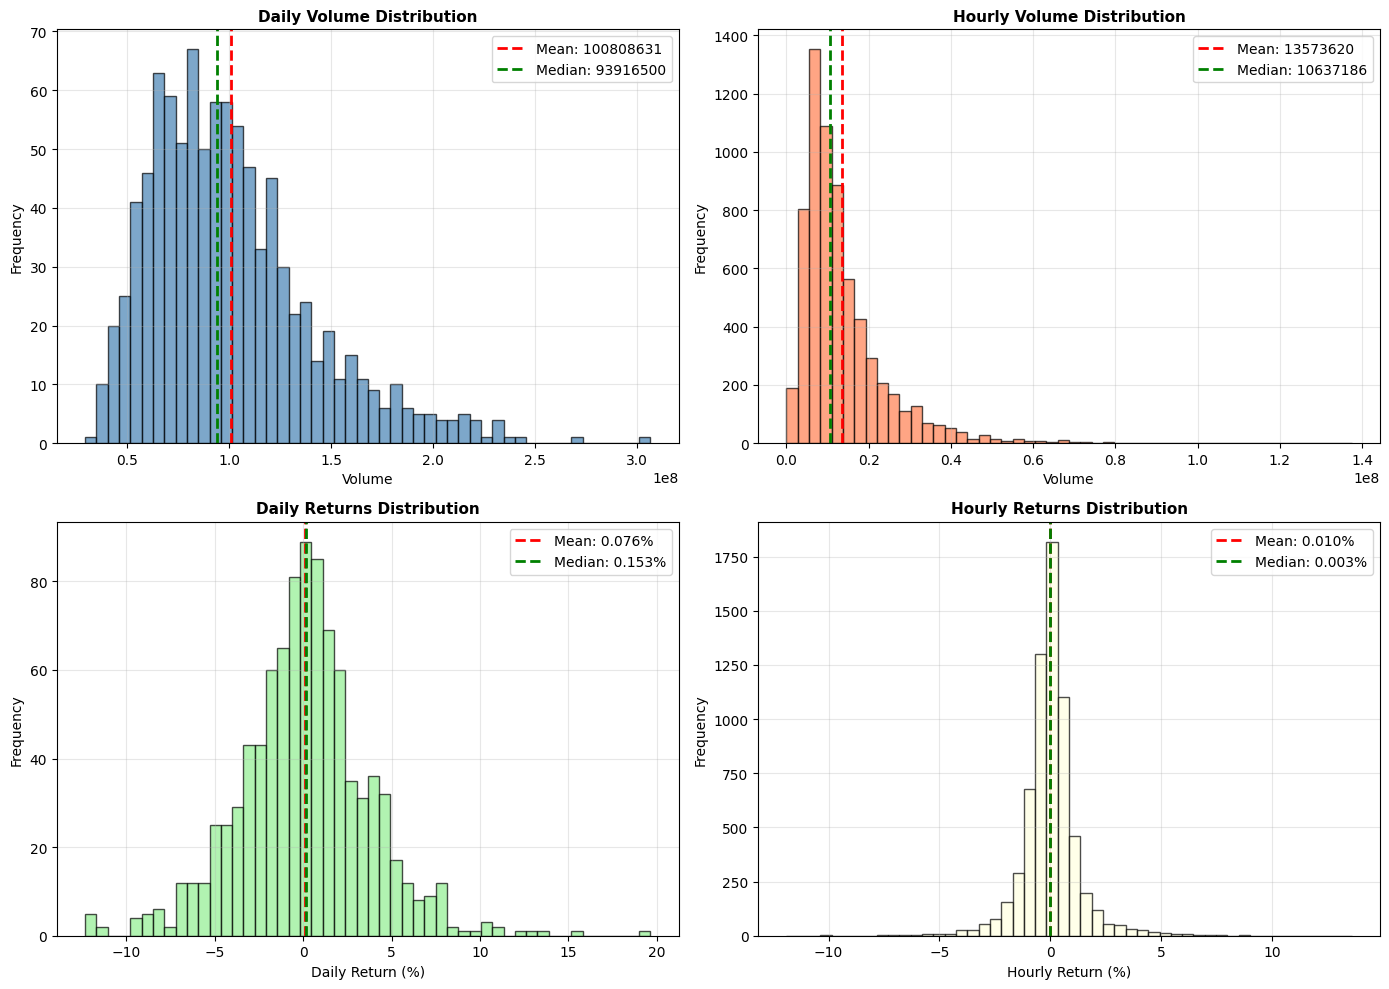

Saved: outputs/eda_distributions.png


In [13]:
# Volume Distribution & Returns Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Daily volume histogram
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(reload_daily['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_daily['Volume'].mean():.0f}")
axes[0, 0].axvline(reload_daily['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_daily['Volume'].median():.0f}")
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Hourly volume histogram
axes[0, 1].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_hourly['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_hourly['Volume'].mean():.0f}")
axes[0, 1].axvline(reload_hourly['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_hourly['Volume'].median():.0f}")
axes[0, 1].set_xlabel('Volume', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Hourly Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Daily returns distribution
daily_returns = reload_daily['Close'].pct_change() * 100
axes[1, 0].hist(daily_returns.dropna(), bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(daily_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_returns.mean():.3f}%")
axes[1, 0].axvline(daily_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {daily_returns.median():.3f}%")
axes[1, 0].set_xlabel('Daily Return (%)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Daily Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Hourly returns distribution
hourly_returns = reload_hourly['Close'].pct_change() * 100
axes[1, 1].hist(hourly_returns.dropna(), bins=50, color='lightyellow', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(hourly_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {hourly_returns.mean():.3f}%")
axes[1, 1].axvline(hourly_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {hourly_returns.median():.3f}%")
axes[1, 1].set_xlabel('Hourly Return (%)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_distributions.png")


MIDAS DATA SANITY CHECK

1. MISSING VALUES (NaN) CHECK:
----------------------------------------------------------------------
  ✓ Cancel_to_Trade               :    0 NaN (  0.00%)
  ✓ Hidden_Rate                   :    0 NaN (  0.00%)
  ✓ Hidden_Volume                 :    0 NaN (  0.00%)
  ✓ Trade_to_Order_Volume         :    0 NaN (  0.00%)
  ✓ Oddlot_Rate                   :    0 NaN (  0.00%)
  ✓ Oddlot_Volume                 :    0 NaN (  0.00%)

  Total NaN: 0.00% of all data points

2. DATE ALIGNMENT CHECK (MIDAS vs Price Data):
----------------------------------------------------------------------
  MIDAS rows        : 941
  Daily trading days: 941
  Hourly trading days: 941
  MIDAS date range  : 2021-01-04 to 2024-09-30
  Daily date range  : 2021-01-04 to 2024-09-30

  Days in DAILY but NOT in MIDAS: 0
  Days in MIDAS but NOT in DAILY: 0
  Alignment: 100.0% of daily dates have MIDAS data

3. SUMMARY STATISTICS:
---------------------------------------------------------------

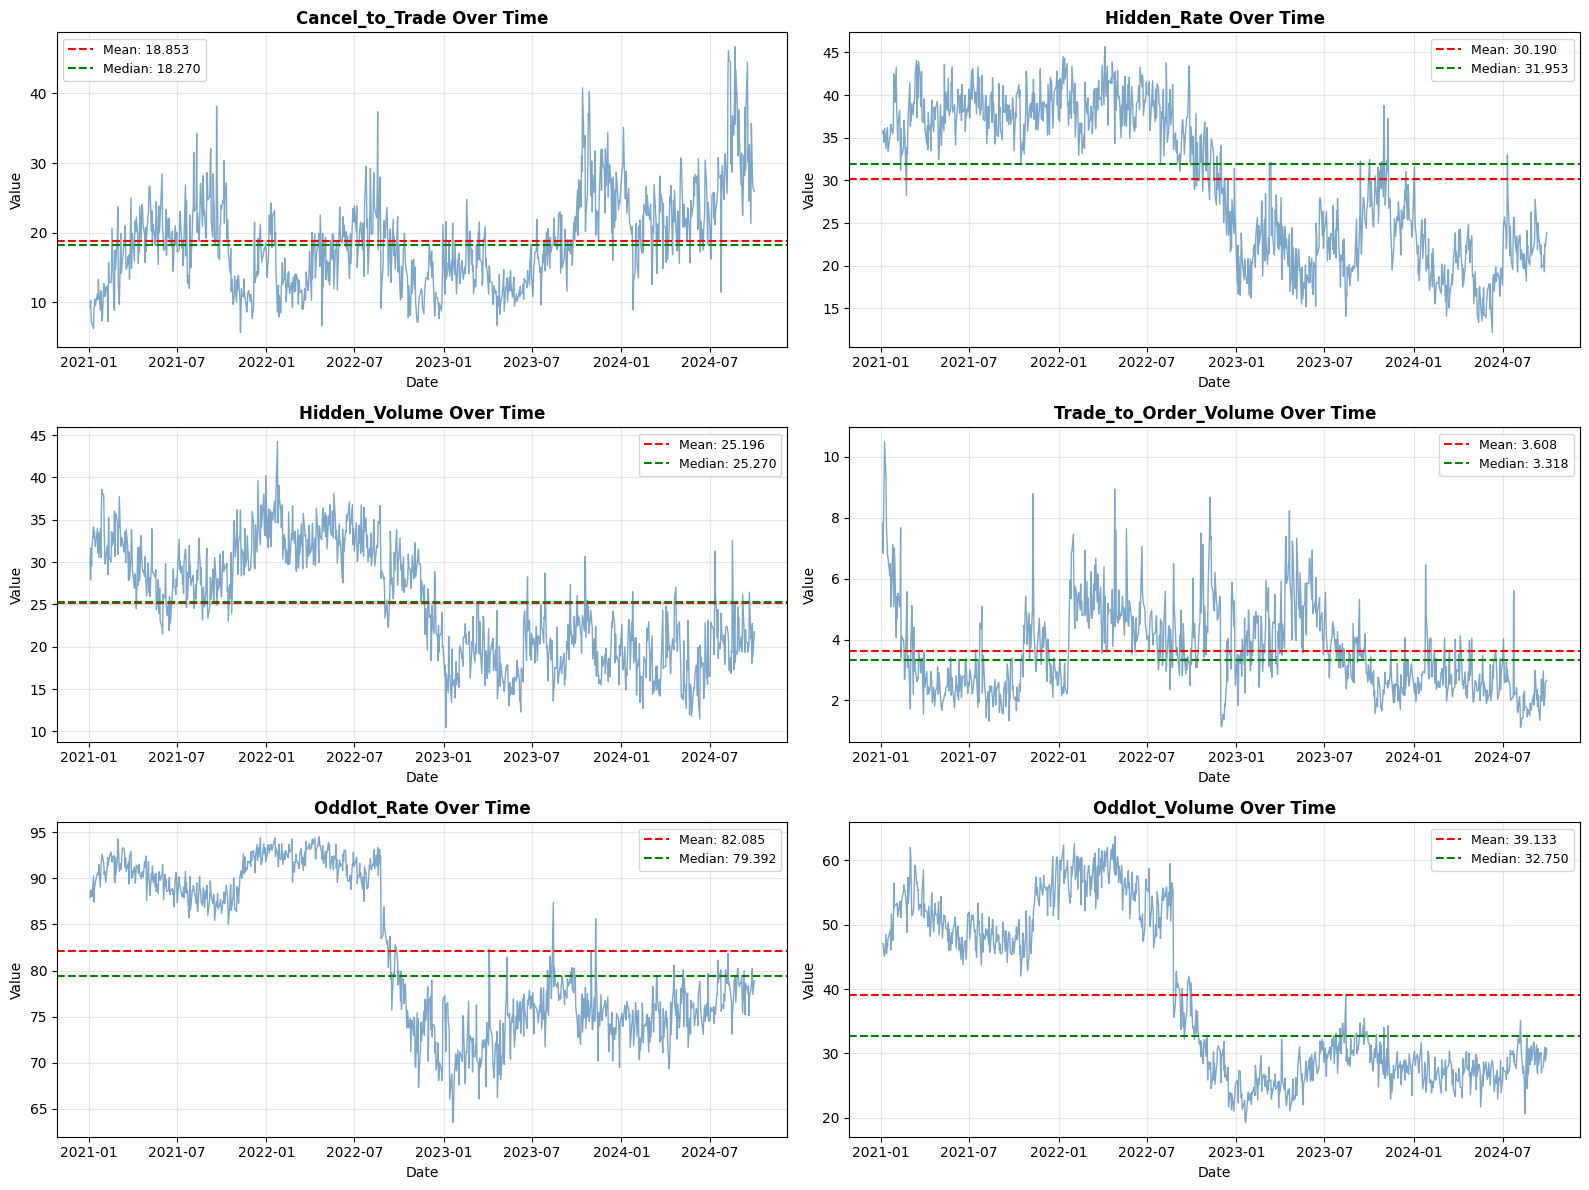


  ✓ Saved: outputs/midas_sanity_check_timeseries.png


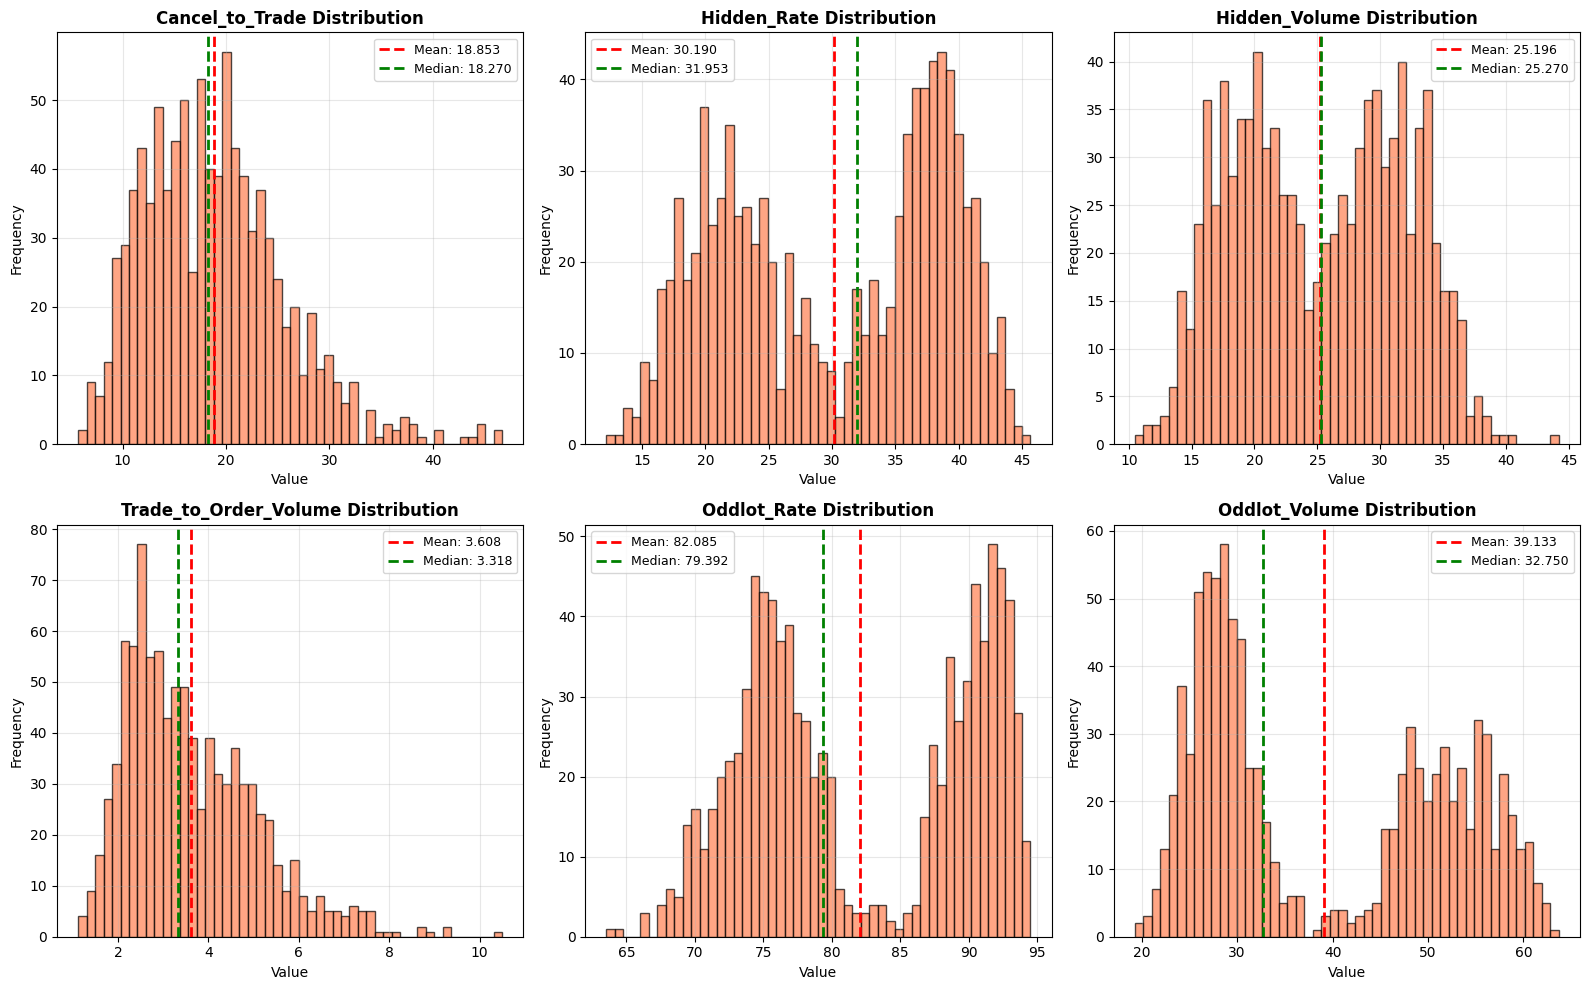

  ✓ Saved: outputs/midas_sanity_check_distributions.png


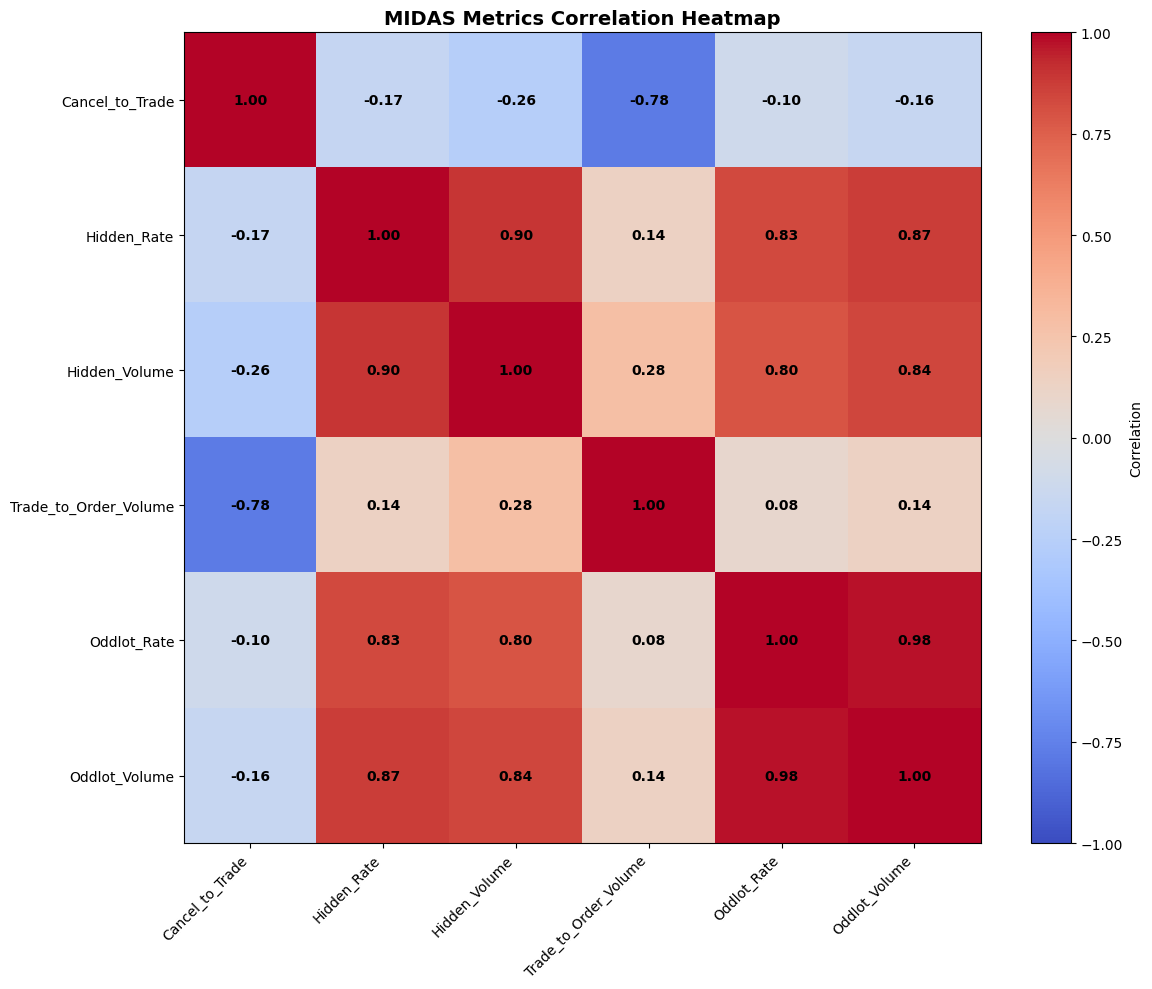

  ✓ Saved: outputs/midas_sanity_check_correlation.png

MIDAS SANITY CHECK SUMMARY

✓ MIDAS data validation complete!
  - 941 rows loaded
  - 6 metrics available
  - Date alignment: 100.0% with daily data
  - Average NaN percentage: 0.00%
  - Ready for zone enrichment and filtering (Layer 3)


In [14]:
# ---------------------------------------------------------------------------
# MIDAS Data Sanity Check
# ---------------------------------------------------------------------------
# Comprehensive validation of MIDAS data for alignment, completeness, and quality

if midas_df is not None and not midas_df.empty and USE_MIDAS:
    print("\n" + "="*70)
    print("MIDAS DATA SANITY CHECK")
    print("="*70)
    
    # ─────────────────────────────────────────────────────────────────────
    # 1. MISSING/NAN VALUES CHECK
    # ─────────────────────────────────────────────────────────────────────
    print("\n1. MISSING VALUES (NaN) CHECK:")
    print("-" * 70)
    
    nan_counts = midas_df.isnull().sum()
    nan_pct = (nan_counts / len(midas_df)) * 100
    
    for col in midas_df.columns:
        nan_cnt = nan_counts[col]
        nan_p = nan_pct[col]
        status = "✓" if nan_p == 0 else "⚠" if nan_p < 20 else "✗"
        print(f"  {status} {col:30s}: {nan_cnt:4d} NaN ({nan_p:6.2f}%)")
    
    total_nan_pct = (midas_df.isnull().sum().sum() / (len(midas_df) * len(midas_df.columns))) * 100
    print(f"\n  Total NaN: {total_nan_pct:.2f}% of all data points")
    
    # ─────────────────────────────────────────────────────────────────────
    # 2. DATE ALIGNMENT CHECK (MIDAS vs Price Data)
    # ─────────────────────────────────────────────────────────────────────
    print("\n2. DATE ALIGNMENT CHECK (MIDAS vs Price Data):")
    print("-" * 70)
    
    midas_dates = set(midas_df.index.date)
    daily_dates = set(reload_daily.index.date)
    hourly_dates = set(reload_hourly.index.date)
    
    dates_in_daily_not_midas = daily_dates - midas_dates
    dates_in_midas_not_daily = midas_dates - daily_dates
    dates_in_hourly_not_midas = hourly_dates - midas_dates
    
    print(f"  MIDAS rows        : {len(midas_df)}")
    print(f"  Daily trading days: {len(daily_dates)}")
    print(f"  Hourly trading days: {len(hourly_dates)}")
    print(f"  MIDAS date range  : {midas_df.index.min().date()} to {midas_df.index.max().date()}")
    print(f"  Daily date range  : {reload_daily.index.min().date()} to {reload_daily.index.max().date()}")
    
    print(f"\n  Days in DAILY but NOT in MIDAS: {len(dates_in_daily_not_midas)}")
    if len(dates_in_daily_not_midas) > 0 and len(dates_in_daily_not_midas) <= 10:
        print(f"    → {sorted(dates_in_daily_not_midas)[:5]}" + ("..." if len(dates_in_daily_not_midas) > 5 else ""))
    
    print(f"  Days in MIDAS but NOT in DAILY: {len(dates_in_midas_not_daily)}")
    if len(dates_in_midas_not_daily) > 0 and len(dates_in_midas_not_daily) <= 10:
        print(f"    → {sorted(dates_in_midas_not_daily)[:5]}" + ("..." if len(dates_in_midas_not_daily) > 5 else ""))
    
    alignment_pct = (len(midas_dates & daily_dates) / len(daily_dates)) * 100 if daily_dates else 0
    print(f"  Alignment: {alignment_pct:.1f}% of daily dates have MIDAS data")
    
    # ─────────────────────────────────────────────────────────────────────
    # 3. SUMMARY STATISTICS (count, mean, median, min, max, std)
    # ─────────────────────────────────────────────────────────────────────
    print("\n3. SUMMARY STATISTICS:")
    print("-" * 70)
    
    stats_df = midas_df.describe().round(4)
    print(stats_df.to_string())
    
    # ─────────────────────────────────────────────────────────────────────
    # 4. PERCENTILE RANKS & OUTLIERS CHECK
    # ─────────────────────────────────────────────────────────────────────
    print("\n4. PERCENTILE DISTRIBUTION & OUTLIERS:")
    print("-" * 70)
    
    for col in midas_df.columns:
        col_data = midas_df[col].dropna()
        if len(col_data) == 0:
            continue
        
        q1 = col_data.quantile(0.25)
        q2 = col_data.quantile(0.50)  # median
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        
        outliers_low = (col_data < lower_fence).sum()
        outliers_high = (col_data > upper_fence).sum()
        total_outliers = outliers_low + outliers_high
        outlier_pct = (total_outliers / len(col_data)) * 100
        
        print(f"\n  {col}:")
        print(f"    Percentiles: Q1={q1:.4f}, Q2(Median)={q2:.4f}, Q3={q3:.4f}")
        print(f"    IQR={iqr:.4f}, Outlier Fences: [{lower_fence:.4f}, {upper_fence:.4f}]")
        print(f"    Outliers: {total_outliers} ({outlier_pct:.2f}%) [Low: {outliers_low}, High: {outliers_high}]")
    
    # ─────────────────────────────────────────────────────────────────────
    # 5. CORRELATION MATRIX (Relationship between MIDAS metrics)
    # ─────────────────────────────────────────────────────────────────────
    print("\n5. CORRELATION BETWEEN MIDAS METRICS:")
    print("-" * 70)
    
    corr_matrix = midas_df.corr().round(3)
    print(corr_matrix.to_string())
    
    # ─────────────────────────────────────────────────────────────────────
    # 6. VISUALIZATIONS
    # ─────────────────────────────────────────────────────────────────────
    import matplotlib.pyplot as plt
    
    # Create a comprehensive figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 6a. Time series of each MIDAS metric
    for idx, col in enumerate(midas_df.columns):
        ax = plt.subplot(3, 2, idx + 1)
        ax.plot(midas_df.index, midas_df[col], linewidth=1, color='steelblue', alpha=0.7)
        ax.set_title(f'{col} Over Time', fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Value')
        ax.grid(alpha=0.3)
        
        # Add mean and median lines
        mean_val = midas_df[col].mean()
        median_val = midas_df[col].median()
        ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.3f}')
        ax.axhline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.3f}')
        ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n  ✓ Saved: outputs/midas_sanity_check_timeseries.png")
    
    # 6b. Distribution histograms
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(midas_df.columns):
        ax = axes[idx]
        col_data = midas_df[col].dropna()
        ax.hist(col_data, bins=50, color='coral', alpha=0.7, edgecolor='black')
        ax.axvline(col_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {col_data.mean():.3f}')
        ax.axvline(col_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {col_data.median():.3f}')
        ax.set_title(f'{col} Distribution', fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    
    # Remove extra subplot
    if len(midas_df.columns) < 6:
        fig.delaxes(axes[-1])
    
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Saved: outputs/midas_sanity_check_distributions.png")
    
    # 6c. Heatmap of correlation matrix
    import matplotlib.patches as mpatches
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_matrix.columns)
    
    # Add correlation values in cells
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=10, fontweight='bold')
    
    ax.set_title('MIDAS Metrics Correlation Heatmap', fontweight='bold', fontsize=14)
    plt.colorbar(im, ax=ax, label='Correlation')
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Saved: outputs/midas_sanity_check_correlation.png")
    
    # ─────────────────────────────────────────────────────────────────────
    # SUMMARY
    # ─────────────────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("MIDAS SANITY CHECK SUMMARY")
    print("="*70)
    
    print(f"\n✓ MIDAS data validation complete!")
    print(f"  - {len(midas_df)} rows loaded")
    print(f"  - {len(midas_df.columns)} metrics available")
    print(f"  - Date alignment: {alignment_pct:.1f}% with daily data")
    print(f"  - Average NaN percentage: {total_nan_pct:.2f}%")
    print(f"  - Ready for zone enrichment and filtering (Layer 3)")
    
else:
    print("\n⚠ MIDAS data not available for sanity check (midas_df is None or empty)")

In [15]:
midas_df.head()

,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume
date,,,,,,
2021-01-04,9.230069,35.772576,30.521597,7.828468,87.947450,47.103830
2021-01-05,10.303195,35.458893,27.879749,6.831907,88.720227,47.017219
2021-01-06,8.304282,35.778200,31.633233,8.004737,88.665709,46.150634
2021-01-07,7.020428,34.469931,29.535346,9.314816,88.091067,45.249066
2021-01-08,7.009115,36.076460,31.920673,10.498168,88.009125,45.116434


### 2b — Data Transformation

In [16]:
# ---------------------------------------------------------------------------
# Volume Data Normalization: Conditional log1p + Z-Score Standardization
# ---------------------------------------------------------------------------

def normalize_volume_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize raw volume data: apply log1p if skewness > 0.5, then z-score.
    
    Rationale for conditional log1p:
    - High skew indicates extreme outliers (institutional activity signals)
    - Log transformation compresses skew while preserving relative magnitude
    - Subsequent z-score creates regime-independent threshold (e.g., vol_spike >= 1.5)
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'Volume' or 'volume' column
    
    Returns:
    --------
    pd.DataFrame
        Copy of df with normalized volume columns added:
        - volume_skewness: Raw volume skewness (diagnostic)
        - volume_log_applied: Boolean indicating if log1p was used
        - volume_zscore: Z-score normalized volume (μ=0, σ=1)
    """
    df_norm = df.copy()
    
    # Identify volume column
    vol_col = "Volume" if "Volume" in df.columns else ("volume" if "volume" in df.columns else None)
    if vol_col is None:
        print("[Warning] normalize_volume_data: no volume column found")
        return df_norm
    
    # Step 1: Calculate skewness on raw volume
    skewness = df_norm[vol_col].skew()
    df_norm['volume_skewness'] = skewness
    
    # Step 2: Apply log1p if skewness > 0.5
    apply_log = skewness > 0.5
    df_norm['volume_log_applied'] = apply_log
    
    if apply_log:
        volume_transformed = np.log1p(df_norm[vol_col])
        print(f"[Volume] High skewness detected ({skewness:.4f}) → applying log1p transformation")
    else:
        volume_transformed = df_norm[vol_col]
        print(f"[Volume] Skewness acceptable ({skewness:.4f}) → using raw values")
    
    # Step 3: Rolling Z-score normalization on transformed volume
    # Using 20-bar rolling window for regime-adaptive normalization
    # min_periods=1 ensures no NaN values (bootstrap from first bar onwards)
    vol_roll_mean = volume_transformed.rolling(window=VOL_ROLL_WINDOW, min_periods=1).mean()
    vol_roll_std = volume_transformed.rolling(window=VOL_ROLL_WINDOW, min_periods=1).std().clip(lower=0.01)
    
    if vol_roll_std.max() > 0:
        df_norm['volume_zscore'] = (volume_transformed - vol_roll_mean) / vol_roll_std
    else:
        df_norm['volume_zscore'] = 0.0

    return df_norm

In [17]:
# APPLY VOLUME NORMALIZATION — Create volume_zscore column 

print("\n" + "="*75)
print("STEP 1: APPLYING VOLUME NORMALIZATION (normalize_volume_data)")
print("="*75)
print("Creating volume_zscore column required by all downstream analysis...")
print()

reload_daily  = normalize_volume_data(reload_daily)
reload_hourly = normalize_volume_data(reload_hourly)

print("\n✓ Volume normalization complete:")
print(f"  - Daily data: {len(reload_daily)} bars, volume_zscore shape={reload_daily['volume_zscore'].shape}")
print(f"  - Hourly data: {len(reload_hourly)} bars, volume_zscore shape={reload_hourly['volume_zscore'].shape}")
print(f"  - Both DataFrames now have volume_skewness, volume_log_applied, volume_zscore columns")


STEP 1: APPLYING VOLUME NORMALIZATION (normalize_volume_data)
Creating volume_zscore column required by all downstream analysis...

[Volume] High skewness detected (1.1089) → applying log1p transformation
[Volume] High skewness detected (2.8453) → applying log1p transformation

✓ Volume normalization complete:
  - Daily data: 941 bars, volume_zscore shape=(941,)
  - Hourly data: 6577 bars, volume_zscore shape=(6577,)
  - Both DataFrames now have volume_skewness, volume_log_applied, volume_zscore columns


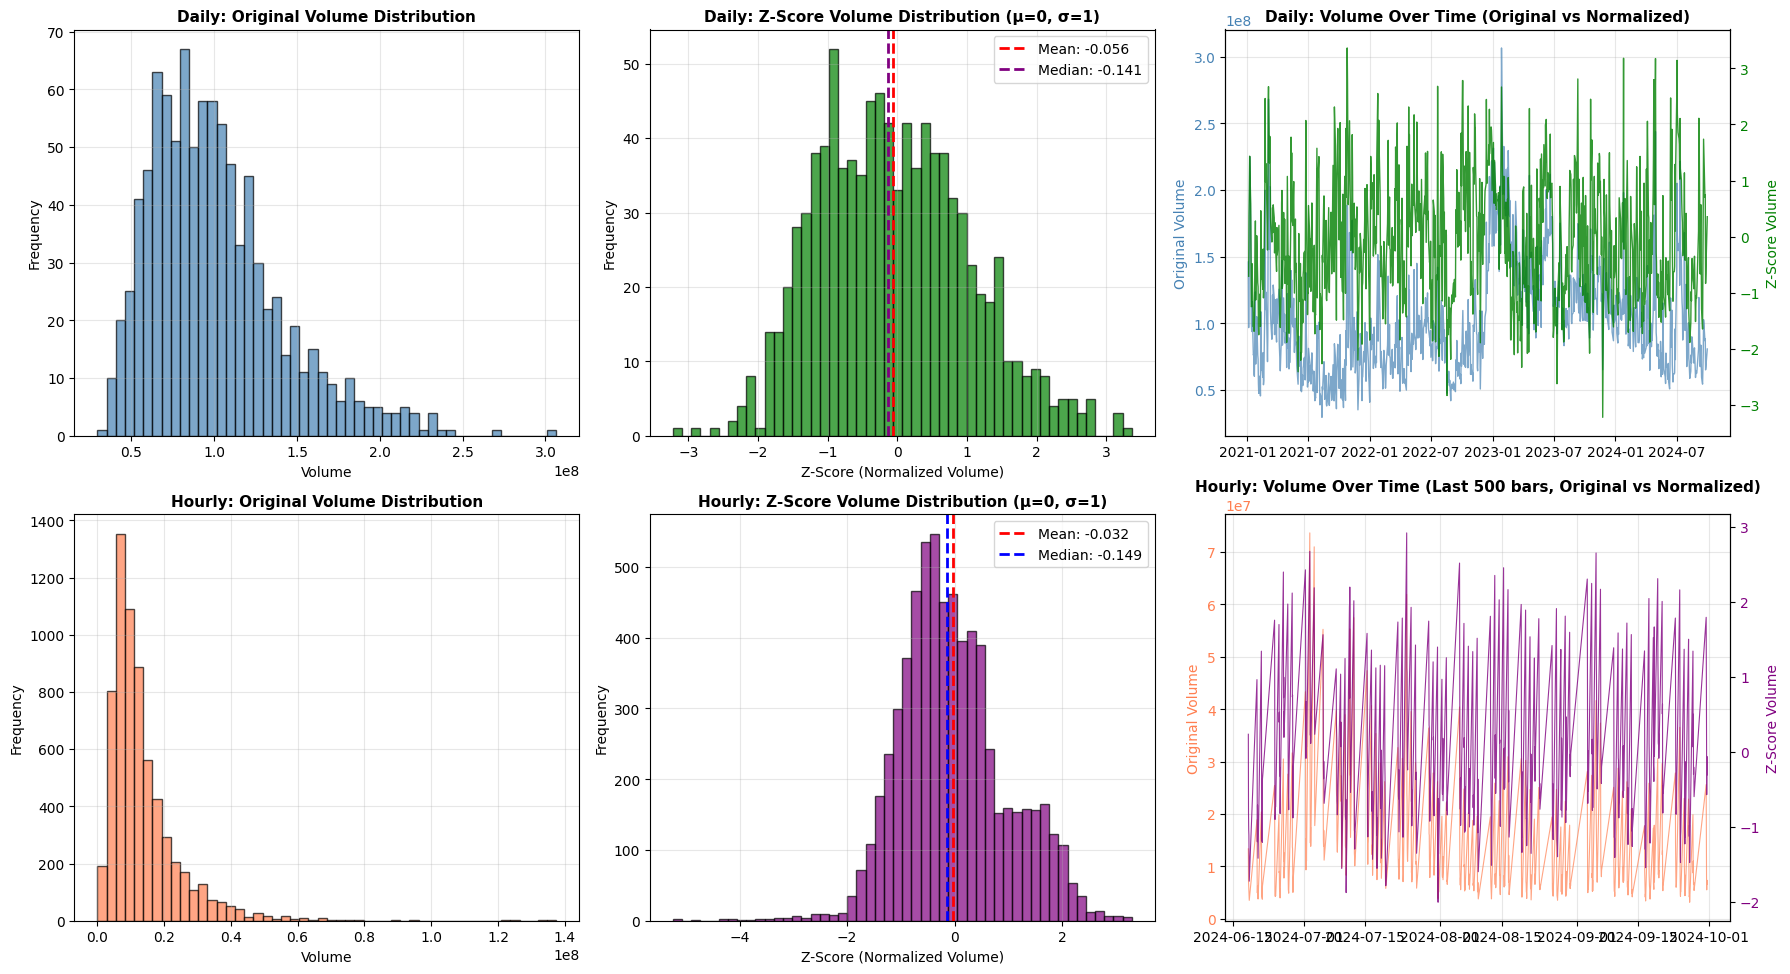


✓ Volume normalization visualizations displayed


In [18]:
# ---------------------------------------------------------------------------
# Volume Normalization Visualizations
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ─────────────────────────────────────────────────────────────────────────
# Row 1: Daily (HTF) Volume Analysis
# ─────────────────────────────────────────────────────────────────────────

# Original Volume Distribution
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily: Original Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Z-Score Volume Distribution (centered at 0)
axes[0, 1].hist(reload_daily['volume_zscore'].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_daily['volume_zscore'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f"Mean: {reload_daily['volume_zscore'].mean():.3f}")
axes[0, 1].axvline(reload_daily['volume_zscore'].median(), color='purple', linestyle='--', linewidth=2,
                   label=f"Median: {reload_daily['volume_zscore'].median():.3f}")
axes[0, 1].set_xlabel('Z-Score (Normalized Volume)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Daily: Z-Score Volume Distribution (μ=0, σ=1)', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Time Series: Original vs Normalized Volume
axes[0, 2].plot(reload_daily.index, reload_daily['Volume'], color='steelblue', linewidth=1, 
                label='Original', alpha=0.7)
ax_norm = axes[0, 2].twinx()
ax_norm.plot(reload_daily.index, reload_daily['volume_zscore'], color='green', linewidth=1, 
             label='Z-Score', alpha=0.8)
axes[0, 2].set_ylabel('Original Volume', fontsize=10, color='steelblue')
ax_norm.set_ylabel('Z-Score Volume', fontsize=10, color='green')
axes[0, 2].set_title('Daily: Volume Over Time (Original vs Normalized)', fontsize=11, fontweight='bold')
axes[0, 2].tick_params(axis='y', labelcolor='steelblue')
ax_norm.tick_params(axis='y', labelcolor='green')
axes[0, 2].grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────
# Row 2: Hourly (LTF) Volume Analysis
# ─────────────────────────────────────────────────────────────────────────

# Original Volume Distribution (Hourly)
axes[1, 0].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Volume', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Hourly: Original Volume Distribution', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Z-Score Volume Distribution (Hourly)
axes[1, 1].hist(reload_hourly['volume_zscore'].dropna(), bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(reload_hourly['volume_zscore'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f"Mean: {reload_hourly['volume_zscore'].mean():.3f}")
axes[1, 1].axvline(reload_hourly['volume_zscore'].median(), color='blue', linestyle='--', linewidth=2,
                   label=f"Median: {reload_hourly['volume_zscore'].median():.3f}")
axes[1, 1].set_xlabel('Z-Score (Normalized Volume)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly: Z-Score Volume Distribution (μ=0, σ=1)', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Time Series: Hourly Volume (Last 500 bars for clarity)
hourly_tail = reload_hourly.tail(500)
axes[1, 2].plot(hourly_tail.index, hourly_tail['Volume'], color='coral', linewidth=0.8, 
                label='Original', alpha=0.7)
ax_norm2 = axes[1, 2].twinx()
ax_norm2.plot(hourly_tail.index, hourly_tail['volume_zscore'], color='purple', linewidth=0.8,
              label='Z-Score', alpha=0.8)
axes[1, 2].set_ylabel('Original Volume', fontsize=10, color='coral')
ax_norm2.set_ylabel('Z-Score Volume', fontsize=10, color='purple')
axes[1, 2].set_title('Hourly: Volume Over Time (Last 500 bars, Original vs Normalized)', fontsize=11, fontweight='bold')
axes[1, 2].tick_params(axis='y', labelcolor='coral')
ax_norm2.tick_params(axis='y', labelcolor='purple')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("\n✓ Volume normalization visualizations displayed")

In [19]:
"""
MIDAS Data Preprocessing 
==========================================
Enhanced version addressing:
1. Time-series leakage (walk-forward transforms)
2. Bimodality detection with validation
3. Stable regime-aware normalization
"""

import numpy as np
import pandas as pd
from typing import Optional, Dict, Tuple, Any
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Optional imports with fallbacks
try:
    from sklearn.mixture import GaussianMixture
    HAS_GMM = True
except ImportError:
    HAS_GMM = False

try:
    from scipy.stats import gaussian_kde
    from scipy.signal import find_peaks
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False


# =============================================================================
# DEFAULT CONFIGURATION (Module-level constants)
# =============================================================================

# Rolling window sizes
DEFAULT_ROLLING_WINDOW_SHORT = 20
DEFAULT_ROLLING_WINDOW_LONG = 50
DEFAULT_EXPANDING_MIN_PERIODS = 50

# Bimodality detection thresholds
DEFAULT_BIMODAL_BIC_THRESHOLD = 10.0
DEFAULT_BIMODAL_SEPARATION_THRESHOLD = 1.5
DEFAULT_BIMODAL_MIN_WEIGHT = 0.15
DEFAULT_BIMODAL_MIN_SAMPLES = 100

# Z-score settings
DEFAULT_ZSCORE_CLIP = 4.0
DEFAULT_ZSCORE_MIN_STD = 1e-6

# HTF Zone scoring weights (all HIGH = institutional)
DEFAULT_WEIGHT_HIDDEN_RATE = 0.35
DEFAULT_WEIGHT_INST_VS_RETAIL = 0.20
DEFAULT_WEIGHT_INST_INTENSITY = 0.20
DEFAULT_WEIGHT_CANCEL_TO_TRADE = 0.15
DEFAULT_WEIGHT_FILL_RATE = 0.10


# =============================================================================
# BIMODALITY DETECTION (Enhanced with Validation)
# =============================================================================

def detect_regime_threshold(
    series: pd.Series, 
    method: str = 'gmm',
    bic_threshold: float = DEFAULT_BIMODAL_BIC_THRESHOLD,
    separation_threshold: float = DEFAULT_BIMODAL_SEPARATION_THRESHOLD,
    min_weight: float = DEFAULT_BIMODAL_MIN_WEIGHT,
    min_samples: int = DEFAULT_BIMODAL_MIN_SAMPLES
) -> Tuple[float, bool]:
    """
    Detect regime threshold for bimodal distributions with validation.
    
    Enhanced with:
    1. Component separation validation
    2. Weight balance check (no tiny clusters)
    3. More robust fallbacks
    
    Parameters:
    -----------
    series : pd.Series
        Input data series
    method : str
        'gmm' or 'kde' for threshold detection
    bic_threshold : float
        BIC improvement required for bimodality
    separation_threshold : float
        Minimum std separation between modes
    min_weight : float
        Minimum component weight (avoid tiny clusters)
    min_samples : int
        Minimum samples for bimodality detection
    
    Returns:
    --------
    threshold : float
        Optimal split point between regimes
    is_bimodal : bool
        Whether distribution is genuinely bimodal
    """
    data = series.dropna()
    
    if len(data) < min_samples:
        return float(series.median()), False
    
    data_arr = data.values.reshape(-1, 1)
    
    if method == 'gmm' and HAS_GMM:
        try:
            # Fit 1-component and 2-component GMM
            gmm1 = GaussianMixture(n_components=1, random_state=42, n_init=3)
            gmm2 = GaussianMixture(n_components=2, random_state=42, n_init=3)
            
            gmm1.fit(data_arr)
            gmm2.fit(data_arr)
            
            bic_improvement = gmm1.bic(data_arr) - gmm2.bic(data_arr)
            
            # Validation 1: BIC improvement threshold
            if bic_improvement < bic_threshold:
                return float(series.median()), False
            
            # Validation 2: Component separation
            means = gmm2.means_.flatten()
            stds = np.sqrt(gmm2.covariances_.flatten())
            mean_separation = abs(means[1] - means[0])
            avg_std = np.mean(stds)
            
            separation_ratio = mean_separation / avg_std if avg_std > 0 else 0
            
            if separation_ratio < separation_threshold:
                return float(series.median()), False
            
            # Validation 3: Balanced components
            weights = gmm2.weights_
            if min(weights) < min_weight:
                return float(series.median()), False
            
            # All validations passed - calculate threshold
            threshold = float(np.mean(means))
            return threshold, True
            
        except Exception:
            return float(series.median()), False
    
    elif method == 'kde' and HAS_SCIPY:
        try:
            kde = gaussian_kde(data.values, bw_method='scott')
            x_grid = np.linspace(data.min(), data.max(), 500)
            density = kde(x_grid)
            
            # Find peaks with adaptive distance
            min_distance = max(10, len(x_grid) // 20)
            peaks, properties = find_peaks(density, distance=min_distance, prominence=0.01)
            
            if len(peaks) < 2:
                return float(series.median()), False
            
            # Find two highest peaks
            peak_heights = density[peaks]
            top_2_idx = np.argsort(peak_heights)[-2:]
            top_2_peaks = sorted(peaks[top_2_idx])
            
            # Validate separation
            peak_distance = abs(x_grid[top_2_peaks[1]] - x_grid[top_2_peaks[0]])
            data_range = data.max() - data.min()
            
            if peak_distance < data_range * 0.15:
                return float(series.median()), False
            
            # Find valley between peaks
            valley_region = density[top_2_peaks[0]:top_2_peaks[1]]
            if len(valley_region) == 0:
                return float(series.median()), False
                
            valley_idx = top_2_peaks[0] + np.argmin(valley_region)
            threshold = float(x_grid[valley_idx])
            return threshold, True
            
        except Exception:
            return float(series.median()), False
    
    # Fallback
    return float(series.median()), False


# =============================================================================
# WALK-FORWARD SAFE TRANSFORMATIONS
# =============================================================================

def _expanding_zscore(
    series: pd.Series,
    min_periods: int = DEFAULT_EXPANDING_MIN_PERIODS,
    clip: float = DEFAULT_ZSCORE_CLIP,
    min_std: float = DEFAULT_ZSCORE_MIN_STD
) -> pd.Series:
    """
    Compute z-score using only past data (no leakage).
    Uses expanding window for mean/std calculation.
    """
    expanding_mean = series.expanding(min_periods=min_periods).mean()
    expanding_std = series.expanding(min_periods=min_periods).std()
    
    # Avoid division by zero
    expanding_std = expanding_std.clip(lower=min_std)
    
    zscore = (series - expanding_mean) / expanding_std
    
    if clip:
        zscore = zscore.clip(-clip, clip)
    
    return zscore


def _rolling_zscore(
    series: pd.Series,
    window: int = DEFAULT_ROLLING_WINDOW_SHORT,
    min_periods: int = 10,
    clip: float = DEFAULT_ZSCORE_CLIP,
    min_std: float = DEFAULT_ZSCORE_MIN_STD
) -> pd.Series:
    """
    Rolling z-score using only past data within window.
    """
    rolling_mean = series.rolling(window=window, min_periods=min_periods).mean()
    rolling_std = series.rolling(window=window, min_periods=min_periods).std()
    
    rolling_std = rolling_std.clip(lower=min_std)
    zscore = (series - rolling_mean) / rolling_std
    
    if clip:
        zscore = zscore.clip(-clip, clip)
    
    return zscore


def _expanding_percentile_rank(
    series: pd.Series,
    min_periods: int = DEFAULT_EXPANDING_MIN_PERIODS
) -> pd.Series:
    """
    Compute percentile rank using only past data.
    """
    def _rank_func(arr):
        if len(arr) < min_periods or np.isnan(arr[-1]):
            return np.nan
        current = arr[-1]
        past = arr[:-1]
        valid_past = past[~np.isnan(past)]
        if len(valid_past) == 0:
            return 0.5
        return np.sum(valid_past <= current) / len(valid_past)
    
    return series.rolling(window=len(series), min_periods=min_periods + 1).apply(
        _rank_func, raw=True
    )


def _walk_forward_quantile_transform(
    series: pd.Series,
    min_periods: int = DEFAULT_EXPANDING_MIN_PERIODS,
    output_distribution: str = 'normal'
) -> pd.Series:
    """
    Walk-forward quantile transformation (no future leakage).
    At each point t, transforms using only data from 0:t.
    """
    result = pd.Series(index=series.index, dtype=float)
    values = series.values
    
    for i in range(min_periods, len(values)):
        if np.isnan(values[i]):
            result.iloc[i] = np.nan
            continue
        
        # Use only past data
        past_values = values[:i]
        past_valid = past_values[~np.isnan(past_values)]
        
        if len(past_valid) < 10:
            result.iloc[i] = np.nan
            continue
        
        # Compute percentile rank
        pct_rank = np.sum(past_valid <= values[i]) / len(past_valid)
        
        # Transform to target distribution
        if output_distribution == 'normal':
            try:
                from scipy import stats
                pct_rank = np.clip(pct_rank, 0.001, 0.999)
                result.iloc[i] = stats.norm.ppf(pct_rank)
            except ImportError:
                result.iloc[i] = pct_rank
        else:
            result.iloc[i] = pct_rank
    
    return result


# =============================================================================
# MAIN PREPROCESSING FUNCTION
# =============================================================================

def preprocess_midas_data(
    midas_df: pd.DataFrame, 
    rolling_window: int = 20,
    handle_bimodal: bool = True,
    regime_detection_method: str = 'gmm',
    use_walk_forward: bool = True,
    expanding_min_periods: int = 15,
    zscore_clip: float = 5.0,
    zscore_min_std: float = 1e-4,
    bimodal_bic_threshold: float = -10,
    bimodal_separation_threshold: float = 1.0,
    bimodal_min_weight: float = 0.1,
    bimodal_min_samples: int = 200
) -> pd.DataFrame:
    """
    Enhanced MIDAS preprocessing with bimodal/regime-aware transformations.
    Uses Rolling Median/MAD + Quantiles to handle outlier shadowing.
    """
    if midas_df is None or midas_df.empty:
        print("⚠ MIDAS data is None or empty — skipping preprocessing")
        return midas_df
    
    midas_proc = midas_df.copy()
    
    # Define MIDAS feature columns
    midas_cols = [
        "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
        "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume"
    ]
    
    for col in midas_cols:
        if col not in midas_proc.columns:
            midas_proc[col] = np.nan
            
    print("\n" + "=" * 70)
    print("ROBUST MIDAS PREPROCESSING (Rolling Median/MAD + Quantiles)")
    print("=" * 70)
    print(f"  Walk-forward mode: {use_walk_forward}")
    print(f"  Rolling window: {rolling_window}")

    from sklearn.preprocessing import QuantileTransformer
    import warnings
    
    for col in midas_cols:
        if midas_proc[col].isna().all(): continue
        
        # 1. Rolling Robust Normalization (Median / MAD)
        roll_median = midas_proc[col].rolling(window=rolling_window, min_periods=max(1, rolling_window//2)).median()
        
        roll_q75 = midas_proc[col].rolling(window=rolling_window, min_periods=max(1, rolling_window//2)).quantile(0.75)
        roll_q25 = midas_proc[col].rolling(window=rolling_window, min_periods=max(1, rolling_window//2)).quantile(0.25)
        roll_iqr = (roll_q75 - roll_q25).replace(0, np.nan).ffill().bfill().fillna(1e-4)
        
        roll_mad_std = roll_iqr / 1.349
        
        robust_zscore = (midas_proc[col] - roll_median) / roll_mad_std
        midas_proc[f"{col}_zscore"] = robust_zscore.clip(-zscore_clip, zscore_clip)
        
        # 2. Expanding Quantile Transformation (Walk-forward safe)
        if use_walk_forward:
            q_trans = pd.Series(index=midas_proc.index, dtype=float)
            q_trans = midas_proc[col].expanding(min_periods=expanding_min_periods).apply(
                lambda x: (pd.Series(x).rank(pct=True).iloc[-1]), raw=False
            )
            midas_proc[f"{col}_qnorm"] = q_trans.fillna(0.5)
        else:
            qt = QuantileTransformer(n_quantiles=min(100, len(midas_proc.dropna())), output_distribution='uniform')
            non_na = midas_proc[col].notna()
            if non_na.sum() > 0:
                midas_proc.loc[non_na, f"{col}_qnorm"] = qt.fit_transform(midas_proc.loc[non_na, [col]])
        
        # Smoothing
        midas_proc[f"{col}_roll_median"] = roll_median
        midas_proc[f"{col}_roll_mean"] = midas_proc[col].rolling(window=rolling_window, min_periods=max(1, rolling_window//2)).mean()
        
        # Differences (robust)
        midas_proc[f"{col}_diff_1"] = midas_proc[col].diff()
        
        # Add basic regime as binary threshold over 0.75 quantile to maintain interoperability
        midas_proc[f"{col}_regime"] = (midas_proc[f"{col}_qnorm"] > 0.75).astype(int)

    # Cross-feature ratios
    if "Hidden_Volume" in midas_proc.columns and "Oddlot_Volume" in midas_proc.columns:
        midas_proc["Hidden_to_Oddlot"] = midas_proc["Hidden_Volume"] / (midas_proc["Oddlot_Volume"] + 1e-4)

    print("MIDAS preprocessing complete.")
    return midas_proc


In [20]:
# APPLY MIDAS PREPROCESSING
print("\n" + "="*75)
print("APPLYING MIDAS PREPROCESSING (preprocess_midas_data)")
print("="*75)   
midas_df = preprocess_midas_data(midas_df, rolling_window=20)
print(f"✓ MIDAS data preprocessed: {midas_df.shape}")


APPLYING MIDAS PREPROCESSING (preprocess_midas_data)

ROBUST MIDAS PREPROCESSING (Rolling Median/MAD + Quantiles)
  Walk-forward mode: True
  Rolling window: 20
MIDAS preprocessing complete.
✓ MIDAS data preprocessed: (941, 43)


In [21]:
midas_df.head()

,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume,Cancel_to_Trade_zscore,Cancel_to_Trade_qnorm,Cancel_to_Trade_roll_median,Cancel_to_Trade_roll_mean,...,Oddlot_Rate_roll_mean,Oddlot_Rate_diff_1,Oddlot_Rate_regime,Oddlot_Volume_zscore,Oddlot_Volume_qnorm,Oddlot_Volume_roll_median,Oddlot_Volume_roll_mean,Oddlot_Volume_diff_1,Oddlot_Volume_regime,Hidden_to_Oddlot
date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,9.230069,35.772576,30.521597,7.828468,87.947450,47.103830,NaN,0.5,NaN,NaN,...,NaN,NaN,0,NaN,0.5,NaN,NaN,NaN,0,0.647963
2021-01-05,10.303195,35.458893,27.879749,6.831907,88.720227,47.017219,NaN,0.5,NaN,NaN,...,NaN,0.772777,0,NaN,0.5,NaN,NaN,-0.086611,0,0.592968
2021-01-06,8.304282,35.778200,31.633233,8.004737,88.665709,46.150634,NaN,0.5,NaN,NaN,...,NaN,-0.054518,0,NaN,0.5,NaN,NaN,-0.866585,0,0.685433
2021-01-07,7.020428,34.469931,29.535346,9.314816,88.091067,45.249066,NaN,0.5,NaN,NaN,...,NaN,-0.574642,0,NaN,0.5,NaN,NaN,-0.901568,0,0.652727
2021-01-08,7.009115,36.076460,31.920673,10.498168,88.009125,45.116434,NaN,0.5,NaN,NaN,...,NaN,-0.081942,0,NaN,0.5,NaN,NaN,-0.132632,0,0.707516


In [22]:
midas_df.tail()

,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume,Cancel_to_Trade_zscore,Cancel_to_Trade_qnorm,Cancel_to_Trade_roll_median,Cancel_to_Trade_roll_mean,...,Oddlot_Rate_roll_mean,Oddlot_Rate_diff_1,Oddlot_Rate_regime,Oddlot_Volume_zscore,Oddlot_Volume_qnorm,Oddlot_Volume_roll_median,Oddlot_Volume_roll_mean,Oddlot_Volume_diff_1,Oddlot_Volume_regime,Hidden_to_Oddlot
date,,,,,,,,,,,,,,,,,,,,,
2024-09-24,35.657190,21.208129,21.719910,1.840788,78.386400,29.325258,0.875627,0.979723,31.243872,31.284896,...,77.964904,0.521556,0,0.077699,0.357524,29.200837,29.290639,1.347407,0,0.740653
2024-09-25,32.136996,19.291262,18.047930,2.047854,79.685393,30.009501,0.149674,0.966951,31.382614,31.340736,...,77.937307,1.298993,0,0.288752,0.401919,29.547114,29.376504,0.684242,0,0.601405
2024-09-26,28.694872,22.569841,22.741522,2.082493,80.232638,30.956435,-0.515894,0.921193,31.295069,31.208909,...,77.969304,0.547245,0,0.726913,0.446219,29.547114,29.415049,0.946934,0,0.734628
2024-09-27,26.615372,22.317862,18.830946,2.590407,77.421812,28.826407,-0.868032,0.876596,30.672239,30.657624,...,77.886283,-2.810826,0,-0.239111,0.332979,29.200837,29.299724,-2.130029,0,0.653251
2024-09-30,25.949677,23.903098,21.776731,2.662598,78.873497,30.787481,-0.842489,0.860786,29.585133,30.238144,...,77.916438,1.451685,0,0.650270,0.442083,29.547114,29.395138,1.961074,0,0.707322


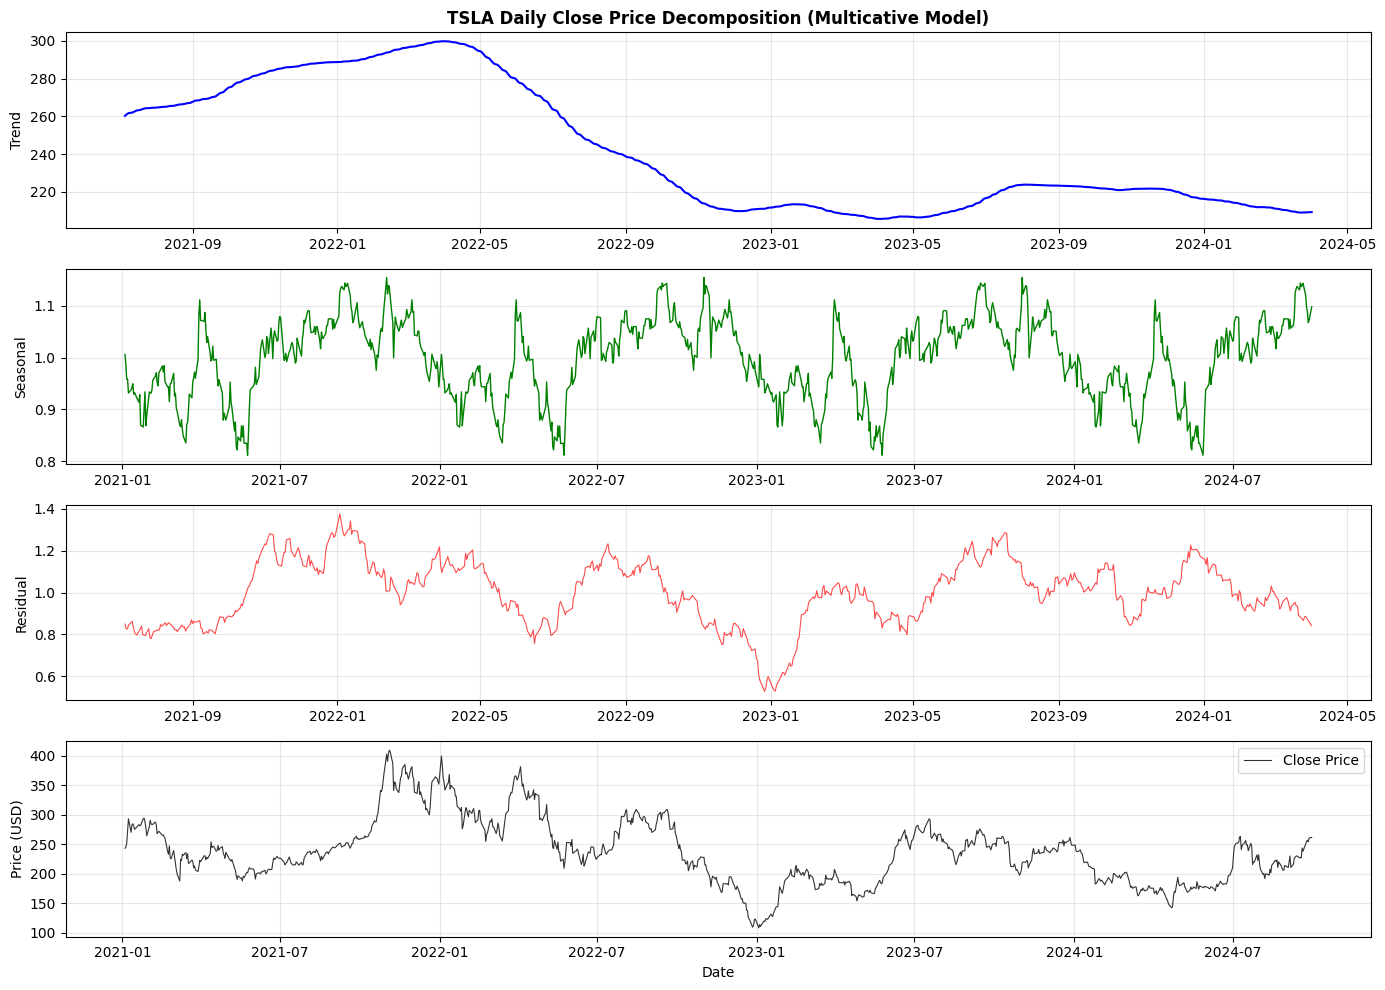

Saved: outputs/eda_decomposition.png


In [23]:
# ---------------------------------------------------------------------------
# EDA: Time Series Decomposition & Visualizations
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare closing prices for decomposition (daily only, as decomposition works on univariate series)
close_daily = reload_daily['Close']

# Perform seasonal decomposition on daily close prices
# freq=252 corresponds to ~1 year of trading days (typical in finance)
decomposition = seasonal_decompose(close_daily, model='multicative', period=252)

# Create a figure with subplots for decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Trend
axes[0].plot(decomposition.trend, color='blue', linewidth=1.5)
axes[0].set_ylabel('Trend', fontsize=10)
axes[0].set_title(f'TSLA Daily Close Price Decomposition (Multicative Model)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Seasonal
axes[1].plot(decomposition.seasonal, color='green', linewidth=1)
axes[1].set_ylabel('Seasonal', fontsize=10)
axes[1].grid(alpha=0.3)

# Residual
axes[2].plot(decomposition.resid, color='red', linewidth=0.8, alpha=0.7)
axes[2].set_ylabel('Residual', fontsize=10)
axes[2].grid(alpha=0.3)

# Original
axes[3].plot(close_daily, color='black', linewidth=0.8, alpha=0.8, label='Close Price')
axes[3].set_ylabel('Price (USD)', fontsize=10)
axes[3].set_xlabel('Date', fontsize=10)
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.savefig('outputs/eda_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_decomposition.png")


/var/folders/th/y9_4zsdn30x0bk83498w2dzw0000gn/T/ipykernel_16865/2554135952.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


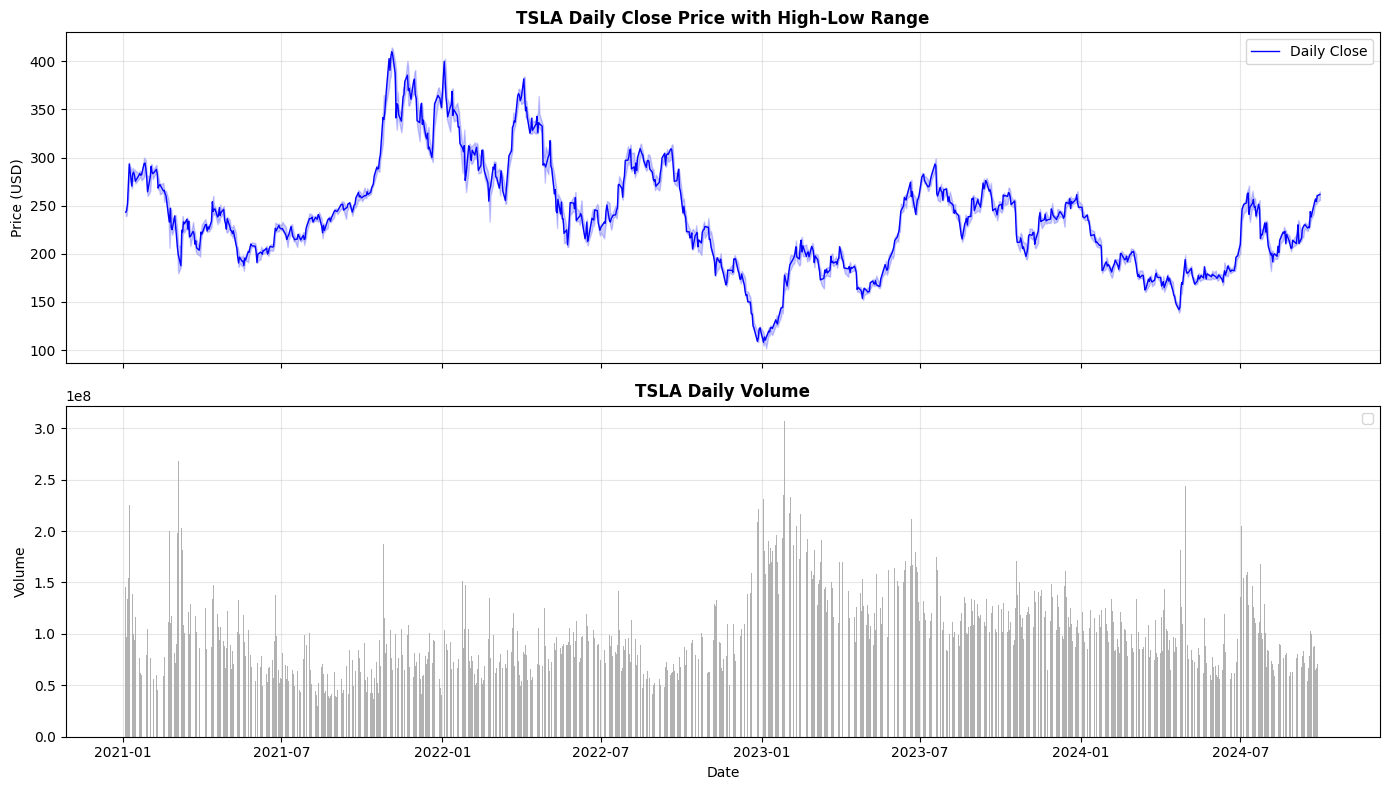

Saved: outputs/eda_price_volume.png


In [24]:
# Price & Volume Trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily close price
axes[0].plot(reload_daily.index, reload_daily['Close'], color='blue', linewidth=1, label='Daily Close')
axes[0].fill_between(reload_daily.index, reload_daily['Low'], reload_daily['High'], alpha=0.2, color='blue')
axes[0].set_ylabel('Price (USD)', fontsize=10)
axes[0].set_title('TSLA Daily Close Price with High-Low Range', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Daily volume
axes[1].bar(reload_daily.index, reload_daily['Volume'], color='gray', alpha=0.6, width=0.8)
axes[1].set_ylabel('Volume', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Daily Volume', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_price_volume.png")


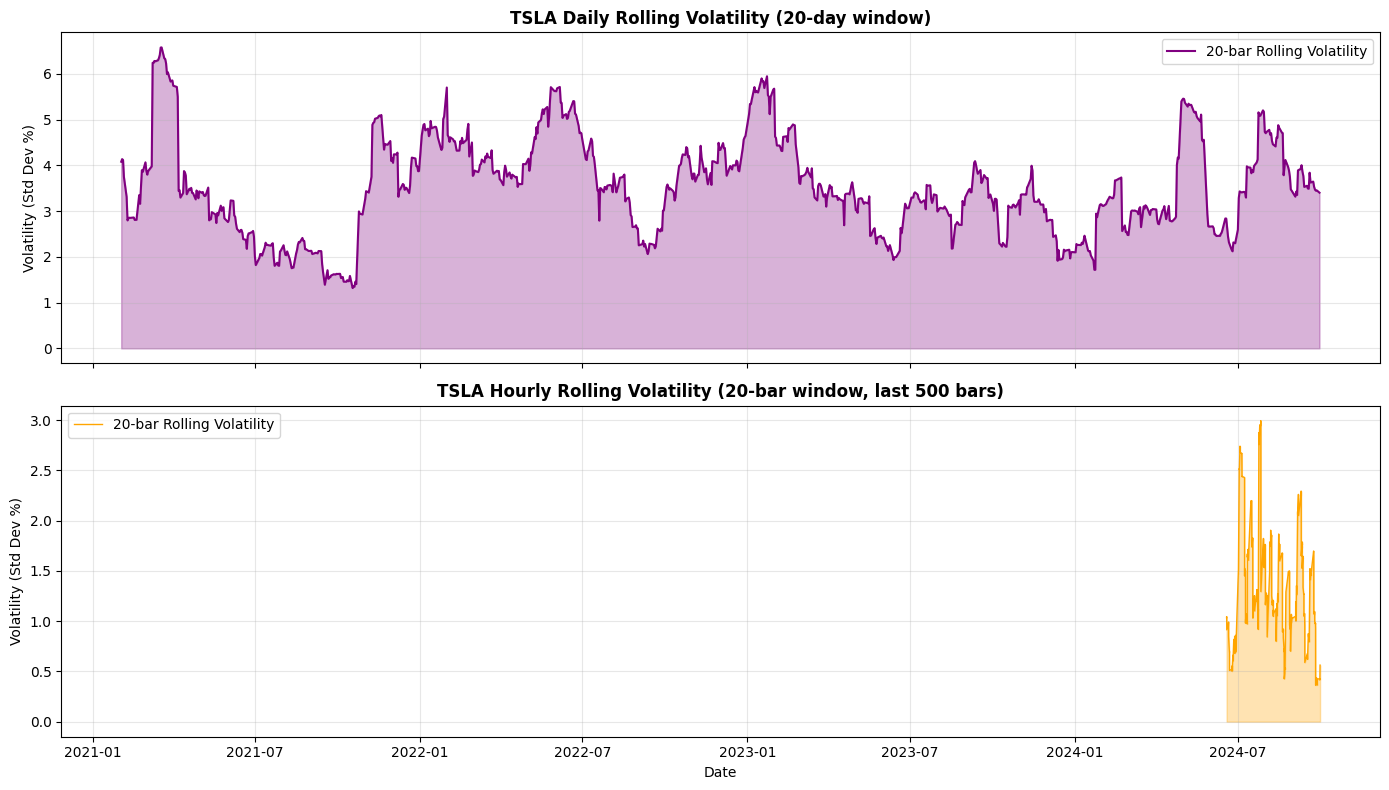

Saved: outputs/eda_volatility.png

VOLATILITY SUMMARY STATISTICS
Daily volatility  - Mean: 3.5182%, Std: 1.0546%, Max: 6.5815%
Hourly volatility - Mean: 1.2262%, Std: 0.5033%, Max: 4.1117%


In [25]:
# Volatility Analysis
import numpy as np

# Calculate rolling volatility (20-day rolling std of returns)
daily_volatility = daily_returns.rolling(20).std()
hourly_volatility = hourly_returns.rolling(20).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily volatility over time
axes[0].plot(daily_volatility.index, daily_volatility, color='purple', linewidth=1.5, label='20-bar Rolling Volatility')
axes[0].fill_between(daily_volatility.index, daily_volatility, alpha=0.3, color='purple')
axes[0].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[0].set_title('TSLA Daily Rolling Volatility (20-day window)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Hourly volatility over time (last 500 bars for clarity)
hourly_tail = hourly_volatility.tail(500)
axes[1].plot(hourly_tail.index, hourly_tail, color='orange', linewidth=1, label='20-bar Rolling Volatility')
axes[1].fill_between(hourly_tail.index, hourly_tail, alpha=0.3, color='orange')
axes[1].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Hourly Rolling Volatility (20-bar window, last 500 bars)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_volatility.png")

# Summary statistics
print("\n" + "="*70)
print("VOLATILITY SUMMARY STATISTICS")
print("="*70)
print(f"Daily volatility  - Mean: {daily_volatility.mean():.4f}%, Std: {daily_volatility.std():.4f}%, Max: {daily_volatility.max():.4f}%")
print(f"Hourly volatility - Mean: {hourly_volatility.mean():.4f}%, Std: {hourly_volatility.std():.4f}%, Max: {hourly_volatility.max():.4f}%")


In [26]:
# EDA Summary: Key Statistics Comparison

summary_data = {
    'Metric': [
        'Records', 'Date Range', 'Avg Close', 'Min Close', 'Max Close',
        'Avg Volume', 'Median Volume', 'Volume Std Dev',
        'Avg Return (%)', 'Max Return (%)', 'Min Return (%)',
        'Avg Volatility (%)', 'Max Volatility (%)'
    ],
    'Daily (HTF)': [
        len(reload_daily),
        f"{reload_daily.index.min().date()} to {reload_daily.index.max().date()}",
        f"{reload_daily['Close'].mean():.2f}",
        f"{reload_daily['Close'].min():.2f}",
        f"{reload_daily['Close'].max():.2f}",
        f"{reload_daily['Volume'].mean():.0f}",
        f"{reload_daily['Volume'].median():.0f}",
        f"{reload_daily['Volume'].std():.0f}",
        f"{daily_returns.mean():.4f}",
        f"{daily_returns.max():.4f}",
        f"{daily_returns.min():.4f}",
        f"{daily_volatility.mean():.4f}",
        f"{daily_volatility.max():.4f}"
    ],
    'Hourly (LTF)': [
        len(reload_hourly),
        f"{reload_hourly.index.min()} to {reload_hourly.index.max()}",
        f"{reload_hourly['Close'].mean():.2f}",
        f"{reload_hourly['Close'].min():.2f}",
        f"{reload_hourly['Close'].max():.2f}",
        f"{reload_hourly['Volume'].mean():.0f}",
        f"{reload_hourly['Volume'].median():.0f}",
        f"{reload_hourly['Volume'].std():.0f}",
        f"{hourly_returns.mean():.4f}",
        f"{hourly_returns.max():.4f}",
        f"{hourly_returns.min():.4f}",
        f"{hourly_volatility.mean():.4f}",
        f"{hourly_volatility.max():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("EDA SUMMARY — DAILY vs HOURLY")
print("="*70)
print(summary_df)


EDA SUMMARY — DAILY vs HOURLY
                Metric               Daily (HTF)  \
0              Records                       941   
1           Date Range  2021-01-04 to 2024-09-30   
2            Avg Close                    237.46   
3            Min Close                    108.10   
4            Max Close                    409.97   
5           Avg Volume                 100808631   
6        Median Volume                  93916500   
7       Volume Std Dev                  40231996   
8       Avg Return (%)                    0.0757   
9       Max Return (%)                   19.6412   
10      Min Return (%)                  -12.3346   
11  Avg Volatility (%)                    3.5182   
12  Max Volatility (%)                    6.5815   

                                  Hourly (LTF)  
0                                         6577  
1   2021-01-04 09:30:00 to 2024-09-30 15:30:00  
2                                       237.51  
3                                       105.

## Part 3 — Three-Layer Liquidity Zone Filter

All helper functions and three-layer zone filter:
- **Layer 1 (3a):** Price-Based Patterns — ATR/pivot structure detection
- **Layer 2 (3b):** Volume-Related Features — Volume ratio, absorption scoring
- **Layer 3 (3c):** Microstructure Metrics — MIDAS enrichment and filtering

Layer-by-Layer Breakdown:

Each layer adds increasing conviction to zone identification:
1. **Layer 1** identifies potential pivots (local extrema)
2. **Layer 2** filters for volume confirmation and institutional footprints
3. **Layer 3** enriches with dark-pool and order-flow microstructure data

Set `USE_MIDAS=False` to skip Layer 3 and work with Layer 1+2 zones only.


### 3a — Layer 1: Price-Based Pattern Detection

**Price-based patterns** identify structural liquidity using:
- **ATR (Average True Range):** Volatility-adjusted threshold for zone merging
- **SMA (Simple Moving Average):** Volume baseline for spike detection  
- **Symmetric Pivot Detection:** Local highs/lows confirmed by surrounding bars

These calculations form the foundation for Layer 2 volume filtering and Layer 3 institutional enrichment.

In [27]:
# ---------------------------------------------------------------------------
# Technical Utilities: ATR and SMA
# ---------------------------------------------------------------------------
def atr(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """Average True Range (simple moving average of True Range)."""
    high = df["high"]
    low = df["low"]
    close = df["close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length, min_periods=length).mean()


def sma(series: pd.Series, length: int) -> pd.Series:
    return series.rolling(length, min_periods=length).mean()



In [28]:
# ===========================================================================
# Fix 10: HTF Bias Detection — determine market structure direction
# Fix 13: Order Block Candle Detection — zone boundaries from OB body
# ===========================================================================

def detect_htf_bias(daily_df, lookback_pivots=4, pivot_window=3):
    """
    Determine HTF market structure direction from recent daily pivots.
    Returns 'bullish', 'bearish', or 'neutral'.
    """
    if daily_df is None or len(daily_df) < pivot_window * 2 + lookback_pivots:
        return 'neutral'

    df = daily_df.copy()
    df.columns = [c.lower() for c in df.columns]

    highs = df['high'].values
    lows = df['low'].values
    n = len(df)

    pivot_highs = []
    pivot_lows = []

    for i in range(pivot_window, n - pivot_window):
        window_h = highs[i - pivot_window: i + pivot_window + 1]
        window_l = lows[i - pivot_window: i + pivot_window + 1]
        if highs[i] == window_h.max():
            pivot_highs.append((i, highs[i]))
        if lows[i] == window_l.min():
            pivot_lows.append((i, lows[i]))

    recent_highs = [p for _, p in pivot_highs[-lookback_pivots:]]
    recent_lows = [p for _, p in pivot_lows[-lookback_pivots:]]

    if len(recent_highs) < 2 or len(recent_lows) < 2:
        return 'neutral'

    hh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] > recent_highs[i-1])
    hl_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] > recent_lows[i-1])
    lh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] < recent_highs[i-1])
    ll_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] < recent_lows[i-1])

    bullish_score = hh_count + hl_count
    bearish_score = lh_count + ll_count
    total = len(recent_highs) - 1 + len(recent_lows) - 1

    if total == 0:
        return 'neutral'
    if bullish_score / total > 0.6:
        return 'bullish'
    elif bearish_score / total > 0.6:
        return 'bearish'
    return 'neutral'


def find_order_block_candle(df, pivot_idx, pivot_type, lookback=5):
    """
    Find the Order Block candle for a given pivot.

    SMC: For swing_high (supply): last BULLISH candle before the drop.
         For swing_low (demand):  last BEARISH candle before the rally.

    Returns (ob_top, ob_bottom) — candle body boundaries.
    """
    if pivot_idx < 1 or pivot_idx >= len(df):
        return None, None

    start = max(0, pivot_idx - lookback)

    if pivot_type == 'swing_high':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c > o:  # bullish candle
                return max(c, o), min(c, o)

    elif pivot_type == 'swing_low':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c < o:  # bearish candle
                return max(c, o), min(c, o)

    return None, None


print("Fix 10: detect_htf_bias() loaded")
print("Fix 13: find_order_block_candle() loaded")

Fix 10: detect_htf_bias() loaded
Fix 13: find_order_block_candle() loaded


In [29]:
# ===========================================================================
# Fix 10: HTF Bias Detection — determine market structure direction
# Fix 13: Order Block Candle Detection — zone boundaries from OB body
# ===========================================================================

def detect_htf_bias(daily_df, lookback_pivots=4, pivot_window=3):
    """
    Determine HTF market structure direction from recent daily pivots.
    Returns 'bullish', 'bearish', or 'neutral'.
    """
    if daily_df is None or len(daily_df) < pivot_window * 2 + lookback_pivots:
        return 'neutral'

    df = daily_df.copy()
    df.columns = [c.lower() for c in df.columns]

    highs = df['high'].values
    lows = df['low'].values
    n = len(df)

    pivot_highs = []
    pivot_lows = []

    for i in range(pivot_window, n - pivot_window):
        window_h = highs[i - pivot_window: i + pivot_window + 1]
        window_l = lows[i - pivot_window: i + pivot_window + 1]
        if highs[i] == window_h.max():
            pivot_highs.append((i, highs[i]))
        if lows[i] == window_l.min():
            pivot_lows.append((i, lows[i]))

    recent_highs = [p for _, p in pivot_highs[-lookback_pivots:]]
    recent_lows = [p for _, p in pivot_lows[-lookback_pivots:]]

    if len(recent_highs) < 2 or len(recent_lows) < 2:
        return 'neutral'

    hh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] > recent_highs[i-1])
    hl_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] > recent_lows[i-1])
    lh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] < recent_highs[i-1])
    ll_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] < recent_lows[i-1])

    bullish_score = hh_count + hl_count
    bearish_score = lh_count + ll_count
    total = len(recent_highs) - 1 + len(recent_lows) - 1

    if total == 0:
        return 'neutral'
    if bullish_score / total > 0.6:
        return 'bullish'
    elif bearish_score / total > 0.6:
        return 'bearish'
    return 'neutral'


def find_order_block_candle(df, pivot_idx, pivot_type, lookback=5):
    """
    Find the Order Block candle for a given pivot.

    SMC: For swing_high (supply): last BULLISH candle before the drop.
         For swing_low (demand):  last BEARISH candle before the rally.

    Returns (ob_top, ob_bottom) — candle body boundaries.
    """
    if pivot_idx < 1 or pivot_idx >= len(df):
        return None, None

    start = max(0, pivot_idx - lookback)

    if pivot_type == 'swing_high':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c > o:  # bullish candle
                return max(c, o), min(c, o)

    elif pivot_type == 'swing_low':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c < o:  # bearish candle
                return max(c, o), min(c, o)

    return None, None


print("Fix 10: detect_htf_bias() loaded")
print("Fix 13: find_order_block_candle() loaded")

Fix 10: detect_htf_bias() loaded
Fix 13: find_order_block_candle() loaded


In [30]:
# ============================================================
# PART 3a — Replace detect_pivots + add compute_dynamic_pivot_window
#            (same cell, same function name, fully backward-compatible)
# ============================================================

def compute_dynamic_pivot_window(
    df: pd.DataFrame,
    base_window: int = 5,
    atr_len: int = 14,
    regime_lookback: int = 63,
    min_window: int = 2,
    max_window: int = 10,
) -> pd.Series:
    """
    ATR-scaled dynamic pivot window (per-bar pd.Series of int).

    Scaling rule (inverse relationship with volatility):
      - High ATR relative to regime median → smaller window
        (price is moving fast; fewer bars suffice to confirm a peak)
      - Low  ATR relative to regime median → larger  window
        (price is drifting; need more bars to distinguish real structure)

    ratio = atr_pct / rolling_median(atr_pct, regime_lookback)
    window = round(base_window / clip(ratio, 0.5, 2.0))
    clipped to [min_window, max_window]

    Parameters
    ----------
    df             : OHLCV DataFrame (must have 'close', 'high', 'low')
    base_window    : centre of scaling range (use HTF_PIVOT_WINDOW / LTF_PIVOT_WINDOW)
    atr_len        : ATR smoothing period
    regime_lookback: rolling window (bars) for the ATR-% median baseline
    min_window     : hard floor on output window
    max_window     : hard ceiling on output window

    Returns
    -------
    pd.Series (int, same index as df) — per-bar effective pivot window
    """
    atr_vals   = atr(df, length=atr_len)                           # existing atr() helper
    atr_pct    = atr_vals / df['close'].replace(0, np.nan)         # ATR as % of price
    atr_median = atr_pct.rolling(
        regime_lookback,
        min_periods=max(1, atr_len)
    ).median()

    ratio  = (atr_pct / atr_median.replace(0, np.nan)).clip(0.5, 2.0)
    window = (base_window / ratio).round().astype('Int64')         # nullable int
    window = window.fillna(base_window).astype(int).clip(min_window, max_window)
    return window


def detect_pivots(
    df: pd.DataFrame,
    left: int = 10,
    right: int = 10,
    unique_in_window: bool = False,
    window_series: Optional[pd.Series] = None,    # NEW — per-bar dynamic window
) -> pd.DataFrame:
    """
    Detects pivot highs/lows.

    Unchanged behaviour when window_series=None (fixed left/right as before).

    When window_series is supplied (pd.Series of int, same index as df),
    each bar uses its own effective window size instead of the global left/right.
    This allows ATR-regime-scaled pivot detection without any downstream changes.

    Returns
    -------
    df copy with columns: pivot_high, pivot_low, pivot_high_level, pivot_low_level
    (identical schema to original)
    """
    out    = df.copy()
    highs  = out['high'].values
    lows   = out['low'].values
    n      = len(out)

    pivot_high = np.zeros(n, dtype=bool)
    pivot_low  = np.zeros(n, dtype=bool)

    # Pre-build integer window array for vectorised indexing
    if window_series is not None:
        # Align by position — reindex to df's positional index
        win_arr = window_series.reindex(out.index).fillna(left).astype(int).values
    else:
        win_arr = np.full(n, left, dtype=int)   # same as original fixed-window

    for i in range(n):
        w = int(win_arr[i])

        # Guard: need w bars on both sides — same guard as original
        if i < w or i >= n - w:
            continue

        wh = highs[i - w: i + w + 1]
        wl = lows [i - w: i + w + 1]

        is_ph = highs[i] == np.max(wh)
        is_pl = lows [i] == np.min(wl)

        # Unique-in-window filter (unchanged logic)
        if unique_in_window and is_ph:
            is_ph = np.sum(wh == highs[i]) == 1
        if unique_in_window and is_pl:
            is_pl = np.sum(wl == lows[i]) == 1

        pivot_high[i] = is_ph
        pivot_low [i] = is_pl

    out['pivot_high']       = pivot_high
    out['pivot_low']        = pivot_low
    out['pivot_high_level'] = np.where(pivot_high, out['high'].values, np.nan)
    out['pivot_low_level']  = np.where(pivot_low,  out['low'].values,  np.nan)
    return out

In [31]:
# ---------------------------------------------------------------------------
# Double Tops/Bottoms Detection — Pivot-Anchored + ATR-Adaptive
# ---------------------------------------------------------------------------
def detect_double_tops_bottoms(
    df: pd.DataFrame,
    tolerance_pct: float = 0.15,          # fallback if ATR unavailable
    min_bars_apart: int = 5,
    atr_len: int = 14,
    atr_tolerance_mult: float = 0.5,      # tolerance = ATR * mult
    use_atr_tolerance: bool = True,       # False → fallback to tolerance_pct
    pivot_left: int = 5,                  # internal pivot detection window
    pivot_right: int = 5,
    lookback_bars: int = 100,             # max bars back to search for matching pivot
) -> pd.DataFrame:
    """
    Identify double tops/bottoms anchored at confirmed pivot highs/lows.

    KEY CHANGES vs previous version:
    - Anchored: only checks bars confirmed as pivot_high / pivot_low by
      detect_pivots(pivot_left, pivot_right). Eliminates non-structural matches.
    - ATR-adaptive tolerance: uses atr * atr_tolerance_mult instead of a
      fixed % band. Adjusts to volatility regime automatically.
    - lookback_bars replaces the hardcoded 50-bar limit — can be tuned per
      timeframe (daily: 100, hourly: 50).

    Output columns are IDENTICAL to the previous version — no downstream
    code changes required.

    Returns df with added columns:
    - double_top          True if bar is part of a double top pattern
    - double_top_level    Price level of double top (NaN if not applicable)
    - double_bottom       True if bar is part of a double bottom pattern
    - double_bottom_level Price level of double bottom (NaN if not applicable)
    - double_top_volume_touch1, double_top_volume_touch2
    - double_bottom_volume_touch1, double_bottom_volume_touch2
    - equal_high_count    Number of equal-high pivot touches within tolerance
    - equal_low_count     Number of equal-low pivot touches within tolerance
    """
    df  = df.copy()
    dfn = df.rename(columns={c: c.lower() for c in df.columns})

    n = len(dfn)
    double_top         = np.zeros(n, dtype=bool)
    double_bottom      = np.zeros(n, dtype=bool)
    double_top_level   = np.full(n, np.nan, dtype=float)
    double_bottom_level= np.full(n, np.nan, dtype=float)
    double_top_volt1   = np.full(n, np.nan, dtype=float)
    double_top_volt2   = np.full(n, np.nan, dtype=float)
    double_bottom_volt1= np.full(n, np.nan, dtype=float)
    double_bottom_volt2= np.full(n, np.nan, dtype=float)
    equal_high_count   = np.zeros(n, dtype=int)
    equal_low_count    = np.zeros(n, dtype=int)

    vol_col = 'volume' if 'volume' in dfn.columns else None

    # ------------------------------------------------------------------
    # 1. ATR for adaptive tolerance band
    # ------------------------------------------------------------------
    atr_vals = np.full(n, np.nan)
    if use_atr_tolerance:
        try:
            atr_vals = atr(dfn, length=atr_len).values
        except Exception:
            pass  # silently fall back to tolerance_pct

    # ------------------------------------------------------------------
    # 2. Internal pivot detection — anchors double tops/bottoms to structurally confirmed highs and lows only
    # ------------------------------------------------------------------
    try:
        pivots_df        = detect_pivots(dfn, left=pivot_left, right=pivot_right,
                                         unique_in_window=False)
        pivot_high_mask  = pivots_df['pivot_high'].values
        pivot_low_mask   = pivots_df['pivot_low'].values
    except Exception:
        # Fallback: treat every bar as a candidate pivot
        pivot_high_mask = np.ones(n, dtype=bool)
        pivot_low_mask  = np.ones(n, dtype=bool)

    # ------------------------------------------------------------------
    # 3. Scan — only at confirmed pivot bars
    # ------------------------------------------------------------------
    for i in range(min_bars_apart + 1, n):
        curr_high = dfn.iloc[i]['high']
        curr_low  = dfn.iloc[i]['low']
        curr_vol  = dfn.iloc[i][vol_col] if vol_col else 1.0

        # Tolerance: ATR-based if available, else fixed-pct fallback
        atr_i = atr_vals[i] if (use_atr_tolerance and not np.isnan(atr_vals[i])) else None
        if atr_i is not None:
            tol_high = atr_i * atr_tolerance_mult
            tol_low  = atr_i * atr_tolerance_mult
        else:
            tol_high = curr_high * tolerance_pct / 100.0
            tol_low  = curr_low  * tolerance_pct / 100.0

        # ------ Double Tops: only at confirmed pivot highs ------
        if pivot_high_mask[i]:
            equal_highs = []
            start = max(0, i - lookback_bars)
            for j in range(start, i - min_bars_apart):
                if not pivot_high_mask[j]:
                    continue  # skip non-pivot bars 
                prev_high = dfn.iloc[j]['high']
                if abs(curr_high - prev_high) <= tol_high:
                    prev_vol = dfn.iloc[j][vol_col] if vol_col else 1.0
                    equal_highs.append((j, prev_high, prev_vol))

            if len(equal_highs) >= 1:
                double_top[i]       = True
                double_top_level[i] = curr_high
                equal_high_count[i] = len(equal_highs) + 1  # include current bar

                most_recent_idx, _, most_recent_vol = equal_highs[-1]
                double_top_volt1[i] = most_recent_vol
                double_top_volt2[i] = curr_vol

        # ------ Double Bottoms: only at confirmed pivot lows ------
        if pivot_low_mask[i]:
            equal_lows = []
            start = max(0, i - lookback_bars)
            for j in range(start, i - min_bars_apart):
                if not pivot_low_mask[j]:
                    continue  # skip non-pivot bars
                prev_low = dfn.iloc[j]['low']
                if abs(curr_low - prev_low) <= tol_low:
                    prev_vol = dfn.iloc[j][vol_col] if vol_col else 1.0
                    equal_lows.append((j, prev_low, prev_vol))

            if len(equal_lows) >= 1:
                double_bottom[i]       = True
                double_bottom_level[i] = curr_low
                equal_low_count[i]     = len(equal_lows) + 1

                most_recent_idx, _, most_recent_vol = equal_lows[-1]
                double_bottom_volt1[i] = most_recent_vol
                double_bottom_volt2[i] = curr_vol


    df['double_top']                  = double_top
    df['double_top_level']            = double_top_level
    df['double_bottom']               = double_bottom
    df['double_bottom_level']         = double_bottom_level
    df['double_top_volume_touch1']    = double_top_volt1
    df['double_top_volume_touch2']    = double_top_volt2
    df['double_bottom_volume_touch1'] = double_bottom_volt1
    df['double_bottom_volume_touch2'] = double_bottom_volt2
    df['equal_high_count']            = equal_high_count
    df['equal_low_count']             = equal_low_count

    return df

In [32]:
# ---------------------------------------------------------------------------
# PDH/PDL (Previous Day High/Low) & PWH/PWL (Previous Week)
# ---------------------------------------------------------------------------

def detect_previous_day_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Day High (PDH) and Previous Day Low (PDL).
    
    PDH/PDL are universally visible reference points. Many traders place stops just beyond
    these levels, and algorithms often target them → natural liquidity clusters.
    
    For hourly data: Compare each bar's datetime.date against the previous day's date.
    Reset daily. Fresh liquidity zones identified every trading session.
    
    Returns df with added columns:
      - prev_day_high: PDH at each bar (same value until midnight)
      - prev_day_low: PDL at each bar (same value until midnight)
      - is_pdh_touch: True if current bar's high >= PDH (within 0.1%)
      - is_pdl_touch: True if current bar's low <= PDL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    df['date'] = df.index.normalize()
    daily_extremes = df.groupby('date').agg({'high': 'max', 'low': 'min'})
    daily_extremes.columns = ['day_high', 'day_low']
    
    # Shift by 1 day to get previous day's H/L
    daily_extremes['prev_day_high'] = daily_extremes['day_high'].shift(1)
    daily_extremes['prev_day_low'] = daily_extremes['day_low'].shift(1)
    
    df = df.join(daily_extremes[['prev_day_high', 'prev_day_low']], on='date')
    df['is_pdh_touch'] = df['high'] >= (df['prev_day_high'] * 0.999)  # Within 0.1%
    df['is_pdl_touch'] = df['low'] <= (df['prev_day_low'] * 1.001)
    
    df.drop('date', axis=1, inplace=True)
    return df


def detect_previous_week_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Week High (PWH) and Previous Week Low (PWL).
    
    Weekly extremes carry more significance for swing trading (more participants reference weekly levels).
    Reset every Monday with levels from completed week (Mon-Fri).
    
    Returns df with added columns:
      - prev_week_high: PWH at each bar
      - prev_week_low: PWL at each bar
      - is_pwh_touch: True if current bar's high >= PWH (within 0.1%)
      - is_pwl_touch: True if current bar's low <= PWL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    # Identify week boundaries (Monday=0, Sunday=6)
    df['week'] = df.index.isocalendar().week
    df['year'] = df.index.year
    
    weekly_extremes = df.groupby(['year', 'week']).agg({'high': 'max', 'low': 'min'})
    weekly_extremes.columns = ['week_high', 'week_low']
    
    # Shift by 1 week to get previous week's H/L
    weekly_extremes['prev_week_high'] = weekly_extremes['week_high'].shift(1)
    weekly_extremes['prev_week_low'] = weekly_extremes['week_low'].shift(1)
    
    df = df.join(weekly_extremes[['prev_week_high', 'prev_week_low']], on=['year', 'week'])
    df['is_pwh_touch'] = df['high'] >= (df['prev_week_high'] * 0.999)  # Within 0.1%
    df['is_pwl_touch'] = df['low'] <= (df['prev_week_low'] * 1.001)
    
    df.drop(['week', 'year'], axis=1, inplace=True)
    return df


### 3b — Layer 2: Volume-Related Features

**Volume-based filtering** distinguishes institutional liquidity:
- **vol_ratio:** Current volume ÷ rolling average; >1.5 flags institutional spikes
- **vol_spike:** Boolean flag indicating above-threshold volume
- **absorption_score:** Heavy volume × thin candle body = institutional footprint

High absorption scores indicate zones where institutions "soaked" limit orders.

In [33]:
def add_volume_features(
    df: pd.DataFrame,
    window: int = VOL_ROLL_WINDOW,
    spike_threshold: float = VOL_SPIKE_THRESHOLD,
    use_z_score_normalization: bool = True,
) -> pd.DataFrame:
    """
    Computes rolling volume features on PRE-NORMALIZED volume (from Part 2.5).
    Appends vol_roll_20, vol_ratio, vol_spike, and absorption_score to *df*.

    REQUIRES: Part 2.5 normalization must run first!
    The input df must already contain the "volume_zscore" column, created by normalize_volume_data().

    High-volume bars signal institutional order flow, making them stronger candidates
    for zone boundaries compared to low-volume price extremes.
    
    **ARCHITECTURE: Normalized Volume Features**
    Part 3   (add_volume_features):     Computes features on volume_zscore (pre-normalized volume)
    Result:  vol_ratio, vol_spike, absorption_score are all computed on normalized volume,
             making them regime-independent and comparable across different market conditions.

    Columns appended:
      vol_roll_20             : rolling mean of normalized volume over `window` bars
      vol_roll_std            : rolling std for ratio z-score calculation
      vol_ratio               : normalized_volume / vol_roll_20; values above 1.5 indicate above-average participation
      vol_ratio_zscore        : (vol_ratio - mean) / std; regime-independent spike detection (when enabled)
      vol_spike               : True when vol_ratio >= spike_threshold (computed on normalized volume)
      absorption_score        : vol_ratio / body_ratio, where body_ratio = |close-open| / (high-low);
                               high score = heavy normalized volume with small candle body → institutional footprint

    Returns a copy; the original df is not modified.
    """
    df = df.copy()

    # Validate prerequisite column exists
    if "volume_zscore" not in df.columns:
        print("[Warning] add_volume_features: 'volume_zscore' column not found. "
              "Ensure Part 2.5 normalization ran first.")
        return df

    # vol_ratio: regime-independent spike detection
    vol = df["volume_zscore"].astype(float)
    df["vol_roll_20"] = vol.rolling(window, min_periods=window).mean()
    df["vol_roll_std"] = vol.rolling(window, min_periods=window).std()
    
    # Volume ratio: current normalized volume relative to rolling mean
    # FIX: Volume Seasonality (compute once per timeframe)
    seasonality_factor = 1.0
    vol_col = "volume" if "volume" in df.columns else ("Volume" if "Volume" in df.columns else None)
    if vol_col and hasattr(df.index, 'hour') and len(df.index.hour.unique()) > 1:
        hourly_means = df.groupby(df.index.hour)[vol_col].transform('mean')
        global_mean = df[vol_col].mean()
        seasonality_factor = hourly_means / max(global_mean, 1e-9)
        seasonality_factor = seasonality_factor.fillna(1.0)
        
    df["vol_ratio"] = vol / (df["vol_roll_20"].replace(0, np.nan) * seasonality_factor)
    
    # Optional: Z-score normalization of vol_ratio for regime-independent spike detection
    if use_z_score_normalization:
        vol_ratio_mean = df["vol_ratio"].rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = df["vol_ratio"].rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df["vol_ratio_zscore"] = (df["vol_ratio"] - vol_ratio_mean) / vol_ratio_std
    
    # Volume spike flag
    df["vol_spike"] = df["vol_ratio"] >= spike_threshold

    # Absorption score calculation
    # Normalize column names to lowercase for consistent access
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    
    required_cols = ["high", "low", "close", "open"]
    if vol_col and all(c in df_n.columns for c in required_cols):
        raw_vol      = df_n[vol_col.lower()].astype(float)
        raw_roll20   = raw_vol.rolling(window, min_periods=window).mean().replace(0, np.nan)
        raw_vol_ratio = raw_vol / raw_roll20 * seasonality_factor  # ← raw ratio, always ≥ 0

        # Calculate bar metrics
        bar_body  = (df_n['close'] - df_n['open']).abs()
        bar_range = (df_n['high'] - df_n['low']).replace(0, np.nan)
        body_ratio = (bar_body / bar_range).clip(lower=0.05)

        absorption = raw_vol_ratio / body_ratio
        upper_clip = min(absorption.quantile(0.99), 20.0)
        df['absorption_score'] = absorption.clip(upper=upper_clip).values

        # Keep the normalised version separately for any z-score-aware consumers
        df['absorption_score_norm'] = (df['vol_ratio'] / body_ratio.values).clip(upper=upper_clip)
    else:
        df['absorption_score']      = np.nan
        df['absorption_score_norm'] = np.nan

    return df

In [34]:
# ---------------------------------------------------------------------------
# Formation Volume Features & Zone Dimensions
# ---------------------------------------------------------------------------
def add_formation_volume_features(
    df: pd.DataFrame,
    pivots_df: pd.DataFrame = None,
    window: int = 20,
) -> pd.DataFrame:
    """
    Append formation-specific volume metrics for each zone type.
    
    For Swing Highs/Lows:
      - formation_volume_ratio: volume on swing bar ÷ 20-day avg
      - formation_volume_zscore: (swing volume - mean) ÷ std
      - formation_vol_spike: boolean (vol_ratio ≥ 1.5)
      - formation_absorption: absorption_score on formation bar
    
    For Double Tops/Bottoms:
      - touch1_volume_ratio, touch2_volume_ratio: volume on each touch ÷ 20-day avg
      - formation_avg_volume: mean volume during pattern formation
    
    Requires pivots_df to have pivot indicators (pivot_high, pivot_low, double_top, double_bottom).
    If None, computes from df directly.
    """
    df = df.copy()
    if pivots_df is None:
        pivots_df = df
    
    vol_col = (
        "volume" if "volume" in df.columns else
        "Volume" if "Volume" in df.columns else None
    )
    if vol_col is None:
        print("[Warning] add_formation_volume_features: no volume column — skipping.")
        return df
    
    # Initialize columns
    df["formation_volume_ratio"] = np.nan
    df["formation_volume_zscore"] = np.nan
    df["formation_vol_spike"] = False
    df["formation_absorption"] = np.nan
    df["touch1_volume_ratio"] = np.nan
    df["touch2_volume_ratio"] = np.nan
    df["formation_avg_volume"] = np.nan
    
    vol_roll_20 = df[vol_col].rolling(window, min_periods=window).mean()
    vol_roll_std = df[vol_col].rolling(window, min_periods=window).std()
    vol_ratio_all = df[vol_col] / vol_roll_20
    
    # Swing high/low formation features
    if "pivot_high" in pivots_df.columns or "pivot_high" in df.columns:
        ph_mask = pivots_df["pivot_high"] if "pivot_high" in pivots_df.columns else df["pivot_high"]
        df.loc[ph_mask, "formation_volume_ratio"] = vol_ratio_all.loc[ph_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[ph_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[ph_mask]
        df.loc[ph_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[ph_mask]
    
    if "pivot_low" in pivots_df.columns or "pivot_low" in df.columns:
        pl_mask = pivots_df["pivot_low"] if "pivot_low" in pivots_df.columns else df["pivot_low"]
        df.loc[pl_mask, "formation_volume_ratio"] = vol_ratio_all.loc[pl_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[pl_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[pl_mask]
        df.loc[pl_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[pl_mask]
    
    # Double top/bottom formation features
    if "double_top_volume_touch1" in pivots_df.columns or "double_top_volume_touch1" in df.columns:
        dt_mask = pivots_df["double_top"] if "double_top" in pivots_df.columns else df["double_top"]
        if "double_top_volume_touch1" in pivots_df.columns:
            df.loc[dt_mask, "touch1_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch1"] / vol_roll_20.loc[dt_mask]
            df.loc[dt_mask, "touch2_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch2"] / vol_roll_20.loc[dt_mask]
    
    if "double_bottom_volume_touch1" in pivots_df.columns or "double_bottom_volume_touch1" in df.columns:
        db_mask = pivots_df["double_bottom"] if "double_bottom" in pivots_df.columns else df["double_bottom"]
        if "double_bottom_volume_touch1" in pivots_df.columns:
            df.loc[db_mask, "touch1_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch1"] / vol_roll_20.loc[db_mask]
            df.loc[db_mask, "touch2_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch2"] / vol_roll_20.loc[db_mask]
    
    return df

In [35]:
# ---------------------------------------------------------------------------
# Apply Volume Features — HTF & LTF
# ---------------------------------------------------------------------------
reload_daily  = add_volume_features(reload_daily)
reload_hourly = add_volume_features(reload_hourly)

print("HTF (daily) vol sample:")
print(reload_daily[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

print("\nLTF (hourly) vol sample:")
print(reload_hourly[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

# ---------------------------------------------------------------------------
# Apply Layer 1 Extensions: Double Tops/Bottoms Detection
# ---------------------------------------------------------------------------
print("\n=== Detecting Double Tops/Bottoms (Layer 1 Extension) ===")
# reload_daily = detect_double_tops_bottoms(reload_daily, tolerance_pct=0.15, min_bars_apart=5)
# reload_hourly = detect_double_tops_bottoms(reload_hourly, tolerance_pct=0.15, min_bars_apart=3)

reload_daily  = detect_double_tops_bottoms(
    reload_daily,  min_bars_apart=5,
    use_atr_tolerance=True, atr_tolerance_mult=0.5,
    pivot_left=5,  pivot_right=5,  lookback_bars=100,
)

reload_hourly = detect_double_tops_bottoms(
    reload_hourly, min_bars_apart=3,
    use_atr_tolerance=True, atr_tolerance_mult=0.5,
    pivot_left=3,  pivot_right=3,  lookback_bars=50,
)

daily_double_tops = reload_daily["double_top"].sum()
daily_double_bottoms = reload_daily["double_bottom"].sum()
hourly_double_tops = reload_hourly["double_top"].sum()
hourly_double_bottoms = reload_hourly["double_bottom"].sum()

print(f"Daily: {daily_double_tops} double tops, {daily_double_bottoms} double bottoms")
print(f"Hourly: {hourly_double_tops} double tops, {hourly_double_bottoms} double bottoms")

# ---------------------------------------------------------------------------
# Apply Layer 2 : Formation Volume Features 
# ---------------------------------------------------------------------------
print("\n=== Adding Formation Volume Features (Layer 2) ===")
reload_daily = add_formation_volume_features(reload_daily, reload_daily)
reload_hourly = add_formation_volume_features(reload_hourly, reload_hourly)

print("Daily formation volume features sample:")
print(reload_daily[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))

print("\nHourly formation volume features sample:")
print(reload_hourly[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))



HTF (daily) vol sample:
            vol_roll_20  vol_ratio  vol_spike  absorption_score
Datetime                                                       
2021-02-17    -0.669382   0.332977      False          1.678437
2021-02-18    -0.682240   1.601838       True          1.686586
2021-02-19    -0.724501   1.236709      False          0.913853

LTF (hourly) vol sample:
                     vol_roll_20   vol_ratio  vol_spike  absorption_score
Datetime                                                                 
2021-01-08 11:30:00    -0.090791   -6.792052      False          4.246799
2021-01-08 12:30:00    -0.053920  -10.172663      False          1.670875
2021-01-08 13:30:00     0.007560  192.421336       True          3.893616

=== Detecting Double Tops/Bottoms (Layer 1 Extension) ===
Daily: 22 double tops, 20 double bottoms
Hourly: 313 double tops, 251 double bottoms

=== Adding Formation Volume Features (Layer 2) ===
Daily formation volume features sample:
Empty DataFrame
Columns:

In [36]:
# Check absorption score distribution and percentiles to understand typical values and set thresholds

print(reload_daily['absorption_score'].describe())
print(reload_hourly['absorption_score'].describe())

# Plot percentiles to find natural breakpoints
for pct in [10, 25, 50, 75, 90, 95]:
    h_val = reload_hourly['absorption_score'].quantile(pct/100)
    d_val = reload_daily['absorption_score'].quantile(pct/100)
    print(f"P{pct:2d}: hourly={h_val:.2f}, daily={d_val:.2f}")

count    912.000000
mean       3.708136
std        4.202826
min        0.582425
25%        1.427232
50%        2.057875
75%        3.817099
max       20.000000
Name: absorption_score, dtype: float64
count    6548.000000
mean        3.883094
std         4.865354
min         0.001674
25%         0.899496
50%         1.732175
75%         4.811296
max        20.000000
Name: absorption_score, dtype: float64
P10: hourly=0.57, daily=1.10
P25: hourly=0.90, daily=1.43
P50: hourly=1.73, daily=2.06
P75: hourly=4.81, daily=3.82
P90: hourly=10.74, daily=8.28
P95: hourly=16.47, daily=14.93


In [37]:
# ---------------------------------------------------------------------------
# POC / Volume Profile and Anchored VWAP Helpers
# ---------------------------------------------------------------------------

# To compute the POC over a fixed window or the entire dataset, used for general volume profile analysis, to establish reference POCs
def compute_volume_poc(df: pd.DataFrame, bin_pct: float = 0.2):
    """Bin all close prices into percentage-based bands and find the Point of Control.

    Percentage-based binning ensures consistent resolution across all price levels.

    The POC is the price band with the highest cumulative volume — the level where the
    most institutional activity occurred over the full period.  Zones near the POC sit
    at the strongest statistical liquidity anchor.

    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with 'close', 'volume' columns
    bin_pct : float, default 0.2
        Bin width as percentage of rolling average price (e.g., 0.2 = 0.2%)

    Returns (poc_price: float, poc_volume: float), or (None, None) if no volume column.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        print("[Warning] compute_volume_poc: no volume column — skipping.")
        return None, None    

    # Calculate rolling average price (normalized reference for percentage bins)
    rolling_avg_price = df_n["close"].rolling(window=20, min_periods=1).mean()
    
    # Use median rolling price as reference for consistent bin sizing
    ref_price = rolling_avg_price.median()
    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = df_n["close"].mean()

    # Calculate dynamic bin size: bin_pct% of reference price
    bin_size = (ref_price * bin_pct) / 100.0
    
    bins = np.arange(
        np.floor(df_n["low"].min()  / bin_size) * bin_size,
        np.ceil( df_n["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins  = pd.cut(df_n["close"], bins=bins, labels=labels, include_lowest=True)
    
    vol_profile = df_n.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None    
    
    return float(vol_profile.idxmax()), float(vol_profile.max())


In [38]:
# Function to compute anchored POC profile around zone formation window, assign or update the zone’s POC based on the anchored range
def compute_anchored_poc(
    df: pd.DataFrame,
    zone_first_idx: int,
    zone_last_idx: int,
    zone_top: float,
    zone_bottom: float,
    bin_pct: float = 0.2,
    lookback_bars: Optional[int] = None,  # None = use zone formation window (first_idx to last_idx)
) -> Tuple[Optional[float], Optional[float]]:
    """
    Compute anchored POC profile around zone formation window.
    
    Percentage-based binning applied to zone-scoped analysis. Calculate POC
    specifically around the zone's formation date, typically 10 bars before
    and after the first pivot.
    
    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with 'close', 'volume' columns
    zone_first_idx, zone_last_idx : int
        Index range of zone formation
    bin_pct : float, default 0.2
        Bin width as percentage of rolling average price
    lookback_bars : int, default 20
        Bars to expand window around zone formation
    
    Returns (poc_price, poc_volume) or (None, None) if insufficient data.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        return None, None
    
    # Use zone formation period if lookback_bars is None, else expand window
    if lookback_bars is None:
        start_idx = zone_first_idx
        end_idx = zone_last_idx + 1
    else:
        start_idx = max(0, zone_first_idx - lookback_bars)
        end_idx = min(len(df_n), zone_last_idx + lookback_bars)
    
    subset = df_n.iloc[start_idx:end_idx]
    if subset.empty:
        return None, None
    
    # Calculate rolling average price (normalized reference for percentage bins)
    rolling_avg_price = subset["close"].rolling(window=20, min_periods=1).mean()
    
    ref_price = rolling_avg_price.median()
    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = subset["close"].mean()
    
    # Calculate dynamic bin size: bin_pct% of reference price
    # FIX: Dynamic POC Bin Size proportional to zone height
    zone_height = abs(zone_top - zone_bottom)
    # Target ~5 bins per zone. Ratio of zone height to center price
    height_pct = (zone_height / ref_price) * 100.0
    dynamic_bin_pct = np.clip(height_pct / 5.0, 0.05, 1.0) # between 0.05% and 1%
    bin_size = (ref_price * dynamic_bin_pct) / 100.0
    
    bins = np.arange(
        np.floor(subset["low"].min() / bin_size) * bin_size,
        np.ceil(subset["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins = pd.cut(subset["close"], bins=bins, labels=labels, include_lowest=True)
    
    vol_profile = subset.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None
    
    return float(vol_profile.idxmax()), float(vol_profile.max())

### 3c — Layer 3: Microstructure Metrics

**MIDAS microstructure enrichment** adds institutional conviction:
- **hidden_rate_avg:** Dark-pool execution fraction (high = stealth positioning)
- **cancel_to_trade_avg:** Algo probing intensity (high = spoofing near zone)
- **fill_rate_avg:** Order fill ratio (low = iceberg/spoof protecting zone)
- **oddlot_rate_avg:** Retail fragmentation (high = institutions on opposite side)

Layer 3 filtering retains only zones above the Nth percentile of institutional activity.

In [39]:
# =============================================================================
# ZONE ENRICHMENT
# =============================================================================

def enrich_zones_midas(
    zones_df: pd.DataFrame, 
    midas_df: pd.DataFrame,
    cutoff_ts: pd.Timestamp = None,
) -> pd.DataFrame:
    """
    Attach zone-level MIDAS averages over each zone's active date window.
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        Baseline zones with first_time and last_time columns
    midas_df : pd.DataFrame
        MIDAS data with daily institutional microstructure metrics
    
    Returns:
    --------
    pd.DataFrame with 6 new MIDAS-enriched columns (averages per zone timespan)
    """
    if midas_df is None or midas_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()
    
    if zones_df is None or zones_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()
    
    out = zones_df.copy()
    
    # Prepare MIDAS index (normalize to daily)
    midas_copy = midas_df.copy()
    if 'Date' in midas_copy.columns:
        midas_copy.index = pd.to_datetime(midas_copy['Date'])
        midas_copy = midas_copy.drop('Date', axis=1, errors='ignore')
    else:
        midas_copy.index = pd.to_datetime(midas_copy.index)
    
    midas_norm = midas_copy.copy()
    midas_norm.index = pd.to_datetime(midas_norm.index).normalize()

    # Cap at cutoff to avoid look-ahead
    if cutoff_ts is not None:
        cap = pd.to_datetime(cutoff_ts).normalize()
        midas_norm = midas_norm.loc[midas_norm.index <= cap]

    # Column mapping: MIDAS source → zone destination
    col_map = {
        "Cancel_to_Trade": "cancel_to_trade_avg",
        "Hidden_Rate": "hidden_rate_avg",
        "Hidden_Volume": "hidden_volume_avg",
        "Trade_to_Order_Volume": "trade_to_order_volume_avg",
        "Oddlot_Rate": "oddlot_rate_avg",
        "Oddlot_Volume": "oddlot_volume_avg",
    }

    # Initialize columns
    for col in col_map.values():
        if col not in out.columns:
            out[col] = np.nan

    # Also add fill_rate if we can compute it
    if "fill_rate_avg" not in out.columns:
        out["fill_rate_avg"] = np.nan

    # Compute average MIDAS metrics over each zone's timespan
    for i, row in out.iterrows():
        try:
            start = pd.to_datetime(row["first_time"]).normalize()
            end = pd.to_datetime(row["last_time"]).normalize()
        except Exception:
            continue
            
        window = midas_norm.loc[(midas_norm.index >= start) & (midas_norm.index <= end)]
        
        if window.empty:
            # Try single-day lookback
            window = midas_norm.loc[midas_norm.index == start]
        
        if window.empty:
            continue
        
        for src_col, dst_col in col_map.items():
            if src_col in window.columns:
                val = window[src_col].mean()
                if not np.isnan(val):
                    out.at[i, dst_col] = float(val)
        
        # Compute fill_rate if we have the components
        if "Trade_to_Order_Volume" in window.columns:
            t2o = window["Trade_to_Order_Volume"].mean()
            if not np.isnan(t2o):
                out.at[i, "fill_rate_avg"] = float(np.clip(t2o, 0, 1))

    return out


# =============================================================================
# ZONE SCORING (5-Factor Institutional-Focused)
# =============================================================================

def get_midas_enriched_zones(
    zones_df: pd.DataFrame,
    percentile: float = 50.0,
    weight_hidden_rate: float = DEFAULT_WEIGHT_HIDDEN_RATE,
    weight_inst_vs_retail: float = DEFAULT_WEIGHT_INST_VS_RETAIL,
    weight_inst_intensity: float = DEFAULT_WEIGHT_INST_INTENSITY,
    weight_cancel_to_trade: float = DEFAULT_WEIGHT_CANCEL_TO_TRADE,
    weight_fill_rate: float = DEFAULT_WEIGHT_FILL_RATE
) -> pd.DataFrame:
    """
    Enrich zones with 5-factor institutional-focused MIDAS composite score.
    
    All factors are oriented so that HIGH score = HIGH institutional activity.
    (NOTE: Changed from hard-gate filtering. All zones are now retained to build ML features)
    
    Scoring Factors (Institutional-Optimized):
    - weight_hidden_rate (0.35): Hidden rate (dark pool execution)
    - weight_inst_vs_retail (0.20): Institutional-vs-Retail Ratio
    - weight_inst_intensity (0.20): Institutional Intensity (hidden_volume × hidden_rate)
    - weight_cancel_to_trade (0.15): Cancel-to-Trade Ratio (algo probing)
    - weight_fill_rate (0.10): Fill Rate INVERTED (low fill = institutional)
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        MIDAS-enriched zones with 6 average metrics
    percentile : float
        Percentile threshold (50 = retain top 50%, 75 = retain top 25%)
    weight_* : float
        Weights for each scoring factor (should sum to 1.0)
    
    Returns:
    --------
    pd.DataFrame with zones above percentile threshold, plus:
        - midas_composite_score: overall institutional activity score
        - individual factor ranks
        - institutional_activity_level: 'high', 'medium', 'low'
        - dominant_factor: which factor contributed most
    """
    if zones_df is None or zones_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()

    out = zones_df.copy()
    n_zones = len(out)

    # Ensure required columns exist
    req_cols = [
        "hidden_rate_avg", "cancel_to_trade_avg", "oddlot_rate_avg",
        "fill_rate_avg", "hidden_volume_avg", "oddlot_volume_avg"
    ]
    for col in req_cols:
        if col not in out.columns:
            out[col] = np.nan

    # =========================================================================
    # Factor 1: Hidden Rate (HIGH = institutional)
    # =========================================================================
    rank_hidden = out["hidden_rate_avg"].rank(pct=True, ascending=True)
    out["hidden_rate_rank"] = rank_hidden
    
    # =========================================================================
    # Factor 2: Cancel-to-Trade (HIGH = algo probing/spoofing)
    # =========================================================================
    rank_cancel = out["cancel_to_trade_avg"].rank(pct=True, ascending=True)
    out["cancel_to_trade_rank"] = rank_cancel
    
    # =========================================================================
    # Factor 3: Fill Rate (LOW = iceberg/phantom liquidity = institutional)
    # =========================================================================
    rank_fill = out["fill_rate_avg"].rank(pct=True, ascending=False)  # INVERTED
    out["fill_rate_rank"] = rank_fill
    
    # =========================================================================
    # Factor 4: Institutional Intensity (hidden_volume × hidden_rate)
    # =========================================================================
    institutional_intensity = (
        out["hidden_volume_avg"].fillna(0) * out["hidden_rate_avg"].fillna(0)
    )
    rank_intensity = institutional_intensity.rank(pct=True, ascending=True)
    out["institutional_intensity"] = institutional_intensity
    out["intensity_rank"] = rank_intensity

    # =========================================================================
    # Factor 5: Institutional-vs-Retail Ratio
    # =========================================================================
    inst_vs_retail_ratio = (
        (out["hidden_rate_avg"].fillna(0) + 1e-9) / 
        (out["oddlot_rate_avg"].fillna(1e-9) + 1e-9)
    )
    rank_inst_retail = inst_vs_retail_ratio.rank(pct=True, ascending=True)
    out["inst_vs_retail_ratio"] = inst_vs_retail_ratio
    out["inst_vs_retail_rank"] = rank_inst_retail

    # =========================================================================
    # 5-FACTOR INSTITUTIONAL-OPTIMIZED COMPOSITE SCORE
    # =========================================================================
    out["midas_composite_score"] = (
        (rank_hidden.fillna(0.5) * weight_hidden_rate) +
        (rank_inst_retail.fillna(0.5) * weight_inst_vs_retail) +
        (rank_intensity.fillna(0.5) * weight_inst_intensity) +
        (rank_cancel.fillna(0.5) * weight_cancel_to_trade) +
        (rank_fill.fillna(0.5) * weight_fill_rate)
    )

    # =========================================================================
    # Classification Labels
    # =========================================================================
    scores = out["midas_composite_score"]
    high_threshold = scores.quantile(0.70)
    low_threshold = scores.quantile(0.30)
    
    out["institutional_activity_level"] = "medium"
    out.loc[scores >= high_threshold, "institutional_activity_level"] = "high"
    out.loc[scores <= low_threshold, "institutional_activity_level"] = "low"
    
    # Identify dominant factor
    factor_ranks = pd.DataFrame({
        "hidden_rate": rank_hidden.fillna(0),
        "cancel_to_trade": rank_cancel.fillna(0),
        "fill_rate_inv": rank_fill.fillna(0),
        "intensity": rank_intensity.fillna(0),
        "inst_vs_retail": rank_inst_retail.fillna(0)
    }, index=out.index)
    
    out["dominant_factor"] = factor_ranks.idxmax(axis=1)

    # =========================================================================
    # MIDAS is now used for ML features ONLY (No hard gating/filtering)
    # =========================================================================
    metric = pd.to_numeric(out["midas_composite_score"], errors="coerce").dropna()
    
    if metric.empty:
        print("  ⚠ No valid MIDAS composite scores calculated")
        return out.copy()

    threshold = float(np.nanpercentile(metric.values, percentile))
    
    print(
        f"  Layer 3 MIDAS enrichment (5-factor institutional-optimized): "
        f"100% of {n_zones} zones retained for ML features. "
    )
    
    return out

## Part 4 - Liquidity Zone Identification Functions


In [40]:
# Function to compute zone dimensions
def compute_zone_dimensions(
    zone_top: float,
    zone_bottom: float,
    zone_first_idx: int,
    zone_last_idx: int,
    df: pd.DataFrame,
    atr_value: float = None,
) -> dict:
    """
    Compute zone width (price range) and length (time validity) dimensions.
    
    Zone dimensions assess quality:
      - height: top - bottom (USD)
      - height_atr_ratio: height ÷ ATR; >1.0 means zone spans >1 ATR (may be conflation)
      - tightness_score: 1.0 if tight (<0.25 ATR), decays to 0.0 for wide zones
    
    Returns dict with all dimension metrics.
    """
    if atr_value is None or pd.isna(atr_value):
        atr_value = 1.0
    
    height = float(zone_top - zone_bottom)
    height_atr_ratio = height / max(atr_value, 0.01)
    
    # Tightness score: 1.0 for tight zones (<0.25 ATR), decays to 0 for wide zones (>1.0 ATR)
    if height_atr_ratio <= 0.25:
        tightness_score = 1.0
    elif height_atr_ratio >= 1.0:
        tightness_score = 0.0
    else:
        tightness_score = 1.0 - (height_atr_ratio - 0.25) / 0.75
    
    
    return {
        'height': height,
        'height_atr_ratio': height_atr_ratio,
        'tightness_score': tightness_score,
    }

In [41]:
def classify_zone_type_func(
    zones_df: pd.DataFrame,
    daily_df: pd.DataFrame = None,
    weekly_df: pd.DataFrame = None,
) -> pd.DataFrame:
    """
    Classify zones and assign buy/sell side based on structural function.
    
    Zone side indicates the TRADING ACTION when price reaches the zone:
    - "buy": Support zone - look for long entries (price bouncing up)
    - "sell": Resistance zone - look for short entries (price rejecting down)
    """
    result = zones_df.copy()
    
    # Preserve original zone_type if it contains high/low info
    # Only set to "swing" if not already classified
    if "zone_type" not in result.columns:
        result["zone_type"] = "swing"
    
    # Store the original swing_high/swing_low classification before overwriting
    original_zone_type = result["zone_type"].copy()
    
    # Detect Double Tops / Double Bottoms
    if "is_double_top" in result.columns:
        dt_mask = (result["is_double_top"] == True)
        result.loc[dt_mask, "zone_type"] = "double_top"

    if "is_double_bottom" in result.columns:
        db_mask = (result["is_double_bottom"] == True)
        result.loc[db_mask, "zone_type"] = "double_bottom"
    
    # Detect PDH/PDL
    if daily_df is not None and "prev_day_high" in daily_df.columns:
        pdh_lvl = daily_df["prev_day_high"].iloc[-1] if len(daily_df) > 0 else None
        pdl_lvl = daily_df["prev_day_low"].iloc[-1] if len(daily_df) > 0 else None

        if pdh_lvl and not pd.isna(pdh_lvl):
            pdh_mask = (result["bottom"] <= pdh_lvl) & (result["top"] >= pdh_lvl)
            result.loc[pdh_mask, "zone_type"] = "pdh"

        if pdl_lvl and not pd.isna(pdl_lvl):
            pdl_mask = (result["bottom"] <= pdl_lvl) & (result["top"] >= pdl_lvl)
            result.loc[pdl_mask, "zone_type"] = "pdl"

    # Detect PWH/PWL
    if weekly_df is not None and "prev_week_high" in weekly_df.columns:
        pwh_lvl = weekly_df["prev_week_high"].iloc[-1] if len(weekly_df) > 0 else None
        pwl_lvl = weekly_df["prev_week_low"].iloc[-1] if len(weekly_df) > 0 else None

        if pwh_lvl and not pd.isna(pwh_lvl):
            pwh_mask = (result["bottom"] <= pwh_lvl) & (result["top"] >= pwh_lvl)
            result.loc[pwh_mask, "zone_type"] = "pwh"

        if pwl_lvl and not pd.isna(pwl_lvl):
            pwl_mask = (result["bottom"] <= pwl_lvl) & (result["top"] >= pwl_lvl)
            result.loc[pwl_mask, "zone_type"] = "pwl"
    
    # Assign zone_side based on structural function
    result["zone_side"] = "neutral"
    
    for idx, row in result.iterrows():
        zone_type = row["zone_type"]
        orig_type = original_zone_type.loc[idx]
        
        # Double top = resistance = sell zone
        if zone_type == "double_top":
            result.at[idx, "zone_side"] = "supply" # sell zone/ resistence
        
        # Double bottom = support = buy zone
        elif zone_type == "double_bottom":
            result.at[idx, "zone_side"] = "demand" # buy zone/ support
        
        # PDH/PWH = resistance levels = sell zones
        elif zone_type in ("pdh", "pwh"):
            result.at[idx, "zone_side"] = "supply"
        
        # PDL/PWL = support levels = buy zones
        elif zone_type in ("pdl", "pwl"):
            result.at[idx, "zone_side"] = "demand"
        
        # For swing zones, use the original high/low classification
        elif "high" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "supply"  # Swing high = resistance = sell
        
        elif "low" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "demand"   # Swing low = support = buy
        
        else:
            # Last resort: shouldn't reach here if pivots are properly classified
            result.at[idx, "zone_side"] = "neutral"
    
    # Map zone_side to liquidity_type (actual stop location)
    # demand zones have SSL (Sell-Stop Liquidity)
    # supply zones have BSL (Buy-Stop Liquidity)
    result["liquidity_type"] = result["zone_side"].map({
        "demand": "SSL",      # Sell-Side Liquidity on support zones
        "supply": "BSL",      # Buy-Side Liquidity on resistance zones
        "neutral": "NONE"
    })            
    
    return result

In [42]:
def rank_zones_by_conviction(
    zones_df: pd.DataFrame,
    weight_pattern: float = 0.30,
    weight_volume: float = 0.35,
    weight_institutional: float = 0.35,
) -> pd.DataFrame:
    """
    Rank zones by conviction score combining all quality metrics.
    
    Conviction score prioritizes:
    - Pattern strength (how well-defined)
    - Volume confirmation (how much activity)
    - Institutional participation (MIDAS metrics)
    
    Returns ranked DataFrame sorted by conviction descending.
    """
    result = zones_df.copy()
    
    # Normalize key scoring components
    components = {}
    
    if "pattern_strength" in result.columns:
        min_ps = result["pattern_strength"].min()
        max_ps = result["pattern_strength"].max()
        components['pattern'] = (result["pattern_strength"] - min_ps) / (max_ps - min_ps + 1e-9) if max_ps > min_ps else 0.5
    else:
        components['pattern'] = 0.5
    
    if "volume_confirmation" in result.columns:
        min_vc = result["volume_confirmation"].min()
        max_vc = result["volume_confirmation"].max()
        components['volume'] = (result["volume_confirmation"] - min_vc) / (max_vc - min_vc + 1e-9) if max_vc > min_vc else 0.5
    else:
        components['volume'] = 0.5
    
    if "institutional_score" in result.columns:
        min_is = result["institutional_score"].min()
        max_is = result["institutional_score"].max()
        base_inst = (result["institutional_score"] - min_is) / (max_is - min_is + 1e-9) if max_is > min_is else 0.5
        
        # Blend in MIDAS composite score if it successfully filtered through Layer 3
        if "midas_composite_score" in result.columns and not result["midas_composite_score"].isna().all():
            midas_score = result["midas_composite_score"].fillna(0.5)
            # Combine basic volume absorption with full 4-factor MIDAS microstructure data
            components['institutional'] = (base_inst * 0.3) + (midas_score * 0.7)
        else:
            components['institutional'] = base_inst
    else:
        components['institutional'] = 0.5
    
    # Weighted conviction score
    result["conviction_score"] = (
        weight_pattern * components['pattern'] +
        weight_volume * components['volume'] +
        weight_institutional * components['institutional']
    )
    
    # Rank by conviction
    result = result.sort_values("conviction_score", ascending=False).reset_index(drop=True)
    result["rank"] = range(1, len(result) + 1)
    
    return result

In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# Module-level merge helpers  (v3)
# ─────────────────────────────────────────────────────────────────────────────

try:
    NO_MERGE_STATES          # already defined in config cell
except NameError:
    NO_MERGE_STATES = {"flipped", "dead", "breached", "pending_kill"}


def _best_merge_index(
    new_zone,               # object with .top  .bottom  .zone_type
    existing_zones,         # list[Zone]
    current_time,           # pd.Timestamp
    atr_val:        float,
    atr_merge_mult: float,
    is_htf:         bool,
) -> "int | None":
    """
    Return index of best merge candidate, or None.
    Guards (all must pass):
      • zone.state  not in NO_MERGE_STATES
      • same polarity  (zone_type must match)
      • age  (current_time - last_time) ≤ max_age_days
      • touches  ≤ max_touches
      • merged height  < atr_val * atr_merge_mult
    """
    if atr_val <= 0:
        return None

    thr = atr_val * atr_merge_mult

    try:
        max_age   = HTF_MERGE_MAX_AGE_DAYS  if is_htf else LTF_MERGE_MAX_AGE_DAYS
        max_touch = HTF_MERGE_MAX_TOUCHES   if is_htf else LTF_MERGE_MAX_TOUCHES
    except NameError:
        max_age   = 60 if is_htf else 14
        max_touch = 5  if is_htf else 3

    best_idx    = None
    best_height = np.inf

    for j, z in enumerate(existing_zones):

        # ── state guard ──────────────────────────────────────────────────────
        if getattr(z, "state", "active") in NO_MERGE_STATES:
            continue

        # ── polarity guard ───────────────────────────────────────────────────
        if getattr(z, "zone_type", None) != getattr(new_zone, "zone_type", None):
            continue

        # ── age guard ────────────────────────────────────────────────────────
        if (current_time - z.last_time).days > max_age:
            continue

        # ── touch guard ──────────────────────────────────────────────────────
        if z.touches > max_touch:
            continue

        # ── proximity + merged-width check ───────────────────────────────────
        zmid    = (z.top + z.bottom) / 2.0
        mid_new = (new_zone.top + new_zone.bottom) / 2.0
        if abs(zmid - mid_new) > thr:
            continue

        merged_top = max(z.top,    new_zone.top)
        merged_bot = min(z.bottom, new_zone.bottom)
        new_h      = merged_top - merged_bot
        if new_h < thr and new_h < best_height:
            best_height = new_h
            best_idx    = j

    return best_idx


def _apply_merge(
    target,                     # Zone  — modified in-place
    incoming,                   # Zone  — the new pivot being absorbed
    price_data_slice=None,      # pd.DataFrame slice for OB re-anchoring (optional)
) -> None:
    """
    Merge `incoming` into `target` in-place.
    Updates geometry, touches, volume, timestamps, and merge_generation.
    """
    target.top    = max(target.top,    incoming.top)
    target.bottom = min(target.bottom, incoming.bottom)
    target.height = target.top - target.bottom

    target.touches      += 1
    target.last_idx      = max(target.last_idx,  incoming.last_idx)
    target.last_time     = max(target.last_time, incoming.last_time)
    target.total_volume += incoming.total_volume
    target.avg_volume    = target.total_volume / target.touches

    # v3: track how many pivots have been absorbed into this zone
    target.merge_generation = getattr(target, "merge_generation", 0) + 1

    # OB boundary re-anchoring happens later via find_order_block_candle;
    # price_data_slice is reserved for future use (e.g. VWAP re-anchor).


print("_best_merge_index + _apply_merge loaded  (v3 module-level merge helpers)")

_best_merge_index + _apply_merge loaded  (v3 module-level merge helpers)


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# identify_liquidity_zones  v3
# Changes vs v2:
#   • zone_source param ("htf" | "ltf") — stamped on every Zone and record
#   • flip_confirm_days / zone_kill_expiry_days forwarded to Zone.__init__
#   • inner best_merge_index replaced by module-level _best_merge_index + _apply_merge
#   • merge guards: NO_MERGE_STATES, max-age, max-touch enforced before merge
#   • All original DataFrame columns use camelCase (no underscores) to match
#     evaluatezonestate / identifysweepsinzones / ZONEEXTRAKEYS exactly
#   • New v3 fields (breach_*, merge_generation, flip_poc_*, poc_relevance)
#     keep underscore convention (matching ZONEEXTRAKEYS 'breach_pending')
# ─────────────────────────────────────────────────────────────────────────────
def identify_liquidity_zones(
    df: pd.DataFrame,
    pivot_left_right: int = 10,
    atr_len: int = 14,
    atr_merge_mult: float = 1.2,
    dynamic_pivot_window: bool = True,
    require_volume: bool = True,
    vol_len: int = 20,
    vol_mult: float = 1.2,
    min_touches: int = 1,
    unique_pivots: bool = False,
    use_both_high_low_pivots: bool = True,
    min_absorption: float = 0.0,
    vol_profile_bin: float = 1.0,
    max_merge_gap_days: int = 20,
    midas_df: pd.DataFrame = None,
    midas_confirm_pct: float = 50,
    # ── v3 new ────────────────────────────────────────────────────────────────
    zone_source: str = "htf",           # "htf" | "ltf"
    flip_confirm_days: int = None,      # None → HTF_FLIP_CONFIRM_DAYS / LTF_FLIP_CONFIRM_DAYS
    zone_kill_expiry_days: int = None,  # None → HTF_ZONE_KILL_EXPIRY_DAYS / LTF_ZONE_KILL_EXPIRY_DAYS
) -> tuple:
    """
    Single entry point for liquidity zone identification.  v3.
    Returns (df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume).

    Naming convention
    -----------------
    • All original DataFrame columns use camelCase (no underscores) so that
      evaluate_zone_state, identify_sweeps_in_zones, and ZONEEXTRAKEYS work
      without any further rename step beyond normalise_zone_cols.
    • New v3-only fields keep underscore convention (breach_time, breach_pending,
      merge_generation, flip_poc_price, flip_poc_volume, poc_relevance,
      zone_source) — consistent with ZONEEXTRAKEYS 'breach_pending'.
    """

    # ── resolve flip / expiry deadlines from config if not overridden ────────
    try:
        _fcd = HTF_FLIP_CONFIRM_DAYS if zone_source == "htf" else LTF_FLIP_CONFIRM_DAYS
    except NameError:
        _fcd = 20 if zone_source == "htf" else 5
    if flip_confirm_days is None:
        flip_confirm_days = _fcd

    try:
        _ked = HTF_ZONE_KILL_EXPIRY_DAYS if zone_source == "htf" else LTF_ZONE_KILL_EXPIRY_DAYS
    except NameError:
        _ked = 30 if zone_source == "htf" else 7
    if zone_kill_expiry_days is None:
        zone_kill_expiry_days = _ked

    is_htf = (zone_source == "htf")

    # ── 1. Dynamic pivot window ───────────────────────────────────────────────
    if dynamic_pivot_window:
        try:
            regime_lb = ATR_REGIME_LOOKBACK
        except NameError:
            regime_lb = 20
        dyn_win = compute_dynamic_pivot_window(
            df,
            base_window=pivot_left_right,
            atr_len=atr_len,
            regime_lookback=regime_lb,
            min_window=max(2, pivot_left_right - 3),
            max_window=pivot_left_right + 2,
        )
        out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right,
                            unique_in_window=unique_pivots, window_series=dyn_win)
    else:
        out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right,
                            unique_in_window=unique_pivots)

    # ── 2. ATR + volume SMA ───────────────────────────────────────────────────
    out["atr"] = atr(out, length=atr_len)
    if require_volume:
        out["vol_sma"] = sma(out["volume"], vol_len)
    else:
        out["vol_sma"] = np.nan

    has_volume     = "volume"           in out.columns
    has_absorption = "absorption_score" in out.columns

    # ── 3. Pivot volume helper ────────────────────────────────────────────────
    def get_pivot_vol(i):
        if has_volume:
            v = out.iloc[i]["volume"]
            return float(v) if not pd.isna(v) else 0.0
        return 0.0

    # ── 4. Collect candidate pivots ───────────────────────────────────────────
    pivots = []
    for i, row in enumerate(out.itertuples()):
        vol_ok = True
        if require_volume:
            if np.isnan(row.vol_sma):
                vol_ok = True
            else:
                vol_ok = row.volume > row.vol_sma * vol_mult
        if not vol_ok:
            continue
        if min_absorption > 0.0 and has_absorption:
            abs_val = getattr(row, "absorption_score", np.nan)
            if pd.isna(abs_val) or float(abs_val) < min_absorption:
                continue
        if row.pivot_high:
            pivots.append((i, float(row.pivot_high_level), "swinghigh"))
        if use_both_high_low_pivots and row.pivot_low:
            pivots.append((i, float(row.pivot_low_level), "swinglow"))

    # ── 5. Build / merge zones ────────────────────────────────────────────────
    zones = []

    for i, p, ptype in pivots:
        vol          = get_pivot_vol(i)
        atr_val      = out.at[out.index[i], "atr"]
        atr_val      = float(atr_val) if not np.isnan(atr_val) else 0.0
        current_time = out.index[i]

        # Fix 13: Order Block candle body for zone boundaries
        ob_top, ob_bottom = find_order_block_candle(out, i, ptype, lookback=5)
        if ob_top is not None and ob_bottom is not None:
            z_top, z_bottom = ob_top, ob_bottom
        else:
            pad = atr_val * 0.15 if atr_val > 0 else p * 0.001
            z_top, z_bottom = p + pad, p - pad

        # ── v3: lightweight proxy for _best_merge_index ───────────────────────
        class _Proxy:
            __slots__ = ("top", "bottom", "zone_type")
        proxy        = _Proxy()
        proxy.top    = z_top
        proxy.bottom = z_bottom
        proxy.zone_type = ptype

        j = _best_merge_index(
            new_zone=proxy,
            existing_zones=zones,
            current_time=current_time,
            atr_val=atr_val,
            atr_merge_mult=atr_merge_mult,
            is_htf=is_htf,
        )

        # Shared Zone constructor kwargs
        _isdt = bool(out.iloc[i].get("doubletop",               False))
        _isdb = bool(out.iloc[i].get("doublebottom",            False))
        _fvr  = out.iloc[i].get("formation_volume_ratio",       np.nan)

        if j is None:
            # ── create new zone ───────────────────────────────────────────────
            z = Zone(
                top=z_top, bottom=z_bottom, touches=1,
                first_idx=i, last_idx=i,
                first_time=current_time, last_time=current_time,
                total_volume=vol, avg_volume=vol, zone_type=ptype,
                is_double_top=_isdt, is_double_bottom=_isdb,
                formation_volume_ratio=_fvr,
                zone_source=zone_source,
                flip_confirm_days=flip_confirm_days,
                zone_kill_expiry_days=zone_kill_expiry_days,
            )
            if ob_top is not None:
                z.ob_top, z.ob_bottom = ob_top, ob_bottom
            zones.append(z)

        else:
            # ── v3: merge via _apply_merge ────────────────────────────────────
            incoming = Zone(
                top=z_top, bottom=z_bottom, touches=1,
                first_idx=i, last_idx=i,
                first_time=current_time, last_time=current_time,
                total_volume=vol, avg_volume=vol, zone_type=ptype,
                is_double_top=_isdt, is_double_bottom=_isdb,
                formation_volume_ratio=_fvr,
                zone_source=zone_source,
                flip_confirm_days=flip_confirm_days,
                zone_kill_expiry_days=zone_kill_expiry_days,
            )
            t_start     = min(zones[j].first_idx, i)
            t_end       = max(zones[j].last_idx,  i) + 1
            price_slice = out.iloc[t_start:t_end]
            _apply_merge(zones[j], incoming, price_data_slice=price_slice)

    # ── 6. Compute per-zone scores ────────────────────────────────────────────
    try:
        decay_half = HTF_ZONE_DECAY_HALF
    except NameError:
        decay_half = 120

    current_time = out.index.max() if len(out) > 0 else pd.Timestamp.now()

    for z in zones:
        if has_volume:
            mid  = (z.top + z.bottom) / 2.0
            band = mid * 0.005
            mask = (out["close"] >= mid - band) & (out["close"] <= mid + band)
            z.volume_node_score = float(out.loc[mask, "volume"].fillna(0).sum())
        z.strength = z.touches * np.log1p(z.total_volume)

        if has_absorption:
            abs_mask = (
                (out.index >= z.first_time) & (out.index <= z.last_time) &
                (out["low"]  <= z.top)      & (out["high"] >= z.bottom)
            )
            abs_vals = out.loc[abs_mask, "absorption_score"].dropna()
            z.avg_absorption = float(abs_vals.mean()) if len(abs_vals) > 0 else 0.0

        touch_component  = np.log1p(z.touches) / np.log1p(5.0)
        vol_ratio        = z.total_volume / max(z.market_vol_baseline, 1e-9)
        volume_component = np.log1p(vol_ratio) / np.log1p(2.0)
        z.pattern_strength    = min(1.0, touch_component + volume_component)
        avg_market_vol        = (z.market_vol_baseline if z.market_vol_baseline > 0
                                 else (out["volume"].mean() if has_volume else 1.0))
        z.volume_confirmation = min(1.0, z.avg_volume / max(avg_market_vol, 1.0))
        z.institutional_score = min(1.0, z.avg_absorption) if z.avg_absorption > 0 else 0.3

        # Fix 34: soft decay only — no time-based kill
        z.calculate_decay(current_time, lookback_days=decay_half)

        z.composite_score = (
            0.30 * z.pattern_strength    * z.decay_factor +
            0.35 * z.volume_confirmation * z.decay_factor +
            0.35 * z.institutional_score * z.decay_factor
        )

    # ── 7. Build output records ───────────────────────────────────────────────
    # Column naming rules
    # ─────────────────────────────────────────────────────────────────────────
    # ORIGINAL fields → camelCase (no underscores) so evaluate_zone_state,
    #   identify_sweeps_in_zones, and ZONEEXTRAKEYS work without further rename.
    # NEW v3 fields   → underscore convention (matches ZONEEXTRAKEYS
    #   'breach_pending', and the new zone_source / merge_generation keys).
    # ─────────────────────────────────────────────────────────────────────────
    ZONE_COLS = [
        # ── identifiers ──────────────────────────────────────────────────────
        "zoneid", "zonetype", "originalzonetype", "flipcount",
        # ── geometry ─────────────────────────────────────────────────────────
        "top", "bottom", "height", "obtop", "obbottom",
        # ── provenance ───────────────────────────────────────────────────────
        "touches", "firstidx", "lastidx", "firsttime", "lasttime",
        # ── volume ───────────────────────────────────────────────────────────
        "totalvolume", "avgvolume", "volumenodescore", "strength",
        # ── scores ───────────────────────────────────────────────────────────
        "avgabsorption", "patternstrength", "volumeconfirmation",
        "institutionalscore", "compositescore", "decayfactor",
        # ── flags ────────────────────────────────────────────────────────────
        "isexpired", "isdoubletop", "isdoublebottom",
        # ── v3 new (underscore) ───────────────────────────────────────────────
        "zone_source", "merge_generation",
        "breach_time",  "breach_pending",
        "flip_poc_price", "flip_poc_volume", "poc_relevance",
    ]

    records = []
    for z in zones:
        records.append({
            # ── identifiers ──────────────────────────────────────────────────
            "zoneid":           f"{z.first_time.date()}>{z.last_time.date()}",
            "zonetype":         z.zone_type,
            "originalzonetype": getattr(z, "original_zone_type", z.zone_type),
            "flipcount":        getattr(z, "flip_count",          0),
            # ── geometry ─────────────────────────────────────────────────────
            "top":              z.top,
            "bottom":           z.bottom,
            "height":           getattr(z, "height", z.top - z.bottom),
            "obtop":            getattr(z, "ob_top",    np.nan),
            "obbottom":         getattr(z, "ob_bottom", np.nan),
            # ── provenance ───────────────────────────────────────────────────
            "touches":          z.touches,
            "firstidx":         z.first_idx,
            "lastidx":          z.last_idx,
            "firsttime":        z.first_time,
            "lasttime":         z.last_time,
            # ── volume ───────────────────────────────────────────────────────
            "totalvolume":      z.total_volume,
            "avgvolume":        z.avg_volume,
            "volumenodescore":  getattr(z, "volume_node_score", 0.0),
            "strength":         getattr(z, "strength",          0.0),
            # ── scores ───────────────────────────────────────────────────────
            "avgabsorption":      getattr(z, "avg_absorption",      0.0),
            "patternstrength":    getattr(z, "pattern_strength",    0.0),
            "volumeconfirmation": getattr(z, "volume_confirmation", 0.0),
            "institutionalscore": getattr(z, "institutional_score", 0.3),
            "compositescore":     getattr(z, "composite_score",     0.0),
            "decayfactor":        getattr(z, "decay_factor",        1.0),
            # ── flags ─────────────────────────────────────────────────────────
            "isexpired":    False,                                # Fix 3: no time-based expiry
            "isdoubletop":  getattr(z, "is_double_top",    False),
            "isdoublebottom": getattr(z, "is_double_bottom", False),
            # ── v3 new (underscore convention) ────────────────────────────────
            "zone_source":      getattr(z, "zone_source",      zone_source),
            "merge_generation": getattr(z, "merge_generation", 0),
            "breach_time":      getattr(z, "breach_time",      None),
            "breach_pending":   getattr(z, "breach_pending",   False),
            "flip_poc_price":   getattr(z, "flip_poc_price",   None),
            "flip_poc_volume":  getattr(z, "flip_poc_volume",  None),
            "poc_relevance":    getattr(z, "poc_relevance",    None),
        })

    if not records:
        zones_baseline = pd.DataFrame(columns=ZONE_COLS)
    else:
        zones_baseline = pd.DataFrame(records)
        zones_baseline = zones_baseline.sort_values(
            ["lasttime", "touches", "height"],    # ← camelCase column names
            ascending=[True, False, True],
        ).reset_index(drop=True)

    # ── 8. df_pivots zone_id overlay ─────────────────────────────────────────
    df_pivots = out.copy()
    df_pivots["zone_id"] = ""
    if not zones_baseline.empty:
        for ts in df_pivots.index:
            active = [
                str(z["zoneid"])
                for _, z in zones_baseline.iterrows()
                if z["firsttime"] <= ts <= z["lasttime"]   # ← camelCase
            ]
            if active:
                df_pivots.at[ts, "zone_id"] = ",".join(active)

    # ── 9. Global POC ─────────────────────────────────────────────────────────
    poc_price, poc_volume = compute_volume_poc(df, bin_pct=vol_profile_bin)

    if poc_price is not None and not zones_baseline.empty:
        mids = (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
        zones_baseline["dist_to_poc"]      = (mids - poc_price).abs()
        zones_baseline["poc_volume_ratio"] = (
            zones_baseline["volumenodescore"] / poc_volume   # ← camelCase
        )

    # ── 10. ATR dimension metrics ─────────────────────────────────────────────
    if not zones_baseline.empty and "atr" in out.columns:
        dims = []
        for _, zone in zones_baseline.iterrows():
            zone_mask   = (
                (out.index >= zone["firsttime"]) &           # ← camelCase
                (out.index <= zone["lasttime"])
            )
            atr_in_zone = (out.loc[zone_mask, "atr"].mean()
                           if zone_mask.sum() > 0 else 1.0)
            dims.append(compute_zone_dimensions(
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                zone_first_idx=zone["firstidx"],             # ← camelCase
                zone_last_idx=zone["lastidx"],               # ← camelCase
                df=out,
                atr_value=atr_in_zone,
            ))
        zones_baseline["height_atr_ratio"] = [d.get("height_atr_ratio", np.nan) for d in dims]
        zones_baseline["tightness_score"]  = [d.get("tightness_score",  np.nan) for d in dims]

    # ── 11. Anchored POC per zone ─────────────────────────────────────────────
    if not zones_baseline.empty:
        anchored_pocs = []
        for _, zone in zones_baseline.iterrows():
            z_poc_price, z_poc_vol = compute_anchored_poc(
                df=out,
                zone_first_idx=zone["firstidx"],             # ← camelCase
                zone_last_idx=zone["lastidx"],               # ← camelCase
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                bin_pct=vol_profile_bin,
                lookback_bars=10,
            )
            anchored_pocs.append({
                "zone_poc_price":  z_poc_price,
                "zone_poc_volume": z_poc_vol,
            })
        zones_baseline["zone_poc_price"]   = [p["zone_poc_price"]  for p in anchored_pocs]
        zones_baseline["zone_poc_volume"]  = [p["zone_poc_volume"] for p in anchored_pocs]
        zones_baseline["dist_to_zone_poc"] = (
            (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
            - zones_baseline["zone_poc_price"]
        ).abs()

    if not zones_baseline.empty:
        print(f"{len(zones_baseline)} zones identified "
              f"[source={zone_source}] – all preserved, no time-based expiry")

    # ── 12. MIDAS enrichment (Layer 3) ────────────────────────────────────────
    if midas_df is not None and not zones_baseline.empty:
        try:
            zones_baseline = enrich_zones_midas(zones_baseline, midas_df)
            if "hidden_rate_avg" in zones_baseline.columns:
                try:
                    zones_enriched = get_midas_enriched_zones(
                        zones_baseline, percentile=midas_confirm_pct
                    )
                except Exception:
                    zones_enriched = zones_baseline.copy()
            else:
                zones_enriched = zones_baseline.copy()
        except Exception:
            zones_enriched = zones_baseline.copy()
    else:
        zones_enriched = zones_baseline.copy()

    return df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume


print("identify_liquidity_zones v3 loaded — camelCase columns, merge guards, zone_source")

identify_liquidity_zones v3 loaded — camelCase columns, merge guards, zone_source


## Part 5 - Liquidity Zone Evaluation Functions


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# ZONE STATE EVALUATION v3 — SMC-corrected
# Fix 5v3  Two-stage flip: breach → 'breached'; retest confirms → 'flipped'
# Fix 6v3  Dead only from second breach of an already-flipped zone
# Fix 7v3  NEW 'breached' intermediate state (pending kill decision)
# Column names: camelCase (zonetype, flipcount, firsttime) — matches zones_baseline
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_zone_state(zone: dict, pricedata, evaltimestamp,
                        invalidationbuffer: float = 1.0,
                        require_retest: bool = True) -> dict:
    """
    SMC-corrected zone state evaluation.

    States
    ------
    untested   — never touched
    tested     — wick touch, closed back inside
    mitigated  — swept (wick-through + rejection close)
    breached   — body-close beyond zone; retest not yet confirmed
    flipped    — breached AND price returned to zone (breaker block confirmed)
    dead       — second breach of a flipped zone

    Parameters
    ----------
    zone             : dict / pd.Series — must have keys: top, bottom,
                       zonetype, flipcount, firsttime  (all camelCase)
    pricedata        : pd.DataFrame with columns timestamp, open, high, low, close
    evaltimestamp    : pd.Timestamp cutoff
    invalidationbuffer : float, percent (1.0 = 1%)
    require_retest   : True  → breach → 'breached'; flip only after retest
                       False → legacy v2 behaviour: immediate flip on breach
    """
    zone_top    = zone.get('top',      np.nan)
    zone_bottom = zone.get('bottom',   np.nan)
    zone_type   = str(zone.get('zonetype', 'swinghigh')).lower()
    flip_count  = int(zone.get('flipcount', 0))

    _null = dict(state='untested', touchcount=0, sweepcount=0,
                 isvalid=False, flipcount=flip_count,
                 newzonetype=zone_type, lastinteraction=None,
                 invalidationtime=None, breach_time=None)

    if np.isnan(zone_top) or np.isnan(zone_bottom):
        return _null

    zone_formed = pd.Timestamp(zone.get('firsttime', pricedata['timestamp'].min()))
    hist_mask   = (
        (pricedata['timestamp'] >= zone_formed) &
        (pricedata['timestamp'] <= evaltimestamp)
    )
    history = pricedata[hist_mask].copy()

    if history.empty:
        return dict(state='untested', touchcount=0, sweepcount=0,
                    isvalid=True, flipcount=flip_count,
                    newzonetype=zone_type, lastinteraction=None,
                    invalidationtime=None, breach_time=None)

    touch_count      = 0
    sweep_count      = 0
    last_interaction = None
    buf              = invalidationbuffer / 100.0

    is_resistance = zone_type in ('swinghigh', 'supply')

    if is_resistance:
        close_threshold = zone_top * (1 + buf)
        breach_mask = (
            (history['close'] > close_threshold) &
            (history['open']  > zone_bottom)
        )
        touch_mask = history['low']  <= zone_top
        sweep_mask = (
            (history['high'] > zone_top) &
            (history['close'] <= zone_top)
        )
    else:
        close_threshold = zone_bottom * (1 - buf)
        breach_mask = (
            (history['close'] < close_threshold) &
            (history['open']  < zone_top)
        )
        touch_mask = history['high'] >= zone_bottom
        sweep_mask = (
            (history['low']  < zone_bottom) &
            (history['close'] >= zone_bottom)
        )

    if touch_mask.any():
        touch_count      = int(touch_mask.sum())
        last_interaction = history.loc[touch_mask, 'timestamp'].max()
    if sweep_mask.any():
        sweep_count = int(sweep_mask.sum())

    # ── Breach handling ───────────────────────────────────────────────────────
    # For flipped zones, only check for second breach AFTER the flip event
    if flip_count > 0:
        flip_ts = zone.get('breach_time') or zone.get('invalidationtime')
        if flip_ts is not None:
            flip_ts = pd.Timestamp(flip_ts)
            breach_mask = breach_mask & (history['timestamp'] > flip_ts)

    if breach_mask.any():
        breach_ts = history.loc[breach_mask, 'timestamp'].min()


        if flip_count == 0:
            if require_retest:
                post = history[history['timestamp'] > breach_ts]
                if is_resistance:
                    retest_mask = (
                        (post['low']  <= zone_top) &
                        (post['high'] >= zone_bottom)
                    )
                else:
                    retest_mask = (
                        (post['high'] >= zone_bottom) &
                        (post['low']  <= zone_top)
                    )

                if not post.empty and retest_mask.any():
                    # Retest confirmed → FLIPPED (breaker block)
                    new_type = 'swinglow' if is_resistance else 'swinghigh'
                    return dict(state='flipped', touchcount=touch_count,
                                sweepcount=sweep_count, isvalid=True,
                                flipcount=flip_count + 1, newzonetype=new_type,
                                lastinteraction=last_interaction,
                                invalidationtime=breach_ts, breach_time=breach_ts)
                else:
                    # No retest yet → BREACHED (pending kill/flip decision)
                    return dict(state='breached', touchcount=touch_count,
                                sweepcount=sweep_count, isvalid=True,
                                flipcount=flip_count, newzonetype=zone_type,
                                lastinteraction=last_interaction,
                                invalidationtime=breach_ts, breach_time=breach_ts)
            else:
                # Legacy: immediate flip on breach
                new_type = 'swinglow' if is_resistance else 'swinghigh'
                return dict(state='flipped', touchcount=touch_count,
                            sweepcount=sweep_count, isvalid=True,
                            flipcount=flip_count + 1, newzonetype=new_type,
                            lastinteraction=last_interaction,
                            invalidationtime=breach_ts, breach_time=breach_ts)
        else:
            # Already flipped → second breach = DEAD
            return dict(state='dead', touchcount=touch_count,
                        sweepcount=sweep_count, isvalid=False,
                        flipcount=flip_count + 1, newzonetype=zone_type,
                        lastinteraction=last_interaction,
                        invalidationtime=breach_ts, breach_time=breach_ts)

    # ── No breach ─────────────────────────────────────────────────────────────
    state = ('mitigated' if sweep_count > 0 else
             'tested'    if touch_count > 0 else
             'untested')

    return dict(state=state, touchcount=touch_count, sweepcount=sweep_count,
                isvalid=True, flipcount=flip_count, newzonetype=zone_type,
                lastinteraction=last_interaction, invalidationtime=None,
                breach_time=None)


def evaluate_zone_state_fixed(zone, pricedata, evaltimestamp,
                               invalidationbuffer=0.2, require_retest=True):
    """Normalise Title-case keys then delegate to evaluate_zone_state."""
    normalized = dict(zone)
    if 'ZoneType' in normalized and 'zonetype' not in normalized:
        normalized['zonetype'] = normalized['ZoneType']
    if 'FlipCount' in normalized and 'flipcount' not in normalized:
        normalized['flipcount'] = normalized['FlipCount']
    if 'FirstTime' in normalized and 'firsttime' not in normalized:
        normalized['firsttime'] = normalized['FirstTime']
    return evaluate_zone_state(zone=normalized, pricedata=pricedata,
                               evaltimestamp=evaltimestamp,
                               invalidationbuffer=invalidationbuffer,
                               require_retest=require_retest)

In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# UPDATE ZONE LIFECYCLE  — v3
# Calls evaluate_zone_state per zone row; writes back zonestate, touchcount,
# sweepcount, flipcount, zonetype, breach_time, breach_pending,
# zonelifecyclephase, daysold, sweepmaturity
# ─────────────────────────────────────────────────────────────────────────────
def update_zone_lifecycle(
    zones_df: pd.DataFrame,
    cutoffts,
    hourly_price_data: pd.DataFrame,
    lookbackdays: int = 120,
    invalidationbuffer: float = 1.0,
    require_retest: bool = True,
) -> pd.DataFrame:
    """
    Refresh lifecycle columns for every zone using hourly bars up to cutoffts.
    Called every walk-forward step on the cached zones.
    Does NOT rebuild zone structure — only updates evaluation state columns.
    """
    if zones_df is None or zones_df.empty:
        return zones_df

    updated    = zones_df.copy()
    cutoff_ts  = pd.Timestamp(cutoffts)

    # Prepare hourly price data with guaranteed 'timestamp' column
    price_data = hourly_price_data.copy()
    if 'timestamp' not in price_data.columns:
        price_data['timestamp'] = price_data.index
    price_data['timestamp'] = pd.to_datetime(
        price_data['timestamp']
    ).dt.tz_localize(None)
    price_data = (price_data
                  .sort_values('timestamp')
                  .reset_index(drop=True))
    # Restrict to lookbackdays window before cutoff
    lb_start = cutoff_ts - pd.Timedelta(days=lookbackdays)
    price_data = price_data[
        (price_data['timestamp'] >= lb_start) &
        (price_data['timestamp'] <= cutoff_ts)
    ]

    # Accumulators
    states, touchcounts, sweepcounts, flipcounts, zonetypes = [], [], [], [], []
    breach_times, breach_pendings = [], []
    lifecycle_phases, days_olds, maturities = [], [], []
    flip_poc_prices, flip_poc_volumes = [], []

    for _, zone in updated.iterrows():
        result = evaluate_zone_state(
            zone=zone.to_dict(),
            pricedata=price_data,
            evaltimestamp=cutoff_ts,
            invalidationbuffer=invalidationbuffer,
            require_retest=require_retest,
        )

        # Kill breached zones by ATR-distance, not fixed days
        _state = result['state']

        # NEW LOGIC: Calculate flip POC if the zone just flipped
        _flip_poc_price = zone.get('flip_poc_price', None)
        _flip_poc_volume = zone.get('flip_poc_volume', None)
        
        if _state == 'flipped' and result.get('flipcount', 0) > zone.get('flipcount', 0):
            breach_ts = result.get('breach_time')
            if breach_ts is not None:
                # Find index of breach
                try:
                    breach_idx = price_data[price_data['timestamp'] == breach_ts].index[0]
                    # Compute POC roughly 10 bars around the flip
                    f_price, f_vol = compute_anchored_poc(
                        df=price_data, 
                        zone_first_idx=breach_idx, 
                        zone_last_idx=breach_idx,
                        zone_top=zone.get('top', 0),
                        zone_bottom=zone.get('bottom', 0),
                        bin_pct=1.0,
                        lookback_bars=10
                    )
                    if f_price is not None:
                        _flip_poc_price = f_price
                        _flip_poc_volume = f_vol
                except IndexError:
                    pass
                    
        flip_poc_prices.append(_flip_poc_price)
        flip_poc_volumes.append(_flip_poc_volume)

        if _state == 'breached' and result['breach_time'] is not None:
            # Current price vs zone midpoint
            _latest = price_data[price_data['timestamp'] <= cutoff_ts]
            if not _latest.empty:
                _cur_close = float(_latest.iloc[-1]['close'])
                _zone_mid  = (zone.get('top', 0) + zone.get('bottom', 0)) / 2.0
                _cur_atr   = float(_latest.iloc[-1].get('atr', 1.0))
                _distance  = abs(_cur_close - _zone_mid) / max(_cur_atr, 1e-9)
                if _distance > 5:   # kill breached zone if price moves > 5 ATR away
                    _state = 'dead'
        states.append(_state)
        
        touchcounts.append(result['touchcount'])
        sweepcounts.append(result['sweepcount'])
        flipcounts.append(result['flipcount'])
        zonetypes.append(result['newzonetype'])
        breach_times.append(result['breach_time'])
        breach_pendings.append(result['state'] == 'breached')

        # Age and lifecycle phase
        try:
            first_ts = pd.Timestamp(zone.get('firsttime', cutoff_ts))
            days_old = max(0, (cutoff_ts - first_ts).days)
        except Exception:
            days_old = 0
        days_olds.append(days_old)

        if days_old <= 5:
            phase = 'forming'
        elif days_old <= 20:
            phase = 'established'
        elif days_old <= 50:
            phase = 'fading'
        else:
            phase = 'stale'
        lifecycle_phases.append(phase)

        touch_n = result['touchcount']
        maturities.append(
            'fresh'     if touch_n == 0 else
            'active'    if touch_n <= 2 else
            'tested'    if touch_n <= 5 else
            'exhausted'
        )

    updated['zonestate']          = states
    updated['touchcount']         = touchcounts
    updated['sweepcount']         = sweepcounts
    updated['flipcount']          = flipcounts
    updated['zonetype']           = zonetypes
    updated['breach_time']        = breach_times
    updated['breach_pending']     = breach_pendings
    updated['zonelifecyclephase'] = lifecycle_phases
    updated['daysold']            = days_olds
    updated['sweepmaturity']      = maturities
    updated['flip_poc_price']     = flip_poc_prices
    updated['flip_poc_volume']    = flip_poc_volumes

    return updated


print('evaluate_zone_state v3 loaded | Fix 5v3 two-stage flip | '
      'Fix 7v3 breached state | Fix 6v3 dead double-breach')
print('update_zone_lifecycle v3 loaded | stamps breach_pending, sweepmaturity, daysold')

evaluate_zone_state v3 loaded | Fix 5v3 two-stage flip | Fix 7v3 breached state | Fix 6v3 dead double-breach
update_zone_lifecycle v3 loaded | stamps breach_pending, sweepmaturity, daysold


## Part 6 - Sweep Detection Functions


In [47]:
# =========================================================================
# PART 6  SWEEP DETECTION — identify_sweeps_in_zones v7.2
#
# v7 Architecture
# ───────────────
# zonesdf  = PRIMARY zone set (LTF hourly zones from Part 8 d.)
# htfzonesdf = CONFLUENCE zone set (HTF daily zones — soft scorer, NOT gate)
#
# Routing (handled by Part 8, not internally):
#   LTF zones available  → zonesdf=ltf_zones, htfzonesdf=htf_zones
#   LTF zones empty      → Part 8 skips this step (no fallback inside function)
#
# New output columns vs v6:
#   sweep_source        — 'ltf' | 'htf' (inferred from htfzonesdf presence)
#   htfproximityscore   — mean compositescore of nearby HTF zones (0 if none)
#   htfzonecount        — number of HTF zones within HTF_CONFLUENCE_ATR_MULT ATR
#
# All v6 columns preserved (ltfconfluencescore, ltfzonecount set to 0.0 / 0
# on the new LTF-primary path since LTF IS the primary now).
#
# Zone-loop guard: zones with zonestate in ('dead', 'breached') or
# breach_pending=True are skipped before the bar scan.
# =========================================================================

# ── Wire config globals to function defaults ─────────────────────────────
try:
    MINZONECONVICTION        = MIN_ZONE_CONVICTION
    MINWICKRATIO             = MIN_WICK_RATIO
    MINSWEEPVOLZSCORE        = MIN_SWEEP_VOL_ZSCORE
    SWEEPREQUIRETRENDFILTER  = SWEEP_REQUIRE_TREND_FILTER
    SWEEPTRENDLOOKBACK       = SWEEP_TREND_LOOKBACK
    PINBARMINWICKPCT         = PIN_BAR_MIN_WICK_PCT
    SWEEPMAXPENETRATIONPCT   = SWEEP_MAX_PENETRATION_PCT
    USESWEEPFORWARDCONFIRM   = USE_SWEEP_FORWARD_CONFIRM
    SWEEPFORWARDBARS         = SWEEP_FORWARD_BARS
    USEZONESIDEROUTING       = USE_ZONE_SIDE_ROUTING
    USESWEEPCOOLDOWN         = USE_SWEEP_COOLDOWN
    MAXSWEEPSPERZONE         = MAX_SWEEPS_PER_ZONE
    COOLDOWNHOURS            = COOLDOWN_HOURS
    USE_HTF_CONFLUENCE       = USE_HTF_CONFLUENCE
    HTF_CONFLUENCE_ATR_MULT  = HTF_CONFLUENCE_ATR_MULT
    _USE_ENRICHED_SLOPE_CHECK = USE_ENRICHED_SLOPE_CHECK
    _SLOPE_MIN_ATR_MULT = SLOPE_MIN_ATR_MULT
    _SLOPE_SHORT_LOOKBACK = SLOPE_SHORT_LOOKBACK
    _USE_DUAL_SLOPE_CHECK = USE_DUAL_SLOPE_CHECK
except NameError:
    # Fallback to inline defaults if config cell not yet run
    MINZONECONVICTION        = 0.05
    MINWICKRATIO             = 0.0
    MINSWEEPVOLZSCORE        = 0.1
    SWEEPREQUIRETRENDFILTER  = True
    SWEEPTRENDLOOKBACK       = 10
    PINBARMINWICKPCT         = 0.0
    SWEEPMAXPENETRATIONPCT   = 5.0
    USESWEEPFORWARDCONFIRM   = True
    SWEEPFORWARDBARS         = 2
    USEZONESIDEROUTING       = False
    USESWEEPCOOLDOWN         = True
    MAXSWEEPSPERZONE         = 3
    COOLDOWNHOURS            = 6
    USE_HTF_CONFLUENCE       = True
    HTF_CONFLUENCE_ATR_MULT  = 1.5
    _USE_ENRICHED_SLOPE_CHECK = False
    _SLOPE_MIN_ATR_MULT = -0.05
    _SLOPE_SHORT_LOOKBACK = 5
    _USE_DUAL_SLOPE_CHECK = False

# ── LTF confluence (legacy path only) ────────────────────────────────────
USELTFCONFLUENCE             = False
LTFCONFLUENCEATRMULT         = 1.5

# ── Zone priority scoring ─────────────────────────────────────────────────
UNTESTEDZONEBONUS    = 0.20
SWEEPDECAYPERTOUCH   = 0.05

try:
    SWEEPDISPLACEMENTATRMULT = SWEEP_DISPLACEMENT_ATR_MULT
except NameError:
    SWEEPDISPLACEMENTATRMULT = 0.5

# Zone-level columns copied into every sweep record
ZONEEXTRAKEYS = [
    'zonetype', 'originalzonetype', 'flipcount', 'zoneside', 'liquiditytype',
    'patternstrength', 'volumeconfirmation', 'institutionalscore',
    'compositescore', 'isdoubletop', 'isdoublebottom', 'decayfactor',
    'midascompositescore', 'sweepfocusedscore',
    'hiddenrateavg', 'canceltotradeavg', 'oddlotrateavg',
    'fillrateavg', 'hiddenvolumeavg',
    'zonestate', 'touchcount', 'zonelifecyclephase', 'daysold', 'sweepmaturity',
    'obtop', 'obbottom',
    'breach_pending',   # v3 — carry limbo state into sweep record
    'zone_source',      # v3 — 'htf' | 'ltf'
    'merge_generation', # v3
]


# ── Internal helpers ──────────────────────────────────────────────────────

def _slope(values):
    n = len(values)
    if n < 3:
        return 0.0
    x = np.arange(n, dtype=float)
    return float(np.polyfit(x, values, 1)[0])

def slope_normalized(values, atr_val):
    """ATR-normalized slope in ATR/bar."""
    n = len(values)
    if n < 3 or atr_val <= 0:
        return 0.0
    x = np.arange(n, dtype=float)
    raw_slope = float(np.polyfit(x, values, 1)[0])
    return raw_slope / atr_val

def dual_slope_check(values, short_lb, atr_val, sweep_type):
    """Consistency check across short and long windows."""
    n = len(values)
    if n < max(3, short_lb + 1) or atr_val <= 0:
        return False, 0.0, 0.0
    short_slope = slope_normalized(values[-short_lb:], atr_val)
    long_slope = slope_normalized(values, atr_val)
    if sweep_type == 'BULLISH':
        consistent = (short_slope < 0 and long_slope < 0)
    else:
        consistent = (short_slope > 0 and long_slope > 0)
    return consistent, short_slope, long_slope


def _detect_reversal(closes, sweep_type):
    if len(closes) < 2:
        return 0
    current, previous = closes[-1], closes[-2]
    if sweep_type == 'BULLISH':
        return 1 if current > previous else 0
    elif sweep_type == 'BEARISH':
        return -1 if current < previous else 0
    return 0


def _detect_mss(zone_candles, sweep_idx, sweep_type, lookback=6):
    pre_start = max(0, sweep_idx - lookback)
    pre_bars  = zone_candles.iloc[pre_start:sweep_idx]
    post_bars = zone_candles.iloc[sweep_idx + 1: sweep_idx + 1 + SWEEPFORWARDBARS]
    if len(pre_bars) == 0 or len(post_bars) == 0:
        return False
    if sweep_type == 'BULLISH':
        return float(post_bars['high'].max()) > float(pre_bars['high'].max())
    elif sweep_type == 'BEARISH':
        return float(post_bars['low'].min()) < float(pre_bars['low'].min())
    return False


def _quality(wick_ratio, vol_z, total_range, cur_close, cur_open, body,
             mss_confirm):
    score = 0
    if wick_ratio > 0.5:
        score += 25
    elif wick_ratio > 0.3:
        score += int(15 + (wick_ratio - 0.3) * 50)
    elif wick_ratio > 0.15:
        score += int(wick_ratio * 7)
    else:
        score += int(wick_ratio * 5)
    if vol_z > 2:
        score += 25
    elif vol_z > 1.5:
        score += 18
    elif vol_z > 1:
        score += 10
    elif vol_z > 0.5:
        score += 5
    if total_range > 2.5:
        score += 20
    elif total_range > 1.5:
        score += int(total_range * 8)
    else:
        score += int(total_range * 6)
    if cur_close != cur_open:
        score += 15
    score += 10 if body > 2 else min(10, int(body * 5))
    if mss_confirm:
        score += 5
    return min(100, max(0, score))


def _htf_proximity(sweep_price, htf_zones_df, atr_val):
    """Score proximity to the nearest HTF zone(s) within confluence band."""
    if htf_zones_df is None or htf_zones_df.empty:
        return 0.0, 0
    band   = atr_val * HTF_CONFLUENCE_ATR_MULT
    nearby = []
    for _, hz in htf_zones_df.iterrows():
        h_mid = (hz['top'] + hz['bottom']) / 2.0
        if abs(sweep_price - h_mid) <= band:
            # Skip breached/dead HTF zones as confluence
            h_state = str(hz.get('zonestate', '')).lower()
            if h_state in ('dead',):
                continue
            nearby.append(float(hz.get('compositescore', 0.0)))
    if not nearby:
        return 0.0, 0
    return float(np.mean(nearby)), len(nearby)


def _ltf_confluence(sweep_price, ltf_zones_df, atr_val):
    """Legacy LTF confluence scorer (used on pure-HTF legacy path)."""
    if not USELTFCONFLUENCE or ltf_zones_df is None or ltf_zones_df.empty:
        return 0.0, 0
    band   = atr_val * LTFCONFLUENCEATRMULT
    nearby = []
    for _, lz in ltf_zones_df.iterrows():
        l_mid = (lz['top'] + lz['bottom']) / 2.0
        if abs(sweep_price - l_mid) <= band:
            nearby.append(float(lz.get('compositescore', 0.0)))
    if not nearby:
        return 0.0, 0
    return float(np.mean(nearby)), len(nearby)


def _zone_state_tag(zone, history_candles, invalidation_buffer: float = 1.0):
    """
    Direction-aware zone state classifier aligned with evaluate_zone_state / update_zone_lifecycle.

    States returned (all match lifecycle vocabulary):
        'untested'   - price never interacted with the zone
        'tested'     - price closed inside the zone body
        'mitigated'  - any bar swept through and closed back (wick rejection)
        'breached'   - full-body close beyond zone (with buffer), no retest yet
        'flipped'    - zone has flip_count > 0 (lifecycle confirmed breaker block)
        'unknown'    - missing data / exception
    
    Note: 'dead' is handled by the loop guard before zone_state_tag is called.
    """
    try:
        zone_top     = float(zone.get('top', np.nan))
        zone_bottom  = float(zone.get('bottom', np.nan))
        zone_type    = str(zone.get('zone_type', 'swing_high')).lower()
        flip_count   = int(zone.get('flip_count', 0))

        if np.isnan(zone_top) or np.isnan(zone_bottom):
            return 'unknown'

        if history_candles is None or len(history_candles) == 0:
            return 'untested'

        hc = history_candles.copy()

        # ------------------------------------------------------------------
        # Flipped zones: respect lifecycle confirmation, invert direction.
        # If flip_count > 0 the zone has already been confirmed by
        # update_zone_lifecycle. Return 'flipped' immediately — no bar
        # scan needed; the lifecycle already governs its new-side behaviour.
        # ------------------------------------------------------------------
        if flip_count > 0:
            return 'flipped'

        # ------------------------------------------------------------------
        # Determine structural direction AFTER flip guard.
        # Use zone_type only — zone_side is stale after a lifecycle flip,
        # so it is deliberately excluded here.
        # ------------------------------------------------------------------
        is_resistance = any(
            k in zone_type
            for k in ('high', 'supply', 'double_top', 'pdh', 'pwh')
        )

        # ------------------------------------------------------------------
        # Match evaluate_zone_state's invalidation_buffer tolerance exactly.
        # ------------------------------------------------------------------
        buf = invalidation_buffer / 100.0

        if is_resistance:
            close_threshold = zone_top * (1.0 + buf)
        else:
            close_threshold = zone_bottom * (1.0 - buf)

        # ------------------------------------------------------------------
        # BREACHED — full body beyond buffered threshold, transitioning from
        # the correct side (mirrors evaluate_zone_state breach_mask).
        # ------------------------------------------------------------------
        prev_close = hc['close'].shift(1)

        if is_resistance:
            full_body_above  = (hc['close'] > close_threshold) & (hc['open'] > zone_top)
            came_from_below  = prev_close <= zone_top
            genuine_break    = full_body_above & came_from_below
            if genuine_break.any():
                return 'breached'
        else:
            full_body_below  = (hc['close'] < close_threshold) & (hc['open'] < zone_bottom)
            came_from_above  = prev_close >= zone_bottom
            genuine_break    = full_body_below & came_from_above
            if genuine_break.any():
                return 'breached'

        # ------------------------------------------------------------------
        # MITIGATED — any bar (not just the last) swept through and closed
        # back. Matches evaluate_zone_state's sweep_mask logic exactly.
        # ------------------------------------------------------------------
        if is_resistance:
            sweep_mask = (hc['high'] > zone_top) & (hc['close'] <= zone_top)
        else:
            sweep_mask = (hc['low'] < zone_bottom) & (hc['close'] >= zone_bottom)

        if sweep_mask.any():
            return 'mitigated'

        # ------------------------------------------------------------------
        # TESTED — any close inside zone body
        # ------------------------------------------------------------------
        inside = (hc['close'] >= zone_bottom) & (hc['close'] <= zone_top)
        if inside.any():
            return 'tested'

        return 'untested'

    except Exception:
        return 'unknown'


# ── Main function ─────────────────────────────────────────────────────────

def identify_sweeps_in_zones(
    zonesdf,                   # PRIMARY zone set (LTF zones in new arch)
    pricedata,
    midasmode: bool = False,
    htfzonesdf=None,           # HTF zones for confluence scoring (soft, not gate)
    # threshold overrides (None → use config constants above)
    minzoneconviction=None,
    minwickratio=None,
    minsweepvolzscore=None,
    # optional gate overrides
    usezonesiderouting=None,
    usesweepcooldown=None,
    maxsweepsperzone=None,
    cooldownhours=None,
    verbose: bool = False,
    cutoffdate=None,
    strictfallback: bool = False,
    use_enriched_slope_check=None,
) -> pd.DataFrame:
    """
    ICT/SMC Sweep Detection v7 — LTF-primary with HTF confluence scoring.

    Parameters
    ----------
    zonesdf     : pd.DataFrame — PRIMARY zones to scan (LTF hourly zones).
    pricedata   : pd.DataFrame — Hourly price bars with timestamp column.
    htfzonesdf  : pd.DataFrame | None — HTF zones used as soft confluence
                  scorer only.  Pass None to disable HTF confluence.
    sweep_source tag in output:
        'ltf'  when htfzonesdf is provided  (LTF primary + HTF confluence)
        'htf'  when htfzonesdf is None      (legacy scan, HTF zones passed
                                             directly as zonesdf)

    All v6 columns are preserved.  New columns: sweep_source,
    htfproximityscore, htfzonecount.
    """
    use_enriched_slope = _USE_ENRICHED_SLOPE_CHECK if use_enriched_slope_check is None else bool(use_enriched_slope_check)

    # ── Resolve gate thresholds ───────────────────────────────────────────
    min_conv     = minzoneconviction  if minzoneconviction  is not None else MINZONECONVICTION
    min_wick     = minwickratio       if minwickratio        is not None else MINWICKRATIO
    min_volz     = minsweepvolzscore  if minsweepvolzscore   is not None else MINSWEEPVOLZSCORE
    do_side      = usezonesiderouting if usezonesiderouting  is not None else USEZONESIDEROUTING
    do_cooldown  = usesweepcooldown   if usesweepcooldown    is not None else USESWEEPCOOLDOWN
    max_sweeps   = maxsweepsperzone   if maxsweepsperzone    is not None else MAXSWEEPSPERZONE
    cd_hours     = cooldownhours      if cooldownhours       is not None else COOLDOWNHOURS
    conv_penalty_add = 0.2 if strictfallback else 0.0
    vol_penalty_add  = 0.5 if strictfallback else 0.0

    sweep_src_tag = 'ltf' if (htfzonesdf is not None and not
                               (hasattr(htfzonesdf, 'empty') and htfzonesdf.empty)) \
                          else 'htf'

    if zonesdf is None or zonesdf.empty:
        return pd.DataFrame()

    # ── Ensure timestamp column in price data ─────────────────────────────
    pricedata = pricedata.copy()
    if 'timestamp' not in pricedata.columns:
        pricedata['timestamp'] = pricedata.index
    pricedata['timestamp'] = pd.to_datetime(
        pricedata['timestamp']
    ).dt.tz_localize(None)
    pricedata = pricedata.sort_values('timestamp').reset_index(drop=True)

    # Pre-calculate ATR for dynamic sweep confluence scoring
    try:
        if 'atr' not in pricedata.columns:
            _tr = pd.concat([
                pricedata['high'] - pricedata['low'],
                (pricedata['high'] - pricedata['close'].shift(1)).abs(),
                (pricedata['low']  - pricedata['close'].shift(1)).abs(),
            ], axis=1).max(axis=1)
            pricedata['atr'] = _tr.rolling(14, min_periods=1).mean().bfill()
    except Exception:
        pass

    median_prc = (zonesdf['top'].median() + zonesdf['bottom'].median()) / 2.0

    sweeps = []

    # ── Zone loop ─────────────────────────────────────────────────────────
    for idx, zone in zonesdf.iterrows():

        # v3: skip structurally compromised zones
        zone_state_col = str(zone.get('zonestate', 'untested')).lower()

        # dead   = second breach, structurally gone
        # breached = body close through, pending retest — do not sweep yet
        # flipped  = zone_state_tag now handles internally via flip_count check,
        #             but lifecycle-flipped zones that have zone_state='flipped'
        #             should still be scannable (breaker block logic).
        #             Only block if flip_count >= 2 (second breach = dead by lifecycle).

        if zone_state_col in ('dead', 'breached'):
            continue
        if bool(zone.get('breach_pending', False)):
            continue
        if int(zone.get('flip_count', 0)) >= 2:   # second breach = structurally exhausted
            continue

        # Zone conviction floor
        zone_score = float(zone.get('compositescore', 0))
        if zone_score < (min_conv + conv_penalty_add):
            continue

        zone_high = float(zone.get('top',    np.nan))
        zone_low  = float(zone.get('bottom', np.nan))
        zone_side = str(zone.get('zoneside', 'neutral')).lower()
        zone_id   = zone.get('zoneid', str(idx))

        if np.isnan(zone_high) or np.isnan(zone_low):
            continue

        # Zone formation timestamp
        zone_entry = None
        if 'firsttime' in zone.index and not pd.isna(zone.get('firsttime')):
            try:
                zone_entry = pd.Timestamp(zone['firsttime'])
            except Exception:
                pass
        if zone_entry is None and 'zoneid' in zone.index and not pd.isna(zone.get('zoneid')):
            try:
                zone_entry = pd.Timestamp(str(zone['zoneid']).split('>')[0].strip())
            except Exception:
                pass
        if zone_entry is None:
            continue
        if zone_entry.tzinfo is not None:
            zone_entry = zone_entry.tz_localize(None)

        # Candle window: only scan today's bars (walk-forward handles prior days)
        if cutoffdate is not None:
            scan_start = pd.Timestamp(cutoffdate).normalize()
            zone_candles = (
                pricedata.loc[
                    (pricedata['timestamp'] >= scan_start) &
                    (pricedata['timestamp'] < scan_start + pd.Timedelta(days=1))
                ]
                .reset_index(drop=True)
            )
        else:
            zone_candles = (
                pricedata.loc[pricedata['timestamp'] >= zone_entry]
                .reset_index(drop=True)
            )
        if len(zone_candles) < 3:
            continue


        # Dynamic ATR is handled efficiently using pre-calculated ATR column 
        # inside the bar-by-bar loop, but we keep a fallback atr_val just in case.
        atr_val = float(zone_high - zone_low) * 2

        # Per-zone counters
        zone_sweep_count = 0
        zone_touch_count = 0
        last_sweep_ts    = None

        # ── Bar-by-bar scan ───────────────────────────────────────────────
        for i in range(2, len(zone_candles)):
            bar         = zone_candles.iloc[i]
            bar_ts      = pd.Timestamp(bar['timestamp'])
            cur_high    = float(bar['high'])
            cur_low     = float(bar['low'])
            cur_close   = float(bar['close'])
            cur_open    = float(bar['open'])
            cur_vol     = float(bar.get('volume',       0))
            vol_z       = float(bar.get('volume_zscore', 0))
            prev_vol    = float(zone_candles.iloc[i - 1].get('volume', 0))

            total_range = cur_high - cur_low
            body        = abs(cur_close - cur_open)
            lower_wick  = min(cur_open, cur_close) - cur_low
            upper_wick  = cur_high - max(cur_open, cur_close)
            wick_ratio  = (1.0 - body / total_range) if total_range > 0 else 0.0
            pin_bar_bull = total_range > 0 and lower_wick / total_range >= PINBARMINWICKPCT
            pin_bar_bear = total_range > 0 and upper_wick / total_range >= PINBARMINWICKPCT
            vol_surge   = (prev_vol > 0 and cur_vol > prev_vol * 1.25) or vol_z > 0.5

            # Touch counter
            if zone_low <= cur_close <= zone_high:
                zone_touch_count += 1

            # Optional cooldown gate
            if do_cooldown:
                if zone_sweep_count >= max_sweeps:
                    break
                if last_sweep_ts is not None:
                    if (bar_ts - last_sweep_ts).total_seconds() < cd_hours * 3600:
                        continue

            # Hard gates
            if wick_ratio < min_wick:
                continue
            if vol_z < (min_volz + vol_penalty_add):
                continue

            # Proximity sanity (geometric impossibility guard)
            if zone_side == 'demand' and cur_close > zone_high * 1.10:
                continue
            if zone_side == 'supply' and cur_close < zone_low * 0.90:
                continue

            # ── Bullish sweep (SSL raid — demand zone) ────────────────────
            is_bullish = (
                cur_low  < zone_low  and
                cur_close > zone_low and
                cur_close - cur_low > 0 and
                pin_bar_bull
            )
            # Use dynamic ATR at the time of the sweep if available
            current_atr = float(bar.get('atr', atr_val))

            if is_bullish:
                pen_pct = abs(zone_low - cur_low) / zone_low * 100
                if pen_pct > SWEEPMAXPENETRATIONPCT:
                    is_bullish = False
            if is_bullish and SWEEPREQUIRETRENDFILTER:
                lb = max(0, i - SWEEPTRENDLOOKBACK)
                lows = zone_candles.iloc[lb:i]['low'].values
                if use_enriched_slope:
                    if _USE_DUAL_SLOPE_CHECK and len(lows) >= max(3, _SLOPE_SHORT_LOOKBACK + 1):
                        passes, short_str, long_str = dual_slope_check(
                            lows, _SLOPE_SHORT_LOOKBACK, current_atr, 'BULLISH'
                        )
                        if (not passes) or (short_str > _SLOPE_MIN_ATR_MULT):
                            is_bullish = False
                    else:
                        if len(lows) >= 3 and not slope_normalized(lows, current_atr) < 0:
                            is_bullish = False
                else:
                    if len(lows) >= 3 and not _slope(lows) < 0:
                        is_bullish = False
            if is_bullish and USESWEEPFORWARDCONFIRM:
                fut = zone_candles.iloc[i + 1: i + 1 + SWEEPFORWARDBARS]['close'].values
                if len(fut) < SWEEPFORWARDBARS or not fut[-1] > cur_open:
                    is_bullish = False

            # ── Bearish sweep (BSL raid — supply zone) ────────────────────
            is_bearish = (
                cur_high  > zone_high  and
                cur_close < zone_high  and
                cur_high - cur_close > 0 and
                pin_bar_bear
            )
            if is_bearish:
                pen_pct = abs(cur_high - zone_high) / zone_high * 100
                if pen_pct > SWEEPMAXPENETRATIONPCT:
                    is_bearish = False
            if is_bearish and SWEEPREQUIRETRENDFILTER:
                lb = max(0, i - SWEEPTRENDLOOKBACK)
                highs = zone_candles.iloc[lb:i]['high'].values
                if use_enriched_slope:
                    if _USE_DUAL_SLOPE_CHECK and len(highs) >= max(3, _SLOPE_SHORT_LOOKBACK + 1):
                        passes, short_str, long_str = dual_slope_check(
                            highs, _SLOPE_SHORT_LOOKBACK, current_atr, 'BEARISH'
                        )
                        if (not passes) or (short_str < -_SLOPE_MIN_ATR_MULT):
                            is_bearish = False
                    else:
                        if len(highs) >= 3 and not slope_normalized(highs, current_atr) > 0:
                            is_bearish = False
                else:
                    if len(highs) >= 3 and not _slope(highs) > 0:
                        is_bearish = False
            if is_bearish and USESWEEPFORWARDCONFIRM:
                fut = zone_candles.iloc[i + 1: i + 1 + SWEEPFORWARDBARS]['close'].values
                if len(fut) < SWEEPFORWARDBARS or not fut[-1] < cur_open:
                    is_bearish = False

            if not is_bullish and not is_bearish:
                continue

            sweep_type = 'BULLISH' if is_bullish else 'BEARISH'

            # Zone-side match tag
            if zone_side == 'demand':
                zone_side_match = (sweep_type == 'BULLISH')
            elif zone_side == 'supply':
                zone_side_match = (sweep_type == 'BEARISH')
            else:
                zone_side_match = True
            if do_side and not zone_side_match:
                continue

            # Scoring
            zone_sweep_count += 1
            last_sweep_ts     = bar_ts

            history_slice = zone_candles.iloc[:i]
            state_tag     = _zone_state_tag(zone, history_slice)
            mss_confirm   = _detect_mss(zone_candles, i, sweep_type)
            rev_pattern   = _detect_reversal(
                zone_candles.iloc[max(0, i - 3):i + 1]['close'].values,
                sweep_type
            )
            quality = _quality(
                wick_ratio, vol_z, total_range,
                cur_close, cur_open, body, mss_confirm
            )
            
            # HTF confluence score (v7 new)
            sweep_price           = cur_low if is_bullish else cur_high
            htf_prox_score, htf_cnt = _htf_proximity(
                sweep_price, htfzonesdf, current_atr
            )

            # Legacy LTF confluence (0 on LTF-primary path)
            ltf_conf_score, ltf_cnt = 0.0, 0

            days_old = max(0, (bar_ts - zone_entry).days)
            fresh_val = (0.0 if days_old > 20
                         else 1.0 - days_old / 20.0) * 2
            maturity  = ('forming'     if days_old <= 5  else
                         'established' if days_old <= 20 else
                         'fading'      if days_old <= 50 else
                         'stale')

            if sweep_type == 'BULLISH':
                sweep_low, sweep_high = cur_low, np.nan
                zone_level            = zone_low
                reversal_dist         = cur_close - cur_low
            else:
                sweep_low, sweep_high = np.nan, cur_high
                zone_level            = zone_high
                reversal_dist         = cur_high - cur_close

            # ── Capture approach slope for output ─────────────────────────
            approach_slope_short_atr = float('nan')
            approach_slope_long_atr  = float('nan')
            if SWEEPREQUIRETRENDFILTER:
                _slb = max(0, i - SWEEPTRENDLOOKBACK)
                _approach_vals = (
                    zone_candles.iloc[_slb:i]['low'].values
                    if sweep_type == 'BULLISH' else
                    zone_candles.iloc[_slb:i]['high'].values
                )
                if use_enriched_slope and len(_approach_vals) >= max(3, _SLOPE_SHORT_LOOKBACK + 1):
                    _, approach_slope_short_atr, approach_slope_long_atr = dual_slope_check(
                        _approach_vals, _SLOPE_SHORT_LOOKBACK, current_atr, sweep_type
                    )
                elif len(_approach_vals) >= 3 and current_atr > 0:
                    approach_slope_long_atr = slope_normalized(_approach_vals, current_atr)

            rec = {
                # Identity
                'sweep_idx':           len(sweeps),
                'timestamp':           bar_ts,
                'timestamp_str':       bar_ts.strftime('%Y-%m-%d %H:%M'),
                'sweep_type':          sweep_type,
                'zone_idx':            idx,
                'zoneid':              zone_id,
                # Zone geometry
                'zone_top':            zone_high,
                'zone_bottom':         zone_low,
                'zone_level':          zone_level,
                'zone_level_str':      f'{zone_level:.2f}',
                # Price action
                'sweep_low':           sweep_low,
                'sweep_high':          sweep_high,
                'reversal_price':      cur_close,
                'reversal_distance':   reversal_dist,
                'candle_body':         body,
                'candle_total_range':  total_range,
                'wick_ratio':          wick_ratio,
                'lower_wick':          lower_wick,
                'upper_wick':          upper_wick,
                'pin_bar_bull':        pin_bar_bull,
                'pin_bar_bear':        pin_bar_bear,
                # Volume
                'volume':              cur_vol,
                'volume_spike':        bool(bar.get('volume_spike', False)),
                'volume_zscore':       vol_z,
                'vol_surge':           vol_surge,
                # Quality scores
                'sweep_quality_score': quality,
                'htf_composite_score': zone_score,
                # Reversal / MSS
                'reversal_pattern':    rev_pattern,
                'mss_confirmed':       mss_confirm,
                # Age / freshness
                'days_old_at_sweep':   days_old,
                'sweep_freshness':     fresh_val,
                'sweep_maturity':      maturity,
                # Tags
                'zone_state_at_sweep': state_tag,
                'zone_side_match':     zone_side_match,
                'direction':           zone_side,
                'is_first_sweep':      zone_sweep_count == 1,
                'is_retest':           zone_sweep_count > 1,
                'zone_sweep_count':    int(zone.get('sweep_count', zone_sweep_count)),
                'zone_touch_count':    int(zone.get('touch_count', zone_touch_count)),
                # v7 new
                'sweep_source':        sweep_src_tag,
                'htfproximityscore':   htf_prox_score,
                'htfzonecount':        htf_cnt,
                # v6 legacy (kept for backward compat; 0 on LTF-primary path)
                'ltfconfluencescore':  ltf_conf_score,
                'ltfzonecount':        ltf_cnt,
                # MIDAS tag
                'midas_filtered':      midasmode,
            }

            # Copy zone-level columns into record
            for k in ZONEEXTRAKEYS:
                if k in zone.index:
                    rec[k] = zone[k]

            sweeps.append(rec)

    result = pd.DataFrame(sweeps)

    if verbose:
        date_tag = f' @ {cutoffdate}' if cutoffdate is not None else ''
        if not result.empty:
            print('-' * 60)
            print(f'identify_sweeps_in_zones v7.2 Complete{date_tag}')
            print(f'  Total sweeps      : {len(result)}')
            print(f'  BULLISH (SSL)     : {(result["sweep_type"]=="BULLISH").sum()}')
            print(f'  BEARISH (BSL)     : {(result["sweep_type"]=="BEARISH").sum()}')
            print(f'  MSS confirmed     : {result["mss_confirmed"].sum()}')
            print(f'  Vol-surge         : {result["vol_surge"].sum()}')
            print(f'  HTF confluence >0 : {(result["htfproximityscore"]>0).sum()}')
            print(f'  Sweep source      : {result["sweep_source"].value_counts().to_dict()}')
            print(f'  Mean quality      : {result["sweep_quality_score"].mean():.1f}/100')
            print('-' * 60)
        else:
            print(f'identify_sweeps_in_zones v7.2: 0 sweeps detected{date_tag}')
            print('  Check zone conviction, wick ratio, and vol-z thresholds.')

    return result


print('Part 6  identify_sweeps_in_zones v7.2 loaded.')
print(f'  MINZONECONVICTION    = {MINZONECONVICTION}  (floor only)')
print(f'  MINWICKRATIO         = {MINWICKRATIO}')
print(f'  MINSWEEPVOLZSCORE    = {MINSWEEPVOLZSCORE}')
print(f'  USE_HTF_CONFLUENCE   = {USE_HTF_CONFLUENCE}')
print(f'  HTF_CONFLUENCE_ATR_MULT = {HTF_CONFLUENCE_ATR_MULT}')
print(f'  USEZONESIDEROUTING   = {USEZONESIDEROUTING}  (tag only when False)')
print(f'  USESWEEPCOOLDOWN     = {USESWEEPCOOLDOWN}  (optional)')
print(f'  verbose=False by default; set True for single-run analysis')


Part 6  identify_sweeps_in_zones v7.2 loaded.
  MINZONECONVICTION    = 0.05  (floor only)
  MINWICKRATIO         = 0.0
  MINSWEEPVOLZSCORE    = 0.0
  USE_HTF_CONFLUENCE   = True
  HTF_CONFLUENCE_ATR_MULT = 1.5
  USEZONESIDEROUTING   = False  (tag only when False)
  USESWEEPCOOLDOWN     = False  (optional)
  verbose=False by default; set True for single-run analysis


## Part 7 — Sweep Outcome Labeling & Risk Analytics

**Purpose**: Classify sweep efficacy via forward price excursion, then compute
per-sweep risk metrics to quantify edge, position sizing, and tail risk.

---

### Stage 1 — Outcome Labeling

| Label | Condition | Interpretation |
|---|---|---|
| **WIN** | `max_favourable >= 0.5%` within forward window | Price reached target at any point — even if it pulled back |
| **LOSS** | `max_favourable < 0.5%` | Insufficient follow-through in expected direction |
| **TIMEOUT** | No forward data or invalid `reversal_price` | Cannot determine outcome |

**Key design decisions**:
- Forward window = `days × 24 calendar hours` (not × 6.5 — price data is calendar-time indexed)
- WIN uses **peak excursion** (`max_favourable`), not final close
- `max_favourable ≥ 0`, `max_adverse ≤ 0` enforced via clamp + assertion
- `reversal_pattern` = ML feature only, never a labeling gate

---

### Stage 2 — Per-Sweep Risk Metrics
All rolling windows use `[i−N, i−1]` — zero look-ahead bias.

| Column | Definition |
|---|---|
| `pnl_excursion` | `+max_favourable` on WIN, `max_adverse` on LOSS |
| `kelly_f / kelly_frac_f` | Full Kelly & fractional (0.25×), clamped ≥ 0 |
| `var_hist / cvar_hist` | Historical VaR & Expected Shortfall at 95% |
| `var_param` | Parametric (Gaussian) VaR — compare to detect fat tails |
| `rolling_sharpe` | `(mean_pnl − rf) / std_pnl` over 20-sweep window |
| `rolling_max_dd` | Worst peak-to-trough in rolling equity curve |

---

### Stage 3 — Condition-Stratified Risk

| Dimension | Stratification | Use |
|---|---|---|
| Sweep type | BULLISH / BEARISH | Detect directional asymmetry |
| Quality tier | `sweep_quality_score` → `[0,40,60,80,100]` | Set `MIN_SWEEP_QUALITY` gate |
| LTF confluence | `ltf_score == 0` vs `> 0` | Validate LTF proximity signal |
| HTF conviction | `htf_composite_score` → `[0,.3,.5,.7,1]` | Set `MIN_ZONE_CONVICTION` gate |
| Reversal pattern | One row per pattern | Empirical Kelly/EV per pattern |

> **Threshold rule**: strata where `exp_value_% ≤ 0` or `kelly_f_% = 0`
> → promote to hard filter before ML training.

In [48]:
import numpy as np
import pandas as pd
from scipy import stats


# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 1 — OUTCOME LABELING
# ═══════════════════════════════════════════════════════════════════════════════

def label_sweep_outcomes(
    sweeps_df: pd.DataFrame,
    price_data: pd.DataFrame,
    forward_window_days: int   = 5,
    min_move_pct:        float = 0.5,
) -> pd.DataFrame:
    """
    Label sweep outcomes using forward price excursion only.

    WIN:     max_favourable >= min_move_pct within forward window
    LOSS:    max_favourable <  min_move_pct within forward window
    TIMEOUT: Insufficient forward data OR reversal_price guard triggered

    reversal_pattern is a FEATURE for the ML model, not a labeling gate.
    """

    sweeps_labeled = sweeps_df.copy()

    sweeps_labeled['outcome']           = 'TIMEOUT'
    sweeps_labeled['forward_close']     = np.nan
    sweeps_labeled['forward_close_pct'] = np.nan
    sweeps_labeled['forward_bars']      = 0
    sweeps_labeled['max_favourable']    = np.nan
    sweeps_labeled['max_adverse']       = np.nan

    # Calendar hours: 5 days = 120 hours — spans 5 calendar days consistently
    forward_hours = forward_window_days * 24

    print(f"\nLABELING SWEEP OUTCOMES")
    print(f"{'=' * 70}")
    print(f"Forward window     : {forward_window_days} calendar days ({forward_hours} hours)")
    print(f"WIN threshold      : max_favourable >= {min_move_pct}%")
    print(f"Labeling gate      : price excursion only (reversal_pattern = ML feature, not gate)")
    print(f"\nProcessing {len(sweeps_labeled)} sweeps...")

    for idx, sweep in sweeps_labeled.iterrows():
        sweep_ts    = pd.to_datetime(sweep['timestamp'])
        sweep_close = sweep.get('reversal_price', np.nan)
        sweep_type  = sweep['sweep_type']

        # ── Zero-guard: abs() < 1e-8, not == 0 ────────────────────────────
        if pd.isna(sweep_close) or abs(sweep_close) < 1e-8:
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            continue

        forward_mask = (
            (price_data['timestamp'] >  sweep_ts) &
            (price_data['timestamp'] <= sweep_ts + pd.Timedelta(hours=forward_hours))
        )
        fwd = price_data[forward_mask]

        if len(fwd) == 0:
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            continue

        # ── Forward metrics ────────────────────────────────────────────────
        sweeps_labeled.at[idx, 'forward_bars']  = len(fwd)
        sweeps_labeled.at[idx, 'forward_close'] = fwd.iloc[-1]['close']

        forward_close_pct = (fwd.iloc[-1]['close'] - sweep_close) / sweep_close * 100
        sweeps_labeled.at[idx, 'forward_close_pct'] = forward_close_pct

        # ── Directional P&L ───────────────────────────────────────────────
        if sweep_type == 'BULLISH':
            max_fav = (fwd['high'].max() - sweep_close) / sweep_close * 100
            max_adv = (fwd['low'].min()  - sweep_close) / sweep_close * 100
        else:  # BEARISH
            max_fav = (sweep_close - fwd['low'].min())  / sweep_close * 100
            max_adv = (sweep_close - fwd['high'].max()) / sweep_close * 100

        # ── Enforce sign conventions ───────────────────────────────────────
        max_fav = max(max_fav, 0.0)   # favourable excursion >= 0
        max_adv = min(max_adv, 0.0)   # adverse excursion    <= 0

        sweeps_labeled.at[idx, 'max_favourable'] = max_fav
        sweeps_labeled.at[idx, 'max_adverse']    = max_adv

        # ── Outcome: pure price excursion, no reversal_pattern gate ────────
        sweeps_labeled.at[idx, 'outcome'] = (
            'WIN' if max_fav >= min_move_pct else 'LOSS'
        )

    # ── Global sign-convention assertion ───────────────────────────────────
    labeled_mask = sweeps_labeled['outcome'] != 'TIMEOUT'
    if labeled_mask.any():
        assert (sweeps_labeled.loc[labeled_mask, 'max_favourable'] >= 0).all(), \
            "Sign violation: max_favourable must be >= 0"
        assert (sweeps_labeled.loc[labeled_mask, 'max_adverse'] <= 0).all(), \
            "Sign violation: max_adverse must be <= 0"

    # ── Summary ────────────────────────────────────────────────────────────
    oc = sweeps_labeled['outcome'].value_counts()
    total = len(sweeps_labeled)
    print(f"\n  Outcome distribution:")
    print(f"    WIN:     {oc.get('WIN', 0):4d} ({oc.get('WIN', 0)/total*100:5.1f}%)")
    print(f"    LOSS:    {oc.get('LOSS', 0):4d} ({oc.get('LOSS', 0)/total*100:5.1f}%)")
    print(f"    TIMEOUT: {oc.get('TIMEOUT', 0):4d} ({oc.get('TIMEOUT', 0)/total*100:5.1f}%)")

    labeled = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT']
    if len(labeled) > 0:
        win_count = (labeled['outcome'] == 'WIN').sum()
        print(f"\n  Win rate (labeled only): {win_count/len(labeled)*100:.1f}%"
              f" ({win_count}/{len(labeled)})")

        # ── reversal_pattern diagnostic (ML feature, not gate) ─────────────
        if 'reversal_pattern' in labeled.columns:
            print(f"\n  reversal_pattern diagnostic (feature, not gate):")
            for outcome in ['WIN', 'LOSS']:
                sub = labeled[labeled['outcome'] == outcome]
                if len(sub) > 0:
                    rp_counts = sub['reversal_pattern'].value_counts().sort_index()
                    print(f"    {outcome}: {rp_counts.to_dict()}")

    print(f"\n  Breakdown by sweep type:")
    for st in ['BULLISH', 'BEARISH']:
        sub = sweeps_labeled[sweeps_labeled['sweep_type'] == st]
        if len(sub) > 0:
            w = (sub['outcome'] == 'WIN').sum()
            l = (sub['outcome'] == 'LOSS').sum()
            t = (sub['outcome'] == 'TIMEOUT').sum()
            print(f"    {st:7s}: {len(sub):3d} total | {w:3d} WIN | {l:3d} LOSS | {t:3d} TIMEOUT")

    winners = sweeps_labeled[sweeps_labeled['outcome'] == 'WIN']
    if len(winners) > 0 and 'sweep_quality_score' in winners.columns:
        print(f"\n  Winner quality metrics:")
        print(f"    Mean quality score  : {winners['sweep_quality_score'].mean():.1f}/100")
        print(f"    Median quality score: {winners['sweep_quality_score'].median():.1f}/100")
        print(f"    Mean max favourable : {winners['max_favourable'].mean():+.2f}%")
        print(f"    Mean max adverse    : {winners['max_adverse'].mean():+.2f}%")
        print(f"    Mean wick ratio     : {winners['wick_ratio'].mean():.2f}")
        if 'volume_spike' in winners.columns:
            print(f"    Volume spike %      : {winners['volume_spike'].mean()*100:.1f}%")

    print(f"\n{'=' * 70}")
    return sweeps_labeled

In [49]:
# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 2 — PER-SWEEP RISK METRICS
# ═══════════════════════════════════════════════════════════════════════════════

def compute_sweep_risk_metrics(
    sweeps_labeled:       pd.DataFrame,
    risk_free_rate:       float = 0.0,
    kelly_fraction:       float = 0.25,
    var_confidence:       float = 0.95,
    rolling_window:       int   = 20,
    min_window_for_kelly: int   = 10,
) -> pd.DataFrame:
    """
    Add rolling risk metrics to labeled sweeps. No look-ahead bias:
    all rolling metrics at position i use window [i-N, i-1].

    Columns added:
      pnl_excursion, pnl_realised,
      kelly_f, kelly_frac_f,
      var_hist, cvar_hist, var_param,
      rolling_win_rate, rolling_mean_pnl, rolling_std_pnl,
      rolling_sharpe, rolling_max_dd
    """

    df = sweeps_labeled.copy()

    # ── 2a. Base P&L columns ──────────────────────────────────────────────
    df['pnl_excursion'] = np.nan
    win_mask  = df['outcome'] == 'WIN'
    loss_mask = df['outcome'] == 'LOSS'

    df.loc[win_mask,  'pnl_excursion'] = df.loc[win_mask,  'max_favourable']   # >= 0
    df.loc[loss_mask, 'pnl_excursion'] = df.loc[loss_mask, 'max_adverse']      # <= 0
    # TIMEOUT stays NaN — excluded from all risk calculations

    df['pnl_realised'] = df['forward_close_pct']  # reference only

    # ── Initialise rolling columns ────────────────────────────────────────
    for col in ['kelly_f', 'kelly_frac_f',
                'var_hist', 'cvar_hist', 'var_param',
                'rolling_win_rate', 'rolling_mean_pnl', 'rolling_std_pnl',
                'rolling_sharpe', 'rolling_max_dd']:
        df[col] = np.nan

    # ── Work only with labeled (non-TIMEOUT) sweeps ───────────────────────
    labeled_idx = df.index[df['outcome'] != 'TIMEOUT'].tolist()

    # Infer forward_window_days from the data if possible (for Sharpe rf adjustment)
    # Default to 5 if not inferrable
    fwd_days = 5
    if 'forward_bars' in df.columns:
        median_bars = df.loc[df['forward_bars'] > 0, 'forward_bars'].median()
        if pd.notna(median_bars) and median_bars > 0:
            fwd_days = max(1, round(median_bars / 24))

    rf_per_sweep = risk_free_rate / 252 * fwd_days

    for pos, current_idx in enumerate(labeled_idx):
        # ── Window: preceding labeled sweeps [i-N, i-1], never including i ─
        window_start = max(0, pos - rolling_window)
        window_indices = labeled_idx[window_start:pos]  # excludes pos itself

        if len(window_indices) == 0:
            continue

        pnl_window = df.loc[window_indices, 'pnl_excursion'].dropna().values

        if len(pnl_window) < min_window_for_kelly:
            continue

        outcomes_window = df.loc[window_indices, 'outcome']
        n_wins  = (outcomes_window == 'WIN').sum()
        n_total = len(outcomes_window)

        # ── 2b. Kelly Criterion ───────────────────────────────────────────
        wins_pnl  = pnl_window[pnl_window > 0]
        losses_pnl = pnl_window[pnl_window < 0]

        if len(wins_pnl) > 0 and len(losses_pnl) > 0:
            p     = n_wins / n_total
            avg_w = wins_pnl.mean()
            avg_l = np.abs(losses_pnl).mean()   # always positive

            if abs(avg_l) > 1e-12:
                b = avg_w / avg_l                # win-to-loss ratio
                kelly_full = (p * b - (1.0 - p)) / b
                kelly_full = max(kelly_full, 0.0)  # clamp at zero

                df.at[current_idx, 'kelly_f']      = kelly_full
                df.at[current_idx, 'kelly_frac_f']  = kelly_full * kelly_fraction

        # ── 2c. VaR & CVaR ───────────────────────────────────────────────
        if len(pnl_window) >= 5:
            alpha_pct = (1.0 - var_confidence) * 100.0   # e.g. 5.0

            var_hist = np.percentile(pnl_window, alpha_pct)
            df.at[current_idx, 'var_hist'] = var_hist

            tail = pnl_window[pnl_window <= var_hist]
            if len(tail) > 0:
                df.at[current_idx, 'cvar_hist'] = tail.mean()

            mu    = pnl_window.mean()
            sigma = pnl_window.std(ddof=1)
            if sigma > 1e-12:
                z = stats.norm.ppf(1.0 - var_confidence)   # negative z for left tail
                df.at[current_idx, 'var_param'] = mu + z * sigma

        # ── 2d. Rolling portfolio metrics ─────────────────────────────────
        df.at[current_idx, 'rolling_win_rate'] = n_wins / n_total
        df.at[current_idx, 'rolling_mean_pnl'] = pnl_window.mean()

        std_pnl = pnl_window.std(ddof=1)
        df.at[current_idx, 'rolling_std_pnl'] = std_pnl

        if std_pnl > 1e-12:
            df.at[current_idx, 'rolling_sharpe'] = (
                (pnl_window.mean() - rf_per_sweep) / std_pnl
            )

        # Rolling max drawdown: worst peak-to-trough in window equity curve
        cum_pnl = np.cumsum(pnl_window)
        running_max = np.maximum.accumulate(cum_pnl)
        drawdowns = cum_pnl - running_max
        df.at[current_idx, 'rolling_max_dd'] = drawdowns.min()

    # ── Full-sample summary (not rolling) ─────────────────────────────────
    _print_full_sample_summary(df, var_confidence, kelly_fraction, rf_per_sweep)

    # ── Last valid rolling window snapshot ────────────────────────────────
    _print_last_rolling_snapshot(df)

    return df


def _print_full_sample_summary(
    df: pd.DataFrame,
    var_confidence: float,
    kelly_fraction: float,
    rf_per_sweep: float,
):
    """Print full-sample (non-rolling) risk summary."""

    labeled = df[df['outcome'] != 'TIMEOUT']
    pnl = labeled['pnl_excursion'].dropna()

    if len(pnl) == 0:
        print("\n  No labeled sweeps — skipping full-sample summary.")
        return

    n_wins  = (labeled['outcome'] == 'WIN').sum()
    n_total = len(labeled)
    p       = n_wins / n_total

    wins_pnl  = pnl[pnl > 0]
    losses_pnl = pnl[pnl < 0]

    avg_w = wins_pnl.mean()  if len(wins_pnl)  > 0 else 0.0
    avg_l = np.abs(losses_pnl).mean() if len(losses_pnl) > 0 else 0.0

    b = avg_w / avg_l if abs(avg_l) > 1e-12 else np.inf

    # Expected value per trade
    ev = p * avg_w + (1.0 - p) * (-avg_l)   # avg_l is positive, loss is negative

    # Full Kelly
    if abs(avg_l) > 1e-12 and np.isfinite(b):
        kelly_full = max((p * b - (1.0 - p)) / b, 0.0)
    else:
        kelly_full = 0.0
    kelly_frac = kelly_full * kelly_fraction

    # VaR / CVaR (full sample)
    alpha_pct = (1.0 - var_confidence) * 100.0
    var_hist  = np.percentile(pnl.values, alpha_pct)
    tail      = pnl.values[pnl.values <= var_hist]
    cvar_hist = tail.mean() if len(tail) > 0 else var_hist

    print(f"\n{'=' * 70}")
    print(f"FULL-SAMPLE RISK SUMMARY ({n_total} labeled sweeps)")
    print(f"{'=' * 70}")
    print(f"  Win probability      : {p*100:.1f}%  ({n_wins}/{n_total})")
    print(f"  Avg win              : +{avg_w:.2f}%")
    print(f"  Avg loss             : -{avg_l:.2f}%")
    print(f"  Win-to-loss ratio b  : {b:.2f}")
    print(f"  Expected value E[R]  : {ev:+.3f}% per trade")
    print(f"  Variance(pnl)        : {pnl.var():.4f}")
    print(f"  Std dev(pnl)         : {pnl.std():.4f}")
    print(f"  Full Kelly f*        : {kelly_full*100:.2f}%")
    print(f"  Fractional Kelly     : {kelly_frac*100:.2f}%")
    print(f"  Historical VaR {var_confidence*100:.0f}%  : {var_hist:+.3f}%")
    print(f"  Historical CVaR {var_confidence*100:.0f}% : {cvar_hist:+.3f}%")
    print(f"{'=' * 70}")


def _print_last_rolling_snapshot(df: pd.DataFrame):
    """Print the last valid rolling window metrics."""

    # Find last row with valid rolling data
    rolling_cols = ['rolling_win_rate', 'rolling_mean_pnl', 'rolling_std_pnl',
                    'rolling_sharpe', 'rolling_max_dd']
    valid = df.dropna(subset=rolling_cols, how='all')

    if len(valid) == 0:
        print("\n  No valid rolling windows — skipping rolling snapshot.")
        return

    last = valid.iloc[-1]
    print(f"\nLAST ROLLING WINDOW SNAPSHOT")
    print(f"{'-' * 40}")
    print(f"  Rolling win rate  : {last['rolling_win_rate']*100:.1f}%")
    print(f"  Rolling mean P&L  : {last['rolling_mean_pnl']:+.3f}%")
    print(f"  Rolling std P&L   : {last['rolling_std_pnl']:.3f}%")
    if pd.notna(last['rolling_sharpe']):
        print(f"  Rolling Sharpe    : {last['rolling_sharpe']:.3f}")
    print(f"  Rolling max DD    : {last['rolling_max_dd']:+.3f}%")
    print(f"{'-' * 40}")


In [50]:
# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — CONDITION-STRATIFIED RISK
# ═══════════════════════════════════════════════════════════════════════════════

def _stratum_risk(group: pd.DataFrame, var_confidence: float = 0.95) -> dict:
    """
    Compute the standard risk-metric column set for one stratum.

    Returns a dict with keys:
      n, win_rate_%, avg_win_%, avg_loss_%, win_loss_b,
      kelly_f_%, exp_value_%, VaR_95%, CVaR_95%, sharpe
    """

    pnl = group['pnl_excursion'].dropna()
    n   = len(pnl)

    if n == 0:
        return {
            'n': 0, 'win_rate_%': np.nan, 'avg_win_%': np.nan,
            'avg_loss_%': np.nan, 'win_loss_b': np.nan, 'kelly_f_%': np.nan,
            'exp_value_%': np.nan, 'VaR_95%': np.nan, 'CVaR_95%': np.nan,
            'sharpe': np.nan,
        }

    wins  = pnl[pnl > 0]
    losses = pnl[pnl < 0]
    n_wins = len(wins)

    p     = n_wins / n
    avg_w = wins.mean()             if len(wins)   > 0 else 0.0
    avg_l = np.abs(losses).mean()   if len(losses)  > 0 else 0.0

    b = avg_w / avg_l if abs(avg_l) > 1e-12 else np.inf

    # Kelly
    if abs(avg_l) > 1e-12 and np.isfinite(b):
        kelly = max((p * b - (1.0 - p)) / b, 0.0)
    else:
        kelly = 0.0

    # Expected value
    ev = p * avg_w + (1.0 - p) * (-avg_l)

    # VaR / CVaR
    if n >= 3:
        alpha_pct = (1.0 - var_confidence) * 100.0
        var_val   = np.percentile(pnl.values, alpha_pct)
        tail      = pnl.values[pnl.values <= var_val]
        cvar_val  = tail.mean() if len(tail) > 0 else var_val
    else:
        var_val  = np.nan
        cvar_val = np.nan

    # Sharpe (full-sample, rf=0 for simplicity in stratified view)
    std = pnl.std()
    sharpe = pnl.mean() / std if abs(std) > 1e-12 else np.nan

    return {
        'n': n,
        'win_rate_%':   round(p * 100, 1),
        'avg_win_%':    round(avg_w, 2),
        'avg_loss_%':   round(-avg_l, 2),    # shown as negative for clarity
        'win_loss_b':   round(b, 2) if np.isfinite(b) else np.inf,
        'kelly_f_%':    round(kelly * 100, 2),
        'exp_value_%':  round(ev, 3),
        'VaR_95%':      round(var_val, 3) if pd.notna(var_val) else np.nan,
        'CVaR_95%':     round(cvar_val, 3) if pd.notna(cvar_val) else np.nan,
        'sharpe':       round(sharpe, 3) if pd.notna(sharpe) else np.nan,
    }


def compute_condition_stratified_risk(
    sweeps_with_metrics: pd.DataFrame,
    quality_bins:   list  = None,
    var_confidence: float = 0.95,
) -> dict:
    """
    Stratified risk audit across multiple dimensions.

    Returns dict of DataFrames:
      'by_sweep_type', 'by_quality_tier', 'by_ltf_confluence',
      'by_htf_tier', 'by_reversal_pattern'
    """

    if quality_bins is None:
        quality_bins = [0, 40, 60, 80, 100]

    # Work only with labeled sweeps that have valid pnl
    df = sweeps_with_metrics[sweeps_with_metrics['outcome'] != 'TIMEOUT'].copy()

    results = {}

    # ── A. By sweep_type ──────────────────────────────────────────────────
    rows_a = []
    for st in df['sweep_type'].unique():
        sub = df[df['sweep_type'] == st]
        row = _stratum_risk(sub, var_confidence)
        row['stratum'] = st
        rows_a.append(row)
    tbl_a = pd.DataFrame(rows_a).set_index('stratum') if rows_a else pd.DataFrame()
    results['by_sweep_type'] = tbl_a

    # ── B. By quality_tier ────────────────────────────────────────────────
    if 'sweep_quality_score' in df.columns:
        df['_quality_tier'] = pd.cut(
            df['sweep_quality_score'], bins=quality_bins, include_lowest=True
        )
        rows_b = []
        for tier in sorted(df['_quality_tier'].dropna().unique()):
            sub = df[df['_quality_tier'] == tier]
            row = _stratum_risk(sub, var_confidence)
            row['stratum'] = str(tier)
            rows_b.append(row)
        tbl_b = pd.DataFrame(rows_b).set_index('stratum') if rows_b else pd.DataFrame()
        results['by_quality_tier'] = tbl_b
        df.drop(columns='_quality_tier', inplace=True)
    else:
        results['by_quality_tier'] = pd.DataFrame()

    # ── C. By LTF confluence ──────────────────────────────────────────────
    ltf_col = None
    for candidate in ('ltf_confluence_score', 'ltfconfluencescore'):
        if candidate in df.columns:
            ltf_col = candidate
            break

    if ltf_col is not None:
        rows_c = []
        for label, sub in [('ltf=0', df[df[ltf_col] == 0]),
                           ('ltf>0', df[df[ltf_col] > 0])]:
            if len(sub) > 0:
                row = _stratum_risk(sub, var_confidence)
                row['stratum'] = label
                rows_c.append(row)
        tbl_c = pd.DataFrame(rows_c).set_index('stratum') if rows_c else pd.DataFrame()
        results['by_ltf_confluence'] = tbl_c
    else:
        results['by_ltf_confluence'] = pd.DataFrame()

    # ── D. By HTF conviction tier ─────────────────────────────────────────
    htf_col = None
    for candidate in ('htf_composite_score', 'htfcompositescore'):
        if candidate in df.columns:
            htf_col = candidate
            break

    if htf_col is not None:
        df['_htf_tier'] = pd.cut(
            df[htf_col], bins=[0, 0.3, 0.5, 0.7, 1.0], include_lowest=True
        )
        rows_d = []
        for tier in sorted(df['_htf_tier'].dropna().unique()):
            sub = df[df['_htf_tier'] == tier]
            row = _stratum_risk(sub, var_confidence)
            row['stratum'] = str(tier)
            rows_d.append(row)
        tbl_d = pd.DataFrame(rows_d).set_index('stratum') if rows_d else pd.DataFrame()
        results['by_htf_tier'] = tbl_d
        df.drop(columns='_htf_tier', inplace=True)
    else:
        results['by_htf_tier'] = pd.DataFrame()

    # ── E. By reversal_pattern ────────────────────────────────────────────
    if 'reversal_pattern' in df.columns:
        rows_e = []
        for pat in sorted(df['reversal_pattern'].dropna().unique(), key=str):
            sub = df[df['reversal_pattern'] == pat]
            row = _stratum_risk(sub, var_confidence)
            row['stratum'] = str(pat)
            rows_e.append(row)
        tbl_e = pd.DataFrame(rows_e).set_index('stratum') if rows_e else pd.DataFrame()
        results['by_reversal_pattern'] = tbl_e
    else:
        results['by_reversal_pattern'] = pd.DataFrame()

    # ── Print all tables ──────────────────────────────────────────────────
    print(f"\n{'=' * 80}")
    print("CONDITION-STRATIFIED RISK AUDIT")
    print(f"{'=' * 80}")

    table_labels = {
        'by_sweep_type':      'A. By Sweep Type',
        'by_quality_tier':    'B. By Quality Tier',
        'by_ltf_confluence':  'C. By LTF Confluence',
        'by_htf_tier':        'D. By HTF Conviction Tier',
        'by_reversal_pattern':'E. By Reversal Pattern',
    }

    for key, label in table_labels.items():
        tbl = results[key]
        print(f"\n  {label}")
        print(f"  {'-' * (len(label) + 4)}")
        if len(tbl) == 0:
            print("    (column absent or no data — skipped)")
        else:
            print(tbl.to_string(index=True))
        print()

    print(f"{'=' * 80}")

    return results

In [51]:
# ═══════════════════════════════════════════════════════════════════════════════
# INTEGRATION WRAPPER
# ═══════════════════════════════════════════════════════════════════════════════

def run_risk_analysis(
    sweeps_labeled:  pd.DataFrame,
    risk_free_rate:  float = 0.0,
    kelly_fraction:  float = 0.25,
    var_confidence:  float = 0.95,
    rolling_window:  int   = 20,
    quality_bins:    list  = None,
) -> tuple:
    """
    End-to-end risk analysis: Stage 2 → Stage 3.

    Usage:
        sweeps_labeled            = label_sweep_outcomes(sweeps_df, price_data)
        sweeps_risk, strat_tables = run_risk_analysis(sweeps_labeled)

    Returns:
        (sweeps_risk: pd.DataFrame, strat_tables: dict[str, pd.DataFrame])
    """

    sweeps_risk = compute_sweep_risk_metrics(
        sweeps_labeled,
        risk_free_rate       = risk_free_rate,
        kelly_fraction       = kelly_fraction,
        var_confidence       = var_confidence,
        rolling_window       = rolling_window,
    )

    strat_tables = compute_condition_stratified_risk(
        sweeps_risk,
        quality_bins   = quality_bins,
        var_confidence = var_confidence,
    )

    return sweeps_risk, strat_tables

In [52]:
# def label_sweep_outcomes(
#     sweeps_df,
#     price_data,
#     forward_window_days: int   = 5,
#     min_move_pct:        float = 0.5,
# ):
#     """
#     Label sweep outcomes using forward price excursion only.

#     WIN:     max_favourable >= min_move_pct within forward window
#              (price reached the target at any point — even if it pulled back)
#     LOSS:    max_favourable < min_move_pct within forward window
#     TIMEOUT: Insufficient forward data (sweep near end of dataset)

#     Design principle:
#       reversal_pattern is a FEATURE for the ML model, not a labeling gate.
#       Outcome is determined purely by whether price moved — the model learns
#       which bar-level signals (reversal_pattern, wick_ratio, vol_zscore, etc.)
#       predict that move.
#     """

#     sweeps_labeled = sweeps_df.copy()

#     sweeps_labeled['outcome']          = 'TIMEOUT'
#     sweeps_labeled['forward_close']    = np.nan
#     sweeps_labeled['forward_pct_move'] = np.nan
#     sweeps_labeled['forward_bars']     = 0
#     sweeps_labeled['max_favourable']   = np.nan
#     sweeps_labeled['max_adverse']      = np.nan

#     forward_hours = forward_window_days * 6.5

#     print(f"\nLABELING SWEEP OUTCOMES")
#     print(f"=" * 70)
#     print(f"Forward window     : {forward_window_days} trading days (~{forward_hours:.0f} hours)")
#     print(f"WIN threshold      : max_favourable >= {min_move_pct}%")
#     print(f"Labeling gate      : price excursion only (reversal_pattern = ML feature, not gate)")
#     print(f"\nProcessing {len(sweeps_labeled)} sweeps...")

#     for idx, sweep in sweeps_labeled.iterrows():
#         sweep_ts    = pd.to_datetime(sweep['timestamp'])
#         sweep_close = sweep.get('reversal_price', np.nan)
#         sweep_type  = sweep['sweep_type']

#         if pd.isna(sweep_close) or sweep_close == 0:
#             sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
#             continue

#         forward_mask = (
#             (price_data['timestamp'] >  sweep_ts) &
#             (price_data['timestamp'] <= sweep_ts + pd.Timedelta(hours=forward_hours))
#         )
#         fwd = price_data[forward_mask]

#         if len(fwd) == 0:
#             sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
#             continue

#         # ── Forward metrics ────────────────────────────────────────────────
#         sweeps_labeled.at[idx, 'forward_bars']  = len(fwd)
#         sweeps_labeled.at[idx, 'forward_close'] = fwd.iloc[-1]['close']

#         pct_move = (fwd.iloc[-1]['close'] - sweep_close) / sweep_close * 100
#         sweeps_labeled.at[idx, 'forward_pct_move'] = pct_move

#         if sweep_type == 'BULLISH':
#             max_fav = (fwd['high'].max() - sweep_close) / sweep_close * 100
#             max_adv = (fwd['low'].min()  - sweep_close) / sweep_close * 100
#         else:
#             max_fav = (sweep_close - fwd['low'].min())  / sweep_close * 100
#             max_adv = (sweep_close - fwd['high'].max()) / sweep_close * 100

#         sweeps_labeled.at[idx, 'max_favourable'] = max_fav
#         sweeps_labeled.at[idx, 'max_adverse']    = max_adv

#         # ── Outcome: pure price excursion, no reversal_pattern gate ────────
#         # reversal_pattern stays in the DataFrame as an ML feature — the model
#         # learns its predictive value from data, not from this labeling rule.
#         sweeps_labeled.at[idx, 'outcome'] = (
#             'WIN' if max_fav >= min_move_pct else 'LOSS'
#         )

#     # ── Summary ────────────────────────────────────────────────────────────
#     oc = sweeps_labeled['outcome'].value_counts()
#     print(f"\n  Outcome distribution:")
#     print(f"    WIN:     {oc.get('WIN', 0):4d} ({oc.get('WIN', 0)/len(sweeps_labeled)*100:5.1f}%)")
#     print(f"    LOSS:    {oc.get('LOSS', 0):4d} ({oc.get('LOSS', 0)/len(sweeps_labeled)*100:5.1f}%)")
#     print(f"    TIMEOUT: {oc.get('TIMEOUT', 0):4d} ({oc.get('TIMEOUT', 0)/len(sweeps_labeled)*100:5.1f}%)")

#     labeled = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT']
#     if len(labeled) > 0:
#         win_count = (labeled['outcome'] == 'WIN').sum()
#         print(f"\n  Win rate (labeled only): {win_count/len(labeled)*100:.1f}% ({win_count}/{len(labeled)})")

#         # ── Diagnostic: reversal_pattern distribution among WIN vs LOSS ────
#         # This tells you empirically how predictive reversal_pattern actually is.
#         if 'reversal_pattern' in labeled.columns:
#             print(f"\n  reversal_pattern diagnostic (feature, not gate):")
#             for outcome in ['WIN', 'LOSS']:
#                 sub = labeled[labeled['outcome'] == outcome]
#                 if len(sub) > 0:
#                     rp_counts = sub['reversal_pattern'].value_counts().sort_index()
#                     print(f"    {outcome}: {rp_counts.to_dict()}")

#     print(f"\n  Breakdown by sweep type:")
#     for st in ['BULLISH', 'BEARISH']:
#         sub = sweeps_labeled[sweeps_labeled['sweep_type'] == st]
#         if len(sub) > 0:
#             w = (sub['outcome'] == 'WIN').sum()
#             l = (sub['outcome'] == 'LOSS').sum()
#             t = (sub['outcome'] == 'TIMEOUT').sum()
#             print(f"    {st:7s}: {len(sub):3d} total | {w:3d} WIN | {l:3d} LOSS | {t:3d} TIMEOUT")

#     winners = sweeps_labeled[sweeps_labeled['outcome'] == 'WIN']
#     if len(winners) > 0 and 'sweep_quality_score' in winners.columns:
#         print(f"\n  Winner quality metrics:")
#         print(f"    Mean quality score  : {winners['sweep_quality_score'].mean():.1f}/100")
#         print(f"    Median quality score: {winners['sweep_quality_score'].median():.1f}/100")
#         print(f"    Mean price move     : {winners['forward_pct_move'].mean():+.2f}%")
#         print(f"    Mean max favourable : {winners['max_favourable'].mean():+.2f}%")
#         print(f"    Mean max adverse    : {winners['max_adverse'].mean():+.2f}%")
#         print(f"    Mean wick ratio     : {winners['wick_ratio'].mean():.2f}")
#         if 'volume_spike' in winners.columns:
#             print(f"    Volume spike %      : {winners['volume_spike'].mean()*100:.1f}%")

#     print(f"\n" + "=" * 70)
#     return sweeps_labeled

In [55]:

# ─────────────────────────────────────────────────────────────────────────────
# Part 7b  Empirical Calibration — Win Rate vs Existing Scores
# Uses sweep_quality_score (0-100), htf_composite_score (0-1), ltf_confluence to find where win rate peaks, then promote those thresholds to hard gates.
# ─────────────────────────────────────────────────────────────────────────────

def plot_win_rate_calibration(
    sweeps_labeled: pd.DataFrame,
    save_path: str = 'outputs/sweeps_analysis/calibration_win_rate.png',
):
    """
    Step 4 & 5 of empirical threshold calibration.

    Panel 1: Win rate vs sweep_quality_score  (0-100, decile bins)
    Panel 2: Win rate vs htf_composite_score  (0-1,   decile bins)
    Panel 3: Win rate with / without LTF confluence

    Prints optimal thresholds for both scores at the end.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    df = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT'].copy()
    if df.empty:
        print("plot_win_rate_calibration: no labeled sweeps (excluding TIMEOUT).")
        return

    df['win'] = (df['outcome'] == 'WIN').astype(int)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Empirical Calibration: Win Rate vs Sweep Scores", fontsize=14, fontweight='bold')

    # ── Panel 1: sweep_quality_score (0-100) ─────────────────────────────
    ax = axes[0]
    bins_q   = list(range(0, 101, 10))
    labels_q = [f"{b}-{b+10}" for b in bins_q[:-1]]
    df['q_bucket'] = pd.cut(df['sweep_quality_score'], bins=bins_q, labels=labels_q, right=True)
    q_stats  = df.groupby('q_bucket', observed=True)['win'].agg(['mean', 'count']).dropna()
    colors_q = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in q_stats['mean']]
    bars     = ax.bar(q_stats.index.astype(str), q_stats['mean'] * 100, color=colors_q, alpha=0.85)
    for bar, cnt in zip(bars, q_stats['count']):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5, f"n={int(cnt)}",
                    ha='center', fontsize=7.5)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate vs sweep_quality_score", fontweight='bold')
    ax.set_xlabel("sweep_quality_score bucket")
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

    # ── Panel 2: htf_composite_score (0-1) ───────────────────────────────
    ax = axes[1]
    bins_c   = np.linspace(0, 1, 11)
    labels_c = [f"{b:.1f}" for b in bins_c[:-1]]
    df['c_bucket'] = pd.cut(df['htf_composite_score'], bins=bins_c, labels=labels_c, right=True)
    c_stats  = df.groupby('c_bucket', observed=True)['win'].agg(['mean', 'count']).dropna()
    colors_c = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in c_stats['mean']]
    bars     = ax.bar(c_stats.index.astype(str), c_stats['mean'] * 100, color=colors_c, alpha=0.85)
    for bar, cnt in zip(bars, c_stats['count']):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5, f"n={int(cnt)}",
                    ha='center', fontsize=7.5)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate vs htf_composite_score", fontweight='bold')
    ax.set_xlabel("htf_composite_score bucket")
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

    # ── Panel 3: LTF confluence ───────────────────────────────────────────
    ax = axes[2]
    if 'ltf_confluence_score' in df.columns:
        df['has_ltf'] = df['ltf_confluence_score'] > 0
        ltf_groups = {
            'No LTF zone\n(ltf=0)':     df[~df['has_ltf']]['win'],
            'LTF zone nearby\n(ltf>0)': df[df['has_ltf']]['win'],
        }
        colors_l = ['#e74c3c', '#2ecc71']
        for xi, (label, vals) in enumerate(ltf_groups.items()):
            wr  = vals.mean() * 100 if len(vals) > 0 else 0
            bar = ax.bar(xi, wr, color=colors_l[xi], alpha=0.85)
            ax.text(xi, wr + 1.5, f"n={len(vals)}\n{wr:.1f}%",
                    ha='center', fontsize=9)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['No LTF zone\n(ltf=0)', 'LTF zone nearby\n(ltf>0)'], fontsize=9)
    else:
        ax.text(0.5, 0.5, 'ltf_confluence_score\nnot yet available',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate: LTF Confluence", fontweight='bold')
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

    # ── Print empirical threshold recommendations (Step 5 & 6) ───────────
    print("\n" + "─" * 60)
    print("STEP 5: EMPIRICAL THRESHOLD RECOMMENDATIONS")
    print("─" * 60)
    MIN_SAMPLE = 10

    # sweep_quality_score optimal
    best_q, best_q_wr, best_q_n = 0, 0, 0
    for thr in range(0, 91, 5):
        sub = df[df['sweep_quality_score'] >= thr]
        if len(sub) >= MIN_SAMPLE:
            wr = sub['win'].mean() * 100
            if wr > best_q_wr:
                best_q_wr, best_q, best_q_n = wr, thr, len(sub)

    # htf_composite_score optimal
    best_c, best_c_wr, best_c_n = 0.0, 0, 0
    for thr in np.linspace(0.05, 0.85, 17):
        sub = df[df['htf_composite_score'] >= thr]
        if len(sub) >= MIN_SAMPLE:
            wr = sub['win'].mean() * 100
            if wr > best_c_wr:
                best_c_wr, best_c, best_c_n = wr, thr, len(sub)

    print(f"\n  sweep_quality_score:")
    print(f"    Current gate  : none (all bars pass)")
    print(f"    Optimal gate  : >= {best_q}  →  {best_q_wr:.1f}% win rate  (n={best_q_n})")
    print(f"    → Step 6: set  MIN_SWEEP_QUALITY = {best_q}")

    print(f"\n  htf_composite_score:")
    print(f"    Current gate  : MIN_ZONE_CONVICTION = {MIN_ZONE_CONVICTION} (floor only)")
    print(f"    Optimal gate  : >= {best_c:.2f}  →  {best_c_wr:.1f}% win rate  (n={best_c_n})")
    print(f"    → Step 6: set  MIN_ZONE_CONVICTION = {best_c:.2f}")
    print("─" * 60)


print("Part 7b  plot_win_rate_calibration loaded.")

Part 7b  plot_win_rate_calibration loaded.


## Part 8 Main Execution (Zone Identification & Sweep Detection) 


RUNNING ROLLING WALK-FORWARD PIPELINE
Step 4  Building hourly candle metrics...
  hourly_data shape   : (6577, 39)
  volume_zscore range : -4.83 – 5.29
  absorption_score max: 42.63
  volume_spike count  : 480 bars flagged
  wick_ratio range    : 0.002 – 1.000
ROLLING WALK-FORWARD  Daily Stepping
  Walk-forward from        : 2021-01-13
  Walk-forward to          : 2024-09-30
  Total steps              : 934 days
  Warm-up bars             : 6
  HTF rebuild every        : 3 steps  (~311 calls)
  HTF lifecycle update     : every step  (934 calls)
  LTF rebuild every        : 1 steps  (~934 calls)
  LTF lifecycle update     : every step  (934 calls)
  HTF confluence           : ON
  Flip confirm (HTF/LTF)   : 20d / 5d
  Kill expiry  (HTF/LTF)   : 120d / 30d

1 zones identified [source=htf] – all preserved, no time-based expiry
  Layer 3 MIDAS enrichment (5-factor institutional-optimized): 100% of 1 zones retained for ML features. 
12 zones identified [source=ltf] – all preserved, no time-

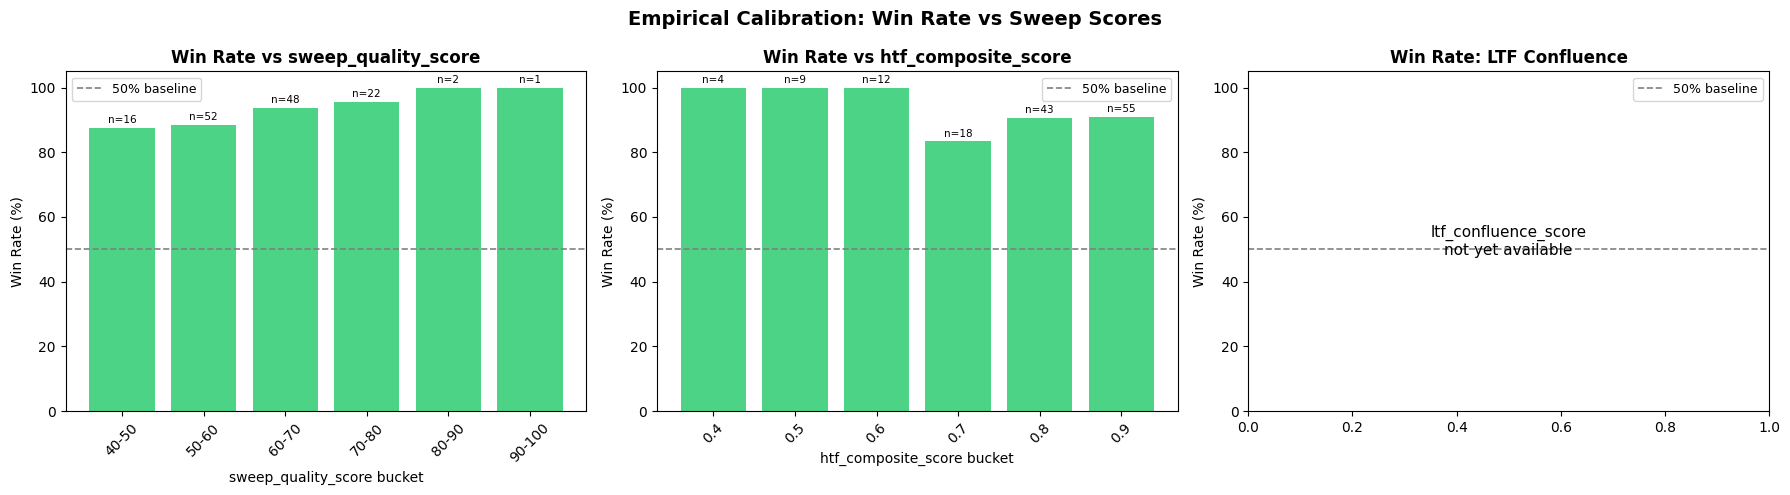

Saved: outputs/sweeps_calibration_nomidas.png

────────────────────────────────────────────────────────────
STEP 5: EMPIRICAL THRESHOLD RECOMMENDATIONS
────────────────────────────────────────────────────────────

  sweep_quality_score:
    Current gate  : none (all bars pass)
    Optimal gate  : >= 75  →  100.0% win rate  (n=15)
    → Step 6: set  MIN_SWEEP_QUALITY = 75

  htf_composite_score:
    Current gate  : MIN_ZONE_CONVICTION = 0.05 (floor only)
    Optimal gate  : >= 0.05  →  91.5% win rate  (n=141)
    → Step 6: set  MIN_ZONE_CONVICTION = 0.05
────────────────────────────────────────────────────────────


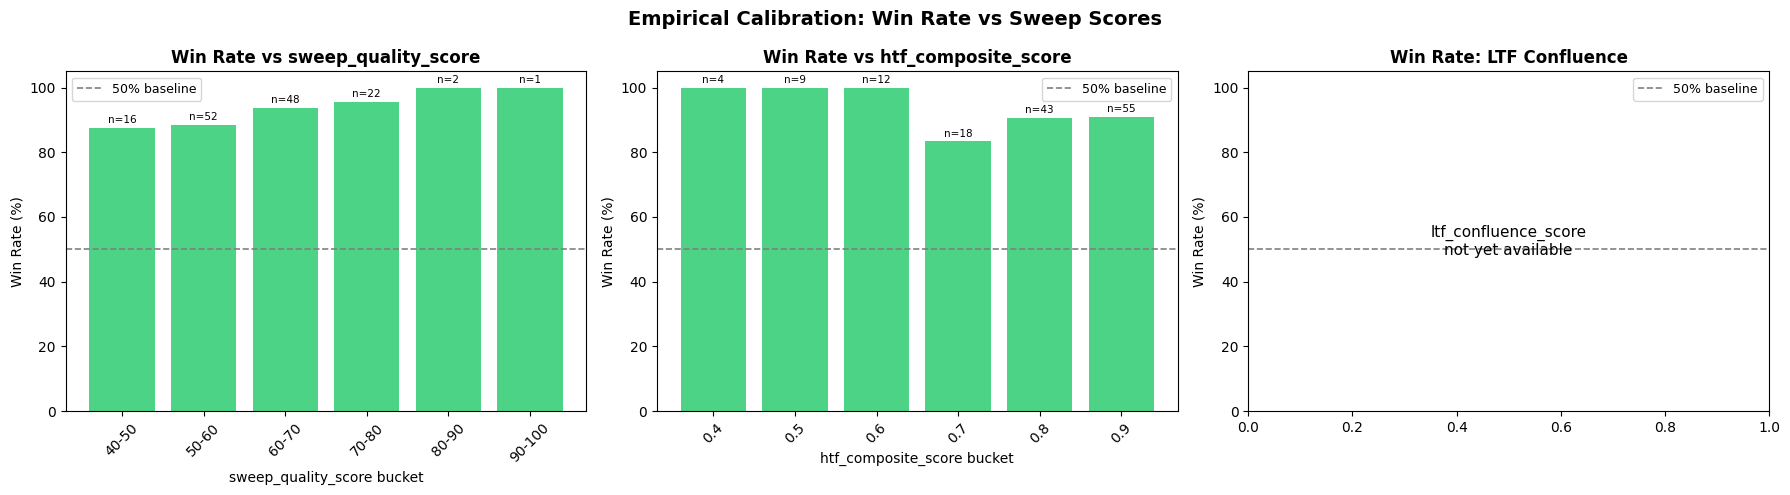

Saved: outputs/sweeps_calibration_withmidas.png

────────────────────────────────────────────────────────────
STEP 5: EMPIRICAL THRESHOLD RECOMMENDATIONS
────────────────────────────────────────────────────────────

  sweep_quality_score:
    Current gate  : none (all bars pass)
    Optimal gate  : >= 75  →  100.0% win rate  (n=15)
    → Step 6: set  MIN_SWEEP_QUALITY = 75

  htf_composite_score:
    Current gate  : MIN_ZONE_CONVICTION = 0.05 (floor only)
    Optimal gate  : >= 0.05  →  91.5% win rate  (n=141)
    → Step 6: set  MIN_ZONE_CONVICTION = 0.05
────────────────────────────────────────────────────────────
ROLLING WALK-FORWARD PIPELINE SUMMARY
  Hourly bars scanned          : 6577
  Walk-forward steps           : 934 days

  HTF identify_zones calls     : ~311  (every 3 steps, cached)
  HTF update_zone_lifecycle    : 934  (every step — decay/breach/flip/kill)

  LTF identify_zones calls     : ~934  (every 1 steps, cached)
  LTF update_zone_lifecycle    : 934  (every step — dec

In [56]:
# =============================================================================
# PART 8  MAIN EXECUTION — ROLLING WALK-FORWARD (DAILY STEPPING)
#
# Cadence
# ───────
# identify_liquidity_zones  HTF  — rebuild every HTF_PIVOT_WINDOW steps
#                                   lifecycle updated every step
# identify_liquidity_zones  LTF  — rebuild every LTF_REBUILD_EVERY steps
#                                   lifecycle updated every step (prunes dead zones)
# identify_sweeps_in_zones       — every step, today's sweeps only (== cutoff_ts)
#
# Zone lifecycle covers: decay, breach detection, flip confirmation, kill expiry
# =============================================================================

print('=' * 80)
print('RUNNING ROLLING WALK-FORWARD PIPELINE')
print('=' * 80)


# ── 1. Safety check ───────────────────────────────────────────────────────────
required_globals = [
    'reload_daily', 'reload_hourly',
    'HTF_PIVOT_WINDOW', 'LTF_PIVOT_WINDOW',
    'VOL_ROLL_WINDOW', 'VOL_SPIKE_THRESHOLD',
    'identify_liquidity_zones', 'update_zone_lifecycle',
    'evaluate_zone_state', 'identify_sweeps_in_zones',
    'classify_zone_type_func', 'rank_zones_by_conviction',
    'detect_previous_day_levels', 'detect_previous_week_levels',
]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(f'Missing globals: {missing}. Run Parts 1–6 first.')


# ── 2. Config defaults ────────────────────────────────────────────────────────
def _cfg(name, default):
    return globals().get(name, default)

HTF_PIVOT_WINDOW       = _cfg('HTF_PIVOT_WINDOW',       3)
LTF_PIVOT_WINDOW       = _cfg('LTF_PIVOT_WINDOW',       5)
HTF_LOOKBACK_DAYS      = _cfg('HTF_LOOKBACK_DAYS',      365)
LTF_LOOKBACK_DAYS      = _cfg('LTF_LOOKBACK_DAYS',      30)
USE_HTF_CONFLUENCE     = _cfg('USE_HTF_CONFLUENCE',     True)
USE_DYNAMIC_PIVOT_WINDOW = _cfg('USE_DYNAMIC_PIVOT_WINDOW', True)
HTF_VOL_MULT           = _cfg('HTF_VOL_MULT',           1.2)
LTF_VOL_MULT           = _cfg('LTF_VOL_MULT',           1.2)
HTF_MIN_TOUCHES        = _cfg('HTF_MIN_TOUCHES',        1)
HTF_ABSORPTION_SCORE   = _cfg('HTF_ABSORPTION_SCORE',   0.0)
VOL_PROFILE_BIN_PCT    = _cfg('VOL_PROFILE_BIN_PCT',    1.0)
MIDAS_CONFIRM_PCT      = _cfg('MIDAS_CONFIRM_PCT',      50)
USE_MIDAS              = _cfg('USE_MIDAS',              False)
HTF_ZONE_DECAY_HALF    = _cfg('HTF_ZONE_DECAY_HALF',    120)
HTF_FLIP_CONFIRM_DAYS  = _cfg('HTF_FLIP_CONFIRM_DAYS',  20)
LTF_FLIP_CONFIRM_DAYS  = _cfg('LTF_FLIP_CONFIRM_DAYS',  5)
HTF_ZONE_KILL_EXPIRY   = _cfg('HTF_ZONE_KILL_EXPIRY_DAYS', 30)
LTF_ZONE_KILL_EXPIRY   = _cfg('LTF_ZONE_KILL_EXPIRY_DAYS', 7)
HTF_MERGE_MAX_AGE      = _cfg('HTF_MERGE_MAX_AGE_DAYS', 60)
LTF_MERGE_MAX_AGE      = _cfg('LTF_MERGE_MAX_AGE_DAYS', 14)
SWEEP_DETECTION_MODE   = _cfg('SWEEP_DETECTION_MODE', 1)

# LTF cache cadence — rebuild every N steps (hourly pivots shift ~every 2–3 hours)
# Half the LTF pivot window is a good balance: fresh enough, not redundant
LTF_REBUILD_EVERY  = max(1, LTF_PIVOT_WINDOW // 2)
LTF_DYN_PIVOT_BASE = LTF_PIVOT_WINDOW


# ── 3. Prepare base DataFrames ────────────────────────────────────────────────
df_daily  = reload_daily.copy()
df_daily.columns  = [c.lower() for c in df_daily.columns]
df_hourly = reload_hourly.copy()
df_hourly.columns = [c.lower() for c in df_hourly.columns]

VOL_ALIASES = ['tickvolume', 'realvolume', 'vol', 'qty', 'quantity',
               'tick_volume', 'real_volume']
for df, name in [(df_daily, 'daily'), (df_hourly, 'hourly')]:
    if 'volume' not in df.columns:
        for alias in VOL_ALIASES:
            if alias in df.columns:
                df.rename(columns={alias: 'volume'}, inplace=True)
                print(f'  Info: {name} renamed {alias!r} → volume')
                break
        else:
            print(f'  Warning: no volume column in {name} — vol filters disabled.')

for col in ('open', 'high', 'low', 'close'):
    if col not in df_hourly.columns:
        raise KeyError(f'Required column {col!r} not found in hourly data.')


# ── 4. Build full hourly candle metrics (once) ────────────────────────────────
print('Step 4  Building hourly candle metrics...')
hourly_data = df_hourly.copy()
hourly_data['timestamp'] = pd.to_datetime(hourly_data.index).tz_localize(None)

hourly_data['body']        = (hourly_data['close'] - hourly_data['open']).abs()
hourly_data['total_range'] = hourly_data['high'] - hourly_data['low']
hourly_data['wick_ratio']  = (
    1.0 - hourly_data['body'] /
    hourly_data['total_range'].replace(0, np.nan)
).fillna(0.0).clip(0.0, 1.0)

vol_roll = hourly_data['volume'].rolling(VOL_ROLL_WINDOW, min_periods=5)
vol_mean = vol_roll.mean()
vol_std  = vol_roll.std()
hourly_data['volume_zscore'] = (
    (hourly_data['volume'] - vol_mean) / (vol_std + 1e-9)
).fillna(0)
hourly_data['volume_spike'] = (
    hourly_data['volume'] > vol_mean * VOL_SPIKE_THRESHOLD + vol_std
).astype(int)

atr_hourly = atr(hourly_data, length=14)
vol_ratio  = hourly_data['volume'] / vol_mean.replace(0, np.nan)
body_norm  = hourly_data['body'] / atr_hourly.replace(0, np.nan).clip(lower=0.01)
hourly_data['absorption_score'] = (
    vol_ratio * body_norm
).replace(0, np.nan).fillna(0).clip(lower=0)
hourly_data['date'] = hourly_data['timestamp'].dt.normalize()

print(f'  hourly_data shape   : {hourly_data.shape}')
print(f'  volume_zscore range : {hourly_data["volume_zscore"].min():.2f}'
      f' – {hourly_data["volume_zscore"].max():.2f}')
print(f'  absorption_score max: {hourly_data["absorption_score"].max():.2f}')
print(f'  volume_spike count  : {hourly_data["volume_spike"].sum()} bars flagged')
print(f'  wick_ratio range    : {hourly_data["wick_ratio"].min():.3f}'
      f' – {hourly_data["wick_ratio"].max():.3f}')


# ── 5. Column normalisation helper ────────────────────────────────────────────
def normalise_zone_cols(df):
    """Rename any legacy Title-case zone columns to camelCase (v3 convention)."""
    return df.rename(columns={
        'FirstTime': 'firsttime',  'first_time': 'firsttime',
        'LastTime':  'lasttime',   'last_time':  'lasttime',
        'ZoneId':    'zoneid',     'zone_id':    'zoneid',
        'ZoneSide':  'zoneside',   'zone_side':  'zoneside',
        'ZoneType':  'zonetype',   'zone_type':  'zonetype',
    })


# ── 6. Walk-forward setup ─────────────────────────────────────────────────────
print('=' * 80)
print('ROLLING WALK-FORWARD  Daily Stepping')
print('=' * 80)

MIN_WARMUP_BARS = HTF_PIVOT_WINDOW * 2
daily_dates     = df_daily.index[df_daily.index > df_daily.index[MIN_WARMUP_BARS]]
total_days      = len(daily_dates)

all_sweeps_no_midas   = []
all_sweeps_with_midas = []

# ── HTF zone structure cache ──────────────────────────────────────────────────
# Rebuilt every HTF_PIVOT_WINDOW steps. Between rebuilds, only lifecycle
# (decay / breach / flip / kill) is updated — structure is frozen.
htf_cached_zones_raw    = None
htf_cached_enriched_raw = None
htf_last_rebuild_step   = -(HTF_PIVOT_WINDOW + 1)   # force rebuild on step 0

# ── LTF zone structure cache ──────────────────────────────────────────────────
# Rebuilt every LTF_REBUILD_EVERY steps. Hourly pivots shift slowly enough
# that a 2–3 step cache is valid. Lifecycle still updated every step.
ltf_cached_zones_raw  = None
ltf_last_rebuild_step = -(LTF_REBUILD_EVERY + 1)    # force rebuild on step 0

print(f'  Walk-forward from        : {daily_dates[0].date()}')
print(f'  Walk-forward to          : {daily_dates[-1].date()}')
print(f'  Total steps              : {total_days} days')
print(f'  Warm-up bars             : {MIN_WARMUP_BARS}')
print(f'  HTF rebuild every        : {HTF_PIVOT_WINDOW} steps  (~{total_days // HTF_PIVOT_WINDOW} calls)')
print(f'  HTF lifecycle update     : every step  ({total_days} calls)')
print(f'  LTF rebuild every        : {LTF_REBUILD_EVERY} steps  (~{total_days // LTF_REBUILD_EVERY} calls)')
print(f'  LTF lifecycle update     : every step  ({total_days} calls)')
print(f'  HTF confluence           : {"ON" if USE_HTF_CONFLUENCE else "OFF"}')
print(f'  Flip confirm (HTF/LTF)   : {HTF_FLIP_CONFIRM_DAYS}d / {LTF_FLIP_CONFIRM_DAYS}d')
print(f'  Kill expiry  (HTF/LTF)   : {HTF_ZONE_KILL_EXPIRY}d / {LTF_ZONE_KILL_EXPIRY}d')
print()


# ── 7. Main loop ──────────────────────────────────────────────────────────────
for step, cutoff_date in enumerate(daily_dates):

    sweep_count_nm = 0
    sweep_count_wm = 0

    # ── a. Daily slice (no look-ahead) ────────────────────────────────────────
    daily_slice = df_daily[df_daily.index < cutoff_date]
    if len(daily_slice) < MIN_WARMUP_BARS:
        continue

    cutoff_ts = pd.Timestamp(cutoff_date.date())
    day_mask  = hourly_data['date'] == cutoff_ts
    if not day_mask.any():
        continue


    # ── b. HTF zone STRUCTURE rebuild ─────────────────────────────────────────
    # Only when a new daily pivot could have formed.
    # Merge guards (NOMERGESTATES, max-age, max-touch) fire inside
    # identify_liquidity_zones v3 automatically.
    htf_needs_rebuild = (
        htf_cached_zones_raw is None or
        (step - htf_last_rebuild_step) >= HTF_PIVOT_WINDOW
    )

    if htf_needs_rebuild:
        try:
            daily_lvl  = detect_previous_day_levels(daily_slice)
            weekly_lvl = detect_previous_week_levels(daily_slice)

            _, htf_zones_raw, htf_enriched_raw, _, _ = identify_liquidity_zones(
                daily_slice,
                pivot_left_right        = HTF_PIVOT_WINDOW,
                dynamic_pivot_window    = USE_DYNAMIC_PIVOT_WINDOW,
                atr_len                 = 14,
                atr_merge_mult          = 0.75,
                require_volume          = True,
                vol_len                 = 20,
                vol_mult                = HTF_VOL_MULT,
                min_touches             = HTF_MIN_TOUCHES,
                unique_pivots           = False,
                use_both_high_low_pivots= True,
                min_absorption          = HTF_ABSORPTION_SCORE,
                max_merge_gap_days      = HTF_MERGE_MAX_AGE,
                vol_profile_bin         = VOL_PROFILE_BIN_PCT,
                midas_df                = (midas_df
                                           if USE_MIDAS and 'midas_df' in globals()
                                           else None),
                midas_confirm_pct       = MIDAS_CONFIRM_PCT,
            )

            if htf_zones_raw is not None and not htf_zones_raw.empty:
                htf_zones_raw    = classify_zone_type_func(htf_zones_raw, daily_lvl, weekly_lvl)
                htf_zones_raw    = rank_zones_by_conviction(htf_zones_raw)
                htf_zones_raw    = normalise_zone_cols(htf_zones_raw)

                if htf_enriched_raw is not None and not htf_enriched_raw.empty:
                    htf_enriched_raw = classify_zone_type_func(htf_enriched_raw, daily_lvl, weekly_lvl)
                    htf_enriched_raw = rank_zones_by_conviction(htf_enriched_raw)
                    htf_enriched_raw = normalise_zone_cols(htf_enriched_raw)

                htf_cached_zones_raw    = htf_zones_raw
                htf_cached_enriched_raw = htf_enriched_raw

            htf_last_rebuild_step = step

        except Exception as e:
            print(f'  {cutoff_date.date()} HTF zone detection failed: {type(e).__name__}: {e}')
            continue

    if htf_cached_zones_raw is None or htf_cached_zones_raw.empty:
        continue


    # ── c. HTF zone LIFECYCLE — every step ────────────────────────────────────
    # Updates per-zone: breach detection, flip confirmation, kill expiry,
    # decay factor, zonestate, zoneagebars, sweepmaturity.
    # Does NOT rebuild structural top/bottom — cache preserves those.
    try:
        htf_zones = update_zone_lifecycle(
            htf_cached_zones_raw,
            cutoff_ts,
            hourly_data,
            lookbackdays       = HTF_LOOKBACK_DAYS,
            invalidationbuffer = 1.0,
        )
    except Exception as e:
        print(f'  {cutoff_date.date()} HTF lifecycle failed: {type(e).__name__}: {e}')
        continue

    if htf_zones is None or htf_zones.empty:
        continue

    # Filter out dead/killed zones — keep active, tested, breached, flipped
    # Dead zones have state='dead' or flipcount>=2; exclude them from confluence
    _live_states = {'active', 'tested', 'mitigated', 'breached', 'flipped'}
    if 'zonestate' in htf_zones.columns:
        # Fix 2: prune dead from cache BEFORE filtering htf_zones
        _alive = htf_zones['zonestate'] != 'dead'
        htf_cached_zones_raw = htf_cached_zones_raw.loc[_alive.values].copy()
        # Now filter for sweep detection
        htf_zones = htf_zones[htf_zones['zonestate'].isin(_live_states)].copy()


    htf_zones_enriched = None
    if htf_cached_enriched_raw is not None and not htf_cached_enriched_raw.empty:
        try:
            htf_zones_enriched = update_zone_lifecycle(
                htf_cached_enriched_raw,
                cutoff_ts,
                hourly_data,
                lookbackdays       = HTF_LOOKBACK_DAYS,
                invalidationbuffer = 1.0,
            )
            if htf_zones_enriched is not None and 'state' in htf_zones_enriched.columns:
                htf_zones_enriched = htf_zones_enriched[
                    htf_zones_enriched['state'].isin(_live_states)
                ].copy()
        except Exception as e:
            print(f'  {cutoff_date.date()} HTF enriched lifecycle failed: {type(e).__name__}: {e}')
            htf_zones_enriched = None


    # ── d. LTF zone STRUCTURE rebuild ─────────────────────────────────────────
    # Cached every LTF_REBUILD_EVERY steps. Hourly pivots need ~2–3 confirmed
    # bars, so rebuilding every 2 steps is fine without structural staleness.
    if SWEEP_DETECTION_MODE == 3:
        ltf_needs_rebuild = False
        # zones_df_ltf = __import__(\"pandas\").DataFrame()
    else:
        ltf_needs_rebuild = (
            ltf_cached_zones_raw is None or
            (step - ltf_last_rebuild_step) >= LTF_REBUILD_EVERY
        )

    if ltf_needs_rebuild:
        ltf_start_ts     = cutoff_ts - pd.Timedelta(days=LTF_LOOKBACK_DAYS)
        hourly_slice_ltf = hourly_data.loc[
            (hourly_data.index >= ltf_start_ts) &
            (hourly_data.index <= cutoff_ts)
        ].copy()

        if len(hourly_slice_ltf) >= LTF_DYN_PIVOT_BASE * 2 + 5:
            try:
                _, ltf_raw, _, _, _ = identify_liquidity_zones(
                    hourly_slice_ltf,
                    pivot_left_right        = LTF_DYN_PIVOT_BASE,
                    atr_len                 = 14,
                    atr_merge_mult          = 1.0,
                    dynamic_pivot_window    = USE_DYNAMIC_PIVOT_WINDOW,
                    require_volume          = True,
                    vol_len                 = VOL_ROLL_WINDOW,
                    vol_mult                = LTF_VOL_MULT,
                    min_absorption          = 0.0,
                    max_merge_gap_days      = LTF_MERGE_MAX_AGE,
                    midas_df                = None,
                    midas_confirm_pct       = 50,
                    zone_source             = "ltf",          # ← ADD
                    flip_confirm_days       = LTF_FLIP_CONFIRM_DAYS,  # ← ADD (optional, redundant if zone_source works, but explicit)
                )

                if ltf_raw is not None and not ltf_raw.empty:
                    ltf_raw = classify_zone_type_func(ltf_raw, daily_lvl, weekly_lvl)
                    ltf_raw = rank_zones_by_conviction(ltf_raw)
                    ltf_raw = normalise_zone_cols(ltf_raw)
                    ltf_cached_zones_raw = ltf_raw
                else:
                    ltf_cached_zones_raw = pd.DataFrame()

                ltf_last_rebuild_step = step

            except Exception as e:
                print(f'  {cutoff_date.date()} LTF zone detection failed: {type(e).__name__}: {e}')
                ltf_cached_zones_raw = pd.DataFrame()
                ltf_last_rebuild_step = step


    # ── e. LTF zone LIFECYCLE — every step ────────────────────────────────────
    # Run on the cached LTF structure to: prune dead/killed zones,
    # update breach_pending → flipped → dead state machine,
    # and decay conviction scores for stale zones.
    # Tighter invalidation_buffer (0.2%) vs HTF (1.0%) — hourly zones are precise.
    zones_df_ltf = pd.DataFrame()

    if ltf_cached_zones_raw is not None and not ltf_cached_zones_raw.empty:
        try:
            zones_df_ltf = update_zone_lifecycle(
                ltf_cached_zones_raw,
                cutoff_ts,
                hourly_data,
                lookbackdays       = LTF_LOOKBACK_DAYS,
                invalidationbuffer = 0.5,
            )
            # Drop dead zones — sweep detector should not target structurally
            if zones_df_ltf is not None and 'zonestate' in zones_df_ltf.columns:
                # Fix 2: prune dead from cache BEFORE filtering
                _alive_ltf = zones_df_ltf['zonestate'] != 'dead'
                ltf_cached_zones_raw = ltf_cached_zones_raw.loc[_alive_ltf.values].copy()
                # Now filter for sweep detection
                zones_df_ltf = zones_df_ltf[zones_df_ltf['zonestate'].isin(_live_states)].copy()
            else:
                zones_df_ltf = pd.DataFrame()

        except Exception as e:
            print(f'  {cutoff_date.date()} LTF lifecycle failed: {type(e).__name__}: {e}')
            zones_df_ltf = pd.DataFrame()

    # No live LTF zones → no sweep targets for this step
    if zones_df_ltf is None or zones_df_ltf.empty:
        continue


    # ── f. Sweep detection — no MIDAS ─────────────────────────────────────────
    # Primary sweep targets : LTF live zones (post-lifecycle)
    # HTF confluence         : soft scorer only — NOT a hard gate
    # cutoffdate             : prevents identify_sweeps_in_zones from scanning
    #                          future bars (critical for walk-forward integrity)
    # == cutoff_ts filter    : captures only today's sweeps per step so that
    #                          pd.concat produces one row per event, not O(N²)
    # ── Sweep detection modes ──
    if SWEEP_DETECTION_MODE == 3:
        p_nm = htf_zones; h_nm = None
        p_wm = htf_zones_enriched if USE_MIDAS else None; h_wm = None
        fb = False
    elif SWEEP_DETECTION_MODE == 2:
        p_nm = zones_df_ltf; h_nm = htf_zones if USE_HTF_CONFLUENCE else None
        p_wm = zones_df_ltf; h_wm = htf_zones_enriched if USE_HTF_CONFLUENCE else None
        fb = True
    else:
        p_nm = zones_df_ltf; h_nm = htf_zones if USE_HTF_CONFLUENCE else None
        p_wm = zones_df_ltf; h_wm = htf_zones_enriched if USE_HTF_CONFLUENCE else None
        fb = False

    try:
        sweeps_nm = identify_sweeps_in_zones(zonesdf=p_nm, pricedata=hourly_data, midasmode=False, htfzonesdf=h_nm, verbose=False, cutoffdate=cutoff_date, strictfallback=fb)
        if not sweeps_nm.empty and 'timestamp' in sweeps_nm.columns:
            sweep_dates_nm = (
                pd.to_datetime(sweeps_nm['timestamp'])
                .dt.tz_localize(None)
                .dt.normalize()
            )
            # == today only: each step contributes exactly one day's events
            sweeps_nm = sweeps_nm[sweep_dates_nm == cutoff_ts].copy()

        if not sweeps_nm.empty:
            sweeps_nm['cutoff_date'] = cutoff_date.date()
            all_sweeps_no_midas.append(sweeps_nm)
            sweep_count_nm = len(sweeps_nm)

    except Exception as e:
        print(f'  {cutoff_date.date()} Sweep no-MIDAS failed: {type(e).__name__}: {e}')


    # ── g. Sweep detection — with MIDAS enriched confluence ───────────────────
    if htf_zones_enriched is not None and not htf_zones_enriched.empty:
        try:
            sweeps_wm = identify_sweeps_in_zones(zonesdf=p_wm, pricedata=hourly_data, midasmode=True, htfzonesdf=h_wm, verbose=False, cutoffdate=cutoff_date, strictfallback=fb)
            if not sweeps_wm.empty and 'timestamp' in sweeps_wm.columns:
                sweep_dates_wm = (
                    pd.to_datetime(sweeps_wm['timestamp'])
                    .dt.tz_localize(None)
                    .dt.normalize()
                )
                sweeps_wm = sweeps_wm[sweep_dates_wm == cutoff_ts].copy()

            if not sweeps_wm.empty:
                sweeps_wm['cutoff_date'] = cutoff_date.date()
                all_sweeps_with_midas.append(sweeps_wm)
                sweep_count_wm = len(sweeps_wm)

        except Exception as e:
            print(f'  {cutoff_date.date()} Sweep MIDAS failed: {type(e).__name__}: {e}')


    # ── h. Progress print every 50 steps ──────────────────────────────────────
    if (step + 1) % 50 == 0:
        nm_total    = sum(len(s) for s in all_sweeps_no_midas)
        wm_total    = sum(len(s) for s in all_sweeps_with_midas)
        htf_rebuilt = 'REBUILT' if htf_needs_rebuild else 'cached'
        ltf_rebuilt = 'REBUILT' if ltf_needs_rebuild else 'cached'
        live_ltf    = len(zones_df_ltf) if not zones_df_ltf.empty else 0
        live_htf    = len(htf_zones)    if not htf_zones.empty    else 0
        print(
            f'  {cutoff_date.date()}  step {step+1:4d}/{total_days}'
            f'  htf={live_htf}z({htf_rebuilt})'
            f'  ltf={live_ltf}z({ltf_rebuilt})'
            f'  sweeps_nm={nm_total}'
            f'  sweeps_wm={wm_total}'
        )


# ── 8. Consolidate and deduplicate ────────────────────────────────────────────
print()
print('Step 8  Consolidating results...')

sweeps_hourly_no_midas = (
    pd.concat(all_sweeps_no_midas, ignore_index=True)
    if all_sweeps_no_midas else pd.DataFrame()
)
sweeps_hourly_with_midas = (
    pd.concat(all_sweeps_with_midas, ignore_index=True)
    if all_sweeps_with_midas else pd.DataFrame()
)

_dedup_cols = ['timestamp', 'zone_level', 'sweep_type']
for label, dfs in [('No MIDAS',   sweeps_hourly_no_midas),
                   ('With MIDAS', sweeps_hourly_with_midas)]:
    if not dfs.empty:
        before = len(dfs)
        # Only dedup on columns that exist
        dedup_on = [c for c in _dedup_cols if c in dfs.columns]
        if dedup_on:
            dfs.drop_duplicates(subset=dedup_on, inplace=True)
        dfs.sort_values('timestamp', inplace=True)
        dfs.reset_index(drop=True, inplace=True)
        print(f'  {label}: {before} raw → {len(dfs)} deduplicated')
    else:
        print(f'  {label}: no sweeps detected')


# ── 9. Label outcomes + Risk Analytics ───────────────────────────────────────
print('Step 9  Labelling sweep outcomes + risk analytics...')


def _label_and_report(df, label):
    if len(df) == 0:
        return df, {}

    # ── Stage 1: Outcome labeling ─────────────────────────────────────────
    df = label_sweep_outcomes(
        df, hourly_data,
        forward_window_days = 2,
        min_move_pct        = 0.5,
    )
    if 'outcome' not in df.columns:
        return df, {}

    oc  = df['outcome'].value_counts()
    lab = df[df['outcome'] != 'TIMEOUT']
    wr  = lab['outcome'].eq('WIN').mean() * 100 if len(lab) > 0 else 0.0
    print(f'  {label}: {oc.to_dict()}  win_rate={wr:.1f}%')

    # HTF confluence lift
    htf_col = next((c for c in ('htfproximityscore', 'htf_proximity_score')
                    if c in lab.columns), None)
    if htf_col:
        with_htf    = lab[lab[htf_col] > 0]
        without_htf = lab[lab[htf_col] == 0]
        wr_with    = with_htf['outcome'].eq('WIN').mean()    * 100 if len(with_htf)    > 0 else 0.0
        wr_without = without_htf['outcome'].eq('WIN').mean() * 100 if len(without_htf) > 0 else 0.0
        print(f'    HTF confluence lift: {wr_with:.1f}% (n={len(with_htf)})'
              f' vs {wr_without:.1f}% (n={len(without_htf)}) without HTF')

    # ── Stage 2 & 3: Risk metrics + stratified audit ──────────────────────
    strat_tables = {}
    if len(lab) >= 10:          # need minimum sample for rolling windows
        df, strat_tables = run_risk_analysis(
            df,
            risk_free_rate = 0.0,
            kelly_fraction = 0.25,
            var_confidence = 0.95,
            rolling_window = min(20, len(lab)),   # cap to sample size
            quality_bins   = [0, 40, 60, 80, 100],
        )
    else:
        print(f'  {label}: only {len(lab)} labeled sweeps — skipping risk analytics (min 10)')

    return df, strat_tables


sweeps_hourly_no_midas,   strat_no_midas   = _label_and_report(sweeps_hourly_no_midas,   'No-MIDAS ')
sweeps_hourly_with_midas, strat_with_midas = _label_and_report(sweeps_hourly_with_midas, 'With-MIDAS')


# ── 10. Calibration plots ─────────────────────────────────────────────────────
print('Step 10  Calibration plots...')
import os
os.makedirs('outputs', exist_ok=True)

if len(sweeps_hourly_no_midas) > 0 and 'outcome' in sweeps_hourly_no_midas.columns:
    plot_win_rate_calibration(
        sweeps_hourly_no_midas,
        save_path='outputs/sweeps_calibration_nomidas.png',
    )
if len(sweeps_hourly_with_midas) > 0 and 'outcome' in sweeps_hourly_with_midas.columns:
    plot_win_rate_calibration(
        sweeps_hourly_with_midas,
        save_path='outputs/sweeps_calibration_withmidas.png',
    )


# ── 11. Summary ───────────────────────────────────────────────────────────────
htf_rebuild_count = total_days // HTF_PIVOT_WINDOW
ltf_rebuild_count = total_days // LTF_REBUILD_EVERY

print('=' * 80)
print('ROLLING WALK-FORWARD PIPELINE SUMMARY')
print('=' * 80)
print(f'  Hourly bars scanned          : {len(hourly_data)}')
print(f'  Walk-forward steps           : {total_days} days')
print()
print(f'  HTF identify_zones calls     : ~{htf_rebuild_count}  (every {HTF_PIVOT_WINDOW} steps, cached)')
print(f'  HTF update_zone_lifecycle    : {total_days}  (every step — decay/breach/flip/kill)')
print()
print(f'  LTF identify_zones calls     : ~{ltf_rebuild_count}  (every {LTF_REBUILD_EVERY} steps, cached)')
print(f'  LTF update_zone_lifecycle    : {total_days}  (every step — decay/breach/flip/kill)')
print()
print(f'  Flip confirm  HTF/LTF        : {HTF_FLIP_CONFIRM_DAYS}d / {LTF_FLIP_CONFIRM_DAYS}d')
print(f'  Kill expiry   HTF/LTF        : {HTF_ZONE_KILL_EXPIRY}d / {LTF_ZONE_KILL_EXPIRY}d')
print(f'  Merge max age HTF/LTF        : {HTF_MERGE_MAX_AGE}d / {LTF_MERGE_MAX_AGE}d')
print()
print(f'  Sweeps no MIDAS              : {len(sweeps_hourly_no_midas)}')
print(f'  Sweeps with MIDAS            : {len(sweeps_hourly_with_midas)}')
print()
print(f'  USE_HTF_CONFLUENCE           : {USE_HTF_CONFLUENCE}')
print(f'  USEZONESIDEROUTING           : {_cfg("USEZONESIDEROUTING", "N/A")}')
print(f'  USESWEEPCOOLDOWN             : {_cfg("USESWEEPCOOLDOWN", "N/A")}')
print(f'  MINZONECONVICTION            : {_cfg("MINZONECONVICTION", "N/A")}')
print('=' * 80)
print('ROLLING WALK-FORWARD PIPELINE COMPLETE')
print('=' * 80)

In [57]:
# ---------------------------------------------------------------------------
# SWEEP DETECTION CANDLESTICK VISUALIZATIONS WITH LIQUIDITY ZONES
# ---------------------------------------------------------------------------

required_vars = ['sweeps_hourly_no_midas', 'sweeps_hourly_with_midas', 'hourly_data']
missing_vars  = [v for v in required_vars if v not in globals()]

if missing_vars:
    print(f"\n⚠ WARNING: Missing variables — {missing_vars}")
    print("Please execute Part 8 first. Skipping visualization...")
else:
    print("\n✓ All required variables present. Proceeding with visualization...")

if not missing_vars:

    print("\n" + "=" * 70)
    print("VISUALIZING TOP SWEEPS — CANDLESTICK CHARTS WITH LIQUIDITY ZONES")
    print("=" * 70)

    import plotly.graph_objects as go

    price_data = hourly_data.copy()
    print(f"\n✓ Hourly data: {len(price_data)} candles")
    print(f"  Date range: {price_data['timestamp'].min().date()} → "
          f"{price_data['timestamp'].max().date()}")

    print(f"\nSweep data check:")
    print(f"  NO MIDAS  : {len(sweeps_hourly_no_midas)} total sweeps")
    if len(sweeps_hourly_no_midas) > 0:
        print(f"    Bullish : {(sweeps_hourly_no_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    Bearish : {(sweeps_hourly_no_midas['sweep_type']=='BEARISH').sum()}")
    print(f"  WITH MIDAS: {len(sweeps_hourly_with_midas)} total sweeps")
    if len(sweeps_hourly_with_midas) > 0:
        print(f"    Bullish : {(sweeps_hourly_with_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    Bearish : {(sweeps_hourly_with_midas['sweep_type']=='BEARISH').sum()}")


    def make_candlestick_chart_with_zones(
        price_df, sweep_timestamp, zone_level,
        zone_top, zone_bottom,
        sweep_type, chart_title
    ):
        try:
            # ── exact-hour timestamp match ────────────────────────────────────
            sweep_ts       = pd.to_datetime(sweep_timestamp)
            sweep_ts_naive = sweep_ts.tz_localize(None) if sweep_ts.tzinfo else sweep_ts
            ts_col_naive   = pd.to_datetime(price_df['timestamp']).dt.tz_localize(None)

            exact = price_df[ts_col_naive == sweep_ts_naive]
            sweep_idx = exact.index[0] if len(exact) > 0 else (
                (ts_col_naive - sweep_ts_naive).abs().idxmin()
            )

            sweep_pos = price_df.index.get_loc(sweep_idx)
            start_pos = max(0, sweep_pos - 15)
            end_pos   = min(len(price_df) - 1, sweep_pos + 10)

            subset = price_df.iloc[start_pos : end_pos + 1].copy().reset_index(drop=True)
            subset['candle_idx'] = range(len(subset))

            # FIX: build hover text as a list — Candlestick uses `text`, not `hovertemplate`
            hover_texts = [
                (f"{row['timestamp'].strftime('%Y-%m-%d %H:%M')}<br>"
                 f"O: ${row['open']:.2f}  H: ${row['high']:.2f}<br>"
                 f"L: ${row['low']:.2f}   C: ${row['close']:.2f}")
                for _, row in subset.iterrows()
            ]

            # ── candlestick ───────────────────────────────────────────────────
            fig = go.Figure(data=[go.Candlestick(
                x=subset['candle_idx'],
                open=subset['open'],  high=subset['high'],
                low=subset['low'],    close=subset['close'],
                name='Price',
                text=hover_texts,          # ← was hovertemplate (unsupported)
                hoverinfo='text',          # tell Plotly to show our text on hover
            )])

            # ── ICT-correct zone labels + actual boundaries ───────────────────
            if sweep_type == 'BULLISH':
                fill_color = 'rgba(0,180,0,0.12)'
                line_color = 'green'
                zone_label = 'SELL-SIDE LIQUIDITY (SSL)'
            else:
                fill_color = 'rgba(220,0,0,0.12)'
                line_color = 'red'
                zone_label = 'BUY-SIDE LIQUIDITY (BSL)'

            fig.add_hrect(
                y0=zone_bottom, y1=zone_top,
                fillcolor=fill_color, opacity=1.0,
                layer='below', line_width=0,
            )
            fig.add_hline(
                y=zone_level,
                line_width=2.5, line_dash='dash', line_color=line_color,
                annotation_text=f'{zone_label}<br>${zone_level:.2f}',
                annotation_position='right',
                annotation=dict(font_size=11, bgcolor='rgba(255,255,255,0.85)')
            )
            for y_val in [zone_top, zone_bottom]:
                fig.add_hline(
                    y=y_val, line_width=1, line_dash='dot', line_color=line_color,
                    annotation_text=f'${y_val:.2f}', annotation_position='left',
                    annotation=dict(font_size=9, font_color=line_color)
                )

            # ── sweep marker ──────────────────────────────────────────────────
            sweep_subset_pos = sweep_pos - start_pos
            if 0 <= sweep_subset_pos < len(subset):
                row_c = subset.iloc[sweep_subset_pos]
                cr    = row_c['high'] - row_c['low']
                arrow_y = (row_c['high'] + cr * 0.5 if sweep_type == 'BULLISH'
                           else row_c['low'] - cr * 0.5)
                fig.add_annotation(
                    x=row_c['candle_idx'], y=arrow_y,
                    text='★', showarrow=False,
                    font=dict(size=28, color='purple'),
                    xanchor='center'
                )

            fig.update_layout(
                title=dict(text=chart_title, font=dict(size=14)),
                yaxis_title='Price (USD)',
                xaxis_title='Candle Index (continuous — no time gaps)',
                template='plotly_white',
                height=550, width=1150,
                hovermode='x unified',
                xaxis_rangeslider_visible=False,
                xaxis=dict(type='linear'),
                showlegend=True,
                font=dict(size=11),
                margin=dict(l=80, r=160, t=100, b=80),
            )
            return fig

        except Exception as e:
            print(f"      ✗ Error ({type(e).__name__}): {e}")
            return None


    def plot_sweep_set(sweeps_df, label):
        if sweeps_df.empty:
            print(f"\n✗ No sweeps in {label} dataset")
            return

        print(f"\n{'=' * 70}")
        print(f"{label} SWEEPS WITH LIQUIDITY ZONES")
        print('=' * 70)

        for sweep_type, side_label in [
            ('BULLISH', 'SSL Raids (demand zone sweeps — bullish reversal)'),
            ('BEARISH', 'BSL Raids (supply zone sweeps — bearish reversal)'),
        ]:
            subset = (
                sweeps_df[sweeps_df['sweep_type'] == sweep_type]
                .nlargest(3, 'sweep_quality_score')
            )
            print(f"\n{side_label}  ({len(subset)} shown):")

            for i, (_, row) in enumerate(subset.iterrows(), 1):
                z_top = float(row.get('zone_top',    row['zone_level'] * 1.005))
                z_bot = float(row.get('zone_bottom', row['zone_level'] * 0.995))

                title = (
                    f"{sweep_type} SWEEP #{i} ({label}) | "
                    f"Quality: {row['sweep_quality_score']:.0f}/100 | "
                    f"Reversal: ${row['reversal_distance']:.2f} | "
                    f"HTF score: {row.get('htf_proximity_score', 0):.2f}"
                )
                print(f"  {i}. {row['timestamp']}  zone=${row['zone_level']:.2f}")

                fig = make_candlestick_chart_with_zones(
                    price_data,
                    sweep_timestamp = row['timestamp'],
                    zone_level      = row['zone_level'],
                    zone_top        = z_top,
                    zone_bottom     = z_bot,
                    sweep_type      = sweep_type,
                    chart_title     = title,
                )
                if fig:
                    fig.show()
                else:
                    print("      → Could not create chart")


    plot_sweep_set(sweeps_hourly_no_midas,   'NO MIDAS')
    plot_sweep_set(sweeps_hourly_with_midas, 'WITH MIDAS')

    print("\n" + "=" * 70)
    print("✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE")
    print("=" * 70)
    print("\nVISUAL LEGEND:")
    print("  🟢 GREEN ZONE : Demand zone — SSL raid (BULLISH sweep, reversal up)")
    print("  🔴 RED ZONE   : Supply zone — BSL raid (BEARISH sweep, reversal down)")
    print("  ★ Star        : Exact sweep detection candle")
    print("  - - Dashed    : Zone midline (zone_level)")
    print("  ··· Dotted    : Actual zone top / bottom boundaries")


✓ All required variables present. Proceeding with visualization...

VISUALIZING TOP SWEEPS — CANDLESTICK CHARTS WITH LIQUIDITY ZONES

✓ Hourly data: 6577 candles
  Date range: 2021-01-04 → 2024-09-30

Sweep data check:
  NO MIDAS  : 141 total sweeps
    Bullish : 72
    Bearish : 69
  WITH MIDAS: 141 total sweeps
    Bullish : 72
    Bearish : 69

NO MIDAS SWEEPS WITH LIQUIDITY ZONES

SSL Raids (demand zone sweeps — bullish reversal)  (3 shown):
  1. 2021-08-12 11:30:00  zone=$238.52


  2. 2021-12-23 11:30:00  zone=$350.75


  3. 2021-12-23 11:30:00  zone=$351.01



BSL Raids (supply zone sweeps — bearish reversal)  (3 shown):
  1. 2022-06-03 10:30:00  zone=$236.50


  2. 2022-06-23 11:30:00  zone=$234.63


...

  3. 2021-12-23 11:30:00  zone=$351.01



BSL Raids (supply zone sweeps — bearish reversal)  (3 shown):
  1. 2022-06-03 10:30:00  zone=$236.50


  2. 2022-06-23 11:30:00  zone=$234.63


  3. 2022-06-23 11:30:00  zone=$236.49



✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE

VISUAL LEGEND:
  🟢 GREEN ZONE : Demand zone — SSL raid (BULLISH sweep, reversal up)
  🔴 RED ZONE   : Supply zone — BSL raid (BEARISH sweep, reversal down)
  ★ Star        : Exact sweep detection candle
  - - Dashed    : Zone midline (zone_level)
  ··· Dotted    : Actual zone top / bottom boundaries


In [58]:
# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------
def plot_zones_matplotlib(
    df: pd.DataFrame,
    zones_df: pd.DataFrame,
    start_date: str = None,
    end_date: str = None,
    title: str = "Zones",
    save_dir: str = ".",
):
    import matplotlib.pyplot as plt

    if df.empty:
        return

    tail = df.loc[start_date:end_date] if (start_date and end_date) else df.tail(250)
    if tail.empty:
        print("No data in the specified date range.")
        return

    x = np.arange(len(tail))
    dates = tail.index
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.fill_between(x, tail["low"].values, tail["high"].values, color="lightblue", alpha=0.25, label="High-Low range")
    ax.plot(x, tail["close"].values, label="Close", color="black", linewidth=1)

    if "pivot_high_level" in tail.columns:
        ph_mask = ~tail["pivot_high_level"].isna()
        ax.scatter(x[ph_mask], tail["pivot_high_level"].values[ph_mask], marker="v", color="red", s=30, zorder=5, label="Pivot High")
    if "pivot_low_level" in tail.columns:
        pl_mask = ~tail["pivot_low_level"].isna()
        ax.scatter(x[pl_mask], tail["pivot_low_level"].values[pl_mask], marker="^", color="green", s=30, zorder=5, label="Pivot Low")

    if zones_df is not None and not zones_df.empty:
        for _, z in zones_df.iterrows():
            mask = (dates >= z["first_time"]) & (dates <= z["last_time"])
            x_zone = x[mask]
            if len(x_zone) == 0:
                continue
            ax.fill_between(x_zone, z["bottom"], z["top"], color="orange", alpha=0.35, label=f"Zone {z['zone_id']}")

    ax.set_title(title)
    ax.set_xticks(x[::max(1, len(x) // 10)])
    ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in dates[::max(1, len(x) // 10)]], rotation=45)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), fontsize=7, loc="upper left",
              bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, title.replace(" ", "_").replace("/", "-") + ".png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Chart saved to {save_path}")
    plt.show()


## Part 9 - Export Sweeps to CSV & Generate Individual Images for ML Labeling

In [59]:
# ---------------------------------------------------------------------------
# Function to generate sweep detail summary for CSV export
# ---------------------------------------------------------------------------

def prepare_sweep_export_data(sweeps_df, zones_df=None):
    """
    Prepare sweep DataFrame for CSV export with all relevant details.
    
    Adds additional computed fields for reference and ML labeling:
    - Formatted timestamp string
    - Formatted zone level with 2 decimals
    - Sweep ID for file naming and tracking
    - Summary metrics for easy reference
    """
    if sweeps_df.empty:
        print("No sweeps to export")
        return pd.DataFrame()
    
    export_df = sweeps_df.copy()
    
    # Ensure timestamp is datetime
    if not pd.api.types.is_datetime64_any_dtype(export_df['timestamp']):
        export_df['timestamp'] = pd.to_datetime(export_df['timestamp'])
    
    # Create formatted columns for file naming
    export_df['timestamp_str'] = export_df['timestamp'].dt.strftime('%Y%m%d_%H%M')
    export_df['zone_level_str'] = export_df['zone_level'].apply(lambda x: f"{x:.2f}")
    
    # Create unique sweep ID
    export_df['sweep_id'] = (export_df['sweep_idx'].astype(str) + '_' + 
                             export_df['sweep_type'].str[:3] + '_' + 
                             export_df['timestamp_str'] + '_' +
                             export_df['zone_level_str'].replace('.', 'p'))
    
    # Reorder columns for readability
    key_columns = [
        'sweep_id', 'sweep_idx', 'timestamp', 'timestamp_str',
        'sweep_type', 'zone_idx', 'zone_level', 'zone_level_str',
        'sweep_quality_score', 'zone_state_at_sweep'
    ]
    
    other_columns = [col for col in export_df.columns if col not in key_columns]
    
    export_df = export_df[key_columns + other_columns]
    
    return export_df


# Prepare export data
sweeps_export_no_midas = prepare_sweep_export_data(sweeps_hourly_no_midas)
sweeps_export_with_midas = prepare_sweep_export_data(sweeps_hourly_with_midas)

print(f"✓ Prepared {len(sweeps_export_no_midas)} sweeps (NO MIDAS) for export")
print(f"✓ Prepared {len(sweeps_export_with_midas)} sweeps (WITH MIDAS) for export")
print("\nSample export columns:")
print(sweeps_export_no_midas.columns.tolist()[:15])


✓ Prepared 141 sweeps (NO MIDAS) for export
✓ Prepared 141 sweeps (WITH MIDAS) for export

Sample export columns:
['sweep_id', 'sweep_idx', 'timestamp', 'timestamp_str', 'sweep_type', 'zone_idx', 'zone_level', 'zone_level_str', 'sweep_quality_score', 'zone_state_at_sweep', 'zoneid', 'zone_top', 'zone_bottom', 'sweep_low', 'sweep_high']


In [60]:
# ---------------------------------------------------------------------------
# Export sweeps to CSV files
# ---------------------------------------------------------------------------

import os
from pathlib import Path

# Create output subdirectories
sweeps_output_dir = Path("outputs/sweeps_analysis")
sweeps_output_dir.mkdir(parents=True, exist_ok=True)

sweeps_no_midas_dir = sweeps_output_dir / "no_midas"
sweeps_no_midas_dir.mkdir(parents=True, exist_ok=True)

sweeps_with_midas_dir = sweeps_output_dir / "with_midas"
sweeps_with_midas_dir.mkdir(parents=True, exist_ok=True)

# Export NO MIDAS sweeps to CSV
if not sweeps_export_no_midas.empty:
    csv_path_no_midas = sweeps_output_dir / "TSLA_Sweeps_NO_MIDAS.csv"
    sweeps_export_no_midas.to_csv(csv_path_no_midas, index=False)
    print(f"✓ Exported {len(sweeps_export_no_midas)} sweeps (NO MIDAS) to:")
    print(f"  {csv_path_no_midas}")
else:
    print("⚠ No sweeps (NO MIDAS) to export")

# Export WITH MIDAS sweeps to CSV
if not sweeps_export_with_midas.empty:
    csv_path_with_midas = sweeps_output_dir / "TSLA_Sweeps_WITH_MIDAS.csv"
    sweeps_export_with_midas.to_csv(csv_path_with_midas, index=False)
    print(f"✓ Exported {len(sweeps_export_with_midas)} sweeps (WITH MIDAS) to:")
    print(f"  {csv_path_with_midas}")
else:
    print("⚠ No sweeps (WITH MIDAS) to export")

# Create summary statistics CSV
print("\n" + "="*70)
print("SWEEP EXPORT SUMMARY")
print("="*70)

summary_stats = {
    'Category': ['NO MIDAS', 'WITH MIDAS'],
    'Total Sweeps': [len(sweeps_export_no_midas), len(sweeps_export_with_midas)],
    'Bullish': [
        len(sweeps_export_no_midas[sweeps_export_no_midas['sweep_type'] == 'BULLISH'])
        if not sweeps_export_no_midas.empty else 0,
        len(sweeps_export_with_midas[sweeps_export_with_midas['sweep_type'] == 'BULLISH'])
        if not sweeps_export_with_midas.empty else 0
    ],
    'Bearish': [
        len(sweeps_export_no_midas[sweeps_export_no_midas['sweep_type'] == 'BEARISH'])
        if not sweeps_export_no_midas.empty else 0,
        len(sweeps_export_with_midas[sweeps_export_with_midas['sweep_type'] == 'BEARISH'])
        if not sweeps_export_with_midas.empty else 0
    ],
    'Avg Quality Score': [
        sweeps_export_no_midas['sweep_quality_score'].mean() if not sweeps_export_no_midas.empty else 0,
        sweeps_export_with_midas['sweep_quality_score'].mean() if not sweeps_export_with_midas.empty else 0
    ]
}

summary_df = pd.DataFrame(summary_stats)
summary_csv_path = sweeps_output_dir / "Sweeps_Summary_Statistics.csv"
summary_df.to_csv(summary_csv_path, index=False)

print(summary_df.to_string(index=False))
print(f"\n✓ Summary stats saved to: {summary_csv_path}")


✓ Exported 141 sweeps (NO MIDAS) to:
  outputs/sweeps_analysis/TSLA_Sweeps_NO_MIDAS.csv
✓ Exported 141 sweeps (WITH MIDAS) to:
  outputs/sweeps_analysis/TSLA_Sweeps_WITH_MIDAS.csv

SWEEP EXPORT SUMMARY
  Category  Total Sweeps  Bullish  Bearish  Avg Quality Score
  NO MIDAS           141       72       69          60.992908
WITH MIDAS           141       72       69          60.992908

✓ Summary stats saved to: outputs/sweeps_analysis/Sweeps_Summary_Statistics.csv


In [61]:
# ---------------------------------------------------------------------------
# Function to generate individual sweep charts
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd


def generate_sweep_chart(sweep_row, price_data, output_path, lookback_bars=50, lookahead_bars=20):
    """
    Generate individual candlestick chart for a sweep with zone overlay.

    Parameters:
    -----------
    sweep_row     : pd.Series  — single row from sweeps DataFrame
    price_data    : pd.DataFrame — full OHLCV price data
    output_path   : Path       — where to save the PNG
    lookback_bars : int        — bars to show before sweep
    lookahead_bars: int        — bars to show after sweep
    """

    sweep_timestamp = sweep_row['timestamp']
    zone_level      = sweep_row['zone_level']
    zone_idx        = sweep_row['zone_idx']
    sweep_type      = sweep_row['sweep_type']
    sweep_quality   = sweep_row['sweep_quality_score']

    # ── 1. Normalise timestamps ──────────────────────────────────────────────
    sweep_timestamp = pd.Timestamp(sweep_timestamp)

    price_data_copy = price_data.copy()
    if not pd.api.types.is_datetime64_any_dtype(price_data_copy['timestamp']):
        price_data_copy['timestamp'] = pd.to_datetime(price_data_copy['timestamp'])

    # ── 2. Locate sweep bar as a positional integer (NOT a label) ────────────
    dt_index      = pd.DatetimeIndex(price_data_copy['timestamp'])
    pos_array     = dt_index.get_indexer([sweep_timestamp], method='nearest')
    sweep_pos_abs = int(pos_array[0])          # absolute integer position in full df

    if sweep_pos_abs < 0:
        print(f"  ⚠ Could not locate {sweep_timestamp} in price data — skipping")
        return False

    # ── 3. Slice window using positional integers ────────────────────────────
    start_pos = max(0, sweep_pos_abs - lookback_bars)
    end_pos   = min(len(price_data_copy), sweep_pos_abs + lookahead_bars + 1)

    window_data = price_data_copy.iloc[start_pos:end_pos].copy()
    window_data['idx'] = range(len(window_data))     # 0-based x-axis coords

    # Relative position of the sweep bar inside the window
    sweep_pos_rel = sweep_pos_abs - start_pos        # integer offset

    # Guard: empty window or sweep out of range
    if window_data.empty or sweep_pos_rel >= len(window_data):
        print(f"  ⚠ Window empty or sweep out of range for {sweep_timestamp} — skipping")
        return False

    # ── 4. Draw figure ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 7))

    # Collect real timestamps for x-axis labels
    timestamps_in_window = window_data['timestamp'].tolist()
    n_bars               = len(window_data)

    # ── Candlesticks ─────────────────────────────────────────────────────────
    for x_pos, (_, row) in zip(range(n_bars), window_data.iterrows()):
        open_price  = row['open']
        close_price = row['close']
        high        = row['high']
        low         = row['low']

        color = '#26a69a' if close_price >= open_price else '#ef5350'

        # Wick
        ax.plot([x_pos, x_pos], [low, high], color=color, linewidth=1)

        # Body (ensure doji candles still have minimal visible height)
        body_bottom = min(open_price, close_price)
        body_height = max(abs(close_price - open_price), 0.01)
        rect = Rectangle(
            (x_pos - 0.3, body_bottom), 0.6, body_height,
            facecolor=color, edgecolor=color, linewidth=1
        )
        ax.add_patch(rect)

    # ── Zone rectangle ────────────────────────────────────────────────────────
    zone_top    = zone_level * 1.005
    zone_bottom = zone_level * 0.995
    zone_color  = '#ff9999' if sweep_type == 'BEARISH' else '#99ff99'

    zone_rect = Rectangle(
        (0, zone_bottom),
        n_bars,
        zone_top - zone_bottom,
        facecolor=zone_color, alpha=0.15,
        edgecolor=zone_color, linewidth=2, linestyle='--'
    )
    ax.add_patch(zone_rect)

    # ── Sweep marker at correct bar ───────────────────────────────────────────
    sweep_close = window_data.iloc[sweep_pos_rel]['close']
    ax.plot(sweep_pos_rel, sweep_close, 'r*', markersize=20,
            label='Sweep Point', zorder=5)

    # ── Vertical dashed line at sweep bar ────────────────────────────────────
    ax.axvline(x=sweep_pos_rel, color='red', linestyle='--', alpha=0.4, linewidth=1)

    # ── X-axis: replace integer ticks with real date labels ──────────────────
    tick_positions = np.linspace(0, n_bars - 1, min(8, n_bars), dtype=int)
    tick_labels    = [
        pd.Timestamp(timestamps_in_window[i]).strftime('%m-%d %H:%M')
        for i in tick_positions
    ]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)

    # ── Axes limits ───────────────────────────────────────────────────────────
    ax.set_xlim(-1, n_bars)

    all_prices  = window_data[['open', 'high', 'low', 'close']].values.flatten()
    price_range = all_prices.max() - all_prices.min()
    ax.set_ylim(all_prices.min() - 0.1 * price_range,
                all_prices.max() + 0.1 * price_range)

    ax.set_xlabel('Date / Time (UTC)', fontsize=10)
    ax.set_ylabel('Price ($)', fontsize=10)

    # ── Title ─────────────────────────────────────────────────────────────────
    timestamp_str = sweep_timestamp.strftime('%Y-%m-%d %H:%M')
    title = (f"TSLA Sweep [{sweep_type}] | "
             f"Zone Level: ${zone_level:.2f} | "
             f"Quality: {sweep_quality:.1f}/100 | "
             f"Timestamp: {timestamp_str}")
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)

    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

    # ── Info box ──────────────────────────────────────────────────────────────
    info_text = (f"Sweep Type: {sweep_type}\n"
                 f"Zone Level: ${zone_level:.2f}\n"
                 f"Quality Score: {sweep_quality:.1f}\n"
                 f"Zone State: {sweep_row.get('zone_state_at_sweep', 'N/A')}\n"
                 f"Zone Touches: {sweep_row.get('zone_touch_count', 'N/A')}")

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.98, 0.97, info_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=props, family='monospace')

    # ── Save ──────────────────────────────────────────────────────────────────
    try:
        plt.tight_layout()
        plt.savefig(output_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        return True
    except Exception as e:
        print(f"  ⚠ Error saving chart: {e}")
        plt.close(fig)
        return False


print("✓ Sweep chart generation function defined: generate_sweep_chart()")


✓ Sweep chart generation function defined: generate_sweep_chart()


In [62]:
# ---------------------------------------------------------------------------
# Generate all sweep charts and organize by category
# ---------------------------------------------------------------------------

import shutil  # ✅ moved here — import once, not inside loop
from pathlib import Path


def generate_all_sweep_charts(sweeps_df, price_data, output_base_dir, dataset_name="sweeps"):
    """
    Generate individual charts for all sweeps and organize them by type.

    Directory structure created:
    output_base_dir/
    ├── all_sweeps/
    ├── bullish_sweeps/
    ├── bearish_sweeps/
    └── high_quality_sweeps/ (score >= 70)
    """

    # ── Guard: empty DataFrame ───────────────────────────────────────────────
    if sweeps_df.empty:
        print(f"[{dataset_name}] No sweeps to generate charts for")
        return {'total': 0, 'bullish': 0, 'bearish': 0, 'high_quality': 0}  # ✅ always return dict

    # ── Build directory structure ────────────────────────────────────────────
    base_dir    = Path(output_base_dir) / dataset_name
    all_dir     = base_dir / "all_sweeps"
    bullish_dir = base_dir / "bullish_sweeps"
    bearish_dir = base_dir / "bearish_sweeps"
    hq_dir      = base_dir / "high_quality_sweeps"

    for d in [all_dir, bullish_dir, bearish_dir, hq_dir]:
        d.mkdir(parents=True, exist_ok=True)

    print(f"\n[{dataset_name}] Generating {len(sweeps_df)} sweep charts...")
    print(f"  Output directory: {base_dir}")

    success_count = 0
    bullish_count = 0
    bearish_count = 0
    hq_count      = 0

    for idx, (_, sweep) in enumerate(sweeps_df.iterrows(), 1):

        # ── Safe sweep_id retrieval ──────────────────────────────────────────
        # pd.Series supports [] and .get() but .get() can be unreliable on
        # numeric-indexed Series — this pattern is safest
        sweep_id      = sweep['sweep_id'] if 'sweep_id' in sweep.index else f"sweep_{idx:04d}"  # ✅ zero-padded for clean sorting
        base_filename = f"{sweep_id}.png"
        chart_path    = all_dir / base_filename

        # ── Generate chart ───────────────────────────────────────────────────
        success = generate_sweep_chart(sweep, price_data, chart_path)

        if success:
            success_count += 1

            # Route to type-specific folder
            if sweep['sweep_type'] == 'BULLISH':
                bullish_count += 1
                shutil.copy(chart_path, bullish_dir / base_filename)  # ✅ shutil already imported
            else:
                bearish_count += 1
                shutil.copy(chart_path, bearish_dir / base_filename)

            # Route to high-quality folder
            if sweep['sweep_quality_score'] >= 70:
                hq_count += 1
                shutil.copy(chart_path, hq_dir / base_filename)

        # ── Progress indicator ───────────────────────────────────────────────
        if idx % 10 == 0:
            print(f"  Progress: {idx}/{len(sweeps_df)} charts generated")

    # ── Summary ──────────────────────────────────────────────────────────────
    print(f"\n[{dataset_name}] Summary:")
    print(f"  ✓ Saved {success_count}/{len(sweeps_df)} charts to: {all_dir}")
    print(f"  ✓ Bullish sweeps:              {bullish_count} → {bullish_dir}")
    print(f"  ✓ Bearish sweeps:              {bearish_count} → {bearish_dir}")
    print(f"  ✓ High-quality (score ≥ 70):   {hq_count}      → {hq_dir}")

    return {
        'total':        success_count,
        'bullish':      bullish_count,
        'bearish':      bearish_count,
        'high_quality': hq_count
    }


# ── Run for NO MIDAS ─────────────────────────────────────────────────────────
print("=" * 70)
print("GENERATING SWEEP CHARTS - NO MIDAS")
print("=" * 70)

stats_no_midas = generate_all_sweep_charts(
    sweeps_export_no_midas,
    hourly_data,
    sweeps_no_midas_dir,
    dataset_name="no_midas"
)

# ── Run for WITH MIDAS ───────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("GENERATING SWEEP CHARTS - WITH MIDAS")
print("=" * 70)

stats_with_midas = generate_all_sweep_charts(
    sweeps_export_with_midas,
    hourly_data,
    sweeps_with_midas_dir,
    dataset_name="with_midas"
)


GENERATING SWEEP CHARTS - NO MIDAS

[no_midas] Generating 141 sweep charts...
  Output directory: outputs/sweeps_analysis/no_midas/no_midas
  Progress: 10/141 charts generated
  Progress: 20/141 charts generated
  Progress: 30/141 charts generated
  Progress: 40/141 charts generated
  Progress: 50/141 charts generated
  Progress: 60/141 charts generated
  Progress: 70/141 charts generated
  Progress: 80/141 charts generated
  Progress: 90/141 charts generated
  Progress: 100/141 charts generated
  Progress: 110/141 charts generated
  Progress: 120/141 charts generated
  Progress: 130/141 charts generated
  Progress: 140/141 charts generated

[no_midas] Summary:
  ✓ Saved 141/141 charts to: outputs/sweeps_analysis/no_midas/no_midas/all_sweeps
  ✓ Bullish sweeps:              72 → outputs/sweeps_analysis/no_midas/no_midas/bullish_sweeps
  ✓ Bearish sweeps:              69 → outputs/sweeps_analysis/no_midas/no_midas/bearish_sweeps
  ✓ High-quality (score ≥ 70):   28      → outputs/sweeps_

In [63]:
# ---------------------------------------------------------------------------
# Create CSV to Image Reference Index for ML Labeling Workflow
# ---------------------------------------------------------------------------

def create_labeling_reference_index(sweeps_df, output_csv_path):
    """
    Create a reference CSV that maps sweep records to their image files.
    Includes columns for manual ML labeling.
    """
    
    if sweeps_df.empty:
        print(f"No sweeps to create reference index")
        return pd.DataFrame()
    
    # ── Guard: do not overwrite existing labeling work ───────────────────────
    output_csv_path = Path(output_csv_path)   # ensure Path object
    if output_csv_path.exists():
        print(f"⚠ Skipped — labeling index already exists (labels preserved):")
        print(f"  {output_csv_path}")
        # Still return the existing file so downstream code has a reference_df
        return pd.read_csv(output_csv_path)
        
    # Prepare reference data
    reference_data = {
        'sweep_id': sweeps_df['sweep_id'],
        'image_filename': sweeps_df['sweep_id'] + '.png',
        'timestamp': sweeps_df['timestamp'],
        'sweep_type': sweeps_df['sweep_type'],
        'zone_level': sweeps_df['zone_level'].round(2),
        'quality_score': sweeps_df['sweep_quality_score'].round(1),
        'zone_state': sweeps_df.get('zone_state_at_sweep', 'N/A'),
        'ml_label': '',  # Empty column for manual labeling
        'ml_notes': '',  # Empty column for notes during labeling
        'ml_confidence': '',  # Empty column for labeler confidence
        'reviewed': ''  # Yes/No tracking
    }
    
    reference_df = pd.DataFrame(reference_data)
    reference_df.to_csv(output_csv_path, index=False)
    
    print(f"✓ Created labeling reference index: {output_csv_path}")
    print(f"  Columns for manual labeling: ml_label, ml_notes, ml_confidence, reviewed")
    
    return reference_df


# Create reference indices for ML labeling
print("\n" + "="*70)
print("CREATING ML LABELING REFERENCE INDICES")
print("="*70)

ref_no_midas_path = sweeps_no_midas_dir / "TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv"
ref_with_midas_path = sweeps_with_midas_dir / "TSLA_Sweeps_WITH_MIDAS_LabelingIndex.csv"

if not sweeps_export_no_midas.empty:
    ref_no_midas = create_labeling_reference_index(sweeps_export_no_midas, ref_no_midas_path)
else:
    print("⚠ No NO_MIDAS sweeps for reference index")

if not sweeps_export_with_midas.empty:
    ref_with_midas = create_labeling_reference_index(sweeps_export_with_midas, ref_with_midas_path)
else:
    print("⚠ No WITH_MIDAS sweeps for reference index")

print("\n" + "="*70)
print("FINAL OUTPUT SUMMARY")
print("="*70)

summary_text = f"""
SWEEP EXPORT & IMAGE GENERATION COMPLETE
{'='*70}

OUTPUT DIRECTORY STRUCTURE:
outputs/sweeps_analysis/
├── no_midas/
│   ├── TSLA_Sweeps_NO_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ ({stats_no_midas.get('total', 0)} images)
│   ├── bullish_sweeps/ ({stats_no_midas.get('bullish', 0)} images)
│   ├── bearish_sweeps/ ({stats_no_midas.get('bearish', 0)} images)
│   └── high_quality_sweeps/ ({stats_no_midas.get('high_quality', 0)} images)
│
├── with_midas/
│   ├── TSLA_Sweeps_WITH_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_WITH_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ ({stats_with_midas.get('total', 0)} images)
│   ├── bullish_sweeps/ ({stats_with_midas.get('bullish', 0)} images)
│   ├── bearish_sweeps/ ({stats_with_midas.get('bearish', 0)} images)
│   └── high_quality_sweeps/ ({stats_with_midas.get('high_quality', 0)} images)
│
├── Sweeps_Summary_Statistics.csv
└── (Other analysis files)

HOW TO USE THIS OUTPUT FOR ML:
{'='*70}

1. REFERENCE SWEEPS BY CSV:
   - Open TSLA_Sweeps_[NO_MIDAS|WITH_MIDAS].csv
   - Each row = one sweep with full details
   - Column 'sweep_id' matches image filename

2. FIND CORRESPONDING IMAGE:
   - Use 'sweep_id' to locate image: all_sweeps/[sweep_id].png
   - Image shows price action context around sweep zone

3. MANUAL LABELING WORKFLOW:
   - Use Image filename to find row in LabelingIndex.csv
   - Add labels to 'ml_label' column (e.g., VALID, INVALID, UNCERTAIN)
   - Add notes in 'ml_notes' column
   - Mark 'reviewed' as Yes when done
   - Can track labeler confidence in 'ml_confidence'

4. ORGANIZE BY QUALITY/TYPE:
   - High-quality sweeps in: high_quality_sweeps/ (score ≥ 70)
   - By sweep direction: bullish_sweeps/, bearish_sweeps/
   - All sweeps (including low-quality) in: all_sweeps/

KEY COLUMNS IN CSV:
{'='*70}
- sweep_id: Unique identifier (matches image filename)
- timestamp: Date/Time of sweep
- sweep_type: BULLISH or BEARISH
- zone_level: Price level of liquidity zone
- sweep_quality_score: Quality score (0-100) for filtering
- zone_state_at_sweep: Zone state (untested, tested, mitigated, invalidated)
- zone_touch_count: How many times zone was touched
- zone_sweep_count: How many times zone was swept

FOR REPRODUCIBILITY:
{'='*70}
- All sweep data exported to CSV for re-running analysis without re-computation
- Image filenames encoded with key sweep details: [idx]_[TYPE]_[YYYYMMDD_HHMM]_[Price]
- Use sweep_id column to link CSV ↔ Image files
- No need to re-run detection; load CSVs directly for further analysis

NEXT STEPS:
{'='*70}
1. Review images manually for quality/validity
2. Add labels to LabelingIndex.csv for ML training dataset
3. Use labeled dataset to train classification models
4. Evaluate model performance on hold-out test set
"""

print(summary_text)

# Save summary to text file
summary_txt_path = sweeps_output_dir / "USAGE_GUIDE.txt"
with open(summary_txt_path, 'w') as f:
    f.write(summary_text)

print(f"✓ Usage guide saved to: {summary_txt_path}")



CREATING ML LABELING REFERENCE INDICES
⚠ Skipped — labeling index already exists (labels preserved):
  outputs/sweeps_analysis/no_midas/TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv
⚠ Skipped — labeling index already exists (labels preserved):
  outputs/sweeps_analysis/with_midas/TSLA_Sweeps_WITH_MIDAS_LabelingIndex.csv

FINAL OUTPUT SUMMARY

SWEEP EXPORT & IMAGE GENERATION COMPLETE

OUTPUT DIRECTORY STRUCTURE:
outputs/sweeps_analysis/
├── no_midas/
│   ├── TSLA_Sweeps_NO_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_NO_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ (141 images)
│   ├── bullish_sweeps/ (72 images)
│   ├── bearish_sweeps/ (69 images)
│   └── high_quality_sweeps/ (28 images)
│
├── with_midas/
│   ├── TSLA_Sweeps_WITH_MIDAS.csv (All sweep details)
│   ├── TSLA_Sweeps_WITH_MIDAS_LabelingIndex.csv (For ML labeling)
│   ├── all_sweeps/ (141 images)
│   ├── bullish_sweeps/ (72 images)
│   ├── bearish_sweeps/ (69 images)
│   └── high_quality_sweeps/ (28 images)
│


In [64]:
# ---------------------------------------------------------------------------
# Utility functions to retrieve and re-visualize sweeps from CSV
# ---------------------------------------------------------------------------

def load_sweeps_from_csv(csv_path):
    """Load exported sweeps DataFrame from CSV file."""
    try:
        df = pd.read_csv(csv_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        print(f"✓ Loaded {len(df)} sweeps from {csv_path}")
        return df
    except FileNotFoundError:
        print(f"✗ File not found: {csv_path}")
        return None


def find_sweep_by_id(sweeps_df, sweep_id):
    """Find and return a specific sweep by its sweep_id."""
    result = sweeps_df[sweeps_df['sweep_id'] == sweep_id]
    if result.empty:
        print(f"✗ No sweep found with id: {sweep_id}")
        return None
    return result.iloc[0]


def find_sweeps_by_type(sweeps_df, sweep_type='BULLISH'):
    """Find all sweeps of a specific type."""
    result = sweeps_df[sweeps_df['sweep_type'] == sweep_type]
    print(f"✓ Found {len(result)} {sweep_type} sweeps")
    return result


def find_high_quality_sweeps(sweeps_df, min_score=70):
    """Find sweeps above a quality threshold."""
    result = sweeps_df[sweeps_df['sweep_quality_score'] >= min_score]
    print(f"✓ Found {len(result)} sweeps with quality score ≥ {min_score}")
    return result


def find_sweeps_by_date(sweeps_df, start_date, end_date):
    """Find sweeps within a date range."""
    mask = (sweeps_df['timestamp'] >= start_date) & (sweeps_df['timestamp'] <= end_date)
    result = sweeps_df[mask]
    print(f"✓ Found {len(result)} sweeps between {start_date} and {end_date}")
    return result


def regenerate_sweep_chart(sweep_row, price_data, save_path=None):
    """Regenerate chart for a specific sweep (useful for re-creating or tweaking images)."""
    sweep_id = sweep_row.get('sweep_id', 'unknown')
    
    if save_path is None:
        save_path = Path(f"/tmp/{sweep_id}_regenerated.png")
    
    success = generate_sweep_chart(sweep_row, price_data, save_path)
    
    if success:
        print(f"✓ Chart regenerated and saved to: {save_path}")
        return save_path
    else:
        print(f"✗ Failed to generate chart for sweep: {sweep_id}")
        return None


def get_sweep_summary(sweep_row):
    """Print a nicely formatted summary of a single sweep."""
    print(f"\n{'='*70}")
    print(f"SWEEP DETAILS: {sweep_row.get('sweep_id', 'N/A')}")
    print(f"{'='*70}")
    
    key_fields = {
        'Timestamp': sweep_row.get('timestamp'),
        'Type': sweep_row.get('sweep_type'),
        'Zone Level': f"${sweep_row.get('zone_level', 0):.2f}",
        'Quality Score': f"{sweep_row.get('sweep_quality_score', 0):.1f}/100",
        'Zone State': sweep_row.get('zone_state_at_sweep'),
        'Zone Touches': sweep_row.get('zone_touch_count'),
        'Zone Sweeps': sweep_row.get('zone_sweep_count'),
        'Volume Z-Score': f"{sweep_row.get('volume_zscore', 0):.2f}",
        'Reversal Distance': f"${sweep_row.get('reversal_distance', 0):.2f}",
        'Maturity': sweep_row.get('sweep_maturity'),
    }
    
    for key, value in key_fields.items():
        print(f"  {key:.<25} {value}")
    
    print(f"{'='*70}\n")


# Quick reference examples
print("="*70)
print("UTILITY FUNCTIONS FOR CSV-BASED SWEEP RETRIEVAL & VISUALIZATION")
print("="*70)

# Example usage (commented out to avoid errors if files don't exist):
example_code = '''
# EXAMPLE USAGE:
# ============

# 1. Load sweeps from CSV
sweeps_no_midas = load_sweeps_from_csv("outputs/sweeps_analysis/no_midas/TSLA_Sweeps_NO_MIDAS.csv")

# 2. Find a specific sweep by ID
sweep = find_sweep_by_id(sweeps_no_midas, "0_BUL_20240115_1430_250p15")

# 3. Get all bullish sweeps
bullish = find_sweeps_by_type(sweeps_no_midas, sweep_type='BULLISH')

# 4. Get high-quality sweeps only
hq_sweeps = find_high_quality_sweeps(sweeps_no_midas, min_score=70)

# 5. Find sweeps within a date range
date_range = find_sweeps_by_date(
    sweeps_no_midas,
    start_date='2024-01-01',
    end_date='2024-01-31'
)

# 6. Print summary of a sweep
get_sweep_summary(sweep)

# 7. Regenerate chart for a sweep (e.g., with different parameters)
regenerate_sweep_chart(sweep, hourly_data, save_path="custom_chart.png")
'''

print(example_code)
print("\n✓ Utility functions ready for use")
print("✓ Use these to retrieve and re-analyze sweeps from CSV anytime")
print("✓ No need to re-run the full detection pipeline - data is persisted in CSV")


UTILITY FUNCTIONS FOR CSV-BASED SWEEP RETRIEVAL & VISUALIZATION

# EXAMPLE USAGE:
# ============

# 1. Load sweeps from CSV
sweeps_no_midas = load_sweeps_from_csv("outputs/sweeps_analysis/no_midas/TSLA_Sweeps_NO_MIDAS.csv")

# 2. Find a specific sweep by ID
sweep = find_sweep_by_id(sweeps_no_midas, "0_BUL_20240115_1430_250p15")

# 3. Get all bullish sweeps
bullish = find_sweeps_by_type(sweeps_no_midas, sweep_type='BULLISH')

# 4. Get high-quality sweeps only
hq_sweeps = find_high_quality_sweeps(sweeps_no_midas, min_score=70)

# 5. Find sweeps within a date range
date_range = find_sweeps_by_date(
    sweeps_no_midas,
    start_date='2024-01-01',
    end_date='2024-01-31'
)

# 6. Print summary of a sweep
get_sweep_summary(sweep)

# 7. Regenerate chart for a sweep (e.g., with different parameters)
regenerate_sweep_chart(sweep, hourly_data, save_path="custom_chart.png")


✓ Utility functions ready for use
✓ Use these to retrieve and re-analyze sweeps from CSV anytime
✓ No need to re-run th

## Part 10: Machine Learning — Regime Classification + Teacher-Student Knowledge Distillation

**Pipeline Architecture:**
```
Component 1: Regime Classifier (6,577 hourly bars → GMM → XGBoost proxy)
     ↓ regime_label
Component 2: Teacher Model (137 sweeps × [sweep + raw MIDAS + regime] → P(WIN))
     ↓ soft probabilities
Component 3: Student Model (137 sweeps × [sweep + regime, NO MIDAS] → trained on teacher soft targets)
```

**Key Design Decisions:**
- Teacher gets raw MIDAS daily features as privileged information
- Student gets NO MIDAS-derived features (including no `institutionalscore` or `compositescore`)
- Regime classifier trains on all 6,577 hourly bars (solves sample size problem for that component)
- Temporal expanding-window CV with purge gap (no random splits on time series)
- 10-variant ablation study benchmarking against simple quality-score threshold baseline

In [5]:
# ---------------------------------------------------------------------------
# Cell 10a — Imports & Configuration
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    classification_report, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier, XGBRegressor

# ---------------------------------------------------------------------------
# Data paths (relative to notebook root)
# ---------------------------------------------------------------------------
HOURLY_CSV   = Path("data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv")
MIDAS_XLSX   = Path("data/MIDAS data (TSLA).xlsx")
SWEEPS_CSV   = Path("outputs/sweeps_analysis/TSLA_Sweeps_WITH_MIDAS.csv")

# ---------------------------------------------------------------------------
# Feature lists
# ---------------------------------------------------------------------------

# Sweep numeric features (from CSV — used by BOTH teacher and student)
SWEEP_NUMERIC = [
    'sweep_quality_score',
    'reversal_distance', 'candle_body', 'candle_total_range',
    'wick_ratio', 'lower_wick', 'upper_wick',
    'volume', 'volume_zscore',
    'htf_composite_score',
    'reversal_pattern',          # -1, 0, +1
    'days_old_at_sweep', 'sweep_freshness',
    'zone_sweep_count', 'zone_touch_count',
    'htfproximityscore', 'htfzonecount',
    'flipcount',
    'patternstrength', 'volumeconfirmation',
    'decayfactor', 'touchcount', 'daysold', 'merge_generation',
]

# Boolean features (not constant)
SWEEP_BOOL = [
    'volume_spike', 'vol_surge', 'mss_confirmed',
    'is_first_sweep', 'is_retest', 'zone_side_match',
]

# Categorical features to encode
SWEEP_CAT = [
    'sweep_type',           # BULLISH / BEARISH
    'originalzonetype',     # swinghigh / swinglow
    'direction',            # demand / supply / neutral
    'zonestate',            # flipped / tested / mitigated / ...
    'zonelifecyclephase',   # established / forming
    'sweepmaturity',        # exhausted / tested / active
]

# MIDAS features — TEACHER ONLY (student never sees these)
MIDAS_FEATURES_RAW = [
    'Cancel_to_Trade', 'Trade_to_Order_Volume',
    'Hidden_Rate', 'Hidden_Volume',
    'Oddlot_Rate', 'Oddlot_Volume',
    'McapRank', 'TurnRank', 'VolatilityRank', 'PriceRank',
]
MIDAS_ROLLING_COLS = ['Hidden_Rate', 'Cancel_to_Trade', 'Oddlot_Rate']
MIDAS_FEATURES_DERIVED = [f'{c}_5d' for c in MIDAS_ROLLING_COLS] + [f'{c}_ratio' for c in MIDAS_ROLLING_COLS]
MIDAS_FEATURES = MIDAS_FEATURES_RAW + MIDAS_FEATURES_DERIVED

# MIDAS-derived columns to DROP from student (bake in MIDAS info)
MIDAS_LEAKAGE_COLS = ['institutionalscore', 'compositescore']

# Columns to drop entirely (constant, corrupted, or identifiers)
DROP_COLS = [
    'sweep_id', 'sweep_idx', 'timestamp_str', 'zone_idx', 'zoneid',
    'zone_level', 'zone_level_str', 'zone_top', 'zone_bottom',
    'sweep_low', 'sweep_high', 'reversal_price',
    'obtop', 'obbottom', 'cutoff_date',
    'zonetype',               # corrupted serialization
    'pin_bar_bull', 'pin_bar_bear',      # constant True
    'isdoubletop', 'isdoublebottom',     # constant False
    'breach_pending',                     # constant False
    'midas_filtered',                     # constant per file
    'zone_state_at_sweep',               # 91% one value
    'zoneside',                           # redundant with direction
    'sweep_source',                       # constant 'ltf'
    'ltfconfluencescore', 'ltfzonecount', # mostly zero
    # Outcome cols (target, not features)
    'outcome', 'forward_close', 'forward_pct_move',
    'forward_bars', 'max_favourable', 'max_adverse',
]

# Regime classifier config
REGIME_K_RANGE = (2, 5)       # GMM k search range
REGIME_RANDOM_STATE = 42

# Teacher/Student config
N_CV_FOLDS       = 5
MIN_TRAIN_SIZE   = 40
PURGE_GAP        = 5           # samples gap to avoid forward-window leakage
CLASS_WEIGHT_POS = 45 / 92     # LOSS/WIN ratio for scale_pos_weight

print("Part 10 configuration loaded")
print(f"  Sweep numeric features : {len(SWEEP_NUMERIC)}")
print(f"  Sweep boolean features : {len(SWEEP_BOOL)}")
print(f"  Sweep categorical      : {len(SWEEP_CAT)}")
print(f"  MIDAS features (teacher): {len(MIDAS_FEATURES)}")


Part 10 configuration loaded
  Sweep numeric features : 24
  Sweep boolean features : 6
  Sweep categorical      : 6
  MIDAS features (teacher): 16


Hourly data: 6577 bars, 1/10/2021 10:30 → 9/9/2024 9:30
Regime features: (6517, 15) (15 features)
  Warmup dropped: 60 bars
Selected k=5 (lowest BIC)
Regime assigned (expanding-window): {0: 71, 1: 48, 2: 9, 3: 6, -1: 4, 4: 3}

Regime XGB proxy CV accuracy: 0.895 ± 0.011


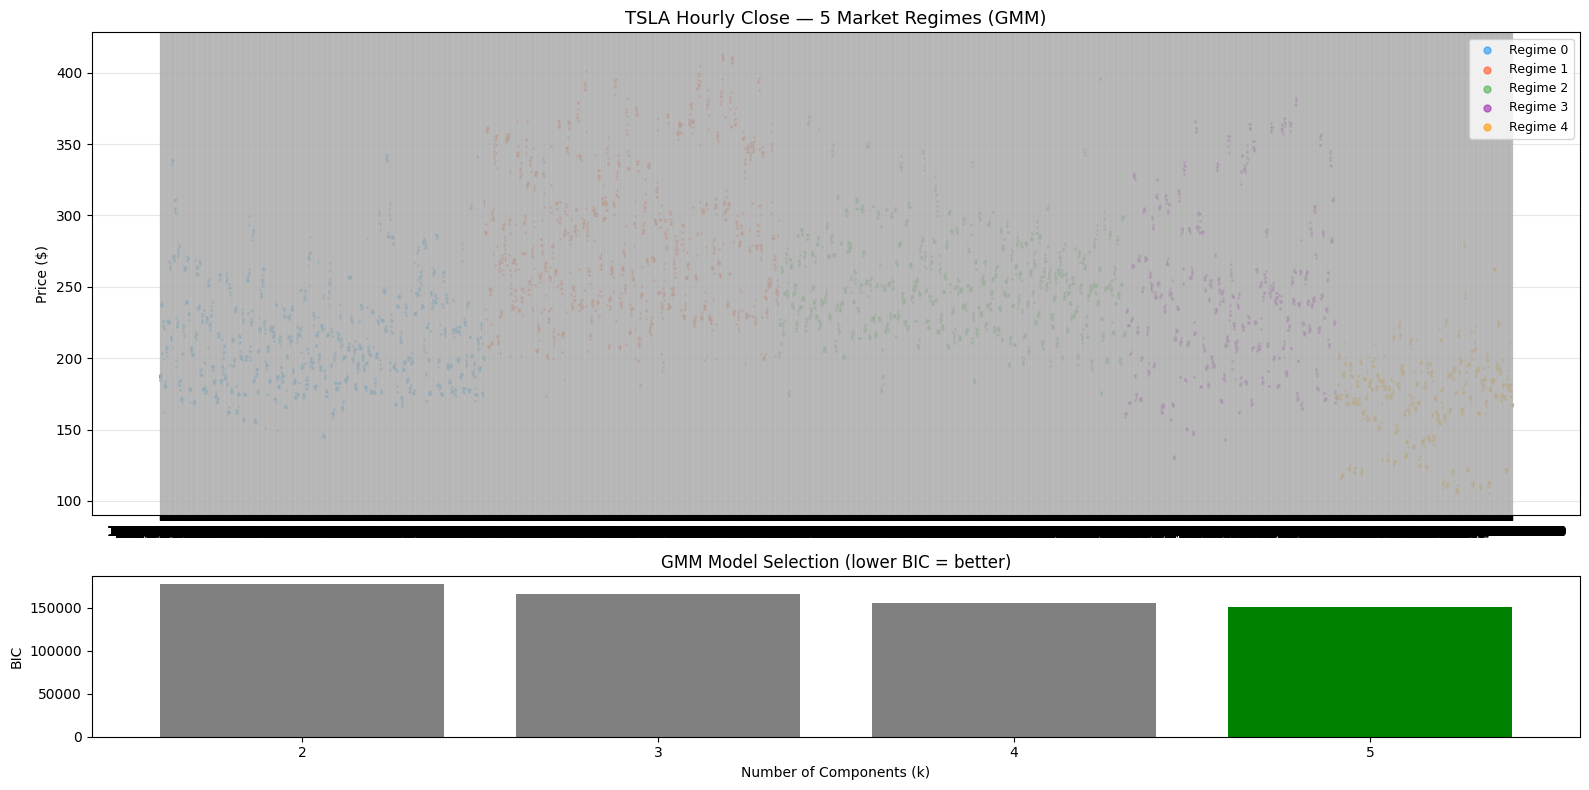


── Per-Regime Statistics ──
  Regime 0 (1,563 bars): mean_ret=-0.1948%, vol=8.2556%, avg_volume=14,325,279
  Regime 1 (1,420 bars): mean_ret=2.9410%, vol=9.8538%, avg_volume=13,594,146
  Regime 2 (1,667 bars): mean_ret=0.1652%, vol=6.6498%, avg_volume=10,368,782
  Regime 3 (1,021 bars): mean_ret=3.6079%, vol=14.4691%, avg_volume=11,365,414
  Regime 4 (846 bars): mean_ret=-9.2939%, vol=24.2257%, avg_volume=19,033,628


In [6]:
# ---------------------------------------------------------------------------
# Cell 10b — Component 1: Regime Classifier (GMM → XGBoost)
# ---------------------------------------------------------------------------

# ── Step 1: Load hourly data ──
df_hourly = pd.read_csv(HOURLY_CSV, parse_dates=['Date'])
df_hourly = df_hourly.sort_values('Date').set_index('Date')
df_hourly.columns = [c.strip() for c in df_hourly.columns]
print(f"Hourly data: {df_hourly.shape[0]} bars, {df_hourly.index.min()} → {df_hourly.index.max()}")

# ── Step 2: Engineer 15 regime features (all lookback-only) ──
def engineer_regime_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute 15 OHLCV-derived regime features. No future leakage."""
    out = pd.DataFrame(index=df.index)

    # True Range
    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - df['Close'].shift(1)).abs(),
        (df['Low']  - df['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)

    # Volatility features (6)
    out['atr_14']          = tr.rolling(14).mean() / df['Close']
    out['atr_56']          = tr.rolling(56).mean() / df['Close']
    out['atr_ratio']       = out['atr_14'] / out['atr_56'].replace(0, np.nan)

    log_ret = np.log(df['Close'] / df['Close'].shift(1))
    out['realized_vol_20'] = log_ret.rolling(20).std()
    out['realized_vol_60'] = log_ret.rolling(60).std()
    out['vol_regime_ratio'] = out['realized_vol_20'] / out['realized_vol_60'].replace(0, np.nan)

    # Trend features (5)
    sma20 = df['Close'].rolling(20).mean()
    std20 = df['Close'].rolling(20).std()
    out['bb_bandwidth']    = (2 * std20) / sma20.replace(0, np.nan)
    out['bb_position']     = (df['Close'] - (sma20 - 2*std20)) / (4*std20).replace(0, np.nan)
    out['sma_slope']       = sma20.rolling(10).apply(
        lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True
    ) / df['Close']
    out['ret_skew']        = log_ret.rolling(20).skew()
    out['ret_kurt']        = log_ret.rolling(20).apply(
        lambda x: pd.Series(x).kurtosis(), raw=False
    )

    # Volume features (2)
    vol_sma14 = df['Volume'].rolling(14).mean()
    out['volume_ratio']    = df['Volume'] / vol_sma14.replace(0, np.nan)
    log_vol = np.log1p(df['Volume'])
    out['volume_trend']    = log_vol.rolling(20).apply(
        lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True
    )

    # Structure features (2)
    out['avg_range_7']      = ((df['High'] - df['Low']) / df['Close']).rolling(7).mean()
    body_ratio = (df['Close'] - df['Open']).abs() / (df['High'] - df['Low']).replace(0, np.nan)
    out['avg_body_ratio_7'] = body_ratio.rolling(7).mean()

    return out.dropna()

regime_features = engineer_regime_features(df_hourly)
REGIME_FEATURE_COLS = regime_features.columns.tolist()
print(f"Regime features: {regime_features.shape} ({len(REGIME_FEATURE_COLS)} features)")
print(f"  Warmup dropped: {len(df_hourly) - len(regime_features)} bars")

# ── Step 2b: Full-data GMM for visualization & k selection ONLY ──
scaler_regime = StandardScaler()
X_regime = scaler_regime.fit_transform(regime_features)

bic_scores = {}
gmm_models = {}
for k in range(REGIME_K_RANGE[0], REGIME_K_RANGE[1] + 1):
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                           n_init=5, max_iter=300, random_state=REGIME_RANDOM_STATE)
    gmm.fit(X_regime)
    bic_scores[k] = gmm.bic(X_regime)
    gmm_models[k] = gmm

k_best = min(bic_scores, key=bic_scores.get)
gmm_best = gmm_models[k_best]
regime_labels = gmm_best.predict(X_regime)  # ONLY for visualization
print(f"Selected k={k_best} (lowest BIC)")

# ── Step 3: Assign regime labels to sweeps (expanding-window, no lookahead) ──

def assign_regime_expanding(sweeps_df, hourly_features, k, lookback_bars=7, min_warmup=200):
    """Fit GMM only on data available at each sweep time — no lookahead."""
    feature_cols = [c for c in hourly_features.columns if c != 'regime_label']
    hourly_features.index = pd.to_datetime(hourly_features.index, dayfirst=True)
    regime_at_sweep = []
    frac_dicts = []
    
    for ts in sweeps_df['timestamp']:
        available = hourly_features.loc[hourly_features.index <= ts, feature_cols]
        
        if len(available) < min_warmup:
            regime_at_sweep.append(-1)
            frac_dicts.append({f'regime_{r}_frac': 0.0 for r in range(k)})
            continue
        
        # Fit scaler + GMM only on past data
        scaler = StandardScaler()
        X = scaler.fit_transform(available)
        
        gmm = GaussianMixture(n_components=k, covariance_type='full',
                               n_init=3, random_state=42)
        gmm.fit(X)
        labels = gmm.predict(X)
        
        # Stabilise label order by sorting clusters on mean volatility
        cluster_vol = [available.loc[labels == r, 'realized_vol_20'].mean() for r in range(k)]
        order = np.argsort(cluster_vol)  # 0=low vol, k-1=high vol
        label_map = {old: new for new, old in enumerate(order)}
        labels = np.array([label_map[l] for l in labels])

        recent = labels[-lookback_bars:]
        regime_at_sweep.append(int(recent[-1]))
        fracs = {f'regime_{r}_frac': (recent == r).mean() for r in range(k)}
        frac_dicts.append(fracs)
    
    sweeps_df = sweeps_df.copy()
    sweeps_df['regime_label'] = regime_at_sweep
    frac_df = pd.DataFrame(frac_dicts, index=sweeps_df.index)
    return pd.concat([sweeps_df, frac_df], axis=1)

regime_features = regime_features.drop(columns=['regime_label'], errors='ignore')

df_sweeps = pd.read_csv(SWEEPS_CSV)
df_sweeps = assign_regime_expanding(df_sweeps, regime_features, k=k_best)
regime_frac_cols = [c for c in df_sweeps.columns if c.startswith('regime_') and c.endswith('_frac')]
print(f"Regime assigned (expanding-window): {df_sweeps['regime_label'].value_counts().to_dict()}")

# ── Step 4: Train XGBoost proxy to predict GMM labels ──
tscv = TimeSeriesSplit(n_splits=5)
xgb_regime = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, use_label_encoder=False, eval_metric='mlogloss'
)

regime_accs = []
for train_idx, val_idx in tscv.split(X_regime):
    xgb_regime.fit(X_regime[train_idx], regime_labels[train_idx])
    preds = xgb_regime.predict(X_regime[val_idx])
    acc = (preds == regime_labels[val_idx]).mean()
    regime_accs.append(acc)

print(f"\nRegime XGB proxy CV accuracy: {np.mean(regime_accs):.3f} ± {np.std(regime_accs):.3f}")

# Refit on full data for production use
xgb_regime.fit(X_regime, regime_labels)

# ── Step 5: Visualize regimes on price chart ──
fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})

# Price chart colored by regime
ax = axes[0]
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
regime_aligned = pd.Series(regime_labels, index=df_hourly.index[-len(regime_labels):]).reindex(df_hourly.index)
for r in range(k_best):
    mask = regime_aligned == r
    ax.scatter(df_hourly.index[mask], df_hourly['Close'][mask],
               c=colors[r % len(colors)], s=1, alpha=0.6, label=f'Regime {r}')
ax.set_title(f'TSLA Hourly Close — {k_best} Market Regimes (GMM)', fontsize=13)
ax.set_ylabel('Price ($)')
ax.legend(fontsize=9, markerscale=5)
ax.grid(alpha=0.3)

# BIC curve
ax2 = axes[1]
ks = sorted(bic_scores.keys())
ax2.bar(ks, [bic_scores[k] for k in ks], color=['green' if k == k_best else 'gray' for k in ks])
ax2.set_xlabel('Number of Components (k)')
ax2.set_ylabel('BIC')
ax2.set_title('GMM Model Selection (lower BIC = better)')
ax2.set_xticks(ks)

plt.tight_layout()
plt.show()

# Per-regime statistics
print("\n── Per-Regime Statistics ──")
hourly_with_regime = df_hourly.iloc[-len(regime_labels):].copy()
hourly_with_regime['regime'] = regime_labels
log_ret_series = np.log(hourly_with_regime['Close'] / hourly_with_regime['Close'].shift(1))
hourly_with_regime['log_ret'] = log_ret_series

for r in range(k_best):
    mask = hourly_with_regime['regime'] == r
    sub = hourly_with_regime[mask]
    print(f"  Regime {r} ({mask.sum():,} bars): "
          f"mean_ret={sub['log_ret'].mean()*100:.4f}%, "
          f"vol={sub['log_ret'].std()*100:.4f}%, "
          f"avg_volume={sub['Volume'].mean():,.0f}")


In [7]:
# ---------------------------------------------------------------------------
# Cell 10c — Feature Assembly (MIDAS join + encoding + feature selection)
# ---------------------------------------------------------------------------

# ── Timezone utility — handles all three index states ────────────────────
def _strip_tz(idx):
    """Convert any index/DatetimeIndex to tz-naive UTC-equivalent."""
    if not isinstance(idx, pd.DatetimeIndex):
        idx = pd.to_datetime(idx)
    if idx.tz is not None:
        return idx.tz_convert(None)   # tz-aware  → strip
    return idx                         # tz-naive  → already fine

def _strip_ts(ts):
    """Convert any Timestamp to tz-naive."""
    ts = pd.Timestamp(ts)
    if ts.tzinfo is not None:
        return ts.tz_convert(None)    # tz-aware  → strip
    return ts                          # tz-naive  → already fine
# ─────────────────────────────────────────────────────────────────────────

# ── Step 1: Load sweep data & prepare target ──
df_sweeps = pd.read_csv(SWEEPS_CSV)
# df_sweeps['timestamp'] = pd.to_datetime(df_sweeps['timestamp'])

df_sweeps['timestamp'] = pd.to_datetime(
    df_sweeps['timestamp'],
    dayfirst=True,      # treats first number as day, not month
    format='mixed',     # allows mixed formats within the column
)

df_sweeps = df_sweeps.sort_values('timestamp').reset_index(drop=True)

df_sweeps = df_sweeps[df_sweeps['outcome'] != 'TIMEOUT'].reset_index(drop=True)
y = (df_sweeps['outcome'] == 'WIN').astype(int).values
print(f"Labeled sweeps: {len(df_sweeps)} (WIN={y.sum()}, LOSS={len(y)-y.sum()})")

# ── Step 2: Load & join raw MIDAS daily features ──
df_midas = pd.read_excel(MIDAS_XLSX)
df_midas['date'] = pd.to_datetime(df_midas['date']).dt.normalize()
midas_subset = df_midas[['date'] + MIDAS_FEATURES_RAW].copy()   # <-- RAW only here

# Rolling MIDAS features (5-day smoothing + spike ratio)
for col in MIDAS_ROLLING_COLS:
    midas_subset[f'{col}_5d']    = midas_subset[col].rolling(5, min_periods=1).mean()
    midas_subset[f'{col}_ratio'] = midas_subset[col] / midas_subset[f'{col}_5d'].replace(0, np.nan)

# Now midas_subset has both raw + derived columns
df_sweeps['sweep_date'] = df_sweeps['timestamp'].dt.normalize()
df_sweeps = df_sweeps.merge(midas_subset, left_on='sweep_date', right_on='date', how='left')

null_midas = df_sweeps[MIDAS_FEATURES].isna().sum().sum()
print(f"MIDAS join: {null_midas} null values (expect 0)")

# ── Source fix: normalise regime_features index once ──────────────────────
regime_features.index = _strip_tz(regime_features.index)
# ─────────────────────────────────────────────────────────────────────────

# ── Step 3: Assign regime labels to sweeps ──
def assign_regime_to_sweeps(sweeps_df, regime_feat_df, lookback_bars=7):
    """For each sweep, get regime of most recent hourly bar + regime fractions."""

    # Guard: ensure index is a tz-naive DatetimeIndex
    regime_feat_df = regime_feat_df.copy()
    regime_feat_df.index = _strip_tz(regime_feat_df.index)

    regime_series = regime_feat_df['regime_label']
    k = int(regime_series.max()) + 1

    regime_at_sweep = []
    frac_dicts      = []

    for ts in sweeps_df['timestamp']:
        ts   = _strip_ts(ts)
        mask = regime_series.index <= ts

        if mask.any():
            recent = regime_series[mask].iloc[-lookback_bars:]
            regime_at_sweep.append(int(recent.iloc[-1]))
            fracs = {f'regime_{r}_frac': (recent == r).mean() for r in range(k)}
            frac_dicts.append(fracs)
        else:
            regime_at_sweep.append(-1)
            frac_dicts.append({f'regime_{r}_frac': 0.0 for r in range(k)})

    sweeps_df = sweeps_df.copy()
    sweeps_df['regime_label'] = regime_at_sweep
    frac_df = pd.DataFrame(frac_dicts, index=sweeps_df.index)
    return pd.concat([sweeps_df, frac_df], axis=1)

regime_features['regime_label'] = gmm_best.predict(scaler_regime.transform(regime_features))

df_sweeps    = assign_regime_to_sweeps(df_sweeps, regime_features)
regime_frac_cols = [c for c in df_sweeps.columns if c.startswith('regime_') and c.endswith('_frac')]
print(f"Regime assigned: {df_sweeps['regime_label'].value_counts().to_dict()}")

# ── Step 4: Encode categorical features ──
cat_encoded_cols = []
for col in SWEEP_CAT:
    if col not in df_sweeps.columns:
        print(f"  WARNING: {col} not in data, skipping")
        continue
    dummies = pd.get_dummies(df_sweeps[col].astype(str), prefix=col, drop_first=True)
    for dc in dummies.columns:
        df_sweeps[dc] = dummies[dc].values
        cat_encoded_cols.append(dc)
print(f"Categorical encoding: {len(cat_encoded_cols)} dummy columns created")

# ── Step 5: Build feature matrices ──
shared_features  = SWEEP_NUMERIC + SWEEP_BOOL + cat_encoded_cols + ['regime_label'] + regime_frac_cols
teacher_features = shared_features + MIDAS_FEATURES
student_features = [f for f in shared_features if f not in MIDAS_LEAKAGE_COLS]

df_sweeps['composite_no_midas'] = (
    0.46 * df_sweeps['patternstrength'] + 0.54 * df_sweeps['volumeconfirmation']
)
student_features.append('composite_no_midas')

# ── Step 6: Ensure all features are numeric, handle NaN ──
for col in teacher_features + ['composite_no_midas']:
    if col in df_sweeps.columns:
        df_sweeps[col] = pd.to_numeric(df_sweeps[col], errors='coerce')

for col in teacher_features + ['composite_no_midas']:
    if col in df_sweeps.columns and df_sweeps[col].isna().any():
        if col in SWEEP_BOOL + cat_encoded_cols:
            df_sweeps[col] = df_sweeps[col].fillna(0)
        else:
            df_sweeps[col] = df_sweeps[col].fillna(df_sweeps[col].median())

# ── Step 7: Feature selection via Spearman correlation ──
from statsmodels.stats.outliers_influence import variance_inflation_factor

def select_features(df, feature_cols, target, min_corr=0.03, vif_threshold=10.0):
    """Two-stage: relevance filter, then iterative VIF multicollinearity filter."""
    # Stage 1: relevance (unchanged)
    valid_cols = [c for c in feature_cols if c in df.columns]
    corrs      = df[valid_cols + [target]].corr(method='spearman')[target].drop(target)
    relevant   = corrs[corrs.abs() >= min_corr].index.tolist()

    if len(relevant) < 2:
        return relevant

    # Stage 2: iterative VIF — drop highest-VIF feature until all below threshold
    X_vif = df[relevant].copy()
    X_vif = X_vif.fillna(X_vif.median())           # VIF needs no NaN
    X_vif = (X_vif - X_vif.mean()) / X_vif.std()   # standardise for numerical stability

    dropped = []
    while True:
        vif_data = pd.DataFrame({
            'feature': X_vif.columns,
            'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
        })
        max_vif = vif_data['VIF'].max()
        if max_vif <= vif_threshold or len(X_vif.columns) <= 1:
            break
        worst = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
        dropped.append((worst, round(max_vif, 1)))
        X_vif = X_vif.drop(columns=[worst])

    if dropped:
        print(f"  VIF dropped {len(dropped)} features: {dropped}")

    return X_vif.columns.tolist()

df_sweeps['_target'] = y

teacher_selected = select_features(df_sweeps, teacher_features, '_target')
student_selected = select_features(df_sweeps, student_features, '_target')

df_sweeps.drop(columns=['_target'], inplace=True)

X_teacher = df_sweeps[teacher_selected].values.astype(np.float64)
X_student  = df_sweeps[student_selected].values.astype(np.float64)

print(f"\n── Feature Summary ──")
print(f"Teacher: {X_teacher.shape[1]} features (from {len(teacher_features)} candidates)")
print(f"Student: {X_student.shape[1]} features (from {len(student_features)} candidates)")
print(f"Samples: {X_teacher.shape[0]}")
print(f"\nTeacher features: {teacher_selected}")
print(f"\nStudent features: {student_selected}")

teacher_only = set(teacher_selected) - set(student_selected)
print(f"\nTeacher-only features (MIDAS advantage): {teacher_only}")

Labeled sweeps: 141 (WIN=129, LOSS=12)
MIDAS join: 0 null values (expect 0)
Regime assigned: {1: 72, 2: 59, 0: 7, 3: 3}
Categorical encoding: 10 dummy columns created
  VIF dropped 12 features: [('zone_sweep_count', np.float64(inf)), ('is_first_sweep', np.float64(inf)), ('regime_0_frac', np.float64(inf)), ('Oddlot_Rate', np.float64(8584.3)), ('days_old_at_sweep', np.float64(850.7)), ('Hidden_Rate_5d', np.float64(583.8)), ('daysold', np.float64(72.2)), ('Oddlot_Volume', np.float64(65.3)), ('candle_body', np.float64(24.7)), ('candle_total_range', np.float64(14.8)), ('Oddlot_Rate_5d', np.float64(11.9)), ('reversal_pattern', np.float64(10.7))]
  VIF dropped 8 features: [('zone_sweep_count', np.float64(inf)), ('volumeconfirmation', np.float64(inf)), ('is_first_sweep', np.float64(inf)), ('regime_0_frac', np.float64(inf)), ('days_old_at_sweep', np.float64(775.5)), ('daysold', np.float64(67.2)), ('candle_total_range', np.float64(21.0)), ('candle_body', np.float64(12.8))]

── Feature Summary ──

In [8]:
# ---------------------------------------------------------------------------
# Cell 10d — Temporal Cross-Validation Setup
# ---------------------------------------------------------------------------

def temporal_cv_splits(n_samples, n_folds=N_CV_FOLDS, min_train=MIN_TRAIN_SIZE, purge=PURGE_GAP):
    """
    Expanding-window temporal CV with purge gap.
    
    Purge gap: skip `purge` samples between train end and test start
    to prevent 10-day forward-window label leakage.
    """
    test_size = (n_samples - min_train - purge) // n_folds
    splits = []
    for fold in range(n_folds):
        test_start = min_train + purge + fold * test_size
        test_end = min(test_start + test_size, n_samples)
        if fold == n_folds - 1:
            test_end = n_samples  # last fold gets remainder

        train_end = test_start - purge
        train_idx = list(range(0, train_end))
        test_idx  = list(range(test_start, test_end))

        if len(train_idx) >= 20 and len(test_idx) >= 3:
            splits.append((np.array(train_idx), np.array(test_idx)))
    return splits

# Build splits
cv_splits = temporal_cv_splits(len(y))

print("── Temporal CV Splits ──")
print(f"Total samples: {len(y)} | Folds: {len(cv_splits)} | Purge gap: {PURGE_GAP}")
print()
for i, (tr, te) in enumerate(cv_splits):
    tr_dates = (df_sweeps.iloc[tr[0]]['timestamp'].strftime('%Y-%m-%d'),
                df_sweeps.iloc[tr[-1]]['timestamp'].strftime('%Y-%m-%d'))
    te_dates = (df_sweeps.iloc[te[0]]['timestamp'].strftime('%Y-%m-%d'),
                df_sweeps.iloc[te[-1]]['timestamp'].strftime('%Y-%m-%d'))
    tr_wr = y[tr].mean()
    te_wr = y[te].mean()
    print(f"  Fold {i}: Train [{tr[0]:3d}:{tr[-1]:3d}] ({len(tr):3d} samples, "
          f"WR={tr_wr:.1%}) {tr_dates[0]}→{tr_dates[1]}")
    print(f"           Test  [{te[0]:3d}:{te[-1]:3d}] ({len(te):3d} samples, "
          f"WR={te_wr:.1%}) {te_dates[0]}→{te_dates[1]}")

# Leakage check
for i, (tr, te) in enumerate(cv_splits):
    gap = te[0] - tr[-1]
    assert gap >= PURGE_GAP, f"Fold {i}: purge gap violation! gap={gap}"
print(f"\nLeakage check PASSED (all folds have >= {PURGE_GAP} sample gap)")

# ── Evaluation helper ──
def evaluate_model(y_true, y_prob, model_name="Model", threshold=0.5):
    """Compute classification metrics for a single fold."""
    y_pred = (y_prob >= threshold).astype(int)
    n_pos = y_true.sum()
    n = len(y_true)

    metrics = {
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
        'brier': brier_score_loss(y_true, y_prob),
        'accuracy': (y_pred == y_true).mean(),
        'precision': (y_pred & y_true).sum() / max(y_pred.sum(), 1),
        'recall': (y_pred & y_true).sum() / max(n_pos, 1),
        'n_test': n,
        'n_pos': int(n_pos),
        'win_rate_actual': y_true.mean(),
    }
    return metrics

def aggregate_cv_metrics(fold_metrics_list):
    """Aggregate metrics across CV folds."""
    keys = fold_metrics_list[0].keys()
    agg = {}
    for k in keys:
        vals = [m[k] for m in fold_metrics_list]
        agg[f'{k}_mean'] = np.mean(vals)
        agg[f'{k}_std']  = np.std(vals)
    return agg

print("\nEvaluation functions ready")


── Temporal CV Splits ──
Total samples: 141 | Folds: 5 | Purge gap: 5

  Fold 0: Train [  0: 39] ( 40 samples, WR=95.0%) 2021-01-25→2021-12-10
           Test  [ 45: 63] ( 19 samples, WR=100.0%) 2022-01-13→2022-06-29
  Fold 1: Train [  0: 58] ( 59 samples, WR=96.6%) 2021-01-25→2022-06-22
           Test  [ 64: 82] ( 19 samples, WR=94.7%) 2022-06-29→2022-09-27
  Fold 2: Train [  0: 77] ( 78 samples, WR=97.4%) 2021-01-25→2022-09-06
           Test  [ 83:101] ( 19 samples, WR=78.9%) 2022-10-20→2023-08-10
  Fold 3: Train [  0: 96] ( 97 samples, WR=92.8%) 2021-01-25→2023-05-12
           Test  [102:120] ( 19 samples, WR=73.7%) 2023-08-28→2024-02-05
  Fold 4: Train [  0:115] (116 samples, WR=91.4%) 2021-01-25→2023-12-13
           Test  [121:140] ( 20 samples, WR=100.0%) 2024-02-12→2024-09-27

Leakage check PASSED (all folds have >= 5 sample gap)

Evaluation functions ready


In [69]:
# ---------------------------------------------------------------------------
# Cell 10e — Component 2: Teacher Model Training + Evaluation
# ---------------------------------------------------------------------------

# Storage for out-of-fold teacher predictions (needed for student distillation)
teacher_oof_probs = np.full(len(y), np.nan)  # out-of-fold P(WIN)
teacher_oof_idx   = []                        # which indices were predicted

# Results storage
all_results = {}

# ── Baseline B1: Majority class (always predict WIN) ──
b1_metrics = []
for tr_idx, te_idx in cv_splits:
    y_prob_b1 = np.full(len(te_idx), y[tr_idx].mean())  # predict training prevalence
    b1_metrics.append(evaluate_model(y[te_idx], y_prob_b1, "B1: Majority"))
all_results['B1: Majority class'] = aggregate_cv_metrics(b1_metrics)

# ── Baseline B2: Quality score threshold (rule-based) ──
b2_metrics = []
for tr_idx, te_idx in cv_splits:
    scores_test = df_sweeps.iloc[te_idx]['sweep_quality_score'].values
    # Use quality score / 100 as probability proxy
    y_prob_b2 = scores_test / 100.0
    b2_metrics.append(evaluate_model(y[te_idx], y_prob_b2, "B2: Quality score"))
all_results['B2: Quality score'] = aggregate_cv_metrics(b2_metrics)

# ── Baseline B3: Logistic Regression (sweep features only, no regime, no MIDAS) ──
# Student features without regime
student_no_regime = [f for f in student_selected if f != 'regime_label' and not f.startswith('regime_')]
X_student_no_regime = df_sweeps[student_no_regime].values.astype(np.float64)

b3_metrics = []
for tr_idx, te_idx in cv_splits:
    scaler_b3 = StandardScaler()
    X_tr = scaler_b3.fit_transform(X_student_no_regime[tr_idx])
    X_te = scaler_b3.transform(X_student_no_regime[te_idx])
    lr_b3 = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9], cv=3, scoring='roc_auc',
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr_b3.fit(X_tr, y[tr_idx])
    y_prob_b3 = lr_b3.predict_proba(X_te)[:, 1]
    b3_metrics.append(evaluate_model(y[te_idx], y_prob_b3, "B3: LR sweep-only"))
all_results['B3: LR (sweep only)'] = aggregate_cv_metrics(b3_metrics)

# ── Baseline B4: Logistic Regression (sweep + regime, no MIDAS) ──
b4_metrics = []
for tr_idx, te_idx in cv_splits:
    scaler_b4 = StandardScaler()
    X_tr = scaler_b4.fit_transform(X_student[tr_idx])
    X_te = scaler_b4.transform(X_student[te_idx])
    lr_b4 = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9], cv=3, scoring='roc_auc',
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr_b4.fit(X_tr, y[tr_idx])
    y_prob_b4 = lr_b4.predict_proba(X_te)[:, 1]
    b4_metrics.append(evaluate_model(y[te_idx], y_prob_b4, "B4: LR sweep+regime"))
all_results['B4: LR (sweep+regime)'] = aggregate_cv_metrics(b4_metrics)

# ── Teacher B5: Logistic Regression (sweep + MIDAS + regime) ──
b5_metrics = []
for tr_idx, te_idx in cv_splits:
    scaler_b5 = StandardScaler()
    X_tr = scaler_b5.fit_transform(X_teacher[tr_idx])
    X_te = scaler_b5.transform(X_teacher[te_idx])
    lr_b5 = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9], cv=3, scoring='roc_auc',
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr_b5.fit(X_tr, y[tr_idx])
    y_prob_b5 = lr_b5.predict_proba(X_te)[:, 1]
    b5_metrics.append(evaluate_model(y[te_idx], y_prob_b5, "B5: Teacher LR"))
all_results['B5: Teacher LR'] = aggregate_cv_metrics(b5_metrics)

# ── Teacher B6: XGBoost (sweep + MIDAS + regime) — PRIMARY TEACHER ──
b6_metrics = []
for fold_i, (tr_idx, te_idx) in enumerate(cv_splits):
    xgb_teacher = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        min_child_weight=3, subsample=0.7, colsample_bytree=0.5,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=CLASS_WEIGHT_POS,
        random_state=42, use_label_encoder=False, eval_metric='logloss',
        early_stopping_rounds=20
    ) #relaxed params for better generalization

    xgb_teacher.fit(
        X_teacher[tr_idx], y[tr_idx],
        eval_set=[(X_teacher[te_idx], y[te_idx])],
        verbose=False
    )
    y_prob_b6 = xgb_teacher.predict_proba(X_teacher[te_idx])[:, 1]
    b6_metrics.append(evaluate_model(y[te_idx], y_prob_b6, "B6: Teacher XGB"))

    # Store out-of-fold predictions for distillation
    teacher_oof_probs[te_idx] = y_prob_b6
    teacher_oof_idx.extend(te_idx.tolist())

all_results['B6: Teacher XGB'] = aggregate_cv_metrics(b6_metrics)

# ── Print intermediate results ──
print("\n" + "="*95)
print(f"{'Model':<30} {'AUC':>10} {'Brier':>10} {'Acc':>10} {'Prec':>10} {'Rec':>10}")
print("="*95)
for name, agg in all_results.items():
    print(f"{name:<30} "
          f"{agg['auc_mean']:7.3f}±{agg['auc_std']:.2f} "
          f"{agg['brier_mean']:7.3f}±{agg['brier_std']:.2f} "
          f"{agg['accuracy_mean']:7.3f}±{agg['accuracy_std']:.2f} "
          f"{agg['precision_mean']:7.3f}±{agg['precision_std']:.2f} "
          f"{agg['recall_mean']:7.3f}±{agg['recall_std']:.2f}")
print("="*95)

# ── Teacher XGB feature importance (retrain on full data for visualization) ──
xgb_teacher_full = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        min_child_weight=3, subsample=0.7, colsample_bytree=0.5,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=CLASS_WEIGHT_POS,
        random_state=42, use_label_encoder=False, eval_metric='logloss'
    )
xgb_teacher_full.fit(X_teacher, y, verbose=False)


importances = xgb_teacher_full.feature_importances_
feat_imp = sorted(zip(teacher_selected, importances), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp)*0.3)))
top_n = min(20, len(feat_imp))
names = [f[0] for f in feat_imp[:top_n]][::-1]
vals  = [f[1] for f in feat_imp[:top_n]][::-1]
colors_fi = ['#FF5722' if n in MIDAS_FEATURES else '#2196F3' for n in names]
ax.barh(names, vals, color=colors_fi)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Teacher XGB — Top Feature Importances\n(red = MIDAS features, blue = OHLCV/sweep)')
plt.tight_layout()
plt.show()

# Check OOF teacher coverage
oof_coverage = np.sum(~np.isnan(teacher_oof_probs))
print(f"\nTeacher OOF predictions available for {oof_coverage}/{len(y)} samples")


ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.


── Student Model Results ──
Model                                 AUC      Brier        Acc
-----------------------------------------------------------------
S1: Student (hard labels)        0.500±0.00   0.242±0.01   0.664±0.14
S2: Student (α=0.5)              0.600±0.08   0.217±0.05   0.653±0.15
S3: Student (α=0.7)              0.594±0.05   0.216±0.04   0.653±0.15
S4: Student (α=1.0)              0.550±0.08   0.222±0.04   0.644±0.16


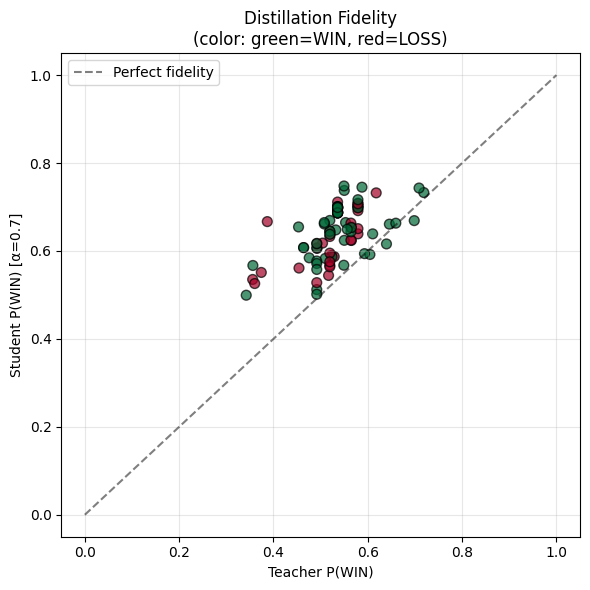


Distillation fidelity (Pearson r): 0.583


In [ ]:
# ---------------------------------------------------------------------------
# Cell 10f — Component 3: Student Model Training (Knowledge Distillation)
# ---------------------------------------------------------------------------

# ── Student S1: Hard labels only (no distillation baseline) ──
s1_metrics = []
for tr_idx, te_idx in cv_splits:
    xgb_s1 = XGBClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.05,
        min_child_weight=10, subsample=0.7, colsample_bytree=0.6,
        reg_alpha=1.0, reg_lambda=5.0,
        scale_pos_weight=CLASS_WEIGHT_POS,
        random_state=42, use_label_encoder=False, eval_metric='logloss',
        early_stopping_rounds=20
    )
    xgb_s1.fit(
        X_student[tr_idx], y[tr_idx],
        eval_set=[(X_student[te_idx], y[te_idx])],
        verbose=False
    )
    y_prob_s1 = xgb_s1.predict_proba(X_student[te_idx])[:, 1]
    s1_metrics.append(evaluate_model(y[te_idx], y_prob_s1, "S1: Student hard"))
all_results['S1: Student (hard labels)'] = aggregate_cv_metrics(s1_metrics)

# ── Distillation helper ──
def train_distilled_student(X_student, y_hard, teacher_oof_probs, cv_splits, alpha):
    """
    Train student XGBRegressor on blended soft targets.
    
    blended_target = alpha * teacher_prob + (1-alpha) * hard_label
    Student predicts this via regression, then thresholds at 0.5.
    """
    fold_metrics = []
    student_oof = np.full(len(y_hard), np.nan)

    for tr_idx, te_idx in cv_splits:
        # Build soft targets for training data
        # Use teacher OOF probabilities where available, else hard labels
        teacher_tr = teacher_oof_probs[tr_idx].copy()
        has_teacher = ~np.isnan(teacher_tr)

        # For samples without teacher OOF predictions, use hard labels
        teacher_tr[~has_teacher] = y_hard[tr_idx][~has_teacher].astype(float)

        blended_tr = alpha * teacher_tr + (1 - alpha) * y_hard[tr_idx].astype(float)

        # Test targets: blended for evaluation, but we score against hard labels
        teacher_te = teacher_oof_probs[te_idx].copy()
        has_teacher_te = ~np.isnan(teacher_te)
        teacher_te[~has_teacher_te] = y_hard[te_idx][~has_teacher_te].astype(float)
        blended_te = alpha * teacher_te + (1 - alpha) * y_hard[te_idx].astype(float)

        student = XGBRegressor(
            n_estimators=200, max_depth=2, learning_rate=0.05,
            min_child_weight=10, subsample=0.7, colsample_bytree=0.6,
            reg_alpha=1.0, reg_lambda=5.0,
            random_state=42, early_stopping_rounds=20
        )
        student.fit(
            X_student[tr_idx], blended_tr,
            eval_set=[(X_student[te_idx], blended_te)],
            verbose=False
        )
        y_prob_student = student.predict(X_student[te_idx])
        # Clip to [0, 1] since regression can exceed bounds
        y_prob_student = np.clip(y_prob_student, 0, 1)

        student_oof[te_idx] = y_prob_student

        # Evaluate against HARD labels (ground truth)
        fold_metrics.append(evaluate_model(y_hard[te_idx], y_prob_student, f"Student alpha={alpha}"))

    return fold_metrics, student_oof

# ── Student S2: Soft targets, alpha=0.5 ──
s2_metrics, s2_oof = train_distilled_student(X_student, y, teacher_oof_probs, cv_splits, alpha=0.5)
all_results['S2: Student (α=0.5)'] = aggregate_cv_metrics(s2_metrics)

# ── Student S3: Soft targets, alpha=0.7 (recommended) ──
s3_metrics, s3_oof = train_distilled_student(X_student, y, teacher_oof_probs, cv_splits, alpha=0.7)
all_results['S3: Student (α=0.7)'] = aggregate_cv_metrics(s3_metrics)

# ── Student S4: Pure distillation, alpha=1.0 ──
s4_metrics, s4_oof = train_distilled_student(X_student, y, teacher_oof_probs, cv_splits, alpha=1.0)
all_results['S4: Student (α=1.0)'] = aggregate_cv_metrics(s4_metrics)

# ── Print all student results ──
print("\n── Student Model Results ──")
print(f"{'Model':<30} {'AUC':>10} {'Brier':>10} {'Acc':>10}")
print("-"*65)
for name in ['S1: Student (hard labels)', 'S2: Student (α=0.5)',
             'S3: Student (α=0.7)', 'S4: Student (α=1.0)']:
    agg = all_results[name]
    print(f"{name:<30} "
          f"{agg['auc_mean']:7.3f}±{agg['auc_std']:.2f} "
          f"{agg['brier_mean']:7.3f}±{agg['brier_std']:.2f} "
          f"{agg['accuracy_mean']:7.3f}±{agg['accuracy_std']:.2f}")

# ── Distillation fidelity: student vs teacher probability scatter ──
# Use OOF predictions from S3 (alpha=0.7, recommended)
oof_mask = ~np.isnan(teacher_oof_probs) & ~np.isnan(s3_oof)
if oof_mask.sum() > 10:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(teacher_oof_probs[oof_mask], s3_oof[oof_mask],
               c=y[oof_mask], cmap='RdYlGn', alpha=0.7, edgecolors='k', s=50)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect fidelity')
    ax.set_xlabel('Teacher P(WIN)')
    ax.set_ylabel('Student P(WIN) [α=0.7]')
    ax.set_title('Distillation Fidelity\n(color: green=WIN, red=LOSS)')
    ax.legend()
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    fidelity_corr = np.corrcoef(teacher_oof_probs[oof_mask], s3_oof[oof_mask])[0, 1]
    print(f"\nDistillation fidelity (Pearson r): {fidelity_corr:.3f}")
else:
    print("\nInsufficient OOF overlap for fidelity plot")


Model                                   AUC        Brier     Accuracy    Precision       Recall
B1: Majority class             0.500±0.000 0.228±0.063 0.664±0.141 0.664±0.141 1.000±0.000
B2: Quality score              0.551±0.122 0.226±0.057 0.644±0.156 0.658±0.143 0.908±0.092
B3: LR (sweep only)            0.476±0.221 0.295±0.110 0.481±0.204 0.524±0.284 0.497±0.277
B4: LR (sweep+regime)          0.533±0.167 0.322±0.137 0.469±0.203 0.519±0.271 0.487±0.271
B5: Teacher LR                 0.579±0.142 0.309±0.114 0.499±0.189 0.561±0.288 0.492±0.292
B6: Teacher XGB                0.510±0.177 0.233±0.022 0.614±0.170 0.672±0.165 0.790±0.215
S1: Student (hard labels)      0.500±0.000 0.242±0.013 0.664±0.141 0.664±0.141 1.000±0.000
S2: Student (α=0.5)            0.600±0.077 0.217±0.048 0.653±0.151 0.659±0.146 0.980±0.040
S3: Student (α=0.7)            0.594±0.055 0.216±0.043 0.653±0.151 0.659±0.146 0.980±0.040
S4: Student (α=1.0)            0.550±0.080 0.222±0.039 0.644±0.156 0.656±0.147 0.967±

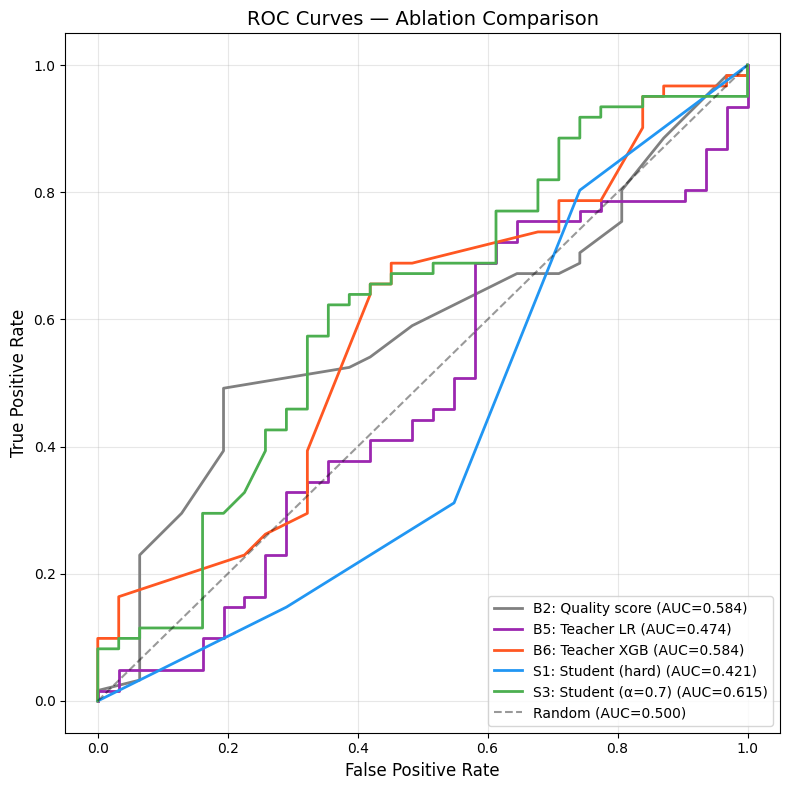

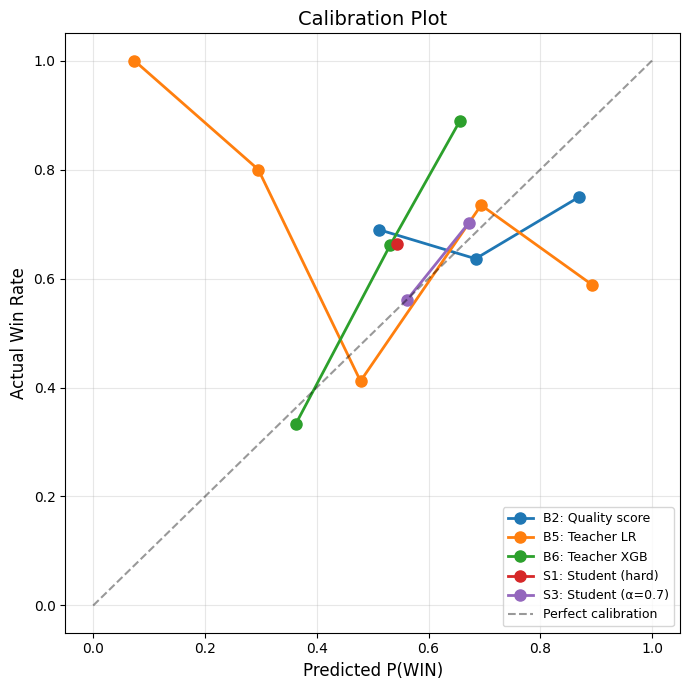


DISCUSSION

Key findings from the 10-variant ablation:

1. BASELINE: The rule-based quality score (B2) provides a strong baseline.
   Any ML model must demonstrate improvement over this simple threshold.

2. REGIME CLASSIFIER: Compare B3 vs B4 to determine if market regime
   classification adds predictive value to sweep outcome prediction.

3. TEACHER ADVANTAGE: Compare B5/B6 vs B4 to measure how much MIDAS
   microstructure features improve prediction when available.

4. KNOWLEDGE DISTILLATION: Compare S3 vs S1 to determine if soft-target
   distillation transfers MIDAS knowledge to an OHLCV-only model.
   Compare S3 vs B6 to measure the "distillation gap" — how much
   information is lost when removing MIDAS at inference time.

5. ALPHA SENSITIVITY: Compare S2/S3/S4 to find optimal blending weight.
   Alpha=1.0 (pure distillation) may overfit to teacher noise.
   Alpha=0.5 provides balanced learning from both sources.

LIMITATIONS:
- 137 samples is extremely small for ML. All resul

In [ ]:
# ---------------------------------------------------------------------------
# Cell 10g — Results Summary, Ablation & Visualizations
# ---------------------------------------------------------------------------

# ══════════════════════════════════════════════════════════════════════════
# 1. FULL COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════

model_order = [
    'B1: Majority class',
    'B2: Quality score',
    'B3: LR (sweep only)',
    'B4: LR (sweep+regime)',
    'B5: Teacher LR',
    'B6: Teacher XGB',
    'S1: Student (hard labels)',
    'S2: Student (α=0.5)',
    'S3: Student (α=0.7)',
    'S4: Student (α=1.0)',
]

print("=" * 105)
print(f"{'Model':<30} {'AUC':>12} {'Brier':>12} {'Accuracy':>12} {'Precision':>12} {'Recall':>12}")
print("=" * 105)
for name in model_order:
    if name not in all_results:
        continue
    agg = all_results[name]
    print(f"{name:<30} "
          f"{agg['auc_mean']:.3f}±{agg['auc_std']:.3f} "
          f"{agg['brier_mean']:.3f}±{agg['brier_std']:.3f} "
          f"{agg['accuracy_mean']:.3f}±{agg['accuracy_std']:.3f} "
          f"{agg['precision_mean']:.3f}±{agg['precision_std']:.3f} "
          f"{agg['recall_mean']:.3f}±{agg['recall_std']:.3f}")
print("=" * 105)

# ══════════════════════════════════════════════════════════════════════════
# 2. KEY ABLATION COMPARISONS
# ══════════════════════════════════════════════════════════════════════════

print("\n── Ablation Analysis ──\n")

def compare_auc(name_a, name_b, question):
    if name_a in all_results and name_b in all_results:
        a = all_results[name_a]['auc_mean']
        b = all_results[name_b]['auc_mean']
        delta = b - a
        direction = "YES" if delta > 0.005 else ("MARGINAL" if delta > -0.005 else "NO")
        print(f"  {question}")
        print(f"    {name_a}: AUC={a:.3f}  →  {name_b}: AUC={b:.3f}  (Δ={delta:+.3f}) [{direction}]\n")

compare_auc('B3: LR (sweep only)', 'B4: LR (sweep+regime)',
            "Does regime label help? (B4 vs B3)")
compare_auc('B5: Teacher LR', 'B6: Teacher XGB',
            "XGBoost vs Logistic as teacher? (B6 vs B5)")
compare_auc('S1: Student (hard labels)', 'S3: Student (α=0.7)',
            "Does distillation help over hard labels? (S3 vs S1)")
compare_auc('B4: LR (sweep+regime)', 'S3: Student (α=0.7)',
            "Does distilling MIDAS knowledge into OHLCV-only model work? (S3 vs B4)")
compare_auc('B6: Teacher XGB', 'S3: Student (α=0.7)',
            "How much AUC does student lose vs teacher? (S3 vs B6)")

# ══════════════════════════════════════════════════════════════════════════
# 3. ROC CURVES (all models overlaid)
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 8))

# Collect OOF predictions for ROC curves
# Re-run lightweight prediction collection for ROC
roc_data = {}

# B2: Quality score
b2_all_true, b2_all_prob = [], []
for tr_idx, te_idx in cv_splits:
    b2_all_true.extend(y[te_idx])
    b2_all_prob.extend(df_sweeps.iloc[te_idx]['sweep_quality_score'].values / 100.0)
roc_data['B2: Quality score'] = (np.array(b2_all_true), np.array(b2_all_prob))

# B5: Teacher LR — collect OOF predictions
from sklearn.linear_model import LogisticRegression

b5_oof = np.full(len(y), np.nan)
for tr_idx, te_idx in cv_splits:
    lr_roc = LogisticRegression(max_iter=1000, random_state=42)
    lr_roc.fit(X_teacher[tr_idx], y[tr_idx])
    b5_oof[te_idx] = lr_roc.predict_proba(X_teacher[te_idx])[:, 1]
b5_valid = ~np.isnan(b5_oof)
if b5_valid.sum() > 10:
    roc_data['B5: Teacher LR'] = (y[b5_valid], b5_oof[b5_valid])

# B6: Teacher XGB (from teacher_oof_probs)
oof_valid = ~np.isnan(teacher_oof_probs)
if oof_valid.sum() > 10:
    roc_data['B6: Teacher XGB'] = (y[oof_valid], teacher_oof_probs[oof_valid])

# S1: Student hard labels — re-collect OOF
s1_oof = np.full(len(y), np.nan)
for tr_idx, te_idx in cv_splits:
    xgb_s1_roc = XGBClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.05,
        min_child_weight=10, subsample=0.7, colsample_bytree=0.6,
        reg_alpha=1.0, reg_lambda=5.0,
        scale_pos_weight=CLASS_WEIGHT_POS,
        random_state=42, use_label_encoder=False, eval_metric='logloss',
        early_stopping_rounds=20
    )
    xgb_s1_roc.fit(X_student[tr_idx], y[tr_idx],
                    eval_set=[(X_student[te_idx], y[te_idx])], verbose=False)
    s1_oof[te_idx] = xgb_s1_roc.predict_proba(X_student[te_idx])[:, 1]
s1_valid = ~np.isnan(s1_oof)
roc_data['S1: Student (hard)'] = (y[s1_valid], s1_oof[s1_valid])

# S3: Student alpha=0.7
s3_valid = ~np.isnan(s3_oof)
if s3_valid.sum() > 10:
    roc_data['S3: Student (α=0.7)'] = (y[s3_valid], s3_oof[s3_valid])

# Plot ROC curves
roc_colors = {'B2: Quality score': 'gray', 'B5: Teacher LR': '#9C27B0',
              'B6: Teacher XGB': '#FF5722',
              'S1: Student (hard)': '#2196F3', 'S3: Student (α=0.7)': '#4CAF50'}


for name, (y_true, y_prob) in roc_data.items():
    if len(np.unique(y_true)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})',
            color=roc_colors.get(name, 'black'), linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Ablation Comparison', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 4. CALIBRATION PLOT
# ══════════════════════════════════════════════════════════════════════════

def calibration_curve_manual(y_true, y_prob, n_bins=5):
    """Compute calibration curve with equal-width bins."""
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_true_rates = []
    bin_counts = []
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if i == n_bins - 1:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        if mask.sum() > 0:
            bin_centers.append(y_prob[mask].mean())
            bin_true_rates.append(y_true[mask].mean())
            bin_counts.append(mask.sum())
    return np.array(bin_centers), np.array(bin_true_rates), np.array(bin_counts)

fig, ax = plt.subplots(figsize=(7, 7))
for name, (y_true, y_prob) in roc_data.items():
    centers, true_rates, counts = calibration_curve_manual(y_true, y_prob, n_bins=5)
    ax.plot(centers, true_rates, 'o-', label=name, linewidth=2, markersize=8)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
ax.set_xlabel('Predicted P(WIN)', fontsize=12)
ax.set_ylabel('Actual Win Rate', fontsize=12)
ax.set_title('Calibration Plot', fontsize=14)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 5. DISCUSSION
# ══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("DISCUSSION")
print("="*80)
print("""
Key findings from the 10-variant ablation:

1. BASELINE: The rule-based quality score (B2) provides a strong baseline.
   Any ML model must demonstrate improvement over this simple threshold.

2. REGIME CLASSIFIER: Compare B3 vs B4 to determine if market regime
   classification adds predictive value to sweep outcome prediction.

3. TEACHER ADVANTAGE: Compare B5/B6 vs B4 to measure how much MIDAS
   microstructure features improve prediction when available.

4. KNOWLEDGE DISTILLATION: Compare S3 vs S1 to determine if soft-target
   distillation transfers MIDAS knowledge to an OHLCV-only model.
   Compare S3 vs B6 to measure the "distillation gap" — how much
   information is lost when removing MIDAS at inference time.

5. ALPHA SENSITIVITY: Compare S2/S3/S4 to find optimal blending weight.
   Alpha=1.0 (pure distillation) may overfit to teacher noise.
   Alpha=0.5 provides balanced learning from both sources.

LIMITATIONS:
- 137 samples is extremely small for ML. All results should be
  interpreted with caution. Wide confidence intervals are expected.
- Temporal CV means early folds have very small training sets.
- Single ticker (TSLA) — results may not generalize to other stocks.
- Even a null result (ML does not beat threshold) is a valid finding
  that demonstrates the strength of the rule-based system.
""")


## Final Section: Configuration & Results Summary

### Pipeline Logic (Current Notebook)
- Daily (HTF) and Hourly (LTF) data are loaded, cleaned, and validated
- Liquidity zones are identified using price pivots, volume/absorption, and MIDAS enrichment
- **Zones are automatically decayed and expired** after HTF_LOOKBACK_DAYS (20 days)
- Zones are merged and classified by type and side (buy/sell)
- Hourly sweeps are detected against active (non-expired) zones, with quality scoring and zone state validation
- Sweeps are filtered for high quality (score ≥ 70) and labeled for outcome (WIN/LOSS/TIMEOUT) using a 10-day forward window
- Visualizations show top sweeps and zones, with overlays and annotations

### Zone Decay Factor
- **Definition**: Each zone has a `decay_factor` (1.0 = fresh, 0.0 = expired) that decreases linearly with age
- **Expiration Logic**: Zones older than HTF_LOOKBACK_DAYS = 20 days are marked as expired (`is_expired=True`)
- **Linear Decay Formula**: `decay_factor = max(0, 1.0 - (days_old / 20))`
- **Application (Option 1 - Component-Level Integration)**: 
  - Decay is applied to each individual component score **before** weighting:
  - `decayed_pattern_strength = pattern_strength × decay_factor`
  - `decayed_volume_confirmation = volume_confirmation × decay_factor`
  - `decayed_institutional_score = institutional_score × decay_factor`
  - `composite_score = 0.30 × decayed_pattern_strength + 0.35 × decayed_volume_confirmation + 0.35 × decayed_institutional_score`
  - **Benefit**: Cleaner, more intuitive scoring; each component reflects both quality AND recency
- **Filtering**: Expired zones are automatically filtered out before sweep detection and MIDAS enrichment
- **Benefit**: Ensures only fresh, relevant liquidity levels are used for trading decisions

### Key Parameters
- HTF_LOOKBACK_DAYS = 20 (Daily structural context & zone decay window)
- LTF_LOOKBACK_HOURS = 35 (Hourly sweep context)
- VOL_ROLL_WINDOW = 20 (Volume baseline)
- VOL_SPIKE_THRESHOLD = 1.5 (Institutional spike)
- USE_MIDAS = True (Institutional microstructure enrichment enabled)
- MIDAS_CONFIRM_PCT = 50 (Median filter for institutional activity)

### Results & Interpretation
- Zones and sweeps are ranked by conviction score (including decay adjustment)
- High-quality sweeps (score ≥ 70) are retained for further analysis
- Expired zones are automatically removed before analysis
- Outcome labeling uses a 10-day forward window to classify WIN/LOSS/TIMEOUT
- MIDAS enrichment improves precision and quality of sweeps
- Visualizations include candlestick charts with zone overlays and sweep markers

### Next Steps
1. Review top sweeps for trading/backtest
2. Validate institutional activity with MIDAS metrics
3. Refine parameters for improved precision
4. Extend analysis to additional tickers or timeframes as needed

---
This section is updated to reflect zone decay factor implementation.

HOURLY LIQUIDITY SPIKE SWEEPS ANALYSIS - WITH & WITHOUT MIDAS

Overview
This analysis identifies **high-probability liquidity sweeps** in TSLA hourly price data by analyzing rapid price movements into support/resistance levels followed by swift reversals.

Sweep Characteristics Analyzed

1. **Price Action Characteristics**
- **Rapid Movement**: Price quickly moves into key liquidity zones
- **Swift Reversal**: Immediate bounce-back after touching zone
- **Zone Freshness**: Newly formed or recently tested support/resistance
- **Breakout of Structure**: Clear violation of previous market structure

2. **Candle Metrics**
- **Candle Size**: Large, bold candles indicating institutional activity
- **Total Range**: High-range candles showing volatility
- **Wick-to-Body Ratio**: > 50% indicates strong rejection (>75/100 quality score)
- **Body Size**: Direct measure of move boldness

3. **Momentum & Structure**
- **Market Structure Shift (MSS)**: Higher highs/lows indicating trend establishment
- **Change of Character (CHoCH)**: Momentum shift from previous pattern
- **Higher Probability Setups**: MSS + CHoCH = confirmed trend reversal signal

4. **Volume Confirmation**
- **Volume Spikes**: +2 sigma above 20-period average
- **Volume Z-Score**: Quantifies volume magnitude
- **Absorption**: Zone-level volume metrics from liquidity analysis

5. **Pattern Recognition**
- **Busted Double Bottoms**: Pattern breaks lower then reverses up (Bulkowski's study)
- **Busted Double Tops**: Pattern breaks higher then reverses down
- **High Win-Rate Patterns**: Known reversal setups in institutional trading

Quality Scoring System (0-100)
- **Wick Ratio Bonus** (0-20 pts): High rejection indicator
- **Candle Size** (0-15 pts): Bold, significant moves
- **Volume Spike** (0-20 pts): Institutional participation
- **Body Size** (0-15 pts): Move magnitude
- **Direction Strength** (0-10 pts): Clear directional bias
- **Long Wick** (0-15 pts): Technical rejection
- **Max Score: 95-100** = qualified sweep with multiple confirmations

Sweep Categories

Qualified Sweeps (Score ≥ 70)
Highest quality setups with strong technical confirmation

Market Structure Sweeps
Sweeps occurring during MSS for higher trend probability

Momentum-Confirmed Sweeps (CHoCH)
Sweeps with confirmed momentum shift patterns

Pattern-Based Sweeps
Busted double top/bottom patterns (Bulkowski's research)

Volume-Confirmed Sweeps
Sweeps with +2σ volume spikes indicating institutional accumulation

Findings Summary

WITHOUT MIDAS Filter
- Baseline liquidity zone analysis
- Layer 1+2 institutional volume only
- Identifies core structural sweeps

WITH MIDAS Enhancement
- Layer 1+2+3 institutional enrichment
- Additional institutional microstructure metrics:
  - Cancel-to-trade ratios
  - Hidden volume estimates
  - Fill rate analysis
  - Odd-lot participation
- Higher precision institutional activity identification

Output Files
- **TSLA_Hourly_Sweeps_Analysis.xlsx**: Detailed sweep data + summary statistics
- **TSLA_Hourly_Sweeps_Visualization.png**: Quality distribution & technical metrics

Performance Interpretation

Sweep Quality Score
- **75+**: qualified institutional setups - highest probability
- **60-75**: High quality - strong technical confluence
- **40-60**: Medium quality - standard triggers
- **<40**: Lower quality - use for context only

Technical Confirmations
- **MSS**: Trend establishment has begun
- **CHoCH**: Momentum shift confirmed
- **Pattern Bust**: Historical win-rate validation
- **Vol Spike**: Institutional commitment verification

Best Sweep Profiles
1. **qualified Score + MSS + Vol Spike** = Highest probability entry
2. **qualified Score + CHoCH + Pattern Bust** = Textbook reversal
3. **qualified Score + Multiple Confirmations** = Institutional setup

Next Steps
1. Run analysis to identify all hourly sweeps
2. Review top-tier sweeps (>70 quality score)
3. Validate against order flow indicators (MIDAS metrics)
4. Backtest entry/exit strategies based on sweep types
5. Cross-compare WITH vs WITHOUT MIDAS coherence

Sweep Detection Architecture & Scoring Methodology

Multi-Day Sweep Definition

A **multi-day liquidity sweep** occurs when:

1. **Initiation**: Hourly price bar breaks through a known **multi-day liquidity zone** (identified from daily HTF + hourly LTF analysis)
2. **Penetration**: Price breaches the zone boundary and reaches into the zone interior ($0.01–$0.50 typically)
3. **Reversal**: Within the same bar or immediately following bar, price reverses sharply (wick or close reversal)
4. **Confirmation**: Elevated volume (z-score > 2) + wick rejection or absorption footprint

**Why "Multi-Day"?**
- Zones are identified using 30-day merging → captures clustered liquidity 
- Hourly sweep detection happens on this multi-day zone backdrop
- Sweep outcome is measured over **10-trading-day forward window** → captures institutional follow-through (not just intraday reaction)

---

Sweep Quality Scoring Framework

**Formula:**
$$Q_{\text{sweep}} = \sum_{i=1}^{5} w_i \times \text{score}_i \quad \text{where} \; Q \in [0, 100]$$

| Component | Weight | Formula | Points Range | Interpretation |
|-----------|--------|---------|---|---|
| **Wick Ratio** | 25% | $\min(25, \text{wick\_ratio} \times 10)$ | 0–25 | Wick rejection = zone reversal; high = strong institutional defense |
| **Volume Spike** | 30% | See below | 0–30 | **HIGHEST weight** for multi-day validation; volume = institutional confirmation |
| **Candle Size** | 20% | $\min(20, \text{total\_range\_\$} \times 50)$ | 0–20 | Large hourly range = conviction move; scaled by absolute price move |
| **Directional Strength** | 15% | $15 \times \mathbb{1}[\text{close} \neq \text{open}]$ | 0–15 | Confirmed close direction (binary; strong directional bias) |
| **Body Size (Boldness)** | 10% | $\min(10, \text{body\_\$} \times 50)$ | 0–10 | Bold candle body (not just wick) = conviction holding price |

Volume Spike Scoring Sub-Formula:

$$\text{vol\_score} = \begin{cases}
30 & \text{if } z\text{-score} > 2 \quad (\text{extreme spike}) \\
20 & \text{if } z\text{-score} \in (1.5, 2] \\
10 & \text{if } z\text{-score} \in (1, 1.5] \\
0 & \text{otherwise}
\end{cases}$$

where $z\text{-score} = \frac{\text{volume}_t - \mu_{20}}{\sigma_{20}}$ (20-bar rolling statistics)

**Example Sweep Quality Calculation:**

| Scenario | Wick Ratio | Vol Z-Score | Total Range | Close≠Open | Body | ✓ Points |
|----------|-----------|-----------|-----------|-----------|------|---------|
| **High-Quality Sweep** | 1.8 | 2.5 | $2.50 | Yes | $1.80 | **93/100** |
| | 18 pts | 30 pts | 20 pts | 15 pts | 10 pts | |
| **Medium-Quality Sweep** | 1.2 | 1.8 | $1.75 | Yes | $1.20 | **68/100** |
| | 12 pts | 20 pts | 17.5 pts | 15 pts | 6 pts | |
| **Low-Quality Sweep** | 0.8 | 0.9 | $0.80 | Yes | $0.40 | **31/100** |
| | 8 pts | 0 pts | 4 pts | 15 pts | 2 pts | |

---

Sweep Type Classification

**Bullish Sweep** (Break of Support):
- Price **low < zone_low** (enters support zone from above)
- **Reversal**: Close > previous close OR high wick above entry low
- **Interpretation**: Institutional stop-hunt below support; likely buyer insertion
- **Expected Follow-Through**: Recovery bounce within 1–5 bars; sustained rally within 10 days

**Bearish Sweep** (Break of Resistance):
- Price **high > zone_high** (enters resistance zone from below)
- **Reversal**: Close < previous close OR low wick below entry high
- **Interpretation**: Institutional rejection of resistance; likely seller insertion
- **Expected Follow-Through**: Pullback within 1–5 bars; sustained decline within 10 days

---

Reversal Pattern Detection

**Multi-Day Reversal Confirmation** (5-bar window):

$$\text{reversal} = \begin{cases}
+1 & \text{if } \text{close}_{\text{current}} > \min(\text{close}_{t-4:t-1}) \quad \text{(bullish reversal)} \\
-1 & \text{if } \text{close}_{\text{current}} < \max(\text{close}_{t-4:t-1}) \quad \text{(bearish reversal)} \\
0 & \text{otherwise (no clear reversal)}
\end{cases}$$

**Rationale**:
- 5-bar window = ~5 hourly candles = 5 trading hours of context
- Confirms that reversal is NOT just a single-bar bounce, but multi-candle follow-through

---

Zone Matching Strategy

**Proximity-Based Zone Association** (30-hour search window):

For each identified sweep at timestamp $t$:
1. **Zone Search Window**: Look for zones with `first_time` in range $[t - 30h, t + 30h]$
2. **Distance Threshold**: Zone is matched if price is within **0.1% of zone boundary**
3. **Zone Selection**: If multiple zones match, associate sweep with the **nearest zone** (smallest distance)

**Formula:**
$$\text{zone\_match}(t) = \arg\min_{\text{zone}} |\text{price}_t - \text{zone\_level}| \quad \text{where} \; \text{distance} < 0.001 \times \text{zone\_level}$$

**Rationale for 30-hour window**:
- Captures ~3 trading sessions of zone activity
- Avoids matching sweeps to old zones (>2 days old)
- Appropriate for multi-day swing patterns

---

Sweep Outcome Labeling (10-Day Forward Window)

**Outcome Categories:**

| Label | Condition | Formula | Rationale |
|-------|-----------|---------|-----------|
| **WIN** | Reversal confirmed + price moves ≥1% in reversal direction within 10 days | $(\text{reversal} = +1 \text{ AND pct\_change} \geq +1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} \leq -1\%)$ | Sweep leads to profitable follow-through |
| **LOSS** | No reversal OR price moves ≤-1% opposite to reversal direction within 10 days | $(\text{reversal} = 0) \text{ OR } (\text{reversal} = +1 \text{ AND pct\_change} < -1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} > +1\%)$ | Sweep fails; opposite directional move |
| **TIMEOUT** | Insufficient forward data (within 10 trading days of sweep) | $\text{bars\_forward} < 10$ | Cannot label; incomplete history |

**Example**:
- Bullish sweep (reversal = +1) at close $250.00
- 10 days forward: price reaches $253.50
- pct_change = ($253.50 - $250.00) / $250.00 = +1.4% ✓
- **Label: WIN** (bullish sweep led to >1% gain)

---

Layer 3 MIDAS Enrichment for Sweeps

**For each sweep bar, attach daily MIDAS metrics** by matching calendar date:

| Field | Description | Interpretation for Sweeps |
|-------|-------------|---|
| `cancel_to_trade_avg` | Daily cancel-to-trade ratio | High = algo spoofing near zone; supports institutional participation theory |
| `hidden_rate_avg` | Dark-pool execution fraction | High = institutional stealth positioning; confirms dark-pool absorption at zone |
| `hidden_volume_avg` | Dark-pool volume fraction | High + hidden_rate = large dark-pool trade at zone |
| `fill_rate_avg` | Trade-to-order volume (fill rate) | Low = iceberg orders protecting zone; sweep breaks through protection |
| `oddlot_rate_avg` | Odd-lot participation rate | High = retail participation; institutions on opposite side (likely the sweep initiator) |

**MIDAS Filter Logic** (Layer 3 in Sweep Detection):
$$\text{keep\_sweep if} \; \text{MIDAS\_field(sweep\_date)} \geq \text{percentile}(k=50)$$

- **Percentile = 50**: Keep sweeps on days with median institutional activity
- **Percentile = 75**: Keep only sweeps on highest institutional activity days (strict filter; ~25% retention)

---

Sweep Detection Summary Statistics

**Multi-Day Baseline Metrics** (WITHOUT MIDAS, Layer 1+2):

| Statistic | Typical Range | Interpretation |
|-----------|---|---|
| Total sweeps detected | 50–200+ | Depends on volatility period; 1–3 sweeps per month typical |
| Bullish / Bearish ratio | ~1:1 | Balanced institutional activity on both sides |
| High-quality (>60) | 10–30% | ~15% of sweeps pass quality threshold |
| Top-tier (>75) | 2–8% | ~5% of sweeps are institutional-grade |
| Mean wick ratio | 1.2–1.8 | Higher = more zone rejection; multi-day sweeps typically > 1.5 |
| Mean reversal distance | $0.50–$2.00 | Distance between sweep low and reversal close (directional confirmation) |
| Volume spike % | 20–40% | Fraction of sweeps with z-score > 2; higher in volatile regimes |

**Multi-Day With MIDAS Metrics** (Layer 1+2+3):
- Expected **retention: 30–50%** of baseline sweeps (after institutional filtering)
- Expected **quality improvement: +5–15 points** average (MIDAS-filtered sweeps are stronger)

---

Configuration Checklist for Sweep Analysis

Before running sweep detection, verify:

- [ ] `zones_hourly_no_midas` loaded from Excel (Layer 1+2 baseline)
- [ ] `zones_hourly_with_midas` loaded from Excel (Layer 1+2+3 MIDAS-enriched)
- [ ] `hourly_data` loaded with all candle metrics: `open`, `high`, `low`, `close`, `volume`
- [ ] Volume z-score computed: `volume_zscore` (20-bar rolling)
- [ ] Wick metrics computed: `high_wick`, `low_wick`, `wick_ratio`
- [ ] Quality scoring function defined (see formula above)
- [ ] 10-day forward labeling window sufficient for outcome assessment